# Pipeline unificado de Canastas Básicas Alimentarias

Este notebook primero unifica las CBA y después carga la composición nutricional del INCAP. Las clases y reglas viven en `src/canasta_inteligente`; aquí solo se orquesta e inspecciona el proceso.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
SRC = PROJECT_ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from canasta_inteligente.application.cba_pipeline import (
    build_cba_catalog,
    enrich_catalog_with_incap,
)

## 1. Unificar las CBA

In [2]:
catalog = build_cba_catalog(PROJECT_ROOT / 'data' / 'raw' / 'ine' / 'cba_historicos')
len(catalog)

102

In [3]:
catalog.get('preparacion_nutricional_a_base_de_maiz_y_soya')

Food(id='preparacion_nutricional_a_base_de_maiz_y_soya', name='PREPARACION NUTRICIONAL A BASE DE MAÍZ Y SOYA', category='MISCELÁNEA', aliases={'PREPARACION NUTRICIONAL A BASE DE MAÍZ Y SOYA', 'Preparación nutricional a base de maíz y soya'}, price_timelines={'general': <canasta_inteligente.domain.prices.PriceTimeline object at 0x00000233273B2A50>}, nutrition=None, nutrition_match_score=None, nutrition_match_methods=(), is_meat=False)

In [4]:
catalog.items

[Food(id='arroz', name='ARROZ', category='CEREALES', aliases={'Arroz', 'ARROZ'}, price_timelines={'general': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000023327351160>}, nutrition=None, nutrition_match_score=None, nutrition_match_methods=(), is_meat=False),
 Food(id='avena_de_toda_clase', name='AVENA DE TODA CLASE', category='CEREALES', aliases={'Avena de toda clase', 'AVENA DE TODA CLASE'}, price_timelines={'general': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000023327317390>}, nutrition=None, nutrition_match_score=None, nutrition_match_methods=(), is_meat=False),
 Food(id='pan_frances', name='PAN FRANCÉS', category='CEREALES', aliases={'PAN FRANCÉS', 'Pan francés'}, price_timelines={'general': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000023327317750>, 'rural': <canasta_inteligente.domain.prices.PriceTimeline object at 0x000002336792A870>, 'urbana': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000023367866FF

In [5]:
summary = {
    region: sum(len(food.price_timelines.get(region, ())) for food in catalog)
    for region in ('general', 'rural', 'urbana')
}
summary['general_derivados'] = sum(
    point.derived
    for food in catalog
    for point in food.price_timelines.get('general', ())
)
summary

{'general': 4182, 'rural': 1920, 'urbana': 2112, 'general_derivados': 1632}

Los puntos generales de 2017–2023 son observaciones originales. Desde 2024 se crea un punto general derivado solo si el alimento tiene observaciones rural y urbana para el mismo año y mes.

In [6]:
food_example = next(food for food in catalog if len(food.price_timelines.get('general', ())) > 75)
food_example.name, {region: len(timeline) for region, timeline in food_example.price_timelines.items()}

('PAN FRANCÉS', {'general': 107, 'rural': 32, 'urbana': 32})

## 1.2. Revision manual de unificacion alimentos CBA

In [7]:
from canasta_inteligente.domain.food import Food

catalog_iterable = iter(catalog)
print(len(catalog))

102


### Arroz

In [8]:
food = next(catalog_iterable)
print(food.id)

arroz


In [9]:
food = catalog.get('arroz')
food.years_by_region()

{'general': [2017, 2018, 2019, 2020, 2021, 2022, 2023],
 'rural': [],
 'urbana': []}

Resalta que no haya encontrado registros de arroz en años recientes. 

#### Busqueda de informacion complementaria

In [10]:
for _food in catalog:
    if _food.id.startswith('arroz'):
        print(_food)

Food(id='arroz', name='ARROZ', category='CEREALES', aliases={'Arroz', 'ARROZ'}, price_timelines={'general': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000023327351160>}, nutrition=None, nutrition_match_score=None, nutrition_match_methods=(), is_meat=False)
Food(id='arroz_corriente', name='Arroz corriente', category=None, aliases={'Arroz corriente'}, price_timelines={'rural': <canasta_inteligente.domain.prices.PriceTimeline object at 0x000002336792A2D0>, 'urbana': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000023367A3B890>, 'general': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000023367866C30>}, nutrition=None, nutrition_match_score=None, nutrition_match_methods=(), is_meat=False)
Food(id='arroz_precocido', name='Arroz precocido', category=None, aliases={'Arroz precocido'}, price_timelines={'rural': <canasta_inteligente.domain.prices.PriceTimeline object at 0x000002336792A450>, 'urbana': <canasta_inteligente.domain.prices.PriceTim

Posibles candidatos: Arroz Corriente y Arroz precocido

In [11]:
for _food in catalog:
    if _food.id.startswith('arroz'):
        print(_food)
        print("===============")
        for region, ptf in _food.price_timelines.items(): 
            print(f"Region: {region}")
            print(ptf.avg_daily_grams())


Food(id='arroz', name='ARROZ', category='CEREALES', aliases={'Arroz', 'ARROZ'}, price_timelines={'general': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000023327351160>}, nutrition=None, nutrition_match_score=None, nutrition_match_methods=(), is_meat=False)
Region: general
34.58001397624034
Food(id='arroz_corriente', name='Arroz corriente', category=None, aliases={'Arroz corriente'}, price_timelines={'rural': <canasta_inteligente.domain.prices.PriceTimeline object at 0x000002336792A2D0>, 'urbana': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000023367A3B890>, 'general': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000023367866C30>}, nutrition=None, nutrition_match_score=None, nutrition_match_methods=(), is_meat=False)
Region: rural
17.044065862103597
Region: urbana
18.532218081222897
Region: general
17.788141971663254
Food(id='arroz_precocido', name='Arroz precocido', category=None, aliases={'Arroz precocido'}, price_timelines={'rural

Representa una mayor presencia en la CBA 2024-2026 el arroz corriente que el arroz precocido, aunque aun alejado de lo que representa el arroz en años anteriores respecto a la cantidad de gramos en sus respectivas canstas. 

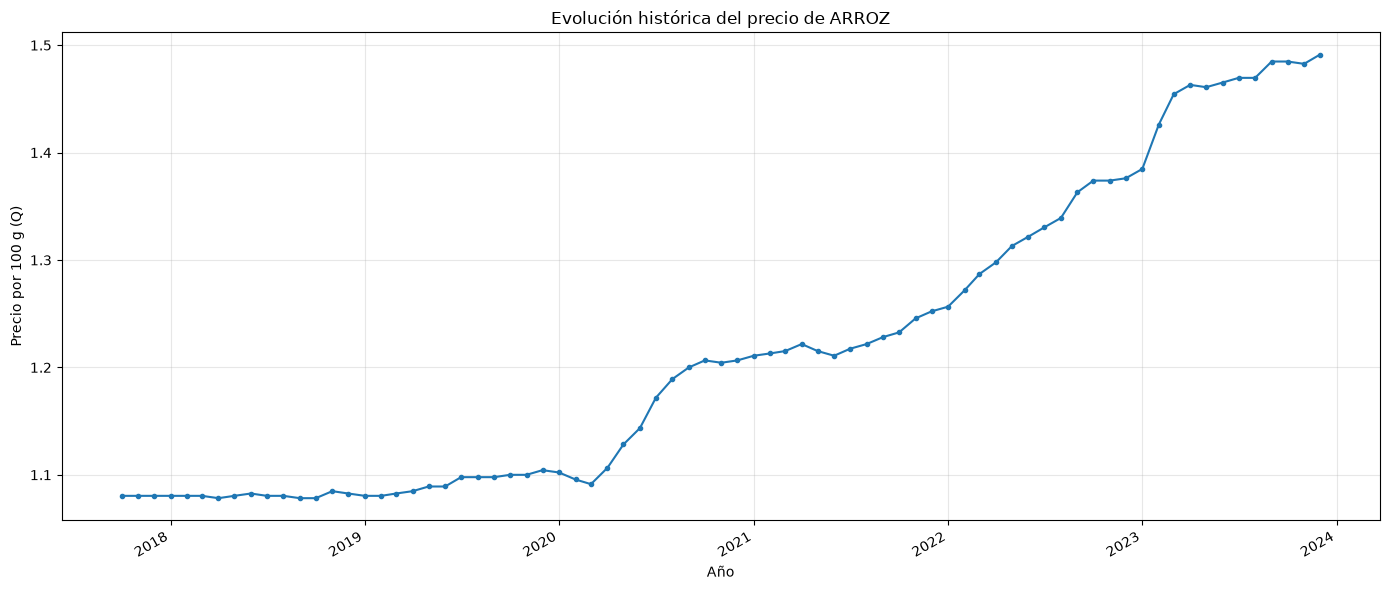

In [12]:
fig, ax = food.plot_timeline('general')

Tendencia general de crecimiento 

In [13]:
food_timeline_summary = food.price_summary("general")

labels = {
    "first": "Primer precio registrado",
    "latest": "Último precio registrado",
    "lowest": "Precio más bajo",
    "highest": "Precio más alto",
}

print(f"Resumen de {food.name} — región general")
print("=" * 50)

for key, label in labels.items():
    point = food_timeline_summary[key]

    if point is None:
        print(f"{label}: sin información")
        continue

    print(
        f"{label}: "
        f"Q{point.price_per_100g:.2f} por 100 g "
        f"({point.month:02d}/{point.year})"
    )

Resumen de ARROZ — región general
Primer precio registrado: Q1.08 por 100 g (10/2017)
Último precio registrado: Q1.49 por 100 g (12/2023)
Precio más bajo: Q1.08 por 100 g (04/2018)
Precio más alto: Q1.49 por 100 g (12/2023)


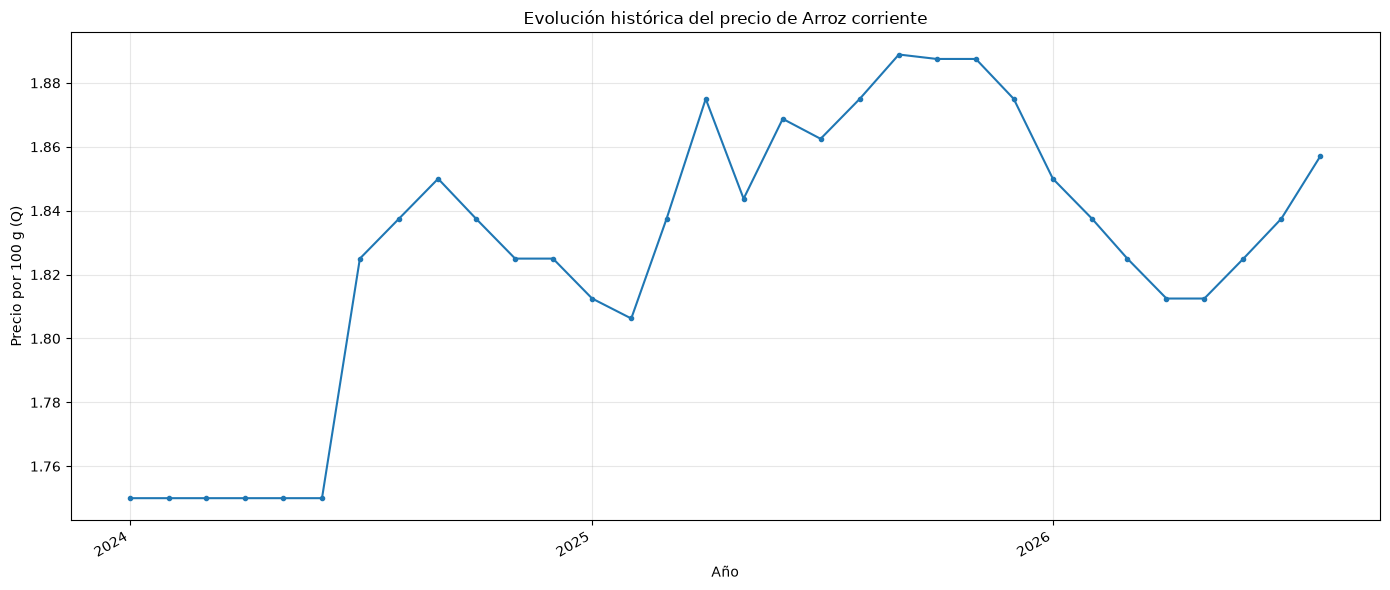

In [14]:
fig, ax = catalog.get('arroz_corriente').plot_timeline('urbana')

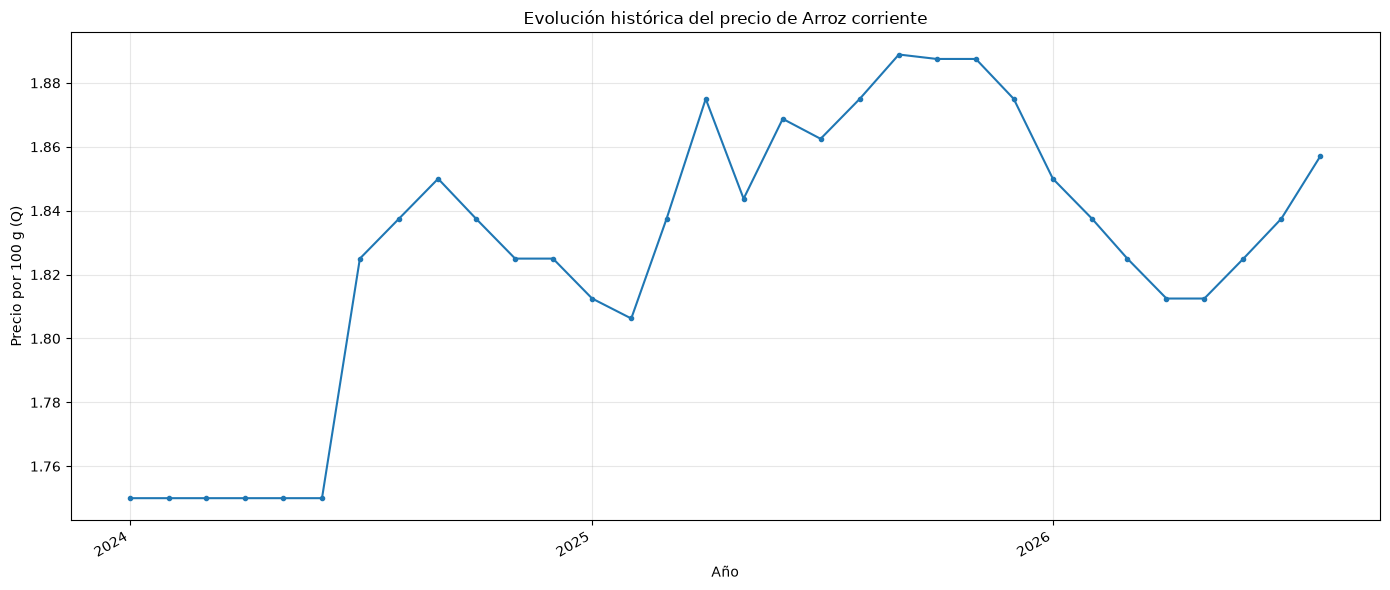

In [15]:
fig, ax = catalog.get('arroz_corriente').plot_timeline('rural')

Los precios se mantienen en ambas regiones asi que usamos la general para resumir la comparacion

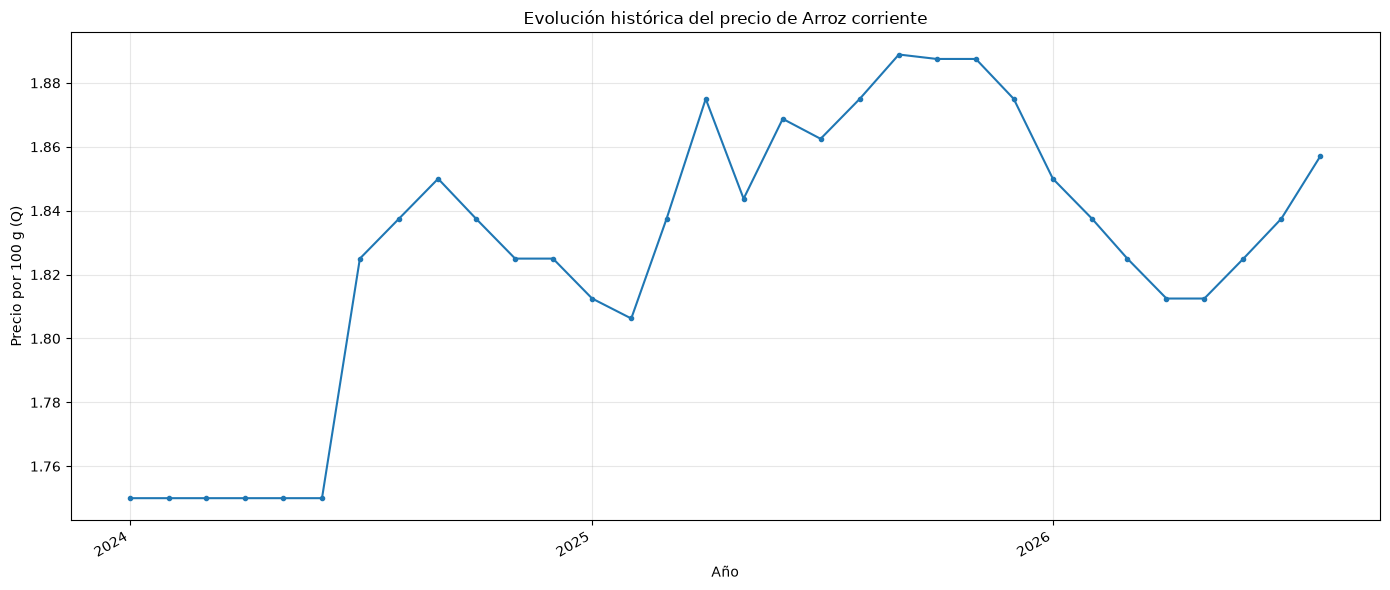

In [16]:
fig, ax = catalog.get('arroz_corriente').plot_timeline('general')

Si comparamos el primer punto del ultimo, podemos decir que si hubo un aumento en el precio, pero sin una tendencia clara, muy fluctante en el periodo. 

In [17]:
target_food = catalog.get('arroz_corriente')
food_timeline_summary = target_food.price_summary("general")

labels = {
    "first": "Primer precio registrado",
    "latest": "Último precio registrado",
    "lowest": "Precio más bajo",
    "highest": "Precio más alto",
}

print(f"Resumen de {target_food.name} — región general")
print("=" * 50)

for key, label in labels.items():
    point = food_timeline_summary[key]

    if point is None:
        print(f"{label}: sin información")
        continue

    print(
        f"{label}: "
        f"Q{point.price_per_100g:.2f} por 100 g "
        f"({point.month:02d}/{point.year})"
    )

Resumen de Arroz corriente — región general
Primer precio registrado: Q1.75 por 100 g (01/2024)
Último precio registrado: Q1.86 por 100 g (08/2026)
Precio más bajo: Q1.75 por 100 g (01/2024)
Precio más alto: Q1.89 por 100 g (09/2025)


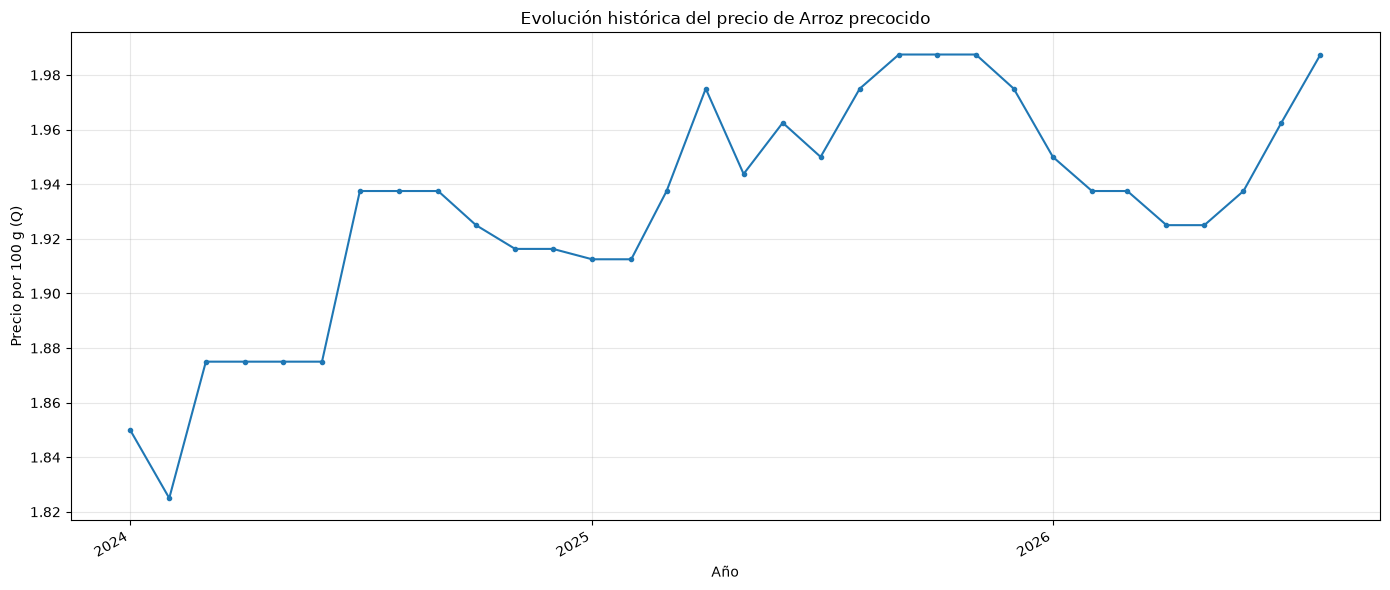

In [18]:
fig, ax = catalog.get('arroz_precocido').plot_timeline('urbana')

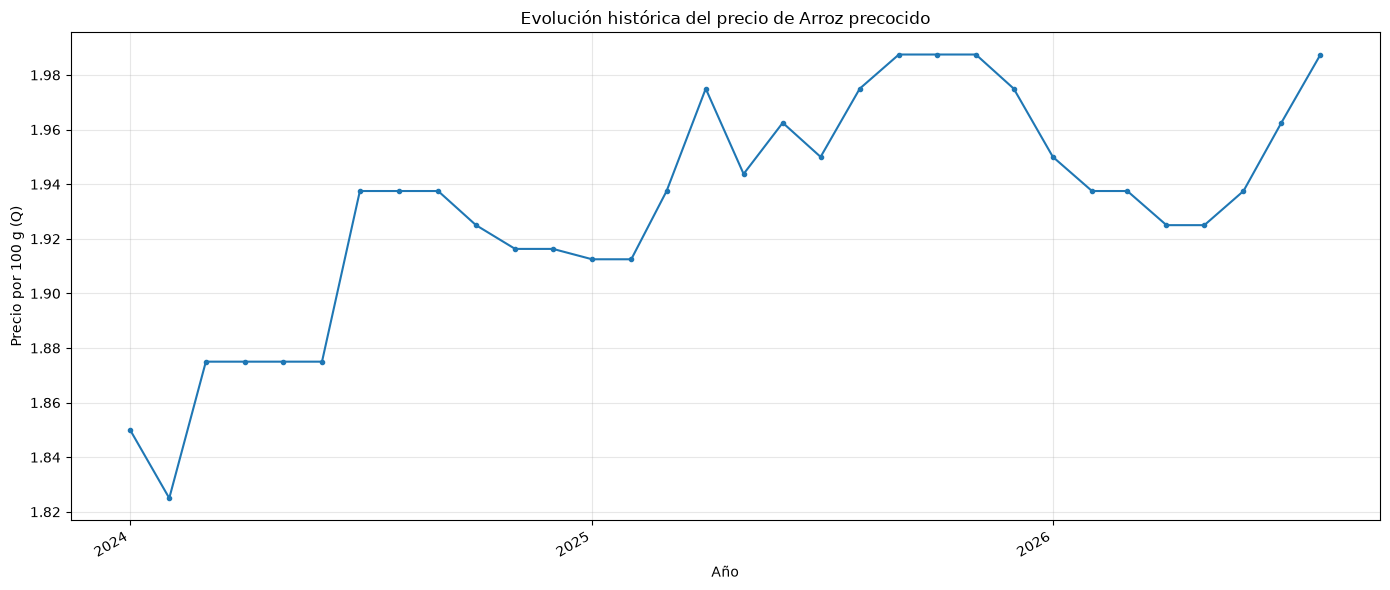

In [19]:
fig, ax = catalog.get('arroz_precocido').plot_timeline('rural')

Los precios se mantienen en ambas regiones asi que usamos la general para resumir la comparacion

Si comparamos el primer punto del ultimo, podemos decir que si hubo un aumento en el precio, pero sin una tendencia clara, muy fluctante en el periodo. 

In [20]:
target_food = catalog.get('arroz_precocido')
food_timeline_summary = target_food.price_summary("general")

labels = {
    "first": "Primer precio registrado",
    "latest": "Último precio registrado",
    "lowest": "Precio más bajo",
    "highest": "Precio más alto",
}

print(f"Resumen de {target_food.name} — región general")
print("=" * 50)

for key, label in labels.items():
    point = food_timeline_summary[key]

    if point is None:
        print(f"{label}: sin información")
        continue

    print(
        f"{label}: "
        f"Q{point.price_per_100g:.2f} por 100 g "
        f"({point.month:02d}/{point.year})"
    )

Resumen de Arroz precocido — región general
Primer precio registrado: Q1.85 por 100 g (01/2024)
Último precio registrado: Q1.99 por 100 g (08/2026)
Precio más bajo: Q1.83 por 100 g (02/2024)
Precio más alto: Q1.99 por 100 g (09/2025)


Dado que, en primer lugar el nombre `arroz corriente` sugiere ser lo mismo que `arroz`; en segunda lugar, en tanto al precio, tanto el precocido como el corriente, tienen una continuidad lógica, sin embargo precio inicial del corriente es mas cercano que el del precocido

Por estos motivos, se procede a mergear datos de cba `arroz corriente` y `arroz`. Y `arroz precocido` queda separado e independiente. 

### Avena de toda clase


In [21]:
food =catalog.get('avena_de_toda_clase')
food.years_by_region()

{'general': [2017, 2018, 2019, 2020, 2021, 2022, 2023],
 'rural': [],
 'urbana': []}

No tiene datos de 2024 a 2026

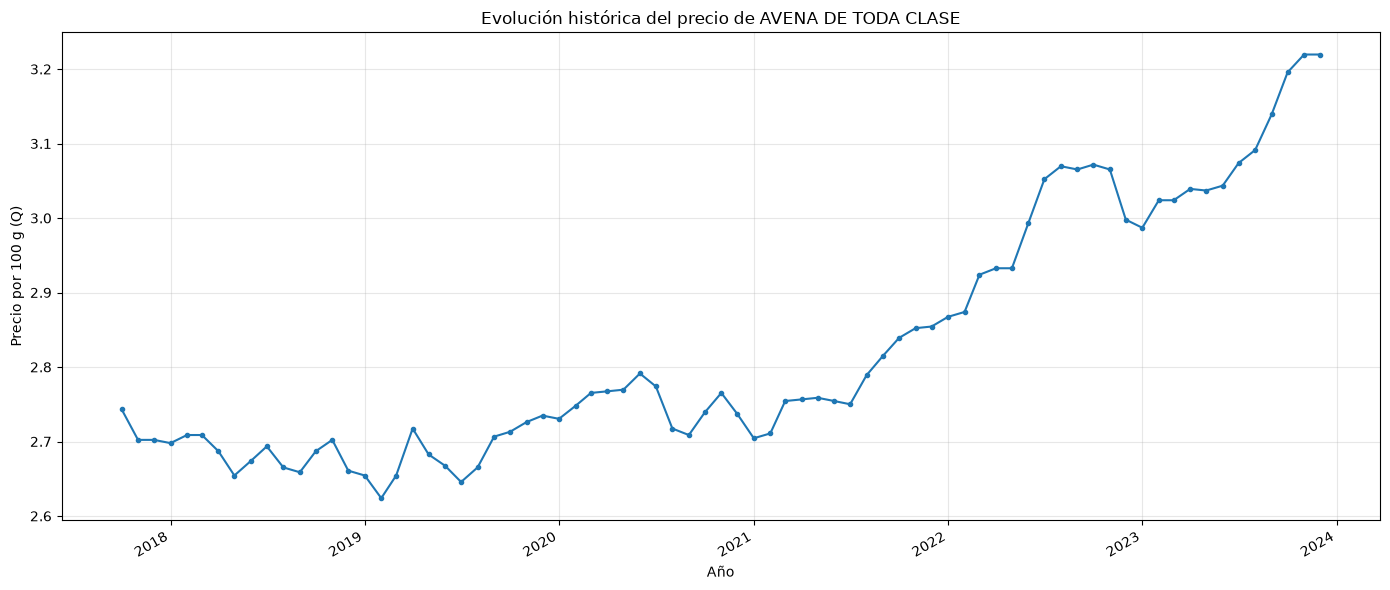

In [22]:
fig, ax = food.plot_timeline('general')

In [23]:
for food in catalog:
    if food.id.startswith('avena'):
        print(food)
        print("===============")
        for region, ptf in food.price_timelines.items(): 
            print(f"Region: {region}")
            print(ptf.avg_daily_grams())

Food(id='avena_de_toda_clase', name='AVENA DE TODA CLASE', category='CEREALES', aliases={'Avena de toda clase', 'AVENA DE TODA CLASE'}, price_timelines={'general': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000023327317390>}, nutrition=None, nutrition_match_score=None, nutrition_match_methods=(), is_meat=False)
Region: general
10.479385045422797
Food(id='avena_mosh', name='Avena/mosh', category=None, aliases={'Avena/mosh'}, price_timelines={'rural': <canasta_inteligente.domain.prices.PriceTimeline object at 0x000002336792AE10>}, nutrition=None, nutrition_match_score=None, nutrition_match_methods=(), is_meat=False)
Region: rural
2.4828176204512586


Por nombre, el candidato a mergear es Avena/Mosh. Aunque unicamente tenga presencia en el area rural 

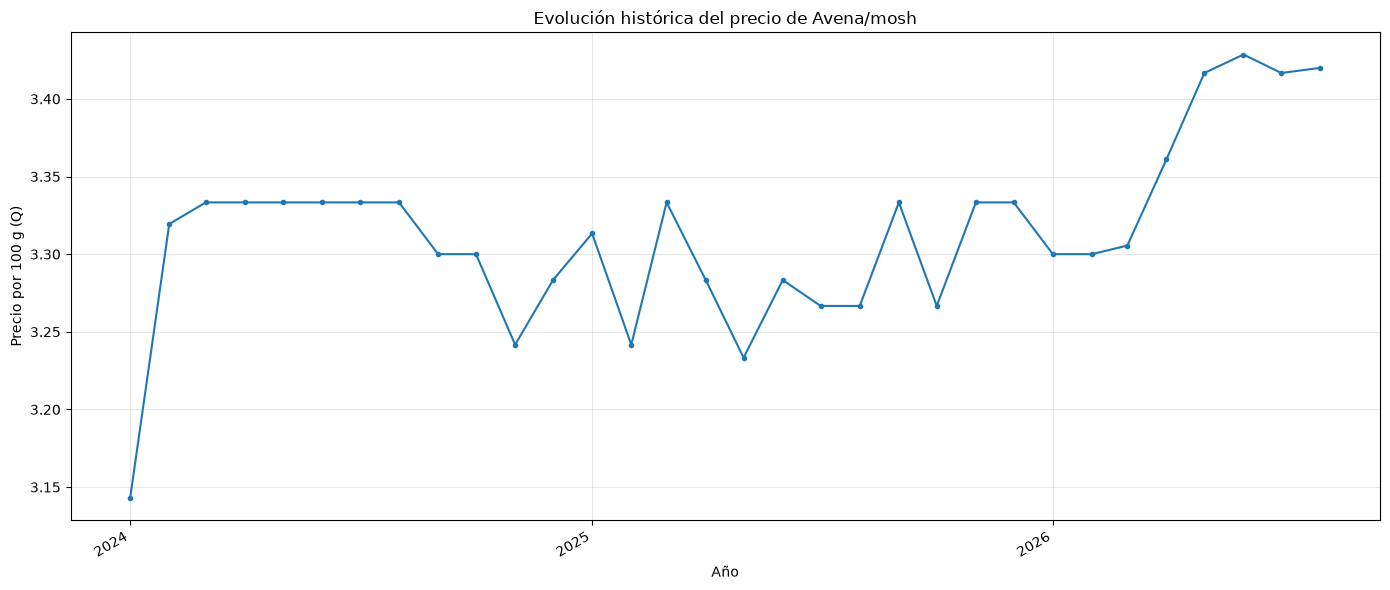

In [24]:
fig, ax = catalog.get('avena_mosh').plot_timeline('rural')

In [25]:
labels = {
    'first': 'Primer precio registrado',
    'latest': 'Último precio registrado',
    'lowest': 'Precio más bajo',
    'highest': 'Precio más alto',
}

for _food, region in [('avena_de_toda_clase', 'general'), ('avena_mosh', 'rural')]:
    target_food = catalog.get(_food)
    print(f'Resumen de {target_food.name} — región {region}')
    print('=' * 50)
    for key, label in labels.items():
        point = target_food.price_summary(region)[key]
        if point is None:
            print(f'{label}: sin información')
            continue
        print(f'{label}: Q{point.price_per_100g:.2f} por 100 g ({point.month:02d}/{point.year})')
    print()

Resumen de AVENA DE TODA CLASE — región general
Primer precio registrado: Q2.74 por 100 g (10/2017)
Último precio registrado: Q3.22 por 100 g (12/2023)
Precio más bajo: Q2.62 por 100 g (02/2019)
Precio más alto: Q3.22 por 100 g (11/2023)

Resumen de Avena/mosh — región rural
Primer precio registrado: Q3.14 por 100 g (01/2024)
Último precio registrado: Q3.42 por 100 g (08/2026)
Precio más bajo: Q3.14 por 100 g (01/2024)
Precio más alto: Q3.43 por 100 g (06/2026)



#### Conclusión

La similitud del nombre y la continuidad observada en los precios respaldan la unificación de `Avena/mosh` con `Avena de toda clase`. 

### Pan Frances

In [26]:
food = catalog.get('pan_frances')

In [27]:
print(food.id)
print(food.years_by_region())

pan_frances
{'general': [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026], 'rural': [2024, 2025, 2026], 'urbana': [2024, 2025, 2026]}


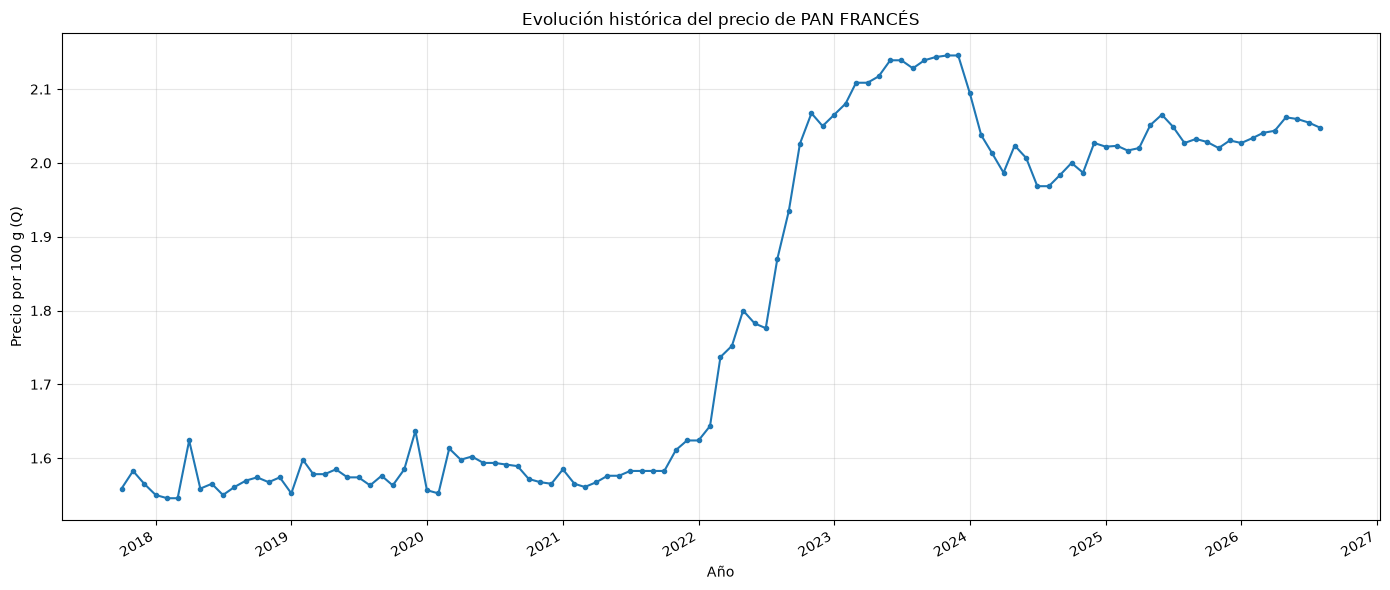

In [28]:
fig, ax = food.plot_timeline('general')

No es requerida ninguna accion adicional 

### Pan Dulce

In [29]:
food = catalog.get('pan_dulce')
print()

pan_dulce
{'general': [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026], 'rural': [2024, 2025, 2026], 'urbana': [2024, 2025, 2026]}


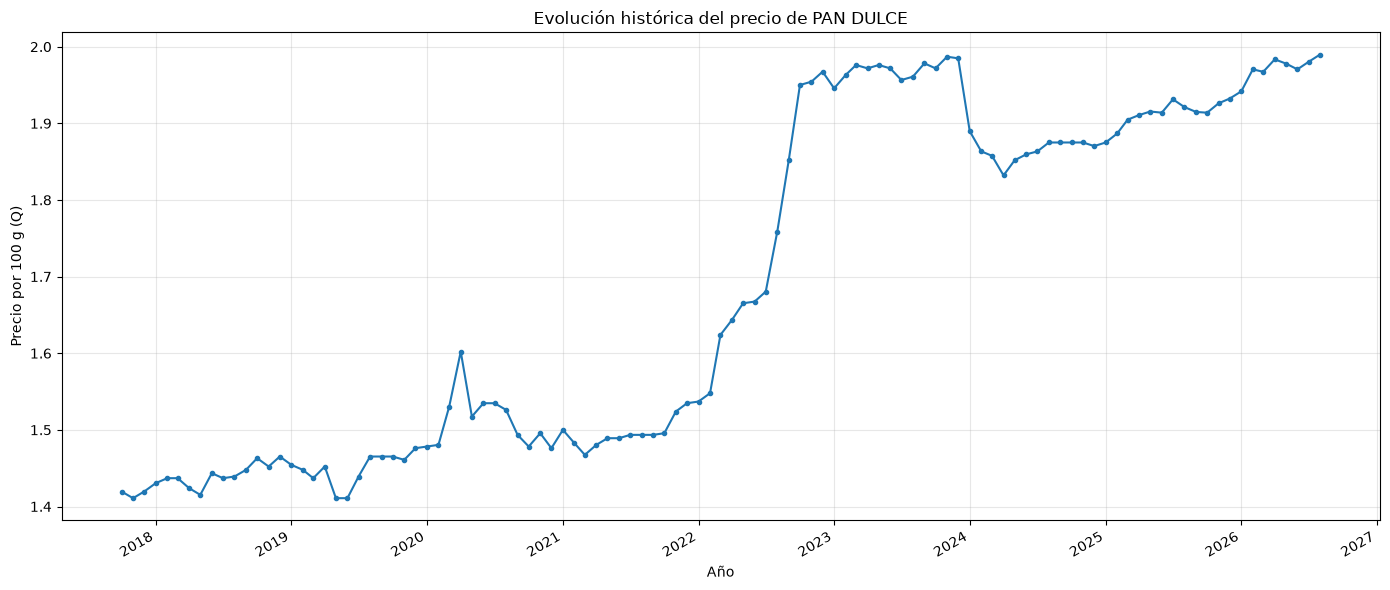

In [30]:
print(food.id)
print(food.years_by_region())
fig, ax = food.plot_timeline('general')

No es requerida ninguna accion adicional 

### Fideos

In [31]:
food = catalog.get('fideos')
print(food.id)

fideos


{'general': [2017, 2018, 2019, 2020], 'rural': [], 'urbana': []}


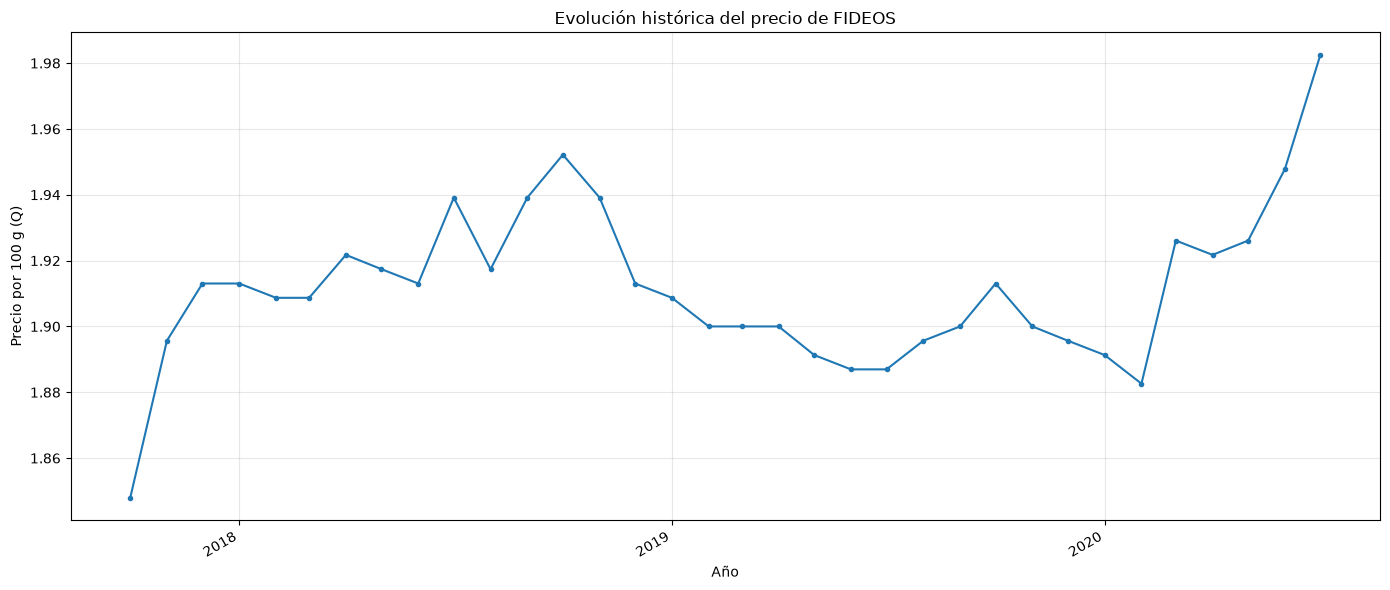

In [32]:
food = catalog.get('fideos')
print(food.years_by_region())
fig, ax = food.plot_timeline('general')

In [33]:
labels = {
    'first': 'Primer precio registrado',
    'latest': 'Último precio registrado',
    'lowest': 'Precio más bajo',
    'highest': 'Precio más alto',
}
region = 'general'
print(f'Resumen de {food.name} — región {region}')
print('=' * 50)
for key, label in labels.items():
    point = food.price_summary(region)[key]
    if point is None:
        print(f'{label}: sin información')
        continue
    print(f'{label}: Q{point.price_per_100g:.2f} por 100 g ({point.month:02d}/{point.year})')
print()

Resumen de FIDEOS — región general
Primer precio registrado: Q1.85 por 100 g (10/2017)
Último precio registrado: Q1.98 por 100 g (07/2020)
Precio más bajo: Q1.85 por 100 g (10/2017)
Precio más alto: Q1.98 por 100 g (07/2020)



La serie original de `FIDEOS` termina en julio de 2020. Es necesario buscar candidatos que permitan completar el periodo posterior.

In [34]:
candidates = [
    catalog.get('fideos_en_todas_sus_formas_excepto_macarrones_y_espagueti'),
]

for candidate in candidates:
    print(candidate.name)
    print(candidate.years_by_region())
    for region, timeline in candidate.price_timelines.items():
        print(f'Consumo diario promedio ({region}): {timeline.avg_daily_grams():.2f} g')
    print()

labels = {
    'first': 'Primer precio registrado',
    'latest': 'Último precio registrado',
    'lowest': 'Precio más bajo',
    'highest': 'Precio más alto',
}


Fideos en todas sus formas (Excepto macarrones y espagueti)
{'general': [2024, 2025, 2026], 'rural': [2024, 2025, 2026], 'urbana': [2024, 2025, 2026]}
Consumo diario promedio (rural): 6.63 g
Consumo diario promedio (urbana): 5.86 g
Consumo diario promedio (general): 6.24 g



Resumen de Fideos en todas sus formas (Excepto macarrones y espagueti) — región rural
Primer precio registrado: Q2.25 por 100 g (01/2024)
Último precio registrado: Q2.20 por 100 g (08/2026)
Precio más bajo: Q2.09 por 100 g (02/2024)
Precio más alto: Q2.25 por 100 g (01/2024)

Resumen de Fideos en todas sus formas (Excepto macarrones y espagueti) — región urbana
Primer precio registrado: Q2.25 por 100 g (01/2024)
Último precio registrado: Q2.20 por 100 g (08/2026)
Precio más bajo: Q2.09 por 100 g (02/2024)
Precio más alto: Q2.25 por 100 g (01/2024)

Resumen de Fideos en todas sus formas (Excepto macarrones y espagueti) — región general
Primer precio registrado: Q2.25 por 100 g (01/2024)
Último precio registrado: Q2.20 por 100 g (08/2026)
Precio más bajo: Q2.09 por 100 g (02/2024)
Precio más alto: Q2.25 por 100 g (01/2024)



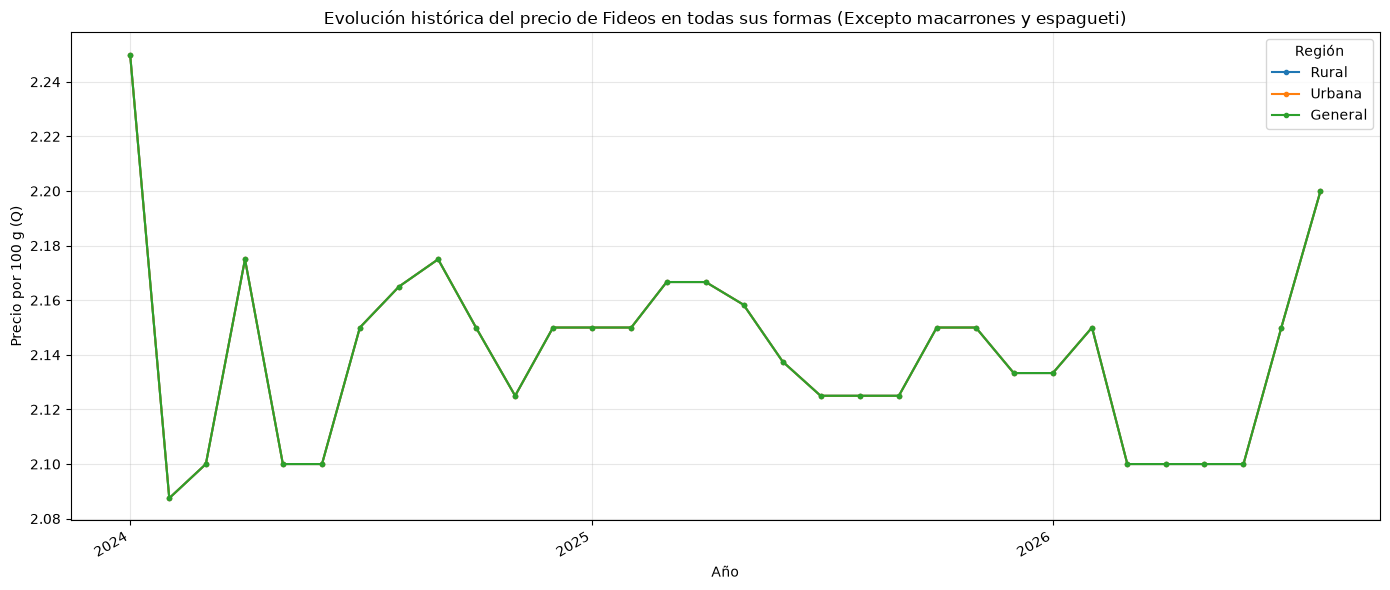

In [35]:
for _food in candidates:
    fig, ax = _food.plot_timeline()
    for _region in ('rural', 'urbana', 'general'):
        print(f'Resumen de {_food.name} — región {_region}')
        print('=' * 50)
        for key, label in labels.items():
            point = _food.price_summary(_region)[key]
            if point is None:
                print(f'{label}: sin información')
                continue
            print(f'{label}: Q{point.price_per_100g:.2f} por 100 g ({point.month:02d}/{point.year})')
        print()

`Fideos en todas sus formas (excepto macarrones y espagueti)` cubre desde enero de 2024. Su primer precio general es Q2.25 por 100 g, cercano al último precio de 2023, pero todavía debemos cubrir agosto de 2020 a diciembre de 2023.

PASTAS ALIMENTICIAS
{'general': [2020], 'rural': [], 'urbana': []}
Resumen de PASTAS ALIMENTICIAS — región rural
Primer precio registrado: sin información
Último precio registrado: sin información
Precio más bajo: sin información
Precio más alto: sin información

Resumen de PASTAS ALIMENTICIAS — región urbana
Primer precio registrado: sin información
Último precio registrado: sin información
Precio más bajo: sin información
Precio más alto: sin información

Resumen de PASTAS ALIMENTICIAS — región general
Primer precio registrado: Q2.00 por 100 g (08/2020)
Último precio registrado: Q2.00 por 100 g (08/2020)
Precio más bajo: Q2.00 por 100 g (08/2020)
Precio más alto: Q2.00 por 100 g (08/2020)

PASTAS DE TODOS LOS TIPOS
{'general': [2020, 2021, 2022, 2023], 'rural': [], 'urbana': []}
Resumen de PASTAS DE TODOS LOS TIPOS — región rural
Primer precio registrado: sin información
Último precio registrado: sin información
Precio más bajo: sin información
Precio más alto: sin información

Resum

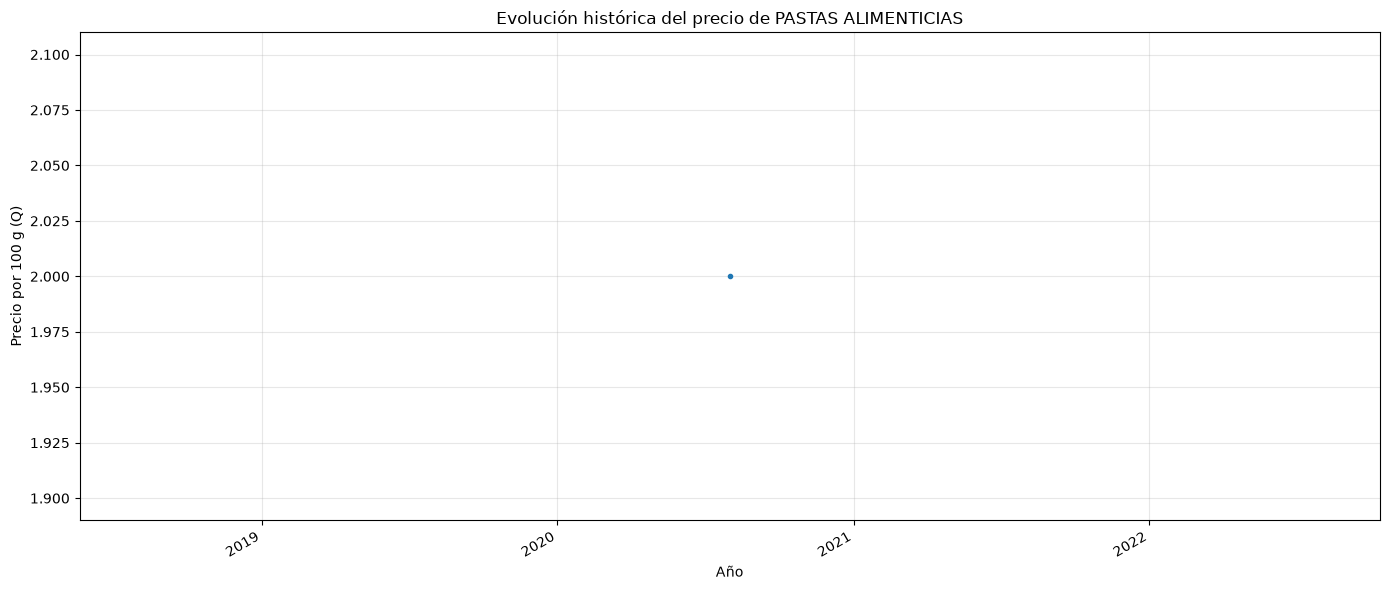

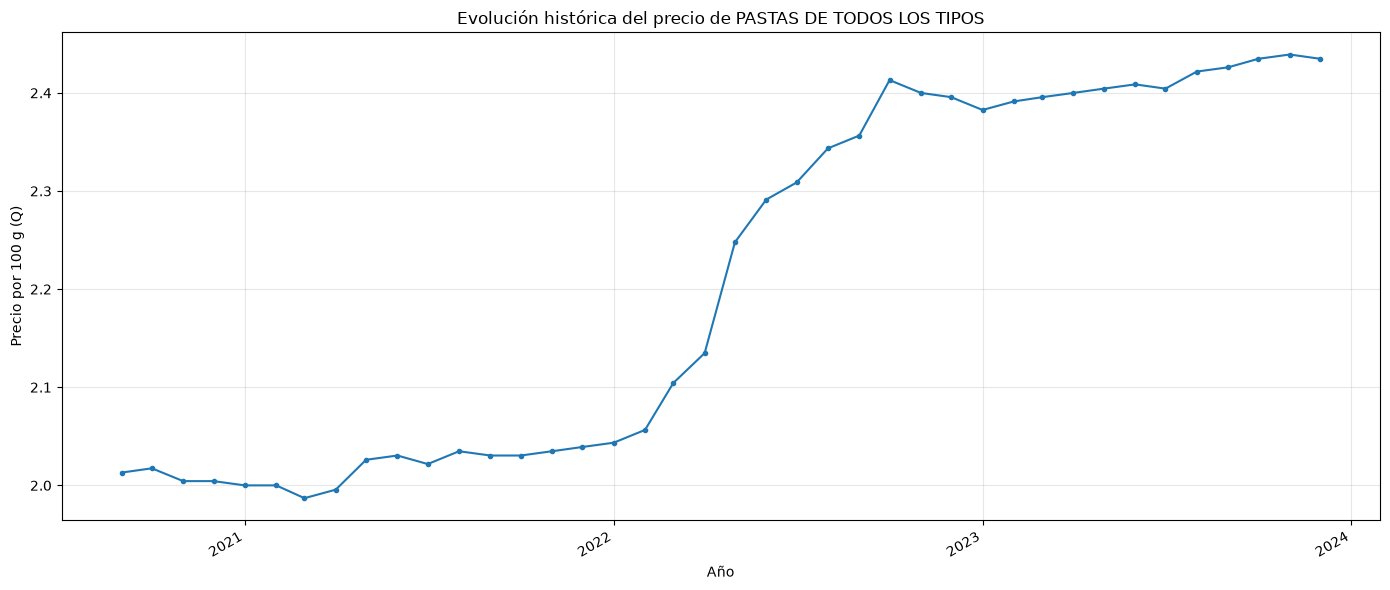

In [36]:
other_candidates = [
    catalog.get('pastas_alimenticias'),
    catalog.get('pastas_de_todos_los_tipos'),
]
for _food in other_candidates:
    print(_food.name)
    print(_food.years_by_region())
    fig, ax = _food.plot_timeline('general')
    for _region in ('rural', 'urbana', 'general'):
        print(f'Resumen de {_food.name} — región {_region}')
        print('=' * 50)
        for key, label in labels.items():
            point = _food.price_summary(_region)[key]
            if point is None:
                print(f'{label}: sin información')
                continue
            print(f'{label}: Q{point.price_per_100g:.2f} por 100 g ({point.month:02d}/{point.year})')
        print()

candidates += other_candidates

#### Conclusión

Los candidatos forman una serie temporal continua y sus precios de enlace son coherentes: `FIDEOS` termina en julio de 2020 con Q1.98 por 100 g; `PASTAS ALIMENTICIAS` aporta agosto de 2020 con Q2.00; `PASTAS DE TODOS LOS TIPOS` comienza en septiembre de 2020 con Q2.01 y llega a diciembre de 2023 con Q2.43; finalmente, `Fideos en todas sus formas (excepto macarrones y espagueti)` comienza en enero de 2024 con Q2.25.

Por nombre, cobertura temporal y continuidad de precios, se unifican los tres candidatos con `FIDEOS`. Los macarrones y el espagueti quedan excluidos porque el propio nombre del candidato regional los distingue.

### Tortillas de Maiz

In [37]:
food = catalog.get('tortillas_de_maiz')
food

Food(id='tortillas_de_maiz', name='TORTILLAS DE MAÍZ', category='CEREALES', aliases={'TORTILLAS DE MAÍZ', 'Tortillas de maíz'}, price_timelines={'general': <canasta_inteligente.domain.prices.PriceTimeline object at 0x00000233273696D0>}, nutrition=None, nutrition_match_score=None, nutrition_match_methods=(), is_meat=False)

{'general': [2017, 2018, 2019, 2020, 2021, 2022, 2023], 'rural': [], 'urbana': []}


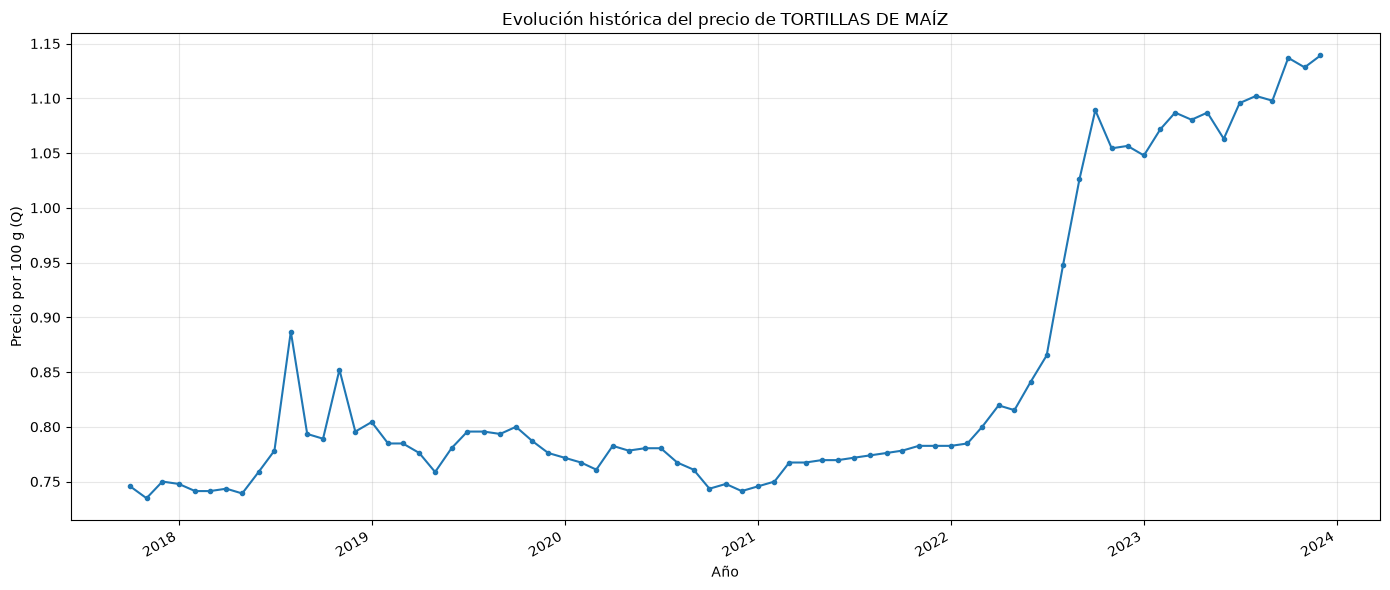

In [38]:
print(food.years_by_region())
fig, ax = food.plot_timeline('general')

In [39]:
for food in catalog:
    if food.id.startswith('tortilla') and food.id != 'tortillas_de_maiz':
        print(food)
        print("===============")
        for region, ptf in food.price_timelines.items(): 
            print(f"Region: {region}")
            print(ptf.avg_daily_grams())

Food(id='tortillas_frescas', name='Tortillas frescas', category=None, aliases={'Tortillas frescas'}, price_timelines={'rural': <canasta_inteligente.domain.prices.PriceTimeline object at 0x000002336792AC90>, 'urbana': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000023367A3B770>, 'general': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000023367864F50>}, nutrition=None, nutrition_match_score=None, nutrition_match_methods=(), is_meat=False)
Region: rural
305.8934378575231
Region: urbana
267.424457457515
Region: general
286.65894765751904


{'general': [2024, 2025, 2026], 'rural': [2024, 2025, 2026], 'urbana': [2024, 2025, 2026]}


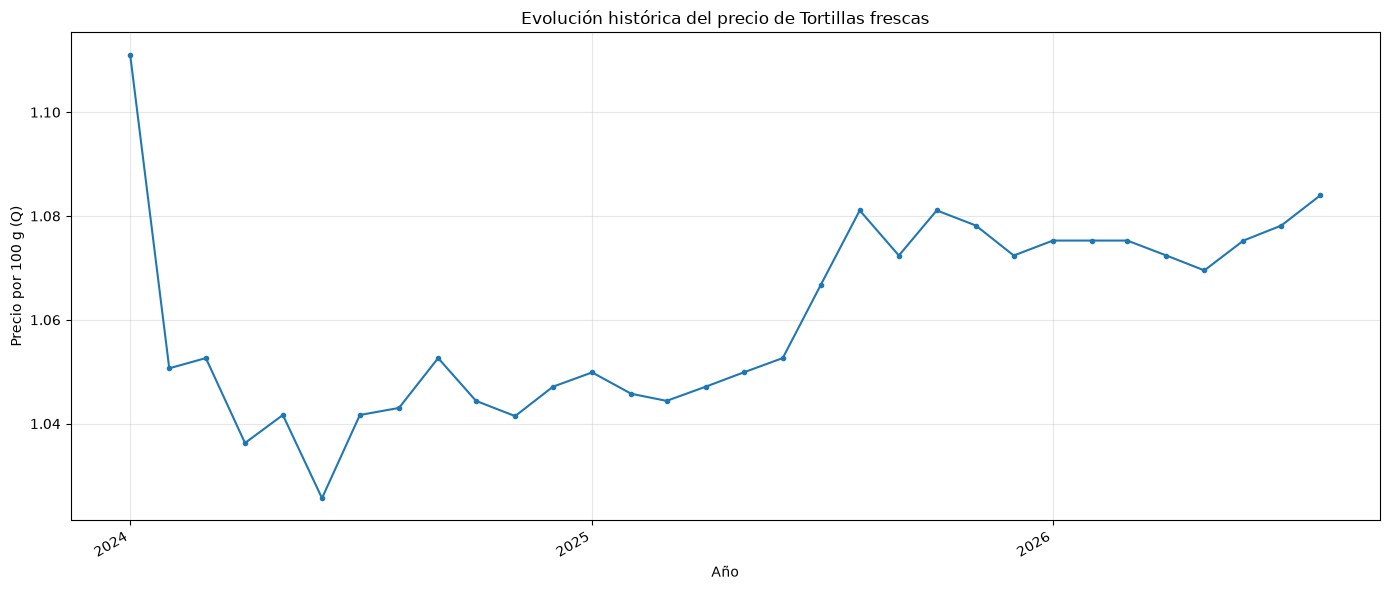

In [40]:
print(catalog.get('tortillas_frescas').years_by_region())
fig, ax = catalog.get('tortillas_frescas').plot_timeline('general')

Continuidad de precio corresponde.

### Carne de res sin hueso

{'general': [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026], 'rural': [2024, 2025, 2026], 'urbana': [2024, 2025, 2026]}


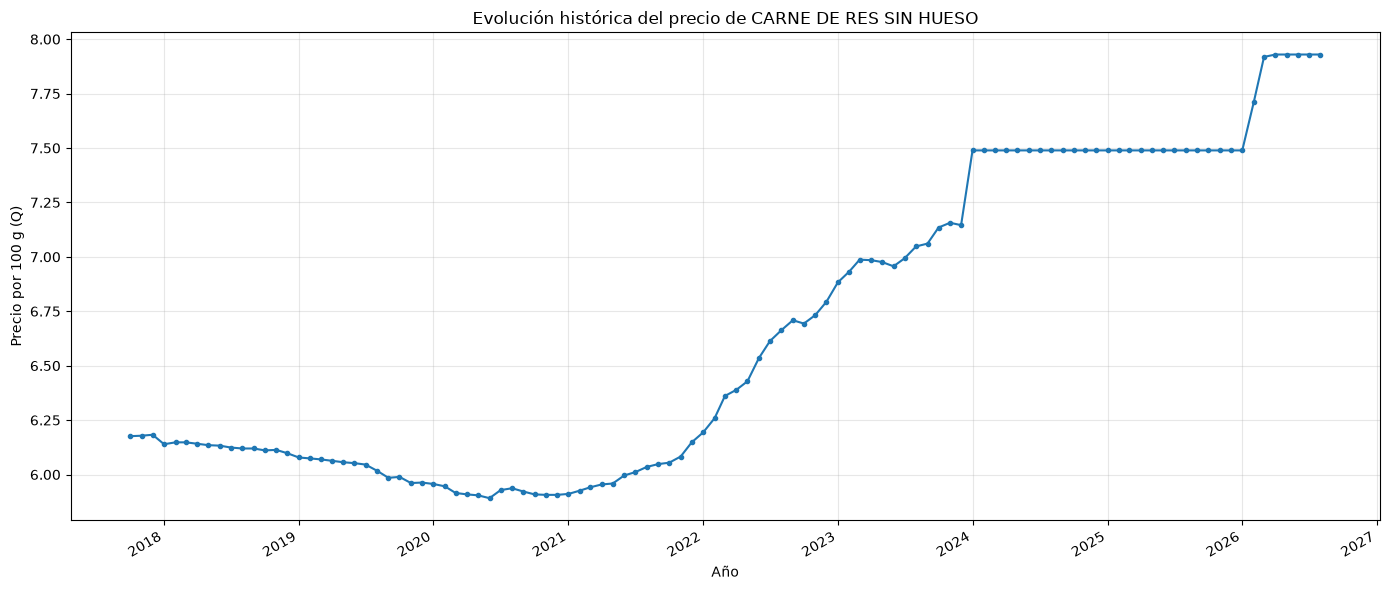

In [41]:
food = catalog.get('carne_de_res_sin_hueso')
food
print(food.years_by_region())
fig, ax = food.plot_timeline('general')

Periodo completo, sin cambios requeridos. 

### Carne de res con hueso

{'general': [2017, 2018, 2019, 2020, 2021, 2022, 2023], 'rural': [], 'urbana': []}


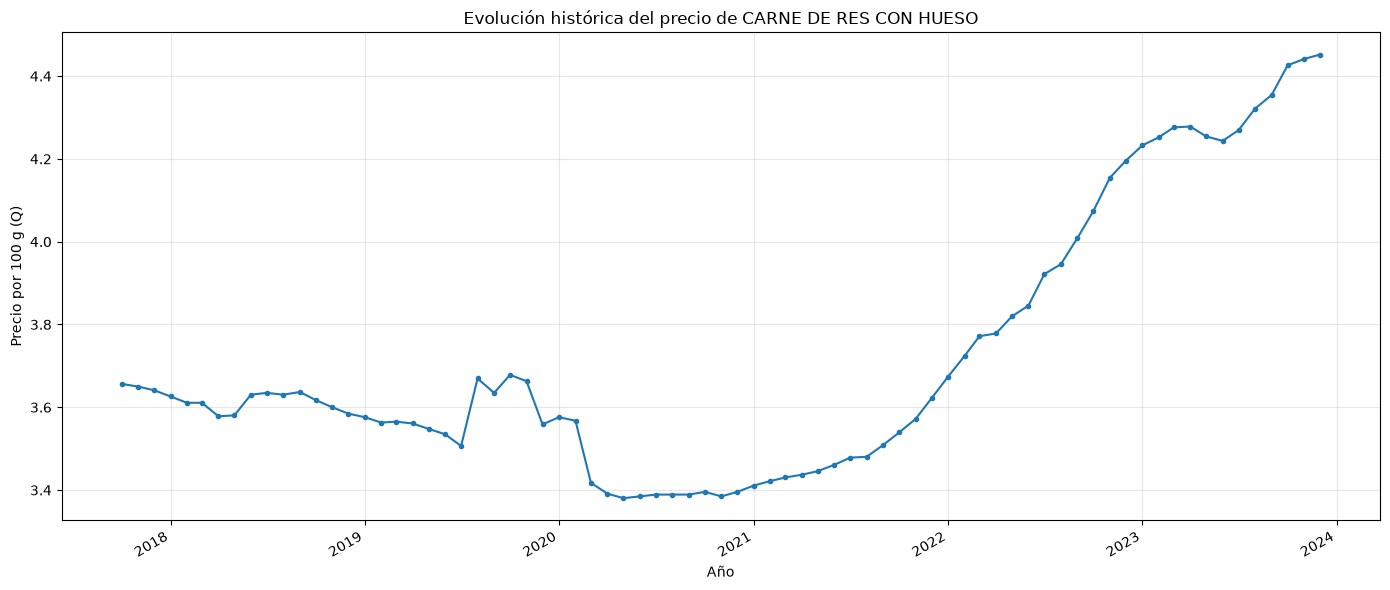

In [42]:
food = catalog.get('carne_de_res_con_hueso')
food
print(food.years_by_region())
fig, ax = food.plot_timeline('general')

In [43]:
candidates = [_food for _food in catalog if 'res' in _food.id and 'con' in _food.id and 'carne' in _food.id and 'hueso' in _food.id   ]
candidates.pop(0) # ELIMINAMOS el que ya esta incluido 
candidates

[Food(id='carne_de_res_con_hueso_para_cocido', name='Carne de res con hueso para cocido', category=None, aliases={'Carne de res con hueso para cocido'}, price_timelines={'rural': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000023367A5D790>, 'urbana': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000023367C39550>, 'general': <canasta_inteligente.domain.prices.PriceTimeline object at 0x00000233678679B0>}, nutrition=None, nutrition_match_score=None, nutrition_match_methods=(), is_meat=False),
 Food(id='carne_de_res_para_asar_con_y_sin_hueso', name='Carne de res para asar (con y sin hueso)', category=None, aliases={'Carne de res para asar (con y sin hueso)'}, price_timelines={'urbana': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000023367C394F0>}, nutrition=None, nutrition_match_score=None, nutrition_match_methods=(), is_meat=False)]

{'general': [2024, 2025, 2026], 'rural': [2024, 2025, 2026], 'urbana': [2024, 2025, 2026]}


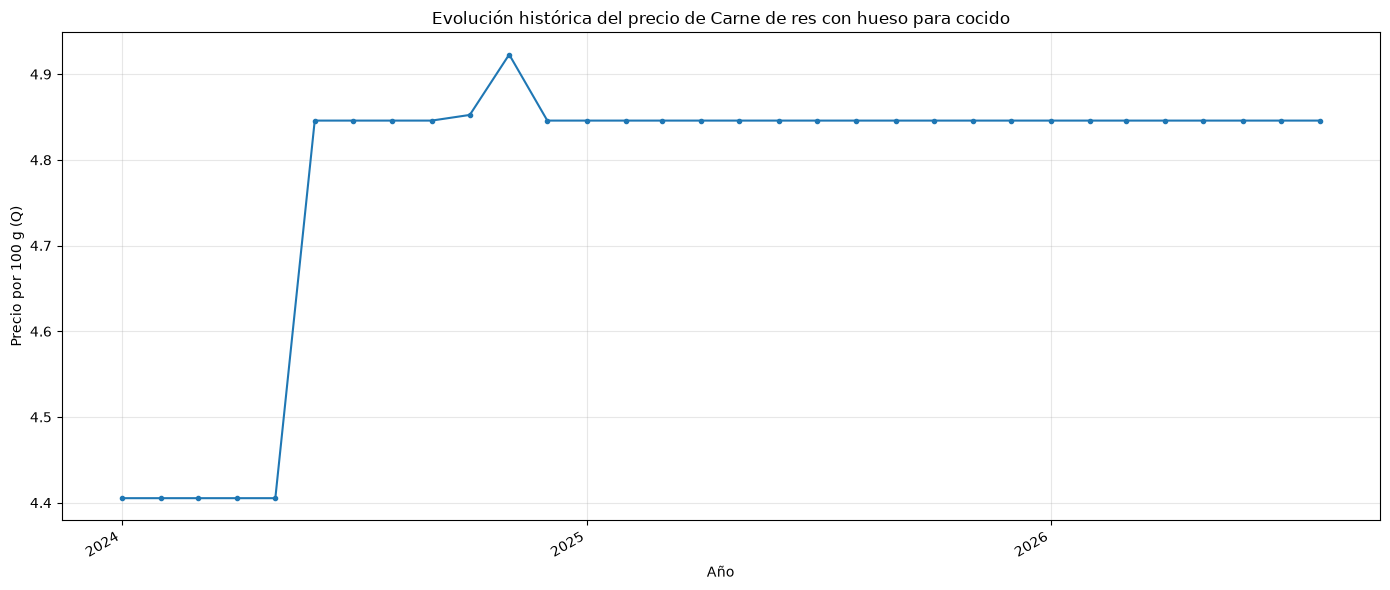

In [44]:
_candidate_2 = catalog.get('carne_de_res_con_hueso_para_cocido')
print(_candidate_2.years_by_region())
fig, ax = _candidate_2.plot_timeline('general')

{'general': [], 'rural': [], 'urbana': [2024, 2025, 2026]}


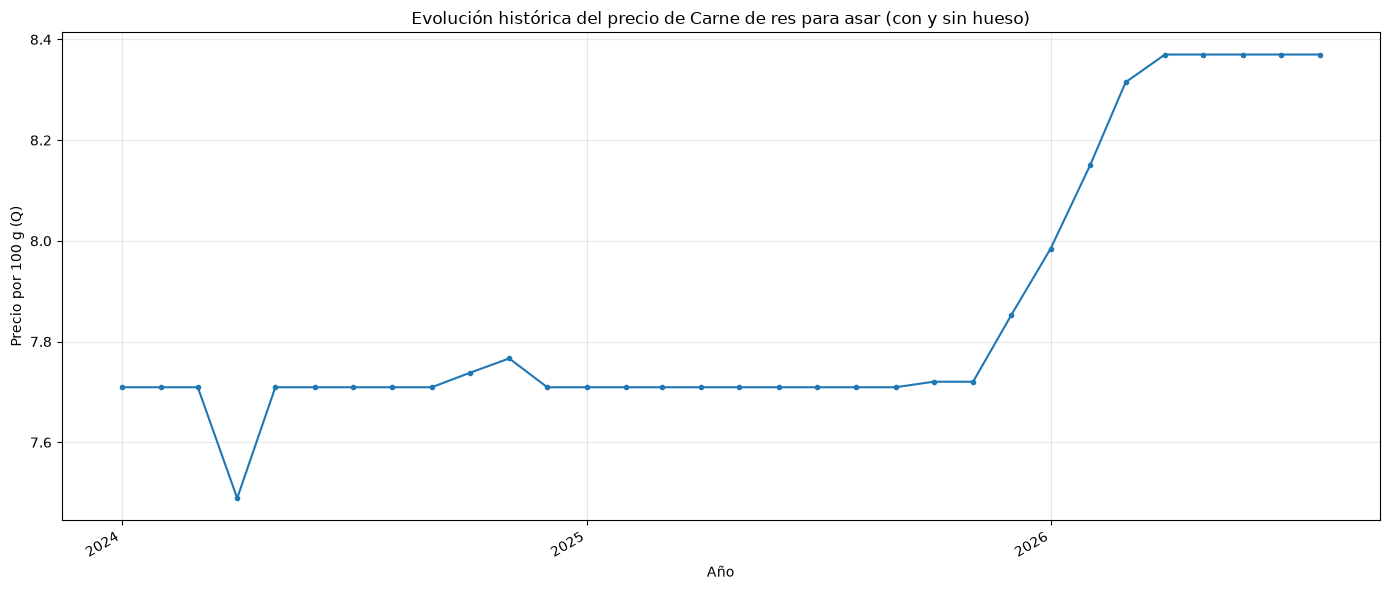

In [45]:
_candidate_2 = catalog.get('carne_de_res_para_asar_con_y_sin_hueso')
print(_candidate_2.years_by_region())
fig, ax = _candidate_2.plot_timeline('urbana')

Por continuidad de precio y por la especificacion de que es **con** hueso, el candidato correctao a mergear es `carne_de_res_con_hueso_para_cocido`

### Carne de cerdo sin hueso

{'general': [2017, 2018, 2019, 2020, 2021, 2022, 2023], 'rural': [], 'urbana': []}


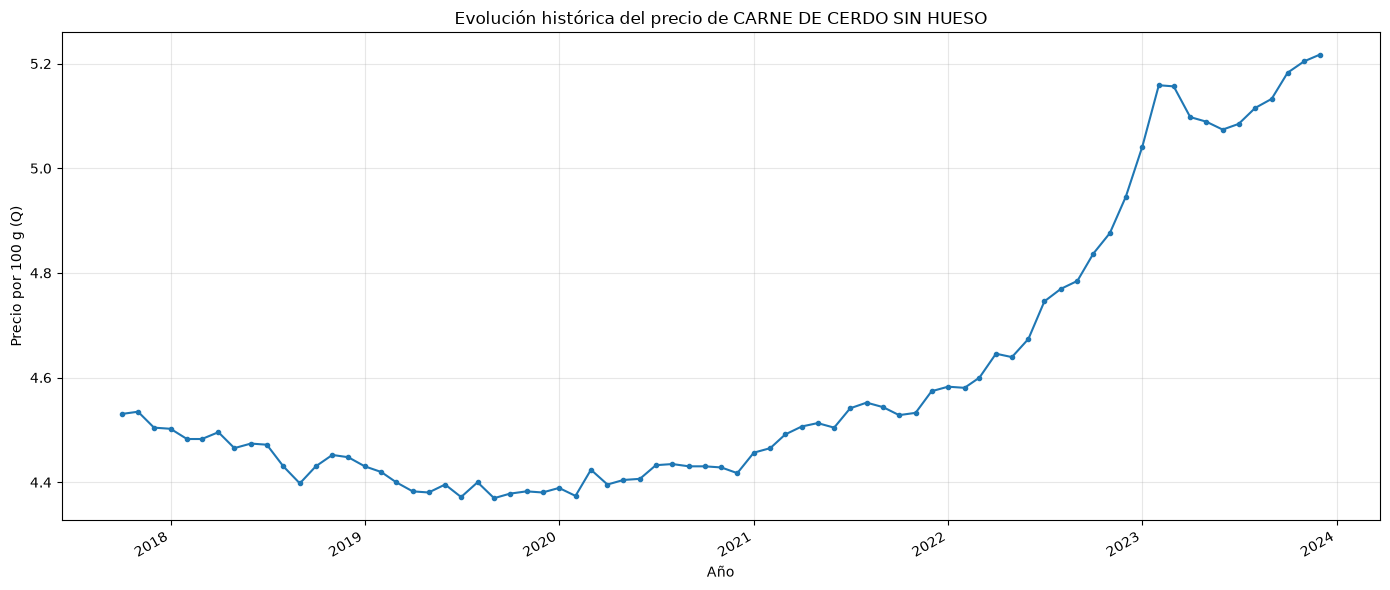

In [46]:
food = catalog.get('carne_de_cerdo_sin_hueso')
food
print(food.years_by_region())
fig, ax = food.plot_timeline('general')

In [47]:
candidates = [_food for _food in catalog if 'cerdo' in _food.id and 'posta' in _food.id  ]
#candidates.pop(0) # ELIMINAMOS el que ya esta incluido 
candidates

[Food(id='posta_de_cerdo_sin_hueso', name='Posta de cerdo sin hueso', category=None, aliases={'Posta de cerdo sin hueso'}, price_timelines={'urbana': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000023367C39730>}, nutrition=None, nutrition_match_score=None, nutrition_match_methods=(), is_meat=False)]

{'general': [], 'rural': [], 'urbana': [2024, 2025, 2026]}


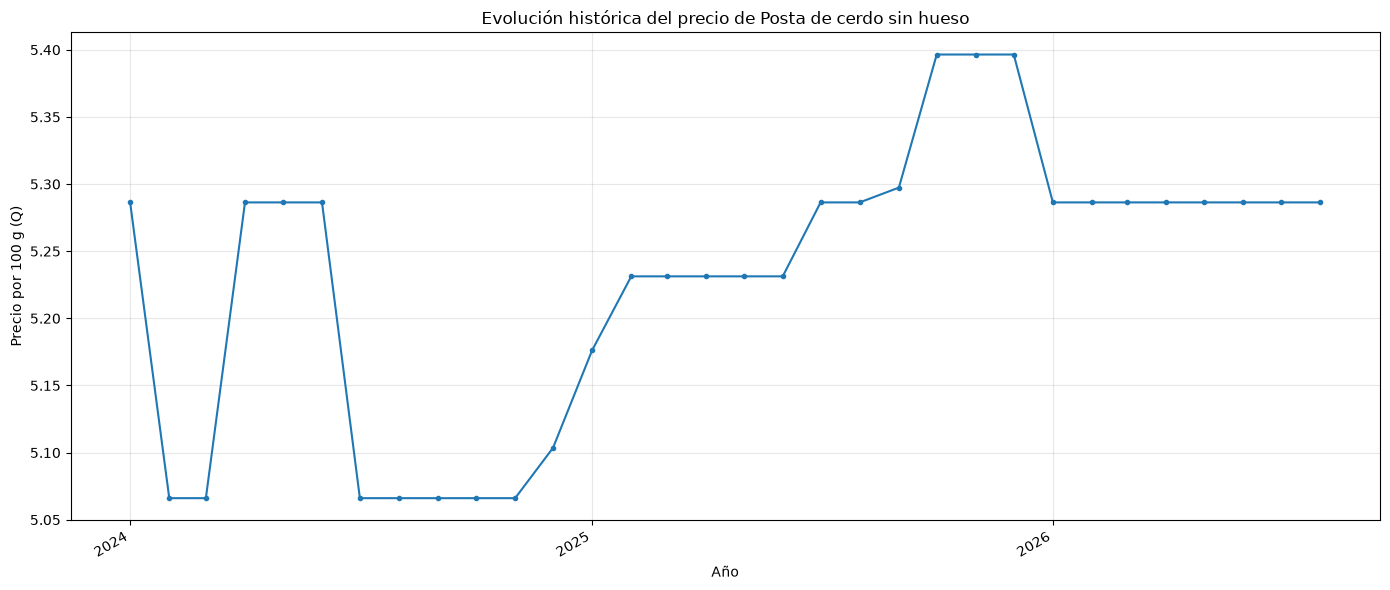

In [48]:
_candidate_2 = catalog.get('posta_de_cerdo_sin_hueso')
food
print(_candidate_2.years_by_region())
fig, ax = _candidate_2.plot_timeline('urbana')

Aunque sin la presencia en el area rural, la `posta_de_cerdo_sin_hueso` sigue una continuidad considerable con los precios de `carne_de_cerdo_sin_hueso`. Conceptualmente la carne no es lo mismo que la posta, segun de que seccion del cerdo que se extraiga pero el precio sigue una continuidad aceptable, por este motivo principal se mergea estos alimento, aclarando que es una cuestion de conveniencia mas no precisan de la misma definicion de un alimento a otro. 

### Carne de pollo o gallina

{'general': [2017, 2018, 2019, 2020, 2021, 2022, 2023], 'rural': [], 'urbana': []}


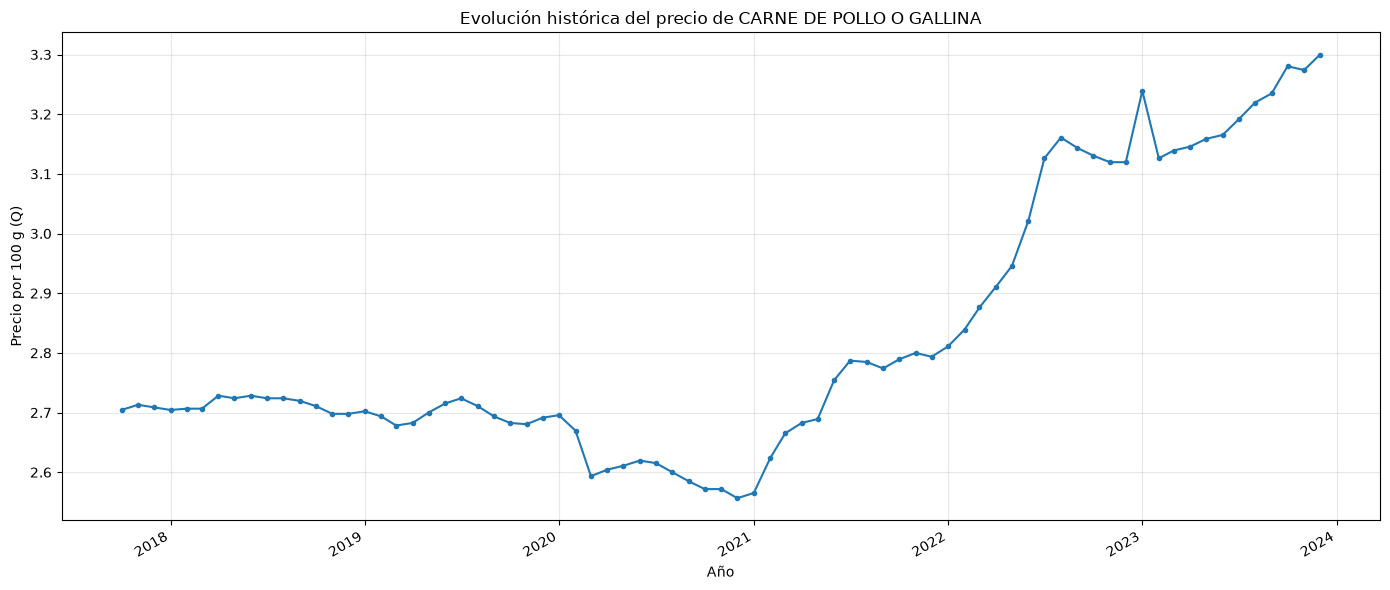

In [49]:
food = catalog.get('carne_de_pollo_o_gallina')
food
print(food.years_by_region())
fig, ax = food.plot_timeline('general')

In [50]:
candidates = [_food for _food in catalog if 'pollo' in _food.id  or  'gallina' in _food.id and 'repollo' not in _food.id ]
candidates = [_food for _food in candidates if 'carne' in _food.id and 'almuerzo' not in _food.id ]
candidates.pop(0) # ELIMINAMOS el que ya esta incluido 
candidates

[Food(id='carne_de_pollo_blanco', name='Carne de pollo blanco', category=None, aliases={'Carne de pollo blanco'}, price_timelines={'rural': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000023367A5D910>, 'urbana': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000023367C39130>, 'general': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000023367867A70>}, nutrition=None, nutrition_match_score=None, nutrition_match_methods=(), is_meat=False),
 Food(id='carne_de_pollo_amarillo', name='Carne de pollo amarillo', category=None, aliases={'Carne de pollo amarillo'}, price_timelines={'rural': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000023367A5DA90>, 'urbana': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000023367C39790>, 'general': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000023367867170>}, nutrition=None, nutrition_match_score=None, nutrition_match_methods=(), is_meat=False)]

{'general': [2024, 2025, 2026], 'rural': [2024, 2025, 2026], 'urbana': [2024, 2025, 2026]}


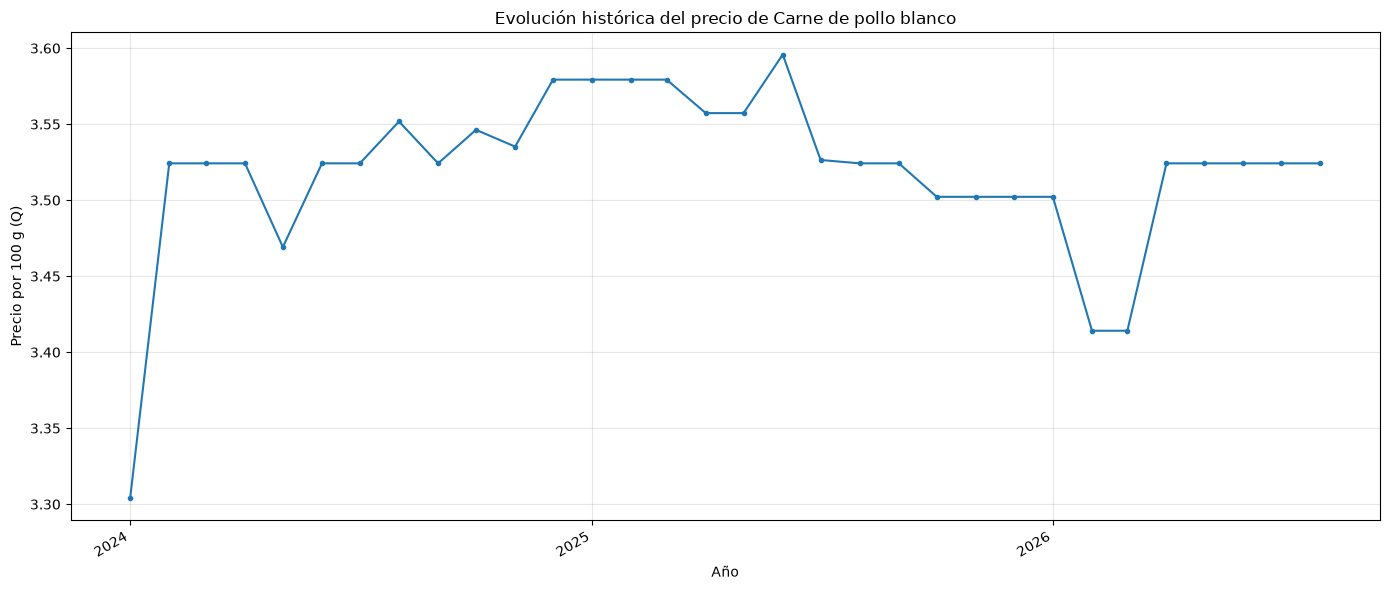

In [51]:
_candidate_2 = catalog.get('carne_de_pollo_blanco')
print(_candidate_2.years_by_region())
fig, ax = _candidate_2.plot_timeline('urbana')

{'general': [2024, 2025, 2026], 'rural': [2024, 2025, 2026], 'urbana': [2024, 2025, 2026]}


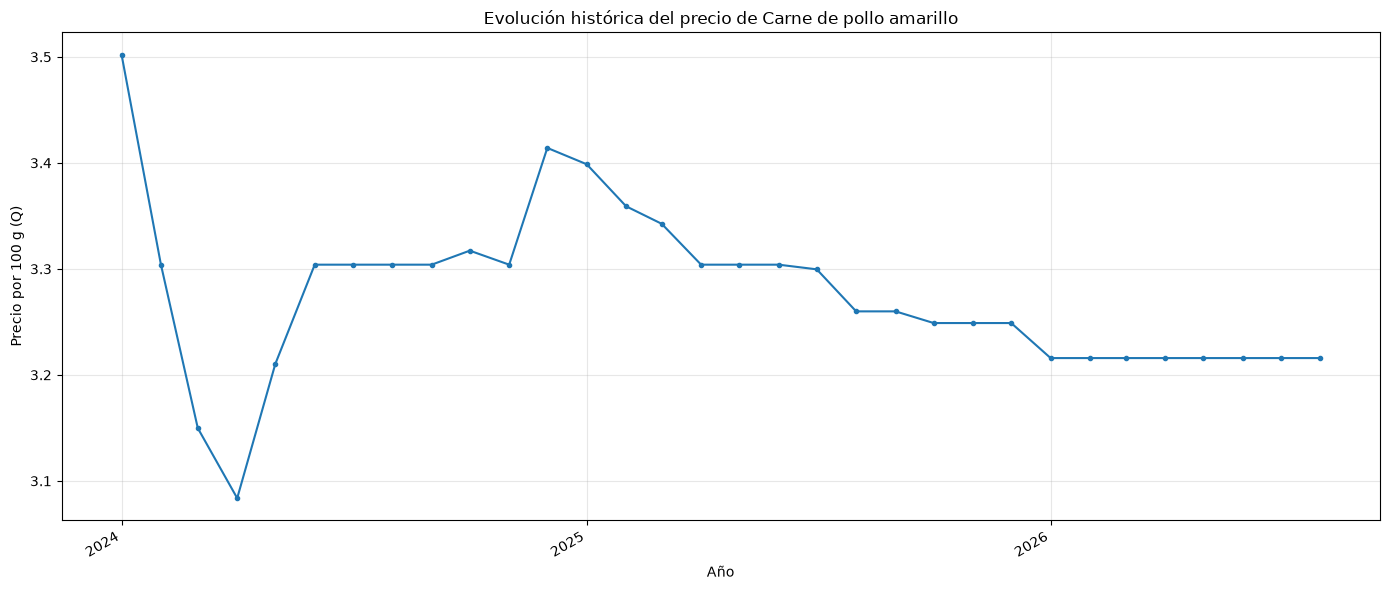

In [52]:
_candidate_2 = catalog.get('carne_de_pollo_amarillo')
print(_candidate_2.years_by_region())
fig, ax = _candidate_2.plot_timeline('urbana')

Por tendencia y mejor continuidad con el precio el alimento que da mejor continuidad a `carne_de_pollo_o_gallina` es `carne_de_pollo_blanco`. 

### Embutidos

{'general': [2017, 2018, 2019, 2020, 2021, 2022, 2023], 'rural': [], 'urbana': []}


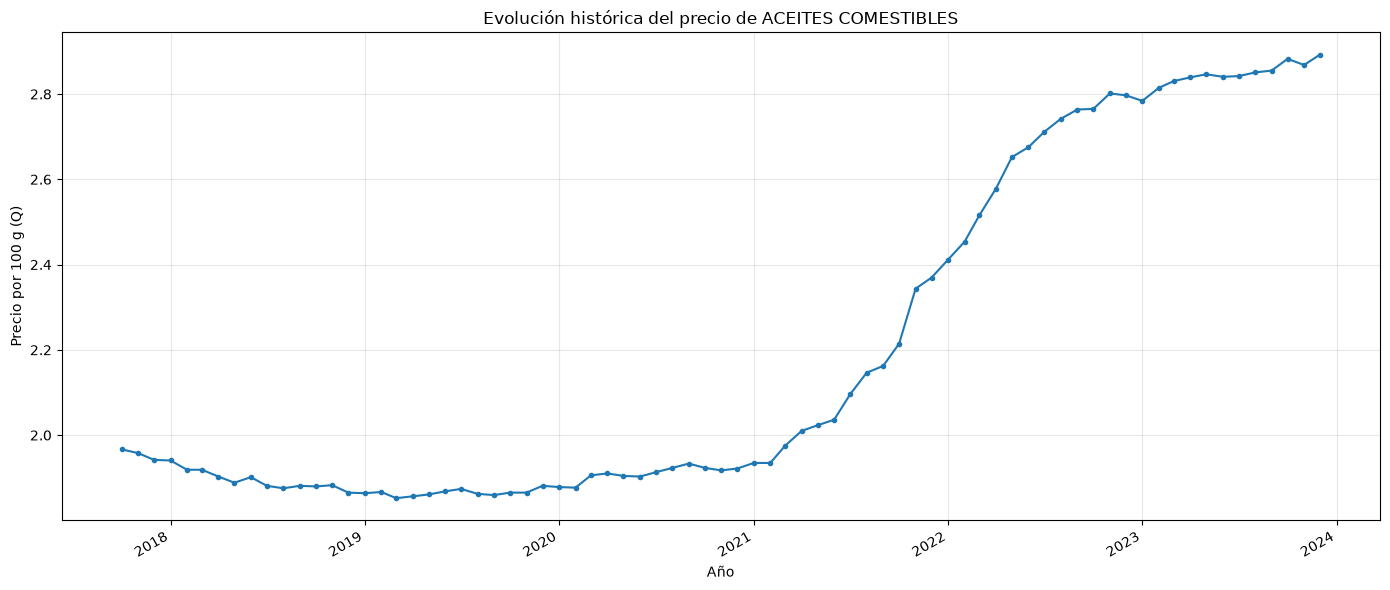

In [53]:
food = catalog.get('aceites_comestibles')
print(food.years_by_region())
fig, ax = food.plot_timeline('general')

In [54]:
candidates = [_food for _food in catalog if 'aceite' in _food.id ]
candidates.pop(0)
candidates

[Food(id='aceite_vegetal_mixtos', name='Aceite vegetal mixtos', category=None, aliases={'Aceite vegetal mixtos'}, price_timelines={'rural': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000023367A5CD70>, 'urbana': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000023367C389B0>, 'general': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000023367867D70>}, nutrition=None, nutrition_match_score=None, nutrition_match_methods=(), is_meat=False)]

{'general': [2024, 2025, 2026], 'rural': [2024, 2025, 2026], 'urbana': [2024, 2025, 2026]}


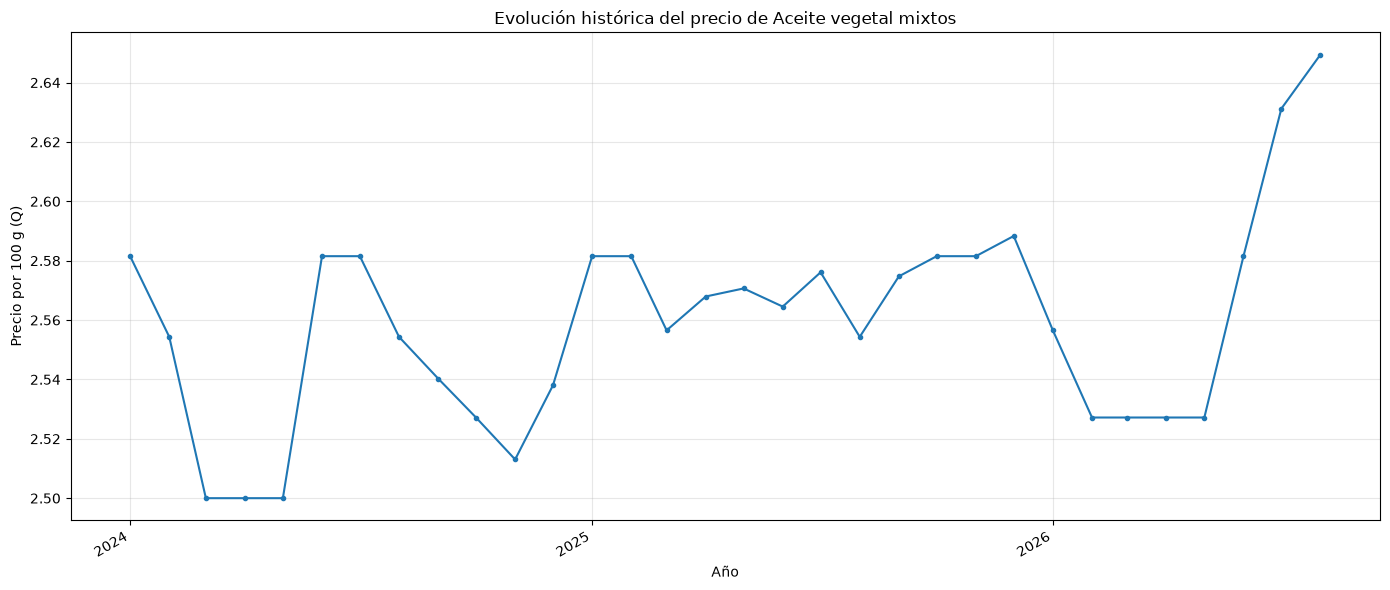

In [55]:
_candidate_1 = catalog.get('aceite_vegetal_mixtos')
print(_candidate_1.years_by_region())
fig, ax = _candidate_1.plot_timeline('general')

El nombre parece corresponder, la continuidad de precios no destaca pero se encuentra en un rango similar, de manera que se mergea `aceite_vegetal_mixtos` a `aceites_comestibles`

### Aguacates

{'general': [2017, 2018, 2019, 2020, 2021, 2022, 2023], 'rural': [], 'urbana': []}


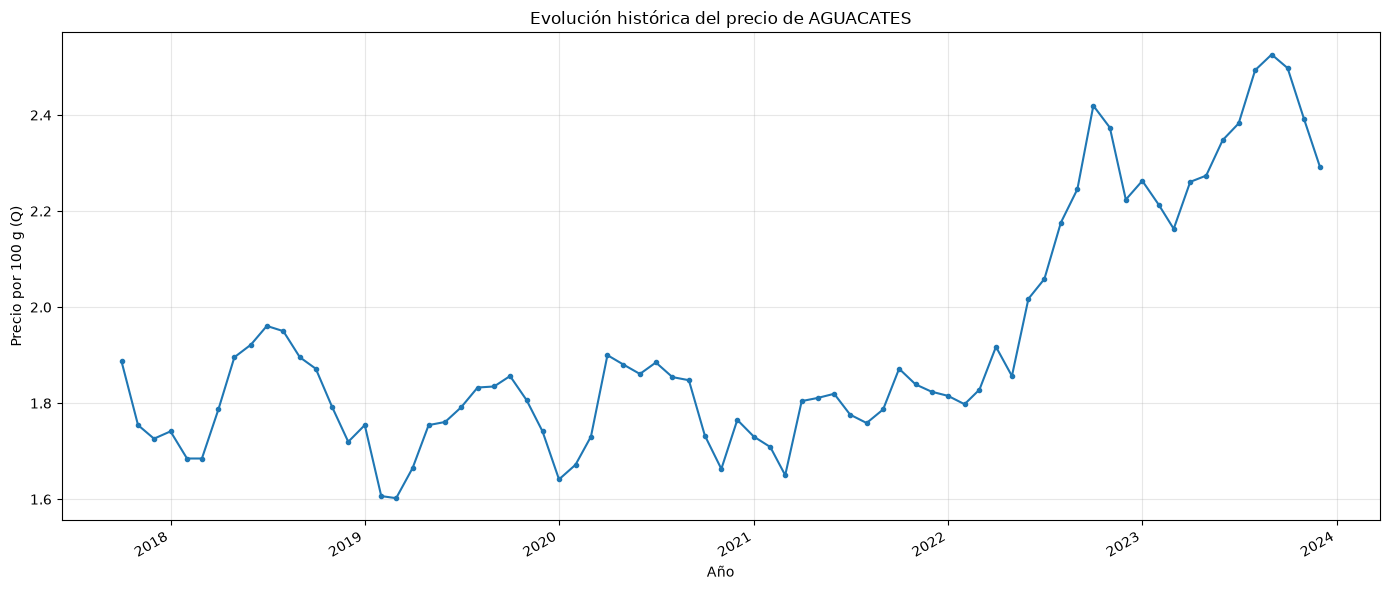

In [56]:
food = catalog.get('aguacates')
print(food.years_by_region())
fig, ax = food.plot_timeline('general')

In [57]:
candidates = [_food for _food in catalog if 'aguacate' in _food.id ]
candidates.pop(0)
candidates

[Food(id='aguacates_frescos', name='Aguacates frescos', category=None, aliases={'Aguacates frescos'}, price_timelines={'rural': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000023367A5C350>, 'urbana': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000023367C38830>, 'general': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000023367866870>}, nutrition=None, nutrition_match_score=None, nutrition_match_methods=(), is_meat=False)]

{'general': [2024, 2025, 2026], 'rural': [2024, 2025, 2026], 'urbana': [2024, 2025, 2026]}


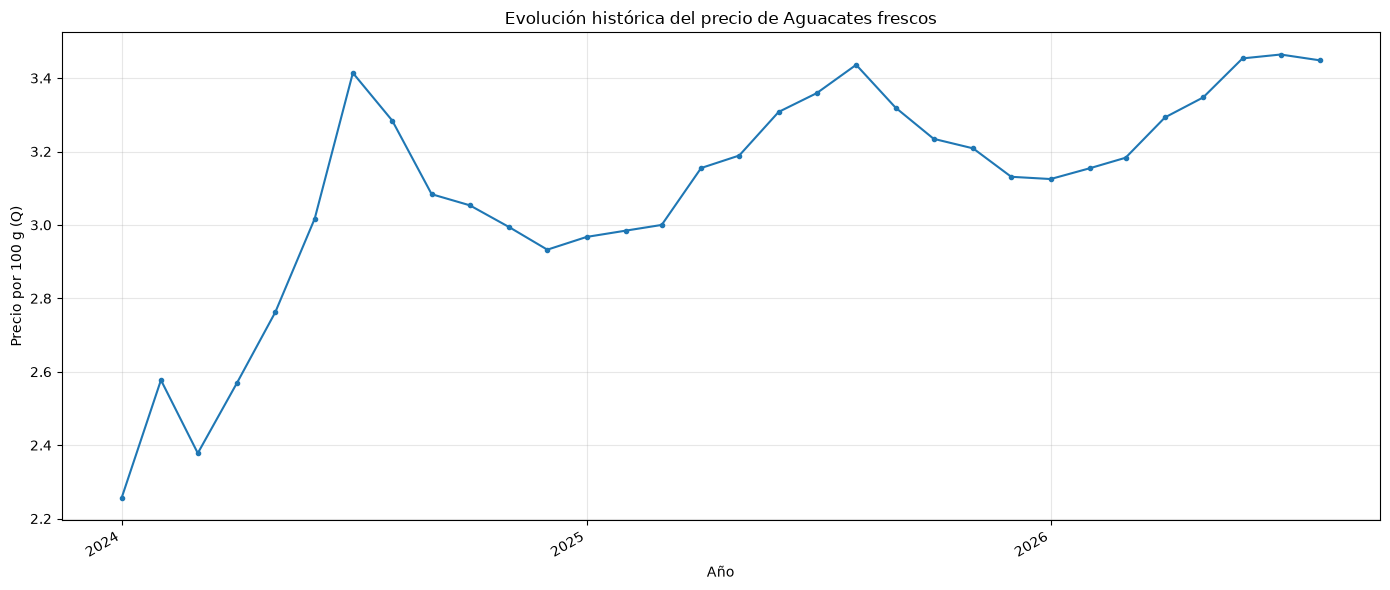

In [58]:
_candidate_1 = catalog.get('aguacates_frescos')
print(_candidate_1.years_by_region())
fig, ax = _candidate_1.plot_timeline('general')

Buena continuidad y rango de precios coherente, el nombre corresponde de igual forma. Se procede a mergear `aguacates_frescos` a `aguacates`. 

### Bananos guineos

{'general': [2017, 2018, 2019, 2020, 2021, 2022, 2023], 'rural': [], 'urbana': []}


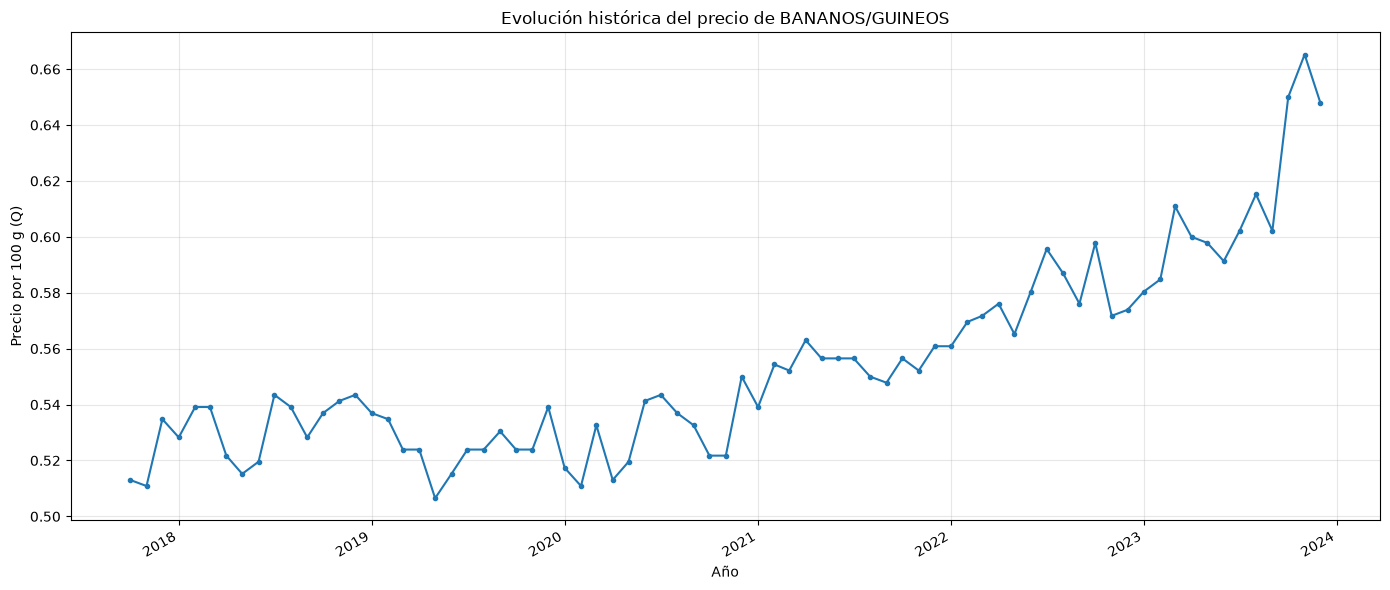

In [59]:
food = catalog.get('bananos_guineos')
print(food.years_by_region())
fig, ax = food.plot_timeline('general')

In [60]:
candidates = [_food for _food in catalog if 'banan' in _food.id or 'guineo' in _food.id]
candidates.pop(0)
candidates

[Food(id='bananos_frescos', name='Bananos frescos', category=None, aliases={'Bananos frescos'}, price_timelines={'rural': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000023367A5C4D0>, 'urbana': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000023367C380B0>, 'general': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000023367866DB0>}, nutrition=None, nutrition_match_score=None, nutrition_match_methods=(), is_meat=False)]

{'general': [2024, 2025, 2026], 'rural': [2024, 2025, 2026], 'urbana': [2024, 2025, 2026]}


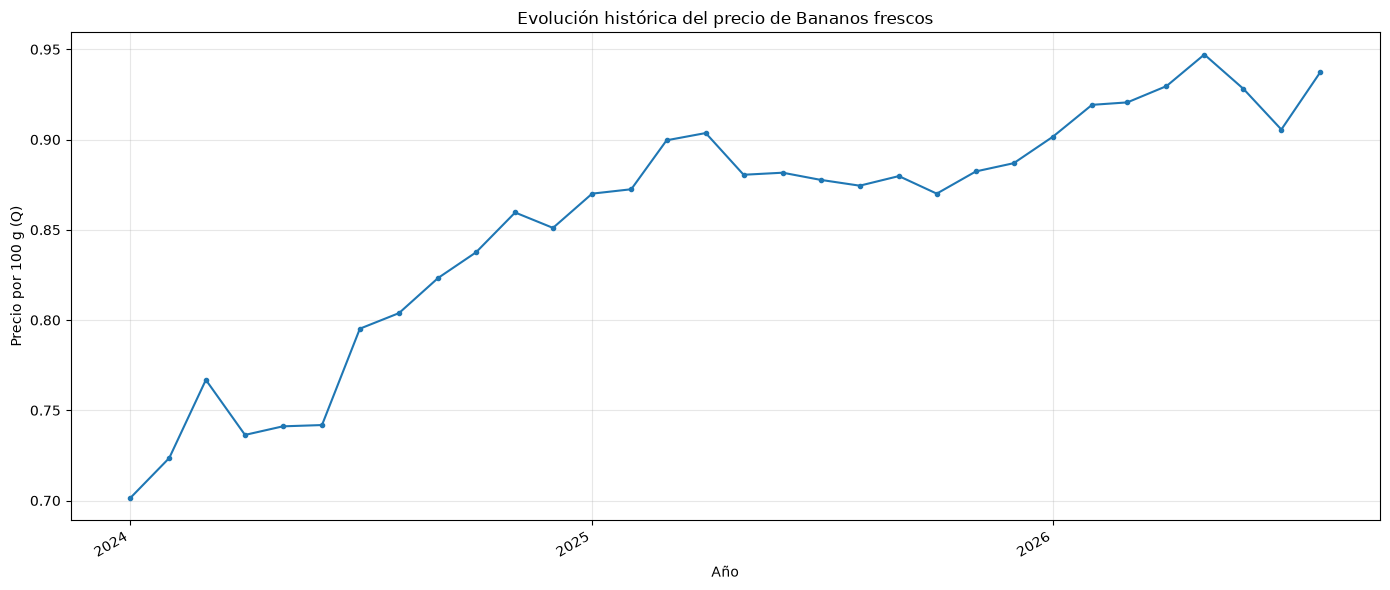

In [61]:
_candidate_1 = catalog.get('bananos_frescos')
print(_candidate_1.years_by_region())
fig, ax = _candidate_1.plot_timeline('general')

Coincide en continuidad de precio y en nombre. Por tanto se mergea `bananos_frescos` a `bananos_guineos`

### Platanos

{'general': [2017, 2018, 2019, 2020, 2021, 2022, 2023], 'rural': [], 'urbana': []}


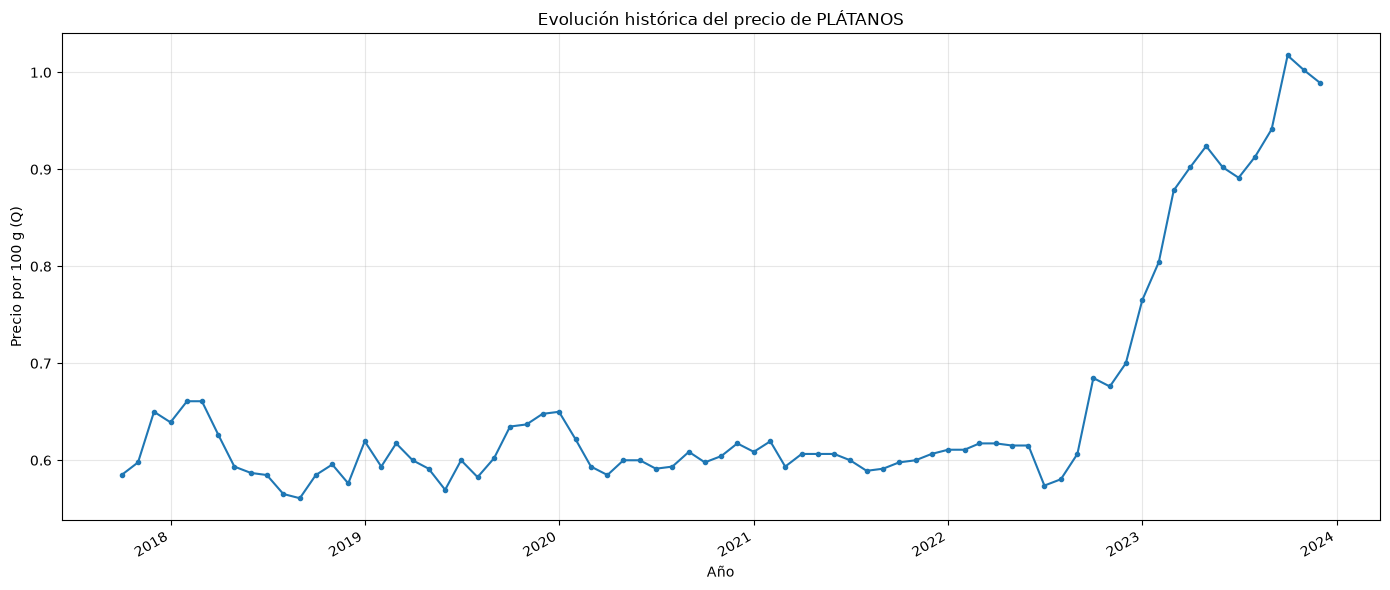

In [62]:
food = catalog.get('platanos')
print(food.years_by_region())
fig, ax = food.plot_timeline('general')

In [63]:
candidates = [_food for _food in catalog if 'platano' in _food.id ]
candidates.pop(0)
candidates

[Food(id='platanos_frescos', name='Plátanos frescos', category=None, aliases={'Plátanos frescos'}, price_timelines={'rural': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000023367A5C650>, 'urbana': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000023367C38650>, 'general': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000023367864590>}, nutrition=None, nutrition_match_score=None, nutrition_match_methods=(), is_meat=False)]

{'general': [2024, 2025, 2026], 'rural': [2024, 2025, 2026], 'urbana': [2024, 2025, 2026]}


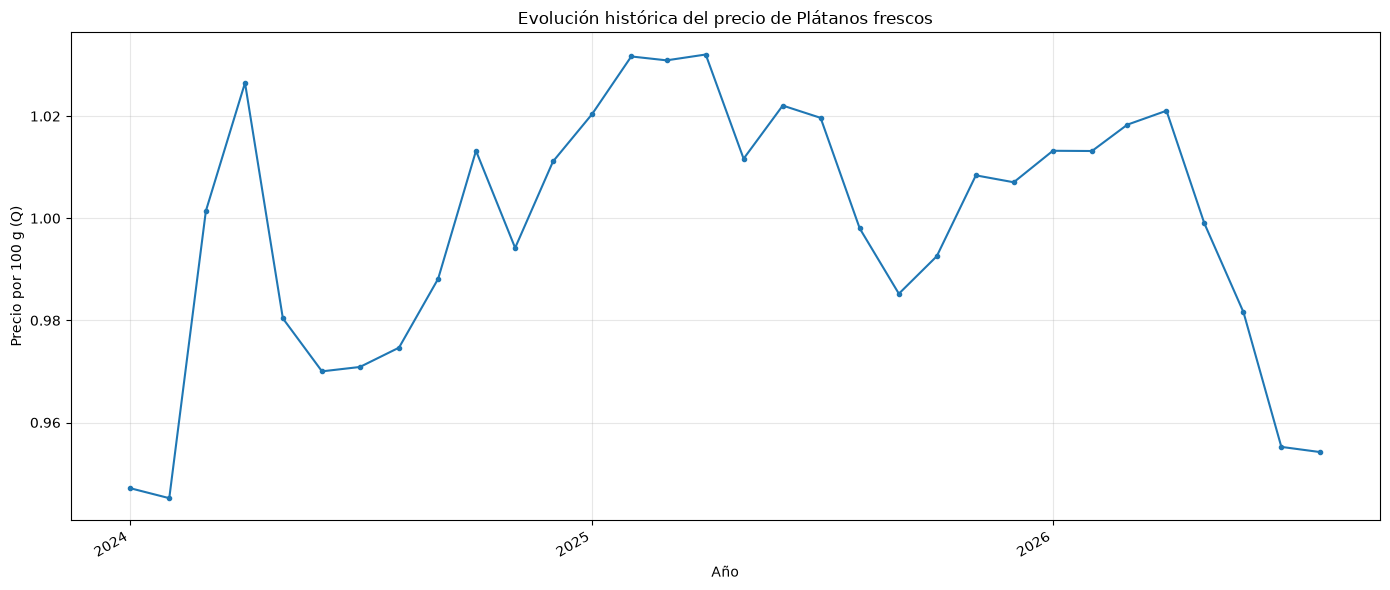

In [64]:
_candidate_1 = catalog.get('platanos_frescos')
print(_candidate_1.years_by_region())
fig, ax = _candidate_1.plot_timeline('general')

Continuidad de precio y nombre corresponden. Por tanto se mergea `platanos_frescos` a `platanos`

### Piñas

{'general': [2017, 2018, 2019, 2020, 2021, 2022, 2023], 'rural': [], 'urbana': []}


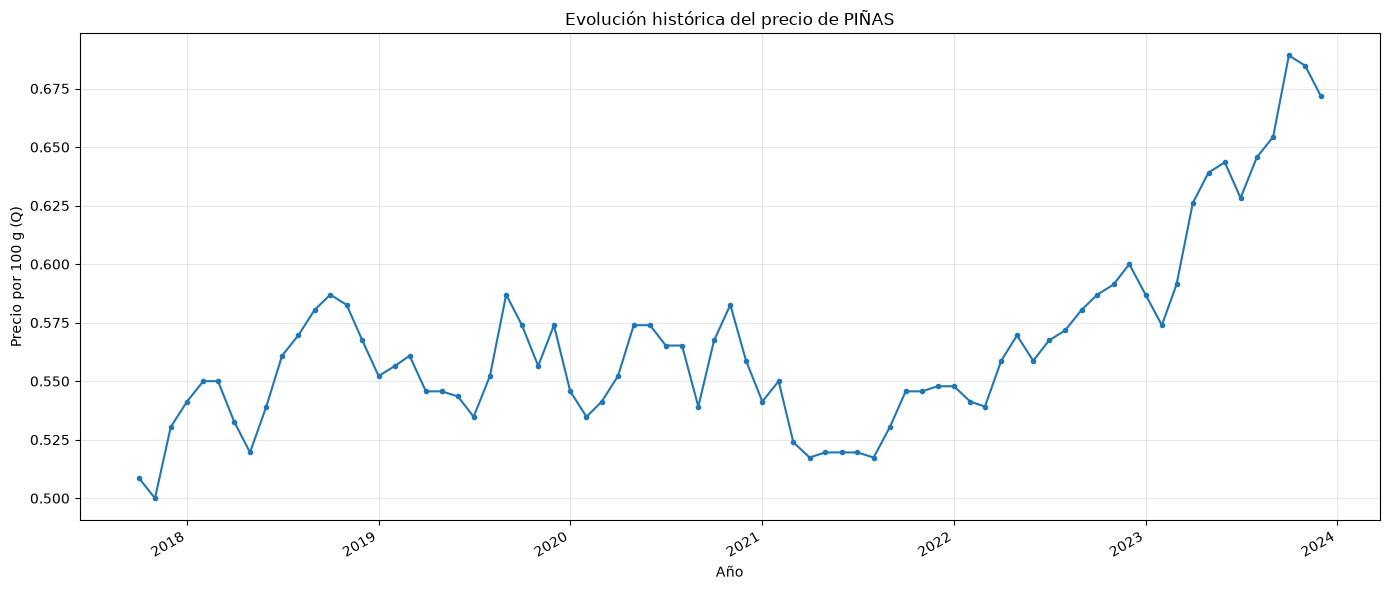

In [65]:
food = catalog.get('pinas')
print(food.years_by_region())
fig, ax = food.plot_timeline('general')

In [66]:
candidates = [_food for _food in catalog if 'piña' in _food.name.lower() ]
#candidates.pop(0)
candidates

[Food(id='pinas', name='PIÑAS', category='FRUTAS', aliases={'PIÑAS', 'Piñas'}, price_timelines={'general': <canasta_inteligente.domain.prices.PriceTimeline object at 0x00000233273B7610>}, nutrition=None, nutrition_match_score=None, nutrition_match_methods=(), is_meat=False)]

No hay registros del alimento de 2024 a 2026

### Sandias

{'general': [2017, 2018, 2019, 2020, 2021, 2022, 2023], 'rural': [], 'urbana': []}


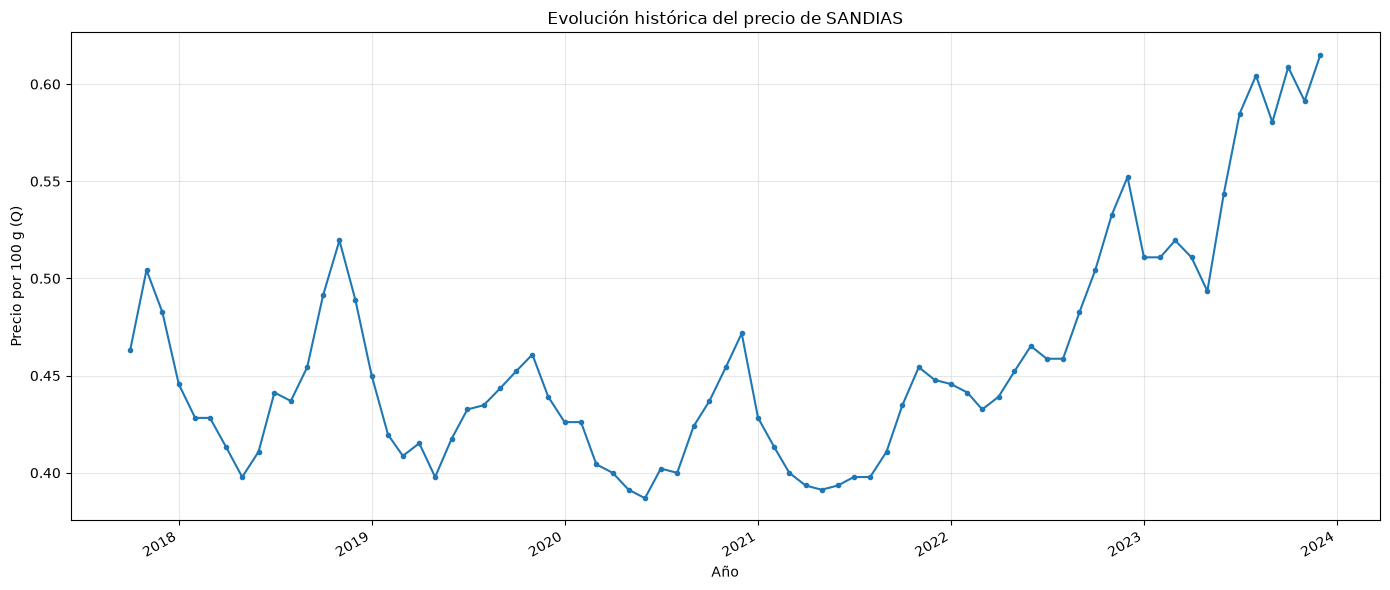

In [67]:
food = catalog.get('sandias')
print(food.years_by_region())
fig, ax = food.plot_timeline('general')

In [68]:
candidates = [_food for _food in catalog if 'sandia' in _food.name.lower() ]
#candidates.pop(0)
candidates

[Food(id='sandias', name='SANDIAS', category='FRUTAS', aliases={'Sandías', 'Sandias', 'SANDÍAS', 'SANDIAS'}, price_timelines={'general': <canasta_inteligente.domain.prices.PriceTimeline object at 0x000002332738DD90>}, nutrition=None, nutrition_match_score=None, nutrition_match_methods=(), is_meat=False)]

No hay registros del alimento de 2024 a 2026

### Tomate

{'general': [2017, 2018, 2019, 2020, 2021, 2022, 2023], 'rural': [], 'urbana': []}


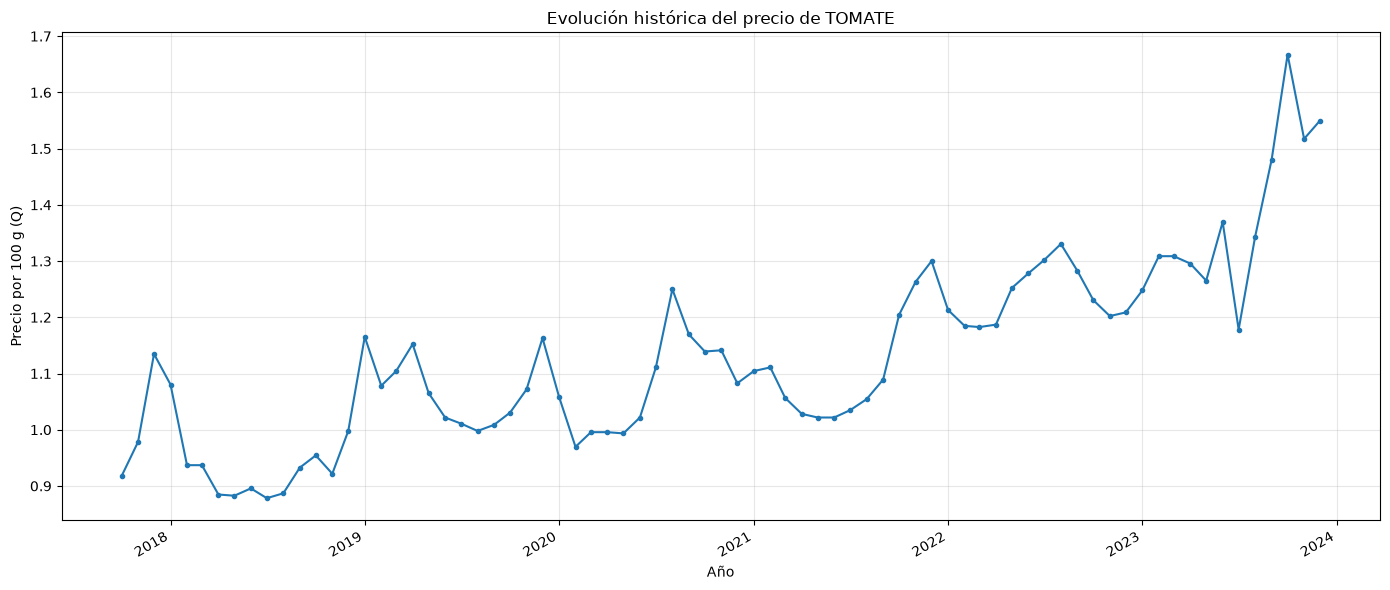

In [69]:
food = catalog.get('tomate')
print(food.years_by_region())
fig, ax = food.plot_timeline('general')

In [70]:
candidates = [_food for _food in catalog if 'tomat' in _food.name.lower() ]
#candidates.pop(0)
candidates

[Food(id='tomate', name='TOMATE', category='VERDURAS/HORTALIZAS', aliases={'TOMATE', 'Tomate'}, price_timelines={'general': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000023327372CD0>}, nutrition=None, nutrition_match_score=None, nutrition_match_methods=(), is_meat=False),
 Food(id='tomate_fresco', name='Tomate fresco', category=None, aliases={'Tomate fresco'}, price_timelines={'rural': <canasta_inteligente.domain.prices.PriceTimeline object at 0x000002336792B650>, 'urbana': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000023367C38290>, 'general': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000023367866E10>}, nutrition=None, nutrition_match_score=None, nutrition_match_methods=(), is_meat=False),
 Food(id='salsa_de_tomate_ranchera_queso_etc', name='Salsa de tomate (Ranchera, Queso etc.)', category=None, aliases={'Salsa de tomate (Ranchera, Queso etc.)'}, price_timelines={'rural': <canasta_inteligente.domain.prices.PriceTimeline objec

### Alimentos exclusivos de la canasta urbana

Estos alimentos solo tienen observaciones urbanas desde 2024 y se conservan separados. `Carne de res molida` es una presentación específica, no equivalente a toda la carne sin hueso. El jamón no se une con `embutidos`, porque la nota de la CBA histórica identifica esa serie con salchicha. El azúcar morena coexiste con el azúcar blanca y no debe reemplazarla. Los atoles son una bebida preparada y no equivalen a la harina para atoles.

Por tanto, no se propone ningún merge adicional para estos alimentos. Las similitudes parciales de nombre no compensan las diferencias de presentación, procesamiento, cobertura regional o coexistencia dentro del mismo periodo.

In [71]:
catalog.merge_foods('arroz', 'arroz_corriente')
catalog.merge_foods('avena_de_toda_clase', 'avena_mosh')
catalog.merge_foods('fideos', 'pastas_alimenticias')
catalog.merge_foods('fideos', 'pastas_de_todos_los_tipos')
catalog.merge_foods('fideos', 'fideos_en_todas_sus_formas_excepto_macarrones_y_espagueti')
catalog.merge_foods('tortillas_de_maiz', 'tortillas_frescas')
catalog.merge_foods('carne_de_res_con_hueso', 'carne_de_res_con_hueso_para_cocido')
catalog.merge_foods('carne_de_cerdo_sin_hueso', 'posta_de_cerdo_sin_hueso')
catalog.merge_foods('carne_de_pollo_o_gallina', 'carne_de_pollo_blanco')
catalog.merge_foods('leche_liquida', 'leche_entera_liquida_industrializada')
catalog.merge_foods('embutidos', 'salchichas_y_productos_similares_de_carne')
catalog.merge_foods('queso_fresco_o_duro', 'queso_fresco_incluye_el_queso_supercremoso')
catalog.merge_foods('crema_fresca', 'crema_artesanal')
catalog.merge_foods('aceites_comestibles', 'aceite_vegetal_mixtos')
catalog.merge_foods('aguacates', 'aguacates_frescos')
catalog.merge_foods('bananos_guineos', 'bananos_frescos')
catalog.merge_foods('platanos', 'platanos_frescos')
catalog.merge_foods('tomate', 'tomate_fresco')
catalog.merge_foods('cebolla_blanca_sin_tallo', 'cebollas')
catalog.merge_foods('hierbas', 'macuy_hierba_mora_quilete')
catalog.merge_foods('frijol', 'frijoles_negros_secos')
catalog.merge_foods('azucar', 'azucar_de_cana_blanca')
catalog.merge_foods('incaparina', 'preparacion_nutricional_a_base_de_maiz_y_soya')
catalog.merge_foods('incaparina', 'harina_para_atoles_incluye_incaparina')



Food(id='incaparina', name='INCAPARINA', category='MISCELÁNEA', aliases={'INCAPARINA', 'PREPARACION NUTRICIONAL A BASE DE MAÍZ Y SOYA', 'Harina para atoles (incluye Incaparina)', 'Preparación nutricional a base de maíz y soya'}, price_timelines={'general': <canasta_inteligente.domain.prices.PriceTimeline object at 0x00000233273B1550>, 'rural': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000023369C63110>}, nutrition=None, nutrition_match_score=None, nutrition_match_methods=(), is_meat=False)

## 1.3 Exclusion de alimentos de CBA

Los alimentos `desayuno_o_cena_continental_bebida_y_dos_acompanamientos_elaborados` y `almuerzo_o_cena_simple_bebida_carne_de_pollo_y_acompanamiento_excluye_gaseosa` que se salen del alcance de un análisis nutricional, por este motivo se excluye del catalogo de alimentos a incluir en la optimización. 

In [72]:
excluded_composite_meals = (
    'desayuno_o_cena_continental_bebida_y_dos_acompanamientos_elaborados',
    'almuerzo_o_cena_simple_bebida_carne_de_pollo_y_acompanamiento_excluye_gaseosa',
)
for food_id in excluded_composite_meals:
    catalog.remove(food_id)

Se redujo la cantidad de alimentos totales de 102 a 79

## Catalogo Resultante

In [73]:
len(catalog)

76

# 3. Merge con INCAP

In [74]:

from canasta_inteligente.data.incap import INCAPNutritionEnricher, Nutrition_INCAP
incap_pdf = PROJECT_ROOT / "data" / "raw" / "incap" / "tabladecomposiciondealimentos.pdf"

loader = Nutrition_INCAP(str(incap_pdf))

Loaded data from cache serialized data


In [75]:
incap_report = enrich_catalog_with_incap(catalog, PROJECT_ROOT / 'data' / 'raw' / 'incap' / 'tabladecomposiciondealimentos.pdf')
incap_report

Loaded data from cache serialized data


{'matched': 76, 'unmatched': 0}

## 3.1 Revisión de matches automáticos

Los matches ambiguos se corrigen individualmente después del enriquecimiento automático. De esta forma, la selección manual prevalece sin afectar los demás alimentos del catálogo.

In [76]:
catalog_iterable = iter(catalog)

Primero se exploran los registros que contienen similitudes con `arroz` dentro de la categoría 13, correspondiente a cereales, granos secos y derivados. La tabla permite comparar los candidatos y su energía por 100 g antes de asignar un perfil nutricional.

In [77]:
def summary_food_incap_match(catalog_food_id: str, catalog):
    food = catalog.get(catalog_food_id)
    energy_by_region = food.avg_energy()
    available_energy = [
        stats for stats in energy_by_region.values()
        if stats is not None and stats['count'] > 0
    ]
    energy_reference = (
        sum(stats['avg'] * stats['count'] for stats in available_energy)
        / sum(stats['count'] for stats in available_energy)
    ) if available_energy else None

    print('=== ALIMENTO CBA ===')
    print(f'ID: {food.id}')
    print(f'Nombre: {food.name}')
    print(f'Categoria CBA: {food.category}')
    print(f'Alias: {sorted(food.aliases)}')

    print('\n=== ENERGIA HISTORICA CBA ===')
    for region, stats in energy_by_region.items():
        if stats is None:
            print(f'{region}: sin datos energeticos')
            continue
        coefficient_of_variation = stats.get('coefficient_of_variation')
        cv_text = (
            f'{coefficient_of_variation:.1%}'
            if isinstance(coefficient_of_variation, (int, float))
            else 'no aplica'
        )
        print(
            f"{region}: media={stats['avg']:.1f}, "
            f"DE={stats['std_dev']:.1f}, "
            f"CV={cv_text}, "
            f"rango={stats['min']:.1f}-{stats['max']:.1f}, "
            f"n={stats['count']} kcal/100 g" )
    print(f'Energia de referencia ponderada: {energy_reference:.1f} kcal/100 g' if energy_reference is not None else 'Energia de referencia: no disponible')

    print('\n=== MATCH INCAP SELECCIONADO ===')
    if food.nutrition is None:
        print('Sin match nutricional seleccionado.')
    else:
        incap_energy = food.nutrition.values_per_100g.get('energia_kcal')
        print(f'Codigo INCAP: {food.nutrition.incap_code}')
        print(f'Nombre INCAP: {food.nutrition.incap_name}')
        print(f'Categoria INCAP: {food.nutrition.category}')
        print(f'Energia INCAP: {incap_energy:.1f} kcal/100 g' if isinstance(incap_energy, (int, float)) else 'Energia INCAP: no disponible')
        if energy_reference is not None and isinstance(incap_energy, (int, float)):
            difference = abs(incap_energy - energy_reference)
            difference_pct = (
                f'{difference / energy_reference:.1%}'
                if energy_reference != 0
                else 'no aplica'
            )
            print(f'Diferencia frente a CBA: {difference:.1f} kcal/100 g ({difference_pct})')
        print(f'Probabilidad del match: {food.nutrition_match_score:.1%}' if food.nutrition_match_score is not None else 'Probabilidad del match: no disponible')
        print(f'Metodos del match: {food.nutrition_match_methods}')

    print(f'\nCandidatos alternativos conservados: {len(food.nutrition_candidates)}')
    candidate_columns = [
        'codigo', 'nombre', 'energia_kcal',
        'energy_difference_kcal', 'energy_difference_pct',
        'match_probability', 'match_methods',
    ]
    display(food.nutrition_candidates.reindex(columns=candidate_columns).head(10))

### Arroz

In [78]:
summary_food_incap_match('arroz', catalog)

=== ALIMENTO CBA ===
ID: arroz
Nombre: ARROZ
Categoria CBA: CEREALES
Alias: ['ARROZ', 'Arroz', 'Arroz corriente']

=== ENERGIA HISTORICA CBA ===
general: media=360.0, DE=0.0, CV=0.0%, rango=360.0-360.0, n=32 kcal/100 g
rural: media=360.0, DE=0.0, CV=0.0%, rango=360.0-360.0, n=32 kcal/100 g
urbana: media=360.0, DE=0.0, CV=0.0%, rango=360.0-360.0, n=32 kcal/100 g
Energia de referencia ponderada: 360.0 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 13002
Nombre INCAP: ARROZ BLANCO, GRANO MEDIANO, CRUDO, ENRIQ.
Categoria INCAP: CEREALES, GRANOS SECOS Y DERIVADOS
Energia INCAP: 360.0 kcal/100 g
Diferencia frente a CBA: 0.0 kcal/100 g (0.0%)
Probabilidad del match: 51.5%
Metodos del match: ('contains', 'token_set', 'partial')

Candidatos alternativos conservados: 21


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods
0,13004,"ARROZ BLANCO, GRANO MEDIANO, CRUDO, S/ENRIQ.",360,0.0,0.000000,0.5109,"(contains, token_set, partial)"
1,13005,"ARROZ BLANCO, SEMIPULIDO",361,1.0,0.277778,0.5617,"(contains, token_set, partial)"
2,13006,"ARROZ INTEGRAL, GRANO MEDIANO, CRUDO",362,2.0,0.555556,0.5249,"(contains, token_set, partial)"
3,13176,"ARROZ BLANCO, GRANO PEQUENO, CRUDO, S/ENRIQ.",358,2.0,0.555556,0.5104,"(contains, token_set, partial)"
4,13116,"ARROZ BLANCO, GRANO PEQUENO, CRUDO, ENRIQ. (PA...",358,2.0,0.555556,0.5005,"(contains, token_set, partial)"
5,13152,"HARINA DE ARROZ, INTEGRAL",363,3.0,0.833333,0.5725,"(contains, token_set, partial)"
6,13151,"FIDEOS DE ARROZ, CRUDOS",364,4.0,1.111111,0.5873,"(contains, token_set, partial)"
7,19051,"CEREAL-NESTUM, ARROZ C/FRUTAS",364,4.0,1.111111,0.5407,"(contains, token_set, partial)"
8,13025,"HARINA DE ARROZ, BLANCO",366,6.0,1.666667,0.5852,"(contains, token_set, partial)"
9,13118,"ARROZ INTEGRAL, GRANO LARGO, CRUDO",367,7.0,1.944444,0.5288,"(contains, token_set, partial)"


In [79]:
#ARROZ BLANCO, GRANO MEDIANO, CRUDO, S/ENRIQ.
incap_enricher = INCAPNutritionEnricher(loader)
food = catalog.get('arroz')

food = incap_enricher.enrich_food(
    category=13,
    name='ARROZ BLANCO, GRANO MEDIANO, CRUDO, S/ENRIQ.',
    min_probability=0.90,
    food=food,
)
summary_food_incap_match('arroz', catalog)

=== ALIMENTO CBA ===
ID: arroz
Nombre: ARROZ
Categoria CBA: CEREALES
Alias: ['ARROZ', 'Arroz', 'Arroz corriente']

=== ENERGIA HISTORICA CBA ===
general: media=360.0, DE=0.0, CV=0.0%, rango=360.0-360.0, n=32 kcal/100 g
rural: media=360.0, DE=0.0, CV=0.0%, rango=360.0-360.0, n=32 kcal/100 g
urbana: media=360.0, DE=0.0, CV=0.0%, rango=360.0-360.0, n=32 kcal/100 g
Energia de referencia ponderada: 360.0 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 13004
Nombre INCAP: ARROZ BLANCO, GRANO MEDIANO, CRUDO, S/ENRIQ.
Categoria INCAP: CEREALES, GRANOS SECOS Y DERIVADOS
Energia INCAP: 360.0 kcal/100 g
Diferencia frente a CBA: 0.0 kcal/100 g (0.0%)
Probabilidad del match: 100.0%
Metodos del match: ('exact', 'contains', 'sequence', 'token_sort', 'token_set', 'partial', 'char_ngram_jaccard')

Candidatos alternativos conservados: 21


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods
0,13004,"ARROZ BLANCO, GRANO MEDIANO, CRUDO, S/ENRIQ.",360,0.0,0.000000,0.5109,"(contains, token_set, partial)"
1,13005,"ARROZ BLANCO, SEMIPULIDO",361,1.0,0.277778,0.5617,"(contains, token_set, partial)"
2,13006,"ARROZ INTEGRAL, GRANO MEDIANO, CRUDO",362,2.0,0.555556,0.5249,"(contains, token_set, partial)"
3,13176,"ARROZ BLANCO, GRANO PEQUENO, CRUDO, S/ENRIQ.",358,2.0,0.555556,0.5104,"(contains, token_set, partial)"
4,13116,"ARROZ BLANCO, GRANO PEQUENO, CRUDO, ENRIQ. (PA...",358,2.0,0.555556,0.5005,"(contains, token_set, partial)"
5,13152,"HARINA DE ARROZ, INTEGRAL",363,3.0,0.833333,0.5725,"(contains, token_set, partial)"
6,13151,"FIDEOS DE ARROZ, CRUDOS",364,4.0,1.111111,0.5873,"(contains, token_set, partial)"
7,19051,"CEREAL-NESTUM, ARROZ C/FRUTAS",364,4.0,1.111111,0.5407,"(contains, token_set, partial)"
8,13025,"HARINA DE ARROZ, BLANCO",366,6.0,1.666667,0.5852,"(contains, token_set, partial)"
9,13118,"ARROZ INTEGRAL, GRANO LARGO, CRUDO",367,7.0,1.944444,0.5288,"(contains, token_set, partial)"


### Avena

In [80]:
summary_food_incap_match('avena_de_toda_clase', catalog)

=== ALIMENTO CBA ===
ID: avena_de_toda_clase
Nombre: AVENA DE TODA CLASE
Categoria CBA: CEREALES
Alias: ['AVENA DE TODA CLASE', 'Avena de toda clase', 'Avena/mosh']

=== ENERGIA HISTORICA CBA ===
general: sin datos energeticos
rural: media=389.0, DE=0.0, CV=0.0%, rango=389.0-389.0, n=32 kcal/100 g
Energia de referencia ponderada: 389.0 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 13008
Nombre INCAP: AVENA EN HOJUELAS S/FORTIFICAR (MOSH)
Categoria INCAP: CEREALES, GRANOS SECOS Y DERIVADOS
Energia INCAP: 389.0 kcal/100 g
Diferencia frente a CBA: 0.0 kcal/100 g (0.0%)
Probabilidad del match: 43.5%
Metodos del match: ('token_set', 'partial')

Candidatos alternativos conservados: 0


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods


### Pan frances

In [81]:
summary_food_incap_match('pan_frances', catalog)

=== ALIMENTO CBA ===
ID: pan_frances
Nombre: PAN FRANCÉS
Categoria CBA: CEREALES
Alias: ['PAN FRANCÉS', 'Pan francés']

=== ENERGIA HISTORICA CBA ===
general: media=277.0, DE=0.0, CV=0.0%, rango=277.0-277.0, n=32 kcal/100 g
rural: media=277.0, DE=0.0, CV=0.0%, rango=277.0-277.0, n=32 kcal/100 g
urbana: media=277.0, DE=0.0, CV=0.0%, rango=277.0-277.0, n=32 kcal/100 g
Energia de referencia ponderada: 277.0 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 14131
Nombre INCAP: PAN FRANCES SIMPLE
Categoria INCAP: GALLETAS, PANES Y TORTILLAS
Energia INCAP: 277.0 kcal/100 g
Diferencia frente a CBA: 0.0 kcal/100 g (0.0%)
Probabilidad del match: 73.3%
Metodos del match: ('contains', 'sequence', 'token_sort', 'token_set', 'partial')

Candidatos alternativos conservados: 0


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods


### Pan dulce

In [82]:
summary_food_incap_match('pan_dulce', catalog)

=== ALIMENTO CBA ===
ID: pan_dulce
Nombre: PAN DULCE
Categoria CBA: CEREALES
Alias: ['PAN DULCE', 'Pan dulce']

=== ENERGIA HISTORICA CBA ===
general: media=367.0, DE=0.0, CV=0.0%, rango=367.0-367.0, n=32 kcal/100 g
rural: media=367.0, DE=0.0, CV=0.0%, rango=367.0-367.0, n=32 kcal/100 g
urbana: media=367.0, DE=0.0, CV=0.0%, rango=367.0-367.0, n=32 kcal/100 g
Energia de referencia ponderada: 367.0 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 14127
Nombre INCAP: PAN DULCE, SIMPLE
Categoria INCAP: GALLETAS, PANES Y TORTILLAS
Energia INCAP: 367.0 kcal/100 g
Diferencia frente a CBA: 0.0 kcal/100 g (0.0%)
Probabilidad del match: 71.5%
Metodos del match: ('contains', 'token_set', 'partial')

Candidatos alternativos conservados: 4


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods
0,14128,"PAN DULCE, C/PASAS",372,5.0,1.362398,0.7067,"(contains, token_set, partial)"
1,14029,"PAN DULCE, DE COCO",378,11.0,2.997275,0.7440,"(contains, sequence, token_sort, token_set, pa..."
2,14130,"PAN DULCE, TORTA SALVADOREÑA",390,23.0,6.267030,0.6190,"(contains, token_set, partial)"
3,18112,TORREJAS C/MIEL (PAN DULCE FORRADO C/HUEVO) (E...,344,23.0,6.267030,0.5431,"(contains, token_set, partial)"


### Fideos

In [83]:
summary_food_incap_match('fideos', catalog)

=== ALIMENTO CBA ===
ID: fideos
Nombre: FIDEOS
Categoria CBA: CEREALES
Alias: ['FIDEOS', 'Fideos en todas sus formas (Excepto macarrones y espagueti)', 'PASTAS ALIMENTICIAS', 'PASTAS DE TODOS LOS TIPOS', 'Pastas de todos los tipos']

=== ENERGIA HISTORICA CBA ===
general: media=384.0, DE=0.0, CV=0.0%, rango=384.0-384.0, n=32 kcal/100 g
rural: media=384.0, DE=0.0, CV=0.0%, rango=384.0-384.0, n=32 kcal/100 g
urbana: media=384.0, DE=0.0, CV=0.0%, rango=384.0-384.0, n=32 kcal/100 g
Energia de referencia ponderada: 384.0 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 20048
Nombre INCAP: SOPA DESHIDRATADA, POLLO C/FIDEOS
Categoria INCAP: ADEREZOS, SALSAS Y SOPAS
Energia INCAP: 377.0 kcal/100 g
Diferencia frente a CBA: 7.0 kcal/100 g (1.8%)
Probabilidad del match: 54.6%
Metodos del match: ('contains', 'token_set', 'partial')

Candidatos alternativos conservados: 1


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods
0,13151,"FIDEOS DE ARROZ, CRUDOS",364,20.0,5.208333,0.6133,"(contains, token_set, partial)"


In [84]:
incap_enricher = INCAPNutritionEnricher(loader)
food = catalog.get('fideos')
energy_reference = INCAPNutritionEnricher._energy_reference(food)

pasta_candidates = incap_enricher.search_food_candidates(
    category=13,
    name='pasta fideos cruda',
    min_probability=0.15,
    top_n=50,
    energy_per_100g=energy_reference,
    energy_tolerance=60,
    require_match_methods=False,
)

valid_pasta = (
    pasta_candidates['nombre'].str.contains(r'\bPASTA\b', case=False, na=False)
    & pasta_candidates['nombre'].str.contains(r'\bCRUDA\b', case=False, na=False)
    & ~pasta_candidates['nombre'].str.contains(
        r'\bSOPA\b|\bCOCIDA\b', case=False, na=False
    )
)
pasta_candidates = pasta_candidates[valid_pasta].reset_index(drop=True)

pasta_candidates[[
    'codigo', 'nombre', 'energia_kcal',
    'energy_difference_kcal', 'energy_difference_pct',
    'match_probability', 'match_methods',
]]

,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods
0,13068,"PASTA C/HUEVO ENRIQUECIDA, CRUDA",384,6.252776e-13,1.628327e-13,0.4066,"(token_set,)"
1,13065,"PASTA C/HUEVO S/ENRIQUECER, CRUDA",384,6.252776e-13,1.628327e-13,0.3938,"(token_set,)"
2,13071,"PASTA C/HUEVO Y ESPINACA, ENRIQUECIDA, CRUDA",382,2.000000e+00,5.208333e-01,0.3719,"(token_set,)"
3,13063,"PASTA C/ESPINACA, CRUDA",372,1.200000e+01,3.125000e+00,0.4362,"(token_set,)"
4,13060,"PASTA ENRIQUECIDA, CRUDA",371,1.300000e+01,3.385417e+00,0.4409,"(token_set,)"
5,13057,"PASTA S/ENRIQUECER, CRUDA",371,1.300000e+01,3.385417e+00,0.4328,"(token_set,)"


In [85]:
selected_incap_name = 'PASTA S/ENRIQUECER, CRUDA' # por usar el nombre especifico la probabilidad de match sera del 100%
food = incap_enricher.enrich_food(
    category=13,
    name=selected_incap_name,
    min_probability=0.90,
    food=food,
)

selected_code = food.nutrition.incap_code if food.nutrition is not None else None
food.nutrition_candidates = pasta_candidates[
    pasta_candidates['codigo'].astype(str) != str(selected_code)
].reset_index(drop=True)

summary_food_incap_match('fideos', catalog)

=== ALIMENTO CBA ===
ID: fideos
Nombre: FIDEOS
Categoria CBA: CEREALES
Alias: ['FIDEOS', 'Fideos en todas sus formas (Excepto macarrones y espagueti)', 'PASTAS ALIMENTICIAS', 'PASTAS DE TODOS LOS TIPOS', 'Pastas de todos los tipos']

=== ENERGIA HISTORICA CBA ===
general: media=384.0, DE=0.0, CV=0.0%, rango=384.0-384.0, n=32 kcal/100 g
rural: media=384.0, DE=0.0, CV=0.0%, rango=384.0-384.0, n=32 kcal/100 g
urbana: media=384.0, DE=0.0, CV=0.0%, rango=384.0-384.0, n=32 kcal/100 g
Energia de referencia ponderada: 384.0 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 13057
Nombre INCAP: PASTA S/ENRIQUECER, CRUDA
Categoria INCAP: CEREALES, GRANOS SECOS Y DERIVADOS
Energia INCAP: 371.0 kcal/100 g
Diferencia frente a CBA: 13.0 kcal/100 g (3.4%)
Probabilidad del match: 100.0%
Metodos del match: ('exact', 'contains', 'sequence', 'token_sort', 'token_set', 'partial', 'char_ngram_jaccard')

Candidatos alternativos conservados: 5


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods
0,13068,"PASTA C/HUEVO ENRIQUECIDA, CRUDA",384,6.252776e-13,1.628327e-13,0.4066,"(token_set,)"
1,13065,"PASTA C/HUEVO S/ENRIQUECER, CRUDA",384,6.252776e-13,1.628327e-13,0.3938,"(token_set,)"
2,13071,"PASTA C/HUEVO Y ESPINACA, ENRIQUECIDA, CRUDA",382,2.000000e+00,5.208333e-01,0.3719,"(token_set,)"
3,13063,"PASTA C/ESPINACA, CRUDA",372,1.200000e+01,3.125000e+00,0.4362,"(token_set,)"
4,13060,"PASTA ENRIQUECIDA, CRUDA",371,1.300000e+01,3.385417e+00,0.4409,"(token_set,)"


### Tortillas de maiz

In [86]:
summary_food_incap_match('tortillas_de_maiz', catalog)

=== ALIMENTO CBA ===
ID: tortillas_de_maiz
Nombre: TORTILLAS DE MAÍZ
Categoria CBA: CEREALES
Alias: ['TORTILLAS DE MAÍZ', 'Tortillas de maíz', 'Tortillas frescas']

=== ENERGIA HISTORICA CBA ===
general: media=211.0, DE=0.0, CV=0.0%, rango=211.0-211.0, n=32 kcal/100 g
rural: media=211.0, DE=0.0, CV=0.0%, rango=211.0-211.0, n=32 kcal/100 g
urbana: media=211.0, DE=0.0, CV=0.0%, rango=211.0-211.0, n=32 kcal/100 g
Energia de referencia ponderada: 211.0 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 14052
Nombre INCAP: TORTILLA DE MAIZ BLANCO, C/CAL
Categoria INCAP: GALLETAS, PANES Y TORTILLAS
Energia INCAP: 211.0 kcal/100 g
Diferencia frente a CBA: 0.0 kcal/100 g (0.0%)
Probabilidad del match: 47.0%
Metodos del match: ('partial',)

Candidatos alternativos conservados: 3


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods
0,14048,"TORTILLA DE MAIZ AMARILLO, C/CAL",211,1.989520e-13,9.429003e-14,0.4553,"(partial,)"
1,14057,"TORTILLA DE MAICILLO, C/CAL",194,1.700000e+01,8.056872e+00,0.4575,"(partial,)"
2,14055,"TORTILLA DE MAIZ BLANCO, PILADO",167,4.400000e+01,2.085308e+01,0.4617,"(partial,)"


### Carne de res sin hueso

In [87]:
summary_food_incap_match('carne_de_res_sin_hueso', catalog)

=== ALIMENTO CBA ===
ID: carne_de_res_sin_hueso
Nombre: CARNE DE RES SIN HUESO
Categoria CBA: CARNES
Alias: ['CARNE DE RES SIN HUESO', 'Carne de res sin hueso', 'Carne de res sin hueso (posta)']

=== ENERGIA HISTORICA CBA ===
general: media=163.3, DE=0.0, CV=0.0%, rango=163.3-163.3, n=32 kcal/100 g
rural: media=163.4, DE=0.0, CV=0.0%, rango=163.4-163.4, n=32 kcal/100 g
urbana: media=163.3, DE=0.0, CV=0.0%, rango=163.3-163.3, n=32 kcal/100 g
Energia de referencia ponderada: 163.3 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 5084
Nombre INCAP: RES, CARNE SEMIMAGRA, CRUDA, CON HUESO
Categoria INCAP: CARNE DE VACUNO
Energia INCAP: 169.0 kcal/100 g
Diferencia frente a CBA: 5.7 kcal/100 g (3.5%)
Probabilidad del match: 46.5%
Metodos del match: ('token_set',)

Candidatos alternativos conservados: 1


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods
0,21006,"BURRITO, FRIJOLES C/CARNE DE RES Y QUESO",180,16.65,10.192837,0.4514,"(token_set, partial)"


In [88]:
food = catalog.get('carne_de_res_sin_hueso')
energy_reference = INCAPNutritionEnricher._energy_reference(food)
incap_enricher = INCAPNutritionEnricher(loader)

beef_candidates = incap_enricher.search_food_candidates(
    category=5,  # Carne de vaca
    name='res carne sin hueso cruda',
    min_probability=0.15,
    top_n=50,
    energy_per_100g=energy_reference,
    energy_tolerance=60,
    require_match_methods=False,
)

beef_candidates = beef_candidates[
    ~beef_candidates['nombre'].str.contains(
        r'\bCON HUESO\b', case=False, na=False, regex=True
    )
].reset_index(drop=True)

beef_candidates[[
    'codigo', 'nombre', 'energia_kcal',
    'energy_difference_kcal', 'energy_difference_pct',
    'match_probability', 'match_methods',
]].head(20)

,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods
0,5061,"RES, BOLOVIQUE/MANO DE PIEDRA, MAGRO, COCIDO",163,0.35,0.214264,0.2339,()
1,5078,"RES, MANITA O CABEZA DE LOMO, SEMIMAGRA, CRUDA",165,1.65,1.010101,0.3322,()
2,5080,"RES, POSTA DE PECHO, SEMIMAGRA, CRUDA",165,1.65,1.010101,0.3279,()
3,5029,"RES, CORAZON, COCIDO",165,1.65,1.010101,0.3182,()
4,5064,"RES, BOLOVIQUE/MANO DE PIEDRA, C/GRASA, CRUDO",166,2.65,1.622283,0.2791,()
5,5042,"RES, RINON, COCIDO",158,5.35,3.275176,0.2980,()
6,5022,"RES, CARNE SEMIMAGRA, CRUDA",169,5.65,3.458831,0.4847,"(token_set,)"
7,5067,"RES, LOMO O SOLOMO, MAGRO, CRUDO",154,9.35,5.723906,0.3029,()
8,5056,"CARNE VEGETARIANA, ROLLOS DE POLLO, CONGELADOS",154,9.35,5.723906,0.2627,()
9,5027,"RES, CARNE SALADA, SECA",153,10.35,6.336088,0.4138,()


In [89]:
selected_incap_name = 'RES, CARNE SEMIMAGRA, CRUDA'
food = incap_enricher.enrich_food(
    category=5,
    name=selected_incap_name,
    min_probability=0.90,
    food=food,
)

selected_code = food.nutrition.incap_code if food.nutrition is not None else None
food.nutrition_candidates = beef_candidates[
    beef_candidates['codigo'].astype(str) != str(selected_code)
].reset_index(drop=True)

summary_food_incap_match('carne_de_res_sin_hueso', catalog)

=== ALIMENTO CBA ===
ID: carne_de_res_sin_hueso
Nombre: CARNE DE RES SIN HUESO
Categoria CBA: CARNES
Alias: ['CARNE DE RES SIN HUESO', 'Carne de res sin hueso', 'Carne de res sin hueso (posta)']

=== ENERGIA HISTORICA CBA ===
general: media=163.3, DE=0.0, CV=0.0%, rango=163.3-163.3, n=32 kcal/100 g
rural: media=163.4, DE=0.0, CV=0.0%, rango=163.4-163.4, n=32 kcal/100 g
urbana: media=163.3, DE=0.0, CV=0.0%, rango=163.3-163.3, n=32 kcal/100 g
Energia de referencia ponderada: 163.3 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 5022
Nombre INCAP: RES, CARNE SEMIMAGRA, CRUDA
Categoria INCAP: CARNE DE VACUNO
Energia INCAP: 169.0 kcal/100 g
Diferencia frente a CBA: 5.7 kcal/100 g (3.5%)
Probabilidad del match: 100.0%
Metodos del match: ('exact', 'contains', 'sequence', 'token_sort', 'token_set', 'partial', 'char_ngram_jaccard')

Candidatos alternativos conservados: 48


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods
0,5061,"RES, BOLOVIQUE/MANO DE PIEDRA, MAGRO, COCIDO",163,0.35,0.214264,0.2339,()
1,5078,"RES, MANITA O CABEZA DE LOMO, SEMIMAGRA, CRUDA",165,1.65,1.010101,0.3322,()
2,5080,"RES, POSTA DE PECHO, SEMIMAGRA, CRUDA",165,1.65,1.010101,0.3279,()
3,5029,"RES, CORAZON, COCIDO",165,1.65,1.010101,0.3182,()
4,5064,"RES, BOLOVIQUE/MANO DE PIEDRA, C/GRASA, CRUDO",166,2.65,1.622283,0.2791,()
5,5042,"RES, RINON, COCIDO",158,5.35,3.275176,0.2980,()
6,5067,"RES, LOMO O SOLOMO, MAGRO, CRUDO",154,9.35,5.723906,0.3029,()
7,5056,"CARNE VEGETARIANA, ROLLOS DE POLLO, CONGELADOS",154,9.35,5.723906,0.2627,()
8,5027,"RES, CARNE SALADA, SECA",153,10.35,6.336088,0.4138,()
9,5083,"TERNERA, FILETE O SOLOMILLO, SEMIMAGRO, CRUDO",152,11.35,6.948271,0.2450,()


### Carne de res con hueso

In [90]:
summary_food_incap_match('carne_de_res_con_hueso', catalog)

=== ALIMENTO CBA ===
ID: carne_de_res_con_hueso
Nombre: CARNE DE RES CON HUESO
Categoria CBA: CARNES
Alias: ['CARNE DE RES CON HUESO', 'Carne de res con hueso', 'Carne de res con hueso para cocido']

=== ENERGIA HISTORICA CBA ===
general: media=94.6, DE=0.0, CV=0.0%, rango=94.6-94.6, n=32 kcal/100 g
rural: media=94.6, DE=0.0, CV=0.0%, rango=94.6-94.6, n=32 kcal/100 g
urbana: media=94.6, DE=0.0, CV=0.0%, rango=94.6-94.6, n=32 kcal/100 g
Energia de referencia ponderada: 94.6 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 24220
Nombre INCAP: CASADO DE CARNE DE RES (COSTA RICA)
Categoria INCAP: COMIDA CASERA Y DE RESTAURANTE
Energia INCAP: 110.0 kcal/100 g
Diferencia frente a CBA: 15.4 kcal/100 g (16.2%)
Probabilidad del match: 40.8%
Metodos del match: ('token_set',)

Candidatos alternativos conservados: 3


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods
0,5069,"RES, BAZO, COCIDO",145,50.36,53.212172,0.4668,"(token_set, partial)"
1,5044,"RES, SESOS, COCIDOS",151,56.36,59.551986,0.4586,"(partial,)"
2,5042,"RES, RINON, COCIDO",158,63.36,66.948436,0.4370,"(token_set, partial)"


In [91]:
import pandas as pd

incap_enricher = INCAPNutritionEnricher(loader)
food = catalog.get('carne_de_res_con_hueso')
energy_reference = INCAPNutritionEnricher._energy_reference(food)

bone_in_beef_candidates = incap_enricher.search_food_candidates(
    category=5,  # Carne de vacuno
    name='res carne con hueso cruda para cocido',
    min_probability=0.10,
    top_n=100,
    require_match_methods=False,
)
bone_in_beef_candidates = bone_in_beef_candidates[
    bone_in_beef_candidates['nombre'].str.contains(
        r'CON HUESO|C/HUESO', case=False, na=False, regex=True
    )
].copy()

bone_in_beef_candidates['energia_kcal'] = pd.to_numeric(
    bone_in_beef_candidates['energia_kcal'], errors='coerce'
)
bone_in_beef_candidates['fraccion_comestible_pct'] = pd.to_numeric(
    bone_in_beef_candidates['fraccion_comestible_pct'], errors='coerce'
)
bone_in_beef_candidates['adjusted_energy_kcal'] = (
    bone_in_beef_candidates['energia_kcal']
    * bone_in_beef_candidates['fraccion_comestible_pct']
)
bone_in_beef_candidates['adjusted_energy_difference_kcal'] = (
    bone_in_beef_candidates['adjusted_energy_kcal'] - energy_reference
).abs()
bone_in_beef_candidates = bone_in_beef_candidates.sort_values(
    ['adjusted_energy_difference_kcal', 'match_probability'],
    ascending=[True, False],
).reset_index(drop=True)

bone_in_beef_candidates[[
    'codigo', 'nombre', 'energia_kcal', 'fraccion_comestible_pct',
    'adjusted_energy_kcal', 'adjusted_energy_difference_kcal',
    'match_probability', 'match_methods',
]]

,codigo,nombre,energia_kcal,fraccion_comestible_pct,adjusted_energy_kcal,adjusted_energy_difference_kcal,match_probability,match_methods
0,5084,"RES, CARNE SEMIMAGRA, CRUDA, CON HUESO",169,0.56,94.64,1.421085e-14,0.4847,"(token_set,)"


In [92]:
selected_incap_name = 'RES, CARNE SEMIMAGRA, CRUDA, CON HUESO'
food = incap_enricher.enrich_food(
    category=5,
    name=selected_incap_name,
    min_probability=0.90,
    food=food,
)

selected_code = food.nutrition.incap_code if food.nutrition is not None else None
food.nutrition_candidates = bone_in_beef_candidates[
    bone_in_beef_candidates['codigo'].astype(str) != str(selected_code)
].reset_index(drop=True)

summary_food_incap_match('carne_de_res_con_hueso', catalog)

=== ALIMENTO CBA ===
ID: carne_de_res_con_hueso
Nombre: CARNE DE RES CON HUESO
Categoria CBA: CARNES
Alias: ['CARNE DE RES CON HUESO', 'Carne de res con hueso', 'Carne de res con hueso para cocido']

=== ENERGIA HISTORICA CBA ===
general: media=94.6, DE=0.0, CV=0.0%, rango=94.6-94.6, n=32 kcal/100 g
rural: media=94.6, DE=0.0, CV=0.0%, rango=94.6-94.6, n=32 kcal/100 g
urbana: media=94.6, DE=0.0, CV=0.0%, rango=94.6-94.6, n=32 kcal/100 g
Energia de referencia ponderada: 94.6 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 5084
Nombre INCAP: RES, CARNE SEMIMAGRA, CRUDA, CON HUESO
Categoria INCAP: CARNE DE VACUNO
Energia INCAP: 169.0 kcal/100 g
Diferencia frente a CBA: 74.4 kcal/100 g (78.6%)
Probabilidad del match: 100.0%
Metodos del match: ('exact', 'contains', 'sequence', 'token_sort', 'token_set', 'partial', 'char_ngram_jaccard')

Candidatos alternativos conservados: 0


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods


### Carne de cerdo sin hueso

In [93]:
summary_food_incap_match('carne_de_cerdo_sin_hueso', catalog)

=== ALIMENTO CBA ===
ID: carne_de_cerdo_sin_hueso
Nombre: CARNE DE CERDO SIN HUESO
Categoria CBA: CARNES
Alias: ['CARNE DE CERDO SIN HUESO', 'Carne de cerdo sin hueso', 'Posta de cerdo sin hueso']

=== ENERGIA HISTORICA CBA ===
general: sin datos energeticos
urbana: media=203.3, DE=0.0, CV=0.0%, rango=203.3-203.3, n=32 kcal/100 g
Energia de referencia ponderada: 203.3 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 4062
Nombre INCAP: CERDO, CARNE SEMIMAGRA, C/HUESO, CRUDA
Categoria INCAP: CARNE DE CERDO
Energia INCAP: 177.0 kcal/100 g
Diferencia frente a CBA: 26.3 kcal/100 g (13.0%)
Probabilidad del match: 45.1%
Metodos del match: ('token_set',)

Candidatos alternativos conservados: 0


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods


In [94]:
food = catalog.get('carne_de_cerdo_sin_hueso')
energy_reference = INCAPNutritionEnricher._energy_reference(food)
incap_enricher = INCAPNutritionEnricher(loader)

pork_candidates = incap_enricher.search_food_candidates(
    category=4, # Carne de cerdo  
    name='cerdo carne sin hueso crudo',
    min_probability=0.15,
    top_n=50,
    energy_per_100g=energy_reference,
    energy_tolerance=60,
    require_match_methods=False,
)

pork_candidates = pork_candidates[
    ~pork_candidates['nombre'].str.contains(
        r'CON HUESO|C/HUESO', case=False, na=False, regex=True
    )
].reset_index(drop=True)

pork_candidates[[
    'codigo', 'nombre', 'energia_kcal',
    'energy_difference_kcal', 'energy_difference_pct',
    'match_probability', 'match_methods',
]].head(20)

,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods
0,4061,"CERDO, LOMO, MAGRO, COCIDO",204,0.65,0.319646,0.3284,()
1,4047,"CERDO, CHULETA S/HUESO, RICA EN GRASA, CRUDA",201,2.35,1.155643,0.4002,()
2,4058,"CERDO, PANCREAS, CRUDO",199,4.35,2.139169,0.4333,()
3,4040,"CERDO, LOMO, RICO EN GRASA, CRUDO",198,5.35,2.630932,0.3769,()
4,4025,"CERDO, CARNE MAGRA, COCIDA",211,7.65,3.761987,0.4207,()
5,4052,"CERDO, PIERNA MAGRA, HORNEADA",211,7.65,3.761987,0.2909,()
6,4016,"CERDO, PATAS, CRUDAS",212,8.65,4.253750,0.3838,()
7,4004,"CERDO, CARNE RICA EN GRASA, CRUDA",216,12.65,6.220802,0.4628,()
8,4009,"CERDO, COSTILLA, CRUDA",224,20.65,10.154905,0.3681,()
9,4015,"CERDO, LENGUA, CRUDA",225,21.65,10.646668,0.3756,()


In [95]:
selected_incap_name = "CERDO, CARNE RICA EN GRASA, CRUDA"

food = incap_enricher.enrich_food(
    category=4,
    name=selected_incap_name,
    min_probability=0.90,
    food=food,
)

selected_code = food.nutrition.incap_code

food.nutrition_candidates = pork_candidates[
    pork_candidates["codigo"].astype(str) != str(selected_code)
].reset_index(drop=True)

summary_food_incap_match("carne_de_cerdo_sin_hueso", catalog)

=== ALIMENTO CBA ===
ID: carne_de_cerdo_sin_hueso
Nombre: CARNE DE CERDO SIN HUESO
Categoria CBA: CARNES
Alias: ['CARNE DE CERDO SIN HUESO', 'Carne de cerdo sin hueso', 'Posta de cerdo sin hueso']

=== ENERGIA HISTORICA CBA ===
general: sin datos energeticos
urbana: media=203.3, DE=0.0, CV=0.0%, rango=203.3-203.3, n=32 kcal/100 g
Energia de referencia ponderada: 203.3 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 4004
Nombre INCAP: CERDO, CARNE RICA EN GRASA, CRUDA
Categoria INCAP: CARNE DE CERDO
Energia INCAP: 216.0 kcal/100 g
Diferencia frente a CBA: 12.7 kcal/100 g (6.2%)
Probabilidad del match: 100.0%
Metodos del match: ('exact', 'contains', 'sequence', 'token_sort', 'token_set', 'partial', 'char_ngram_jaccard')

Candidatos alternativos conservados: 23


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods
0,4061,"CERDO, LOMO, MAGRO, COCIDO",204,0.65,0.319646,0.3284,()
1,4047,"CERDO, CHULETA S/HUESO, RICA EN GRASA, CRUDA",201,2.35,1.155643,0.4002,()
2,4058,"CERDO, PANCREAS, CRUDO",199,4.35,2.139169,0.4333,()
3,4040,"CERDO, LOMO, RICO EN GRASA, CRUDO",198,5.35,2.630932,0.3769,()
4,4025,"CERDO, CARNE MAGRA, COCIDA",211,7.65,3.761987,0.4207,()
5,4052,"CERDO, PIERNA MAGRA, HORNEADA",211,7.65,3.761987,0.2909,()
6,4016,"CERDO, PATAS, CRUDAS",212,8.65,4.253750,0.3838,()
7,4009,"CERDO, COSTILLA, CRUDA",224,20.65,10.154905,0.3681,()
8,4015,"CERDO, LENGUA, CRUDA",225,21.65,10.646668,0.3756,()
9,4003,"CERDO, CARNE SEMIMAGRA, CRUDA",177,26.35,12.957954,0.4706,()


### Carne De Pollo o Gallina

In [96]:
summary_food_incap_match("carne_de_pollo_o_gallina", catalog)

=== ALIMENTO CBA ===
ID: carne_de_pollo_o_gallina
Nombre: CARNE DE POLLO O GALLINA
Categoria CBA: CARNES
Alias: ['CARNE DE POLLO O GALLINA', 'Carne de pollo blanco', 'Carne de pollo o gallina']

=== ENERGIA HISTORICA CBA ===
general: media=146.2, DE=0.0, CV=0.0%, rango=146.2-146.2, n=32 kcal/100 g
rural: media=146.2, DE=0.0, CV=0.0%, rango=146.2-146.2, n=32 kcal/100 g
urbana: media=146.2, DE=0.0, CV=0.0%, rango=146.2-146.2, n=32 kcal/100 g
Energia de referencia ponderada: 146.2 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 2002
Nombre INCAP: HUEVO DE GALLINA, ENTERO, CRUDO
Categoria INCAP: HUEVOS
Energia INCAP: 143.0 kcal/100 g
Diferencia frente a CBA: 3.2 kcal/100 g (2.2%)
Probabilidad del match: 35.0%
Metodos del match: ()

Candidatos alternativos conservados: 15


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods
0,5056,"CARNE VEGETARIANA, ROLLOS DE POLLO, CONGELADOS",154,7.8,5.335157,0.3575,"(token_set,)"
1,21239,"SUBWAY, PAN BLANCO, POLLO ASADO, C/LECHUGA Y T...",157,10.8,7.387141,0.3518,"(token_set,)"
2,24056,TAMAL DE POLLO O CERDO (GUATEMALA),166,19.8,13.543092,0.3609,()
3,24045,"CREPAS, DE POLLO",167,20.8,14.227086,0.3880,"(partial,)"
4,14063,"AREPA DE MAIZ PILADO, BLANCO",172,25.8,17.647059,0.3989,()
5,3023,"POLLO, CARNE S/PIEL, CRUDA",119,27.2,18.604651,0.3843,"(token_set,)"
6,24084,"POLLO GUISADO, CARNE S/PIEL",177,30.8,21.067031,0.3681,()
7,8059,"PESCADO, SALMON BLANCO, FRESCO",179,32.8,22.435021,0.3538,()
8,24223,CASADO DE POLLO (COSTA RICA),107,39.2,26.812585,0.3567,()
9,24086,"POLLO ASADO, CARNE S/PIEL",190,43.8,29.958960,0.3827,"(token_set,)"


In [97]:
incap_enricher = INCAPNutritionEnricher(loader)
food = catalog.get('carne_de_pollo_o_gallina')
energy_reference = INCAPNutritionEnricher._energy_reference(food)

chicken_candidates = incap_enricher.search_food_candidates(
    category=3,  # Aves
    name='pollo gallina carne cruda',
    min_probability=0.10,
    top_n=100,
    require_match_methods=False,
)
valid_chicken = (
    chicken_candidates['nombre'].str.contains(r'\bPOLLO\b', case=False, na=False)
    & chicken_candidates['nombre'].str.contains(r'\bCARNE\b', case=False, na=False)
    & chicken_candidates['nombre'].str.contains(r'\bCRUD[AO]\b', case=False, na=False)
)
chicken_candidates = chicken_candidates[valid_chicken].copy()
chicken_candidates['energia_kcal'] = pd.to_numeric(
    chicken_candidates['energia_kcal'], errors='coerce'
)
chicken_candidates['fraccion_comestible_pct'] = pd.to_numeric(
    chicken_candidates['fraccion_comestible_pct'], errors='coerce'
)
chicken_candidates['adjusted_energy_kcal'] = (
    chicken_candidates['energia_kcal']
    * chicken_candidates['fraccion_comestible_pct']
)
chicken_candidates['adjusted_energy_difference_kcal'] = (
    chicken_candidates['adjusted_energy_kcal'] - energy_reference
).abs()
chicken_candidates = chicken_candidates.sort_values(
    ['adjusted_energy_difference_kcal', 'match_probability'],
    ascending=[True, False],
).reset_index(drop=True)

chicken_candidates[[
    'codigo', 'nombre', 'energia_kcal', 'fraccion_comestible_pct',
    'adjusted_energy_kcal', 'adjusted_energy_difference_kcal',
    'match_probability', 'match_methods',
]]

,codigo,nombre,energia_kcal,fraccion_comestible_pct,adjusted_energy_kcal,adjusted_energy_difference_kcal,match_probability,match_methods
0,3019,"POLLO, CARNE C/PIEL, CRUDA",215,0.68,146.20,5.684342e-14,0.4952,"(token_sort, token_set)"
1,3023,"POLLO, CARNE S/PIEL, CRUDA",119,0.48,57.12,8.908000e+01,0.4890,"(token_sort, token_set)"


In [98]:
selected_incap_name = 'POLLO, CARNE C/PIEL, CRUDA'
food = incap_enricher.enrich_food(
    category=3,
    name=selected_incap_name,
    min_probability=0.90,
    food=food,
)

selected_code = food.nutrition.incap_code if food.nutrition is not None else None
food.nutrition_candidates = chicken_candidates[
    chicken_candidates['codigo'].astype(str) != str(selected_code)
].reset_index(drop=True)

summary_food_incap_match('carne_de_pollo_o_gallina', catalog)

=== ALIMENTO CBA ===
ID: carne_de_pollo_o_gallina
Nombre: CARNE DE POLLO O GALLINA
Categoria CBA: CARNES
Alias: ['CARNE DE POLLO O GALLINA', 'Carne de pollo blanco', 'Carne de pollo o gallina']

=== ENERGIA HISTORICA CBA ===
general: media=146.2, DE=0.0, CV=0.0%, rango=146.2-146.2, n=32 kcal/100 g
rural: media=146.2, DE=0.0, CV=0.0%, rango=146.2-146.2, n=32 kcal/100 g
urbana: media=146.2, DE=0.0, CV=0.0%, rango=146.2-146.2, n=32 kcal/100 g
Energia de referencia ponderada: 146.2 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 3019
Nombre INCAP: POLLO, CARNE C/PIEL, CRUDA
Categoria INCAP: CARNE DE AVES
Energia INCAP: 215.0 kcal/100 g
Diferencia frente a CBA: 68.8 kcal/100 g (47.1%)
Probabilidad del match: 100.0%
Metodos del match: ('exact', 'contains', 'sequence', 'token_sort', 'token_set', 'partial', 'char_ngram_jaccard')

Candidatos alternativos conservados: 1


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods
0,3023,"POLLO, CARNE S/PIEL, CRUDA",119,NaN,NaN,0.489,"(token_sort, token_set)"


### Embutidos

In [99]:
summary_food_incap_match("embutidos", catalog)

=== ALIMENTO CBA ===
ID: embutidos
Nombre: EMBUTIDOS
Categoria CBA: CARNES
Alias: ['EMBUTIDOS', 'Embutidos', 'Salchichas y productos similares de carne']

=== ENERGIA HISTORICA CBA ===
general: media=309.0, DE=0.0, CV=0.0%, rango=309.0-309.0, n=32 kcal/100 g
rural: media=309.0, DE=0.0, CV=0.0%, rango=309.0-309.0, n=32 kcal/100 g
urbana: media=309.0, DE=0.0, CV=0.0%, rango=309.0-309.0, n=32 kcal/100 g
Energia de referencia ponderada: 309.0 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 21164
Nombre INCAP: DOMINO’S, PIZZA DE EMBUTIDOS, CONCHA DELGADA CRUJIENTE
Categoria INCAP: COMIDA RÁPIDA
Energia INCAP: 319.0 kcal/100 g
Diferencia frente a CBA: 10.0 kcal/100 g (3.2%)
Probabilidad del match: 54.4%
Metodos del match: ('contains', 'token_set', 'partial')

Candidatos alternativos conservados: 3


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods
0,21215,"PIZZA HUT, DE EMBUTIDOS, CONCHA DELGADA CRUJIENTE",323,14.0,4.530744,0.5548,"(contains, token_set, partial)"
1,21216,"PIZZA HUT, DE EMBUTIDOS, CONCHA GRUESA",287,22.0,7.119741,0.5900,"(contains, token_set, partial)"
2,21217,"PIZZA HUT, DE EMBUTIDOS, CONCHA REGULAR",287,22.0,7.119741,0.5860,"(contains, token_set, partial)"


In [100]:
incap_enricher = INCAPNutritionEnricher(loader)
food = catalog.get('embutidos')
energy_reference = INCAPNutritionEnricher._energy_reference(food)

sausage_candidates = incap_enricher.search_food_candidates(
    category=7,  # Carnes procesadas y embutidos
    name='salchicha embutido',
    min_probability=0.10,
    top_n=100,
    energy_per_100g=energy_reference,
    energy_tolerance=100,
    require_match_methods=False,
)
sausage_candidates = sausage_candidates[
    sausage_candidates['nombre'].str.match(r'^SALCHICHA(?:,|\s)', case=False, na=False)
].reset_index(drop=True)

sausage_candidates[[
    'codigo', 'nombre', 'energia_kcal',
    'energy_difference_kcal', 'energy_difference_pct',
    'match_probability', 'match_methods',
]]

,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods
0,7049,"SALCHICHA AHUMADA, DE CERDO",309,1.705303e-13,5.518779e-14,0.4245,()
1,7048,"SALCHICHA AHUMADA, DE RES",312,3.000000e+00,9.708738e-01,0.4086,()
2,7026,"SALCHICHA, DE RES Y CERDO",305,4.000000e+00,1.294498e+00,0.4588,()
3,7025,"SALCHICHA, DE RES",316,7.000000e+00,2.265372e+00,0.5090,"(token_set, partial)"
4,7038,"SALCHICHA AHUMADA, DE RES Y CERDO",320,1.100000e+01,3.559871e+00,0.4032,()
5,7039,"SALCHICHA AHUMADA, DE RES Y CERDO, CON QUESO",296,1.300000e+01,4.207120e+00,0.3778,()
6,7053,"SALCHICHA, DE RES Y POLLO",277,3.200000e+01,1.035599e+01,0.4235,()
7,7050,"SALCHICHA, DE CERDO",269,4.000000e+01,1.294498e+01,0.5207,"(sequence, token_sort, token_set, partial)"
8,7054,"SALCHICHA, DE RES, BAJA EN GRASA",233,7.600000e+01,2.459547e+01,0.3954,()
9,7056,"SALCHICHA, VEGETARIANA, SIN CARNE",233,7.600000e+01,2.459547e+01,0.3881,()


In [101]:
selected_incap_name = 'SALCHICHA, DE RES Y CERDO'
food = incap_enricher.enrich_food(
    category=7,
    name=selected_incap_name,
    min_probability=0.90,
    food=food,
)

selected_code = food.nutrition.incap_code if food.nutrition is not None else None
food.nutrition_candidates = sausage_candidates[
    sausage_candidates['codigo'].astype(str) != str(selected_code)
].reset_index(drop=True)

summary_food_incap_match('embutidos', catalog)

=== ALIMENTO CBA ===
ID: embutidos
Nombre: EMBUTIDOS
Categoria CBA: CARNES
Alias: ['EMBUTIDOS', 'Embutidos', 'Salchichas y productos similares de carne']

=== ENERGIA HISTORICA CBA ===
general: media=309.0, DE=0.0, CV=0.0%, rango=309.0-309.0, n=32 kcal/100 g
rural: media=309.0, DE=0.0, CV=0.0%, rango=309.0-309.0, n=32 kcal/100 g
urbana: media=309.0, DE=0.0, CV=0.0%, rango=309.0-309.0, n=32 kcal/100 g
Energia de referencia ponderada: 309.0 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 7026
Nombre INCAP: SALCHICHA, DE RES Y CERDO
Categoria INCAP: EMBUTIDOS Y SIMILARES
Energia INCAP: 305.0 kcal/100 g
Diferencia frente a CBA: 4.0 kcal/100 g (1.3%)
Probabilidad del match: 100.0%
Metodos del match: ('exact', 'contains', 'sequence', 'token_sort', 'token_set', 'partial', 'char_ngram_jaccard')

Candidatos alternativos conservados: 13


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods
0,7049,"SALCHICHA AHUMADA, DE CERDO",309,1.705303e-13,5.518779e-14,0.4245,()
1,7048,"SALCHICHA AHUMADA, DE RES",312,3.000000e+00,9.708738e-01,0.4086,()
2,7025,"SALCHICHA, DE RES",316,7.000000e+00,2.265372e+00,0.5090,"(token_set, partial)"
3,7038,"SALCHICHA AHUMADA, DE RES Y CERDO",320,1.100000e+01,3.559871e+00,0.4032,()
4,7039,"SALCHICHA AHUMADA, DE RES Y CERDO, CON QUESO",296,1.300000e+01,4.207120e+00,0.3778,()
5,7053,"SALCHICHA, DE RES Y POLLO",277,3.200000e+01,1.035599e+01,0.4235,()
6,7050,"SALCHICHA, DE CERDO",269,4.000000e+01,1.294498e+01,0.5207,"(sequence, token_sort, token_set, partial)"
7,7054,"SALCHICHA, DE RES, BAJA EN GRASA",233,7.600000e+01,2.459547e+01,0.3954,()
8,7056,"SALCHICHA, VEGETARIANA, SIN CARNE",233,7.600000e+01,2.459547e+01,0.3881,()
9,7027,"SALCHICHA, TIPO VIENA, ENVASADA (POLLO&RES&CERDO)",230,7.900000e+01,2.556634e+01,0.3615,()


### Leche en polvo

In [102]:
summary_food_incap_match('leche_en_polvo', catalog)

=== ALIMENTO CBA ===
ID: leche_en_polvo
Nombre: LECHE EN POLVO
Categoria CBA: LÁCTEOS
Alias: ['LECHE EN POLVO', 'Leche en polvo']

=== ENERGIA HISTORICA CBA ===
general: sin datos energeticos
rural: media=496.0, DE=0.0, CV=0.0%, rango=496.0-496.0, n=32 kcal/100 g
Energia de referencia ponderada: 496.0 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 1016
Nombre INCAP: LECHE INTEGRA, EN POLVO, C/VIT D
Categoria INCAP: LÁCTEOS Y SIMILARES
Energia INCAP: 496.0 kcal/100 g
Diferencia frente a CBA: 0.0 kcal/100 g (0.0%)
Probabilidad del match: 46.0%
Metodos del match: ('token_set',)

Candidatos alternativos conservados: 0


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods


### Leche liquida

In [103]:
summary_food_incap_match('leche_liquida', catalog)

=== ALIMENTO CBA ===
ID: leche_liquida
Nombre: LECHE LIQUIDA
Categoria CBA: LÁCTEOS
Alias: ['LECHE LIQUIDA', 'LECHE LÍQUIDA', 'Leche entera líquida industrializada', 'Leche líquida']

=== ENERGIA HISTORICA CBA ===
general: sin datos energeticos
urbana: media=61.0, DE=0.0, CV=0.0%, rango=61.0-61.0, n=32 kcal/100 g
Energia de referencia ponderada: 61.0 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 1004
Nombre INCAP: LECHE DE BURRA, FLUIDA
Categoria INCAP: LÁCTEOS Y SIMILARES
Energia INCAP: 43.0 kcal/100 g
Diferencia frente a CBA: 18.0 kcal/100 g (29.5%)
Probabilidad del match: 40.3%
Metodos del match: ()

Candidatos alternativos conservados: 0


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods


In [104]:
incap_enricher = INCAPNutritionEnricher(loader)
food = catalog.get('leche_liquida')
energy_reference = INCAPNutritionEnricher._energy_reference(food)

milk_candidates = incap_enricher.search_food_candidates(
    category=1,  # Lacteos y similares
    name='leche entera liquida fluida',
    min_probability=0.10,
    top_n=100,
    energy_per_100g=energy_reference,
    energy_tolerance=30,
    require_match_methods=False,
)
valid_milk = (
    milk_candidates['nombre'].str.contains(r'LECHE INTEGRA', case=False, na=False)
    & milk_candidates['nombre'].str.contains(r'FLUIDA', case=False, na=False)
    & ~milk_candidates['nombre'].str.contains(
        r'BURRA|CABRA|OVEJA|SOYA|COCO|CHOCOLAT', case=False, na=False
    )
)
milk_candidates = milk_candidates[valid_milk].reset_index(drop=True)

milk_candidates[[
    'codigo', 'nombre', 'energia_kcal',
    'energy_difference_kcal', 'energy_difference_pct',
    'match_probability', 'match_methods',
]]

,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods
0,1015,"LECHE INTEGRA (3,25% GRASA), FLUIDA, C/VIT D",61,1.705303e-13,2.795578e-13,0.3675,()
1,1111,"LECHE INTEGRA (3,25% GRASA), FLUIDA, S/VIT D",61,1.705303e-13,2.795578e-13,0.3675,()


In [105]:
selected_incap_name = 'LECHE INTEGRA (3,25% GRASA), FLUIDA, S/VIT D'
food = incap_enricher.enrich_food(
    category=1,
    name=selected_incap_name,
    min_probability=0.90,
    food=food,
)

selected_code = food.nutrition.incap_code if food.nutrition is not None else None
food.nutrition_candidates = milk_candidates[
    milk_candidates['codigo'].astype(str) != str(selected_code)
].reset_index(drop=True)

summary_food_incap_match('leche_liquida', catalog)

=== ALIMENTO CBA ===
ID: leche_liquida
Nombre: LECHE LIQUIDA
Categoria CBA: LÁCTEOS
Alias: ['LECHE LIQUIDA', 'LECHE LÍQUIDA', 'Leche entera líquida industrializada', 'Leche líquida']

=== ENERGIA HISTORICA CBA ===
general: sin datos energeticos
urbana: media=61.0, DE=0.0, CV=0.0%, rango=61.0-61.0, n=32 kcal/100 g
Energia de referencia ponderada: 61.0 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 1111
Nombre INCAP: LECHE INTEGRA (3,25% GRASA), FLUIDA, S/VIT D
Categoria INCAP: LÁCTEOS Y SIMILARES
Energia INCAP: 61.0 kcal/100 g
Diferencia frente a CBA: 0.0 kcal/100 g (0.0%)
Probabilidad del match: 100.0%
Metodos del match: ('exact', 'contains', 'sequence', 'token_sort', 'token_set', 'partial', 'char_ngram_jaccard')

Candidatos alternativos conservados: 1


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods
0,1015,"LECHE INTEGRA (3,25% GRASA), FLUIDA, C/VIT D",61,1.705303e-13,2.795578e-13,0.3675,()


### Queso fresco o duro

In [106]:
summary_food_incap_match('queso_fresco_o_duro', catalog)

=== ALIMENTO CBA ===
ID: queso_fresco_o_duro
Nombre: QUESO FRESCO O DURO
Categoria CBA: LÁCTEOS
Alias: ['QUESO FRESCO O DURO', 'Queso fresco (Incluye el queso supercremoso)', 'Queso fresco o duro']

=== ENERGIA HISTORICA CBA ===
general: media=299.0, DE=0.0, CV=0.0%, rango=299.0-299.0, n=32 kcal/100 g
rural: media=299.0, DE=0.0, CV=0.0%, rango=299.0-299.0, n=32 kcal/100 g
urbana: media=299.0, DE=0.0, CV=0.0%, rango=299.0-299.0, n=32 kcal/100 g
Energia de referencia ponderada: 299.0 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 1029
Nombre INCAP: QUESO BLANCO FRESCO, LECHE INTEGRA
Categoria INCAP: LÁCTEOS Y SIMILARES
Energia INCAP: 299.0 kcal/100 g
Diferencia frente a CBA: 0.0 kcal/100 g (0.0%)
Probabilidad del match: 41.0%
Metodos del match: ('token_set',)

Candidatos alternativos conservados: 5


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods
0,1028,"QUESO DURO O SECO, LECHE INTEGRA",325,26.0,8.695652,0.4193,"(token_set,)"
1,1116,QUESO BRIE,334,35.0,11.705686,0.4029,"(partial,)"
2,1023,"QUESO BLANCO FRESCO, LECHE DE CABRA",264,35.0,11.705686,0.4186,"(token_set,)"
3,1053,QUESO TIPO FETA,264,35.0,11.705686,0.4104,"(partial,)"
4,1043,"QUESO TIPO QUESILLO, FRESCO",356,57.0,19.063545,0.4657,"(token_set,)"


### Crema Fresca

In [107]:
summary_food_incap_match('crema_fresca', catalog)

=== ALIMENTO CBA ===
ID: crema_fresca
Nombre: CREMA FRESCA
Categoria CBA: LÁCTEOS
Alias: ['CREMA FRESCA', 'Crema artesanal', 'Crema fresca']

=== ENERGIA HISTORICA CBA ===
general: media=340.0, DE=0.0, CV=0.0%, rango=340.0-340.0, n=32 kcal/100 g
rural: media=340.0, DE=0.0, CV=0.0%, rango=340.0-340.0, n=32 kcal/100 g
urbana: media=340.0, DE=0.0, CV=0.0%, rango=340.0-340.0, n=32 kcal/100 g
Energia de referencia ponderada: 340.0 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 1001
Nombre INCAP: CREMA, ESPESA
Categoria INCAP: LÁCTEOS Y SIMILARES
Energia INCAP: 340.0 kcal/100 g
Diferencia frente a CBA: 0.0 kcal/100 g (0.0%)
Probabilidad del match: 47.3%
Metodos del match: ('sequence', 'token_sort', 'token_set', 'partial')

Candidatos alternativos conservados: 1


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods
0,1002,"CREMA, RALA",292,48.0,14.117647,0.4648,"(partial,)"


### Huevos de gallina

In [108]:
summary_food_incap_match('huevos_de_gallina', catalog)

=== ALIMENTO CBA ===
ID: huevos_de_gallina
Nombre: HUEVOS DE GALLINA
Categoria CBA: HUEVOS
Alias: ['HUEVOS DE GALLINA', 'Huevos de gallina', 'Huevos de gallina de granja']

=== ENERGIA HISTORICA CBA ===
general: media=125.8, DE=0.0, CV=0.0%, rango=125.8-125.8, n=32 kcal/100 g
rural: media=125.8, DE=0.0, CV=0.0%, rango=125.8-125.8, n=32 kcal/100 g
urbana: media=125.8, DE=0.0, CV=0.0%, rango=125.8-125.8, n=32 kcal/100 g
Energia de referencia ponderada: 125.8 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 2002
Nombre INCAP: HUEVO DE GALLINA, ENTERO, CRUDO
Categoria INCAP: HUEVOS
Energia INCAP: 143.0 kcal/100 g
Diferencia frente a CBA: 17.2 kcal/100 g (13.6%)
Probabilidad del match: 47.3%
Metodos del match: ('partial',)

Candidatos alternativos conservados: 0


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods


### Aceites comestibles

In [109]:
summary_food_incap_match('aceites_comestibles', catalog)

=== ALIMENTO CBA ===
ID: aceites_comestibles
Nombre: ACEITES COMESTIBLES
Categoria CBA: GRASAS Y ACEITES
Alias: ['ACEITES COMESTIBLES', 'Aceite vegetal mixtos', 'Aceites comestibles']

=== ENERGIA HISTORICA CBA ===
general: media=884.0, DE=0.0, CV=0.0%, rango=884.0-884.0, n=32 kcal/100 g
rural: media=884.0, DE=0.0, CV=0.0%, rango=884.0-884.0, n=32 kcal/100 g
urbana: media=884.0, DE=0.0, CV=0.0%, rango=884.0-884.0, n=32 kcal/100 g
Energia de referencia ponderada: 884.0 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 16010
Nombre INCAP: ACEITE VEGETAL, TODA CLASE
Categoria INCAP: ACEITES Y GRASAS
Energia INCAP: 884.0 kcal/100 g
Diferencia frente a CBA: 0.0 kcal/100 g (0.0%)
Probabilidad del match: 52.2%
Metodos del match: ('sequence', 'token_set', 'partial')

Candidatos alternativos conservados: 0


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods


### Aguacates

In [110]:
summary_food_incap_match('aguacates', catalog)

=== ALIMENTO CBA ===
ID: aguacates
Nombre: AGUACATES
Categoria CBA: FRUTAS
Alias: ['AGUACATES', 'Aguacates', 'Aguacates frescos']

=== ENERGIA HISTORICA CBA ===
general: media=118.4, DE=0.0, CV=0.0%, rango=118.4-118.4, n=32 kcal/100 g
rural: media=118.4, DE=0.0, CV=0.0%, rango=118.4-118.4, n=32 kcal/100 g
urbana: media=118.4, DE=0.0, CV=0.0%, rango=118.4-118.4, n=32 kcal/100 g
Energia de referencia ponderada: 118.4 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 8002
Nombre INCAP: ANCHOAS, FRESCAS
Categoria INCAP: MARISCOS Y PESCADOS
Energia INCAP: 131.0 kcal/100 g
Diferencia frente a CBA: 12.6 kcal/100 g (10.6%)
Probabilidad del match: 42.2%
Metodos del match: ('partial',)

Candidatos alternativos conservados: 2


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods
0,8001,"ALMEJAS, FRESCAS",86,32.4,27.364865,0.4011,()
1,12170,"ARANDANOS AZULES, FRESCOS",57,61.4,51.858108,0.4169,"(partial,)"


In [111]:
incap_enricher = INCAPNutritionEnricher(loader)
food = catalog.get('aguacates')
energy_reference = INCAPNutritionEnricher._energy_reference(food)

avocado_candidates = incap_enricher.search_food_candidates(
    category=11,  # Frutas
    name='aguacate fresco',
    min_probability=0.10,
    top_n=100,
    energy_per_100g=energy_reference,
    energy_tolerance=60,
    require_match_methods=False,
)
avocado_candidates = avocado_candidates[
    avocado_candidates['nombre'].str.match(r'^AGUACATE(?:,|\s)', case=False, na=False)
    & ~avocado_candidates['nombre'].str.contains(
        r'ACEITE|TOSTADA|QUESO', case=False, na=False
    )
].reset_index(drop=True)

avocado_candidates[[
    'codigo', 'nombre', 'energia_kcal',
    'energy_difference_kcal', 'energy_difference_pct',
    'match_probability', 'match_methods',
]]

,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods
0,11198,"AGUACATE, CASCARA SUAVE (FLORIDA)",120,1.6,1.351351,0.4018,"(partial,)"
1,11005,"AGUACATE, CUALQUIER VARIEDAD",160,41.6,35.135135,0.3969,"(partial,)"
2,11184,"AGUACATE, HASS, CASCARA OBSCURA (CALIFORNIA)",167,48.6,41.047297,0.3670,"(partial,)"


In [112]:
selected_incap_name = 'AGUACATE, CASCARA SUAVE (FLORIDA)'
food = incap_enricher.enrich_food(
    category=11,
    name=selected_incap_name,
    min_probability=0.90,
    food=food,
)

selected_code = food.nutrition.incap_code if food.nutrition is not None else None
food.nutrition_candidates = avocado_candidates[
    avocado_candidates['codigo'].astype(str) != str(selected_code)
].reset_index(drop=True)

summary_food_incap_match('aguacates', catalog)

=== ALIMENTO CBA ===
ID: aguacates
Nombre: AGUACATES
Categoria CBA: FRUTAS
Alias: ['AGUACATES', 'Aguacates', 'Aguacates frescos']

=== ENERGIA HISTORICA CBA ===
general: media=118.4, DE=0.0, CV=0.0%, rango=118.4-118.4, n=32 kcal/100 g
rural: media=118.4, DE=0.0, CV=0.0%, rango=118.4-118.4, n=32 kcal/100 g
urbana: media=118.4, DE=0.0, CV=0.0%, rango=118.4-118.4, n=32 kcal/100 g
Energia de referencia ponderada: 118.4 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 11198
Nombre INCAP: AGUACATE, CASCARA SUAVE (FLORIDA)
Categoria INCAP: VERDURAS Y HORTALIZAS
Energia INCAP: 120.0 kcal/100 g
Diferencia frente a CBA: 1.6 kcal/100 g (1.4%)
Probabilidad del match: 100.0%
Metodos del match: ('exact', 'contains', 'sequence', 'token_sort', 'token_set', 'partial', 'char_ngram_jaccard')

Candidatos alternativos conservados: 2


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods
0,11005,"AGUACATE, CUALQUIER VARIEDAD",160,41.6,35.135135,0.3969,"(partial,)"
1,11184,"AGUACATE, HASS, CASCARA OBSCURA (CALIFORNIA)",167,48.6,41.047297,0.3670,"(partial,)"


### Bananos o Guineos

In [113]:
summary_food_incap_match('bananos_guineos', catalog)

=== ALIMENTO CBA ===
ID: bananos_guineos
Nombre: BANANOS/GUINEOS
Categoria CBA: FRUTAS
Alias: ['BANANOS/GUINEOS', 'Bananos frescos', 'Bananos/guineos']

=== ENERGIA HISTORICA CBA ===
general: media=57.0, DE=0.0, CV=0.0%, rango=57.0-57.0, n=32 kcal/100 g
rural: media=57.0, DE=0.0, CV=0.0%, rango=57.0-57.0, n=32 kcal/100 g
urbana: media=57.0, DE=0.0, CV=0.0%, rango=57.0-57.0, n=32 kcal/100 g
Energia de referencia ponderada: 57.0 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 12170
Nombre INCAP: ARANDANOS AZULES, FRESCOS
Categoria INCAP: FRUTAS Y JUGOS NATURALES
Energia INCAP: 57.0 kcal/100 g
Diferencia frente a CBA: 0.0 kcal/100 g (0.1%)
Probabilidad del match: 46.8%
Metodos del match: ('partial',)

Candidatos alternativos conservados: 2


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods
0,12169,"ARANDANOS ROJOS, FRESCOS",46,10.96,19.241573,0.4872,"(partial,)"
1,12010,"BANANO O GUINEO, MADURO",89,32.04,56.250000,0.4799,"(partial,)"


In [114]:
incap_enricher = INCAPNutritionEnricher(loader)
food = catalog.get('bananos_guineos')
energy_reference = INCAPNutritionEnricher._energy_reference(food)

banana_candidates = incap_enricher.search_food_candidates(
    category=12,  # Frutas y jugos naturales
    name='banano guineo',
    min_probability=0.10,
    top_n=100,
    require_match_methods=False,
)
valid_banana = (
    banana_candidates['nombre'].str.contains(r'BANANO|GUINEO', case=False, na=False)
    & ~banana_candidates['nombre'].str.contains(
        r'DESHIDRATADO|POLVO|COMIDA|CEREAL|YOGURT|PAN|PIE',
        case=False, na=False,
    )
)
banana_candidates = banana_candidates[valid_banana].copy()
banana_candidates['energia_kcal'] = pd.to_numeric(
    banana_candidates['energia_kcal'], errors='coerce'
)
banana_candidates['fraccion_comestible_pct'] = pd.to_numeric(
    banana_candidates['fraccion_comestible_pct'], errors='coerce'
)
banana_candidates['adjusted_energy_kcal'] = (
    banana_candidates['energia_kcal']
    * banana_candidates['fraccion_comestible_pct']
)
banana_candidates['adjusted_energy_difference_kcal'] = (
    banana_candidates['adjusted_energy_kcal'] - energy_reference
).abs()
banana_candidates = banana_candidates.sort_values(
    ['adjusted_energy_difference_kcal', 'match_probability'],
    ascending=[True, False],
).reset_index(drop=True)

banana_candidates[[
    'codigo', 'nombre', 'energia_kcal', 'fraccion_comestible_pct',
    'adjusted_energy_kcal', 'adjusted_energy_difference_kcal',
    'match_probability', 'match_methods',
]]

,codigo,nombre,energia_kcal,fraccion_comestible_pct,adjusted_energy_kcal,adjusted_energy_difference_kcal,match_probability,match_methods
0,12010,"BANANO O GUINEO, MADURO",89,0.64,56.96,1.136868e-13,0.5604,"(token_set, partial)"
1,12056,GUINEO MAJONCHO/CUADRADO,120,0.47,56.40,5.600000e-01,0.3317,()
2,12059,GUINEO MAICENA,85,0.69,58.65,1.690000e+00,0.3638,()
3,12057,GUINEO MORADO,106,0.52,55.12,1.840000e+00,0.3639,()
4,12011,"BANANO O GUINEO, VERDE",110,0.66,72.60,1.564000e+01,0.5707,"(sequence, token_sort, token_set, partial)"
5,12058,GUINEO MANZANO O DATIL,90,0.82,73.80,1.684000e+01,0.3448,()


In [115]:
selected_incap_name = 'BANANO O GUINEO, MADURO'
food = incap_enricher.enrich_food(
    category=12,
    name=selected_incap_name,
    min_probability=0.90,
    food=food,
)

selected_code = food.nutrition.incap_code if food.nutrition is not None else None
food.nutrition_candidates = banana_candidates[
    banana_candidates['codigo'].astype(str) != str(selected_code)
].reset_index(drop=True)

summary_food_incap_match('bananos_guineos', catalog)

=== ALIMENTO CBA ===
ID: bananos_guineos
Nombre: BANANOS/GUINEOS
Categoria CBA: FRUTAS
Alias: ['BANANOS/GUINEOS', 'Bananos frescos', 'Bananos/guineos']

=== ENERGIA HISTORICA CBA ===
general: media=57.0, DE=0.0, CV=0.0%, rango=57.0-57.0, n=32 kcal/100 g
rural: media=57.0, DE=0.0, CV=0.0%, rango=57.0-57.0, n=32 kcal/100 g
urbana: media=57.0, DE=0.0, CV=0.0%, rango=57.0-57.0, n=32 kcal/100 g
Energia de referencia ponderada: 57.0 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 12010
Nombre INCAP: BANANO O GUINEO, MADURO
Categoria INCAP: FRUTAS Y JUGOS NATURALES
Energia INCAP: 89.0 kcal/100 g
Diferencia frente a CBA: 32.0 kcal/100 g (56.2%)
Probabilidad del match: 100.0%
Metodos del match: ('exact', 'contains', 'sequence', 'token_sort', 'token_set', 'partial', 'char_ngram_jaccard')

Candidatos alternativos conservados: 5


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods
0,12056,GUINEO MAJONCHO/CUADRADO,120,NaN,NaN,0.3317,()
1,12059,GUINEO MAICENA,85,NaN,NaN,0.3638,()
2,12057,GUINEO MORADO,106,NaN,NaN,0.3639,()
3,12011,"BANANO O GUINEO, VERDE",110,NaN,NaN,0.5707,"(sequence, token_sort, token_set, partial)"
4,12058,GUINEO MANZANO O DATIL,90,NaN,NaN,0.3448,()


### Platanos

In [116]:
summary_food_incap_match('platanos', catalog)

=== ALIMENTO CBA ===
ID: platanos
Nombre: PLÁTANOS
Categoria CBA: FRUTAS
Alias: ['PLÁTANOS', 'Plátanos', 'Plátanos frescos']

=== ENERGIA HISTORICA CBA ===
general: media=79.3, DE=0.0, CV=0.0%, rango=79.3-79.3, n=32 kcal/100 g
rural: media=79.3, DE=0.0, CV=0.0%, rango=79.3-79.3, n=32 kcal/100 g
urbana: media=79.3, DE=0.0, CV=0.0%, rango=79.3-79.3, n=32 kcal/100 g
Energia de referencia ponderada: 79.3 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 8048
Nombre INCAP: PULPO, FRESCO
Categoria INCAP: MARISCOS Y PESCADOS
Energia INCAP: 82.0 kcal/100 g
Diferencia frente a CBA: 2.7 kcal/100 g (3.4%)
Probabilidad del match: 44.2%
Metodos del match: ()

Candidatos alternativos conservados: 3


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods
0,8052,MEJILLONES FRESCOS,86,6.7,8.448928,0.4314,"(partial,)"
1,12158,"RAMBUTAN O LICHIS, FRESCOS",66,13.3,16.771753,0.4231,()
2,12169,"ARANDANOS ROJOS, FRESCOS",46,33.3,41.992434,0.4286,"(partial,)"


In [117]:
incap_enricher = INCAPNutritionEnricher(loader)
food = catalog.get('platanos')
energy_reference = INCAPNutritionEnricher._energy_reference(food)

plantain_candidates = incap_enricher.search_food_candidates(
    category=12,  # Frutas y jugos naturales
    name='platano',
    min_probability=0.10,
    top_n=100,
    require_match_methods=False,
)
valid_plantain = (
    plantain_candidates['nombre'].str.contains(r'PLATANO', case=False, na=False)
    & ~plantain_candidates['nombre'].str.contains(
        r'HARINA|CREMA|COCIDO|FRITO|DULCE|ATOL|EMPANADA|RELLENO',
        case=False, na=False,
    )
)
plantain_candidates = plantain_candidates[valid_plantain].copy()
plantain_candidates['energia_kcal'] = pd.to_numeric(
    plantain_candidates['energia_kcal'], errors='coerce'
)
plantain_candidates['fraccion_comestible_pct'] = pd.to_numeric(
    plantain_candidates['fraccion_comestible_pct'], errors='coerce'
)
plantain_candidates['adjusted_energy_kcal'] = (
    plantain_candidates['energia_kcal']
    * plantain_candidates['fraccion_comestible_pct']
)
plantain_candidates['adjusted_energy_difference_kcal'] = (
    plantain_candidates['adjusted_energy_kcal'] - energy_reference
).abs()
plantain_candidates = plantain_candidates.sort_values(
    ['adjusted_energy_difference_kcal', 'match_probability'],
    ascending=[True, False],
).reset_index(drop=True)

plantain_candidates[[
    'codigo', 'nombre', 'energia_kcal', 'fraccion_comestible_pct',
    'adjusted_energy_kcal', 'adjusted_energy_difference_kcal',
    'match_probability', 'match_methods',
]]

,codigo,nombre,energia_kcal,fraccion_comestible_pct,adjusted_energy_kcal,adjusted_energy_difference_kcal,match_probability,match_methods
0,12130,"PLATANO MADURO, CRUDO",122,0.65,79.30,8.526513e-14,0.6267,"(contains, token_set, partial)"
1,12131,"PLATANO VERDE, CRUDO",152,0.66,100.32,2.102000e+01,0.6350,"(contains, token_set, partial)"


In [118]:
selected_incap_name = 'PLATANO MADURO, CRUDO'
food = incap_enricher.enrich_food(
    category=12,
    name=selected_incap_name,
    min_probability=0.90,
    food=food,
)

selected_code = food.nutrition.incap_code if food.nutrition is not None else None
food.nutrition_candidates = plantain_candidates[
    plantain_candidates['codigo'].astype(str) != str(selected_code)
].reset_index(drop=True)

summary_food_incap_match('platanos', catalog)

=== ALIMENTO CBA ===
ID: platanos
Nombre: PLÁTANOS
Categoria CBA: FRUTAS
Alias: ['PLÁTANOS', 'Plátanos', 'Plátanos frescos']

=== ENERGIA HISTORICA CBA ===
general: media=79.3, DE=0.0, CV=0.0%, rango=79.3-79.3, n=32 kcal/100 g
rural: media=79.3, DE=0.0, CV=0.0%, rango=79.3-79.3, n=32 kcal/100 g
urbana: media=79.3, DE=0.0, CV=0.0%, rango=79.3-79.3, n=32 kcal/100 g
Energia de referencia ponderada: 79.3 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 12130
Nombre INCAP: PLATANO MADURO, CRUDO
Categoria INCAP: FRUTAS Y JUGOS NATURALES
Energia INCAP: 122.0 kcal/100 g
Diferencia frente a CBA: 42.7 kcal/100 g (53.8%)
Probabilidad del match: 100.0%
Metodos del match: ('exact', 'contains', 'sequence', 'token_sort', 'token_set', 'partial', 'char_ngram_jaccard')

Candidatos alternativos conservados: 1


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods
0,12131,"PLATANO VERDE, CRUDO",152,NaN,NaN,0.635,"(contains, token_set, partial)"


### Piñas

In [119]:
summary_food_incap_match('pinas', catalog)

=== ALIMENTO CBA ===
ID: pinas
Nombre: PIÑAS
Categoria CBA: FRUTAS
Alias: ['PIÑAS', 'Piñas']

=== ENERGIA HISTORICA CBA ===
general: sin datos energeticos
Energia de referencia: no disponible

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 15017
Nombre INCAP: DULCE DE PIÑA
Categoria INCAP: AZÚCARES, MIELES Y GOLOSINAS
Energia INCAP: 399.0 kcal/100 g
Probabilidad del match: 39.1%
Metodos del match: ('partial',)

Candidatos alternativos conservados: 1


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods
0,18080,"PASTEL, CON PIÑA",319,NaN,NaN,0.3742,"(partial,)"


In [120]:
pina_candidates = incap_enricher.search_food_candidates(
    category=12,  # Frutas y jugos naturales
    name='piña',
    min_probability=0.10,
    top_n=100,
    require_match_methods=False,
)


pina_candidates

,codigo,nombre,energia_kcal,agua_pct,fraccion_comestible_pct,proteina_g,grasa_total_g,ag_sat_g,ag_mono_g,ag_poli_g,...,vitamina_b12_mcg,vitamina_a_rae_mcg,retinol_mcg,b_carotenos_mcg,vitamina_e_mg,vitamina_d_mcg,vitamina_k_mcg,nombre_normalizado,match_probability,match_methods
0,12159,"PIÑA, TODA VARIEDAD",50,86,0.51,0.54,0.12,0.01,0.01,0.04,...,0.00,3,0,35,0.02,0.00,0.70,pina toda variedad,0.5642,"(contains, token_set, partial)"
1,12125,"PIÑA, VARIEDAD DULCE",51,86,0.52,0.53,0.11,NaN,NaN,NaN,...,NaN,3,NaN,34,0.02,0.00,0.70,pina variedad dulce,0.5580,"(contains, token_set, partial)"
2,12200,"PIÑA, VARIEDAD COMUN",45,87,0.58,0.55,0.13,NaN,NaN,NaN,...,NaN,3,NaN,31,NaN,0.00,0.70,pina variedad comun,0.5580,"(contains, token_set, partial)"
3,12126,"PIÑA, JUGO ENVASADO, SOL&LIQ",60,84,1.00,0.42,0.08,0.01,0.01,0.03,...,0.00,2,0,23,0.01,0.00,0.30,pina jugo envasado sol liq,0.5267,"(contains, token_set, partial)"
4,12163,"PIÑA, JUGO NATURAL, S/AZUCAR",53,86,1.00,0.36,0.12,0.01,0.01,0.04,...,0.00,0,0,3,0.02,0.00,0.30,pina jugo natural s azucar,0.5267,"(contains, token_set, partial)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,12088,"MANZANA, DE AGUA O MARAÑON JAPONES",32,91,0.76,0.60,0.10,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,manzana agua o maranon japones,0.1431,()
96,12189,"MANZANA, GALA, C/CASCARA",57,86,0.91,0.25,0.12,NaN,NaN,NaN,...,NaN,1,NaN,11,0.18,NaN,1.30,manzana gala c cascara,0.1431,()
97,12190,"MANZANA, ROJA, C/CASCARA",59,85,0.89,0.27,0.20,NaN,NaN,NaN,...,NaN,3,NaN,27,0.24,NaN,2.60,manzana roja c cascara,0.1431,()
98,12003,"ACEROLA, JUGO NATURAL",23,94,1.00,0.40,0.30,0.07,0.08,0.09,...,0.00,25,0,305,0.18,NaN,1.40,acerola jugo natural,0.1429,()


In [121]:
selected_incap_name = 'PIÑA, TODA VARIEDAD'
food = catalog.get('pinas')

food = incap_enricher.enrich_food(
    category=12,
    name=selected_incap_name,
    min_probability=0.90,
    food=food,
)

selected_code = food.nutrition.incap_code if food.nutrition is not None else None
food.nutrition_candidates = pina_candidates[
    pina_candidates['codigo'].astype(str) != str(selected_code)
].reset_index(drop=True)

summary_food_incap_match('pinas', catalog)

=== ALIMENTO CBA ===
ID: pinas
Nombre: PIÑAS
Categoria CBA: FRUTAS
Alias: ['PIÑAS', 'Piñas']

=== ENERGIA HISTORICA CBA ===
general: sin datos energeticos
Energia de referencia: no disponible

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 12159
Nombre INCAP: PIÑA, TODA VARIEDAD
Categoria INCAP: FRUTAS Y JUGOS NATURALES
Energia INCAP: 50.0 kcal/100 g
Probabilidad del match: 100.0%
Metodos del match: ('exact', 'contains', 'sequence', 'token_sort', 'token_set', 'partial', 'char_ngram_jaccard')

Candidatos alternativos conservados: 99


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods
0,12125,"PIÑA, VARIEDAD DULCE",51,NaN,NaN,0.5580,"(contains, token_set, partial)"
1,12200,"PIÑA, VARIEDAD COMUN",45,NaN,NaN,0.5580,"(contains, token_set, partial)"
2,12126,"PIÑA, JUGO ENVASADO, SOL&LIQ",60,NaN,NaN,0.5267,"(contains, token_set, partial)"
3,12163,"PIÑA, JUGO NATURAL, S/AZUCAR",53,NaN,NaN,0.5267,"(contains, token_set, partial)"
4,12127,"PIÑA, EN ALMIBAR, ENVASADA SOL&LIQ",78,NaN,NaN,0.5175,"(contains, token_set, partial)"
5,12199,"PIÑA, TROCITOS, C/AZUCAR, CONGELADOS",86,NaN,NaN,0.5082,"(contains, token_set, partial)"
6,12109,NECTARINA,44,NaN,NaN,0.3462,"(partial,)"
7,12128,"PINUELA, FRUTA",44,NaN,NaN,0.3432,"(partial,)"
8,12102,NANCE,66,NaN,NaN,0.2857,()
9,12129,PITAHAYA ROJA,54,NaN,NaN,0.2673,"(partial,)"


### Sandias

In [122]:
summary_food_incap_match('sandias', catalog)

=== ALIMENTO CBA ===
ID: sandias
Nombre: SANDIAS
Categoria CBA: FRUTAS
Alias: ['SANDIAS', 'SANDÍAS', 'Sandias', 'Sandías']

=== ENERGIA HISTORICA CBA ===
general: sin datos energeticos
Energia de referencia: no disponible

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 12134
Nombre INCAP: SANDIA
Categoria INCAP: FRUTAS Y JUGOS NATURALES
Energia INCAP: 30.0 kcal/100 g
Probabilidad del match: 77.1%
Metodos del match: ('contains', 'sequence', 'token_sort', 'token_set', 'partial')

Candidatos alternativos conservados: 0


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods


### Tomate

In [123]:
summary_food_incap_match('tomate', catalog)

=== ALIMENTO CBA ===
ID: tomate
Nombre: TOMATE
Categoria CBA: VERDURAS/HORTALIZAS
Alias: ['TOMATE', 'Tomate', 'Tomate fresco']

=== ENERGIA HISTORICA CBA ===
general: media=16.4, DE=0.0, CV=0.0%, rango=16.4-16.4, n=32 kcal/100 g
rural: media=16.4, DE=0.0, CV=0.0%, rango=16.4-16.4, n=32 kcal/100 g
urbana: media=16.4, DE=0.0, CV=0.0%, rango=16.4-16.4, n=32 kcal/100 g
Energia de referencia ponderada: 16.4 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 11161
Nombre INCAP: TOMATE, JUGO ENLATADO S/SAL
Categoria INCAP: VERDURAS Y HORTALIZAS
Energia INCAP: 17.0 kcal/100 g
Diferencia frente a CBA: 0.6 kcal/100 g (3.8%)
Probabilidad del match: 56.9%
Metodos del match: ('contains', 'token_set', 'partial')

Candidatos alternativos conservados: 12


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods
0,11157,"TOMATE ROJO, CRUDO",18,1.62,9.890110,0.6281,"(contains, token_set, partial)"
1,11285,"TOMATE ROJO, COCIDO C/SAL",18,1.62,9.890110,0.5801,"(contains, token_set, partial)"
2,11192,"TOMATE ROJO, COCIDO S/SAL",18,1.62,9.890110,0.5786,"(contains, token_set, partial)"
3,24196,SALSA DE TOMATE (EL SALVADOR),12,4.38,26.739927,0.6007,"(contains, token_set, partial)"
4,11158,TOMATE VERDE,23,6.62,40.415140,0.6905,"(contains, token_set, partial)"
5,11193,"TOMATE ROJO, COCIDO C/SAL, ENLATADO, ESCURRIDO",26,9.62,58.730159,0.5205,"(contains, token_set, partial)"
6,11113,MILTOMATE,32,15.62,95.360195,0.7000,"(contains, sequence, token_sort, token_set, pa..."
7,20037,"SOPA CONDENSADA, ENLAT. TOMATE, PREP. C/AGUA",32,15.62,95.360195,0.5245,"(contains, token_set, partial)"
8,20020,"SALSA, PROCESADA, TOMATE C/HONGOS",35,18.62,113.675214,0.5489,"(contains, token_set, partial)"
9,20064,"SOPA DESHIDRATADA, TOMATE, PREP. C/AGUA",38,21.62,131.990232,0.5340,"(contains, token_set, partial)"


In [124]:
selected_incap_name = 'TOMATE ROJO, CRUDO'
food = catalog.get('tomate')

food = incap_enricher.enrich_food(
    category=11,
    name=selected_incap_name,
    min_probability=0.90,
    food=food,
)

summary_food_incap_match('tomate', catalog)

=== ALIMENTO CBA ===
ID: tomate
Nombre: TOMATE
Categoria CBA: VERDURAS/HORTALIZAS
Alias: ['TOMATE', 'Tomate', 'Tomate fresco']

=== ENERGIA HISTORICA CBA ===
general: media=16.4, DE=0.0, CV=0.0%, rango=16.4-16.4, n=32 kcal/100 g
rural: media=16.4, DE=0.0, CV=0.0%, rango=16.4-16.4, n=32 kcal/100 g
urbana: media=16.4, DE=0.0, CV=0.0%, rango=16.4-16.4, n=32 kcal/100 g
Energia de referencia ponderada: 16.4 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 11157
Nombre INCAP: TOMATE ROJO, CRUDO
Categoria INCAP: VERDURAS Y HORTALIZAS
Energia INCAP: 18.0 kcal/100 g
Diferencia frente a CBA: 1.6 kcal/100 g (9.9%)
Probabilidad del match: 100.0%
Metodos del match: ('exact', 'contains', 'sequence', 'token_sort', 'token_set', 'partial', 'char_ngram_jaccard')

Candidatos alternativos conservados: 12


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods
0,11157,"TOMATE ROJO, CRUDO",18,1.62,9.890110,0.6281,"(contains, token_set, partial)"
1,11285,"TOMATE ROJO, COCIDO C/SAL",18,1.62,9.890110,0.5801,"(contains, token_set, partial)"
2,11192,"TOMATE ROJO, COCIDO S/SAL",18,1.62,9.890110,0.5786,"(contains, token_set, partial)"
3,24196,SALSA DE TOMATE (EL SALVADOR),12,4.38,26.739927,0.6007,"(contains, token_set, partial)"
4,11158,TOMATE VERDE,23,6.62,40.415140,0.6905,"(contains, token_set, partial)"
5,11193,"TOMATE ROJO, COCIDO C/SAL, ENLATADO, ESCURRIDO",26,9.62,58.730159,0.5205,"(contains, token_set, partial)"
6,11113,MILTOMATE,32,15.62,95.360195,0.7000,"(contains, sequence, token_sort, token_set, pa..."
7,20037,"SOPA CONDENSADA, ENLAT. TOMATE, PREP. C/AGUA",32,15.62,95.360195,0.5245,"(contains, token_set, partial)"
8,20020,"SALSA, PROCESADA, TOMATE C/HONGOS",35,18.62,113.675214,0.5489,"(contains, token_set, partial)"
9,20064,"SOPA DESHIDRATADA, TOMATE, PREP. C/AGUA",38,21.62,131.990232,0.5340,"(contains, token_set, partial)"


### Guisquil

In [125]:
summary_food_incap_match('guisquil', catalog)

=== ALIMENTO CBA ===
ID: guisquil
Nombre: GÜISQUIL
Categoria CBA: VERDURAS/HORTALIZAS
Alias: ['GÜISQUIL', 'Güisquil']

=== ENERGIA HISTORICA CBA ===
general: media=14.6, DE=0.0, CV=0.0%, rango=14.6-14.6, n=32 kcal/100 g
rural: media=14.6, DE=0.0, CV=0.0%, rango=14.6-14.6, n=32 kcal/100 g
urbana: media=14.6, DE=0.0, CV=0.0%, rango=14.6-14.6, n=32 kcal/100 g
Energia de referencia ponderada: 14.6 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 11047
Nombre INCAP: CHAYOTE/GUISQUIL/PATASTE, CRUDO
Categoria INCAP: VERDURAS Y HORTALIZAS
Energia INCAP: 19.0 kcal/100 g
Diferencia frente a CBA: 4.4 kcal/100 g (29.9%)
Probabilidad del match: 58.8%
Metodos del match: ('contains', 'token_set', 'partial')

Candidatos alternativos conservados: 2


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods
0,11225,"CHAYOTE/GUISQUIL/PATASTE, COCIDO C/SAL, ESCURRIDO",22,7.37,50.37594,0.5377,"(contains, token_set, partial)"
1,11048,"CHAYOTE/GUISQUIL/PATASTE, COCIDO S/SAL, ESCURRIDO",24,9.37,64.04648,0.5377,"(contains, token_set, partial)"


### Cebolla blanca sin tallo

In [126]:
summary_food_incap_match('cebolla_blanca_sin_tallo', catalog)

=== ALIMENTO CBA ===
ID: cebolla_blanca_sin_tallo
Nombre: CEBOLLA BLANCA SIN TALLO
Categoria CBA: VERDURAS/HORTALIZAS
Alias: ['CEBOLLA BLANCA SIN TALLO', 'Cebolla blanca sin tallo', 'Cebollas']

=== ENERGIA HISTORICA CBA ===
general: media=36.4, DE=0.0, CV=0.0%, rango=36.4-36.4, n=32 kcal/100 g
rural: media=36.4, DE=0.0, CV=0.0%, rango=36.4-36.4, n=32 kcal/100 g
urbana: media=36.4, DE=0.0, CV=0.0%, rango=36.4-36.4, n=32 kcal/100 g
Energia de referencia ponderada: 36.4 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 11038
Nombre INCAP: CEBOLLA, CABEZA Y TALLOS
Categoria INCAP: VERDURAS Y HORTALIZAS
Energia INCAP: 32.0 kcal/100 g
Diferencia frente a CBA: 4.4 kcal/100 g (12.1%)
Probabilidad del match: 50.8%
Metodos del match: ('sequence', 'token_sort', 'token_set', 'partial')

Candidatos alternativos conservados: 2


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods
0,11039,CEBOLLIN,30,6.4,17.582418,0.5088,"(sequence, token_sort, token_set, partial)"
1,11037,"CEBOLLA, TALLOS",27,9.4,25.824176,0.5128,"(sequence, token_sort, token_set, partial)"


### Papas

In [127]:
summary_food_incap_match('papas', catalog)

=== ALIMENTO CBA ===
ID: papas
Nombre: PAPAS
Categoria CBA: VERDURAS/HORTALIZAS
Alias: ['PAPAS', 'Papas']

=== ENERGIA HISTORICA CBA ===
general: media=57.7, DE=0.0, CV=0.0%, rango=57.7-57.7, n=32 kcal/100 g
rural: media=57.8, DE=0.0, CV=0.0%, rango=57.8-57.8, n=32 kcal/100 g
urbana: media=57.7, DE=0.0, CV=0.0%, rango=57.7-57.7, n=32 kcal/100 g
Energia de referencia ponderada: 57.7 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 11272
Nombre INCAP: PAPAS, CONGELADAS, COCIDAS S/SAL, ESCURRIDAS
Categoria INCAP: VERDURAS Y HORTALIZAS
Energia INCAP: 65.0 kcal/100 g
Diferencia frente a CBA: 7.3 kcal/100 g (12.6%)
Probabilidad del match: 51.3%
Metodos del match: ('contains', 'token_set', 'partial')

Candidatos alternativos conservados: 7


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods
0,11127,"PAPAS, C/CASCARA, CRUDAS",77,19.25,33.333333,0.5684,"(contains, token_set, partial)"
1,11273,"PAPAS, CONGELADAS, NO PREPARADAS",78,20.25,35.064935,0.5377,"(contains, token_set, partial)"
2,11266,"PAPAS, C/CASCARA, COCIDAS C/CASCARA C/SAL",78,20.25,35.064935,0.5210,"(contains, token_set, partial)"
3,11128,"PAPAS, C/CASCARA, COCIDAS C/CASCARA S/SAL",78,20.25,35.064935,0.5190,"(contains, token_set, partial)"
4,11135,"PAPAS, PURE, PREPARADO C/LECHE",83,25.25,43.722944,0.5407,"(contains, token_set, partial)"
5,11131,"PAPAS, S/CASCARA, COCIDAS S/CASCARA S/SAL",86,28.25,48.917749,0.5210,"(contains, token_set, partial)"
6,11269,"PAPAS, S/CASCARA, COCIDAS S/CASCARA C/SAL",86,28.25,48.917749,0.5200,"(contains, token_set, partial)"


In [128]:
selected_incap_name = 'PAPAS, C/CASCARA, CRUDAS'
food = catalog.get('papas')

food = incap_enricher.enrich_food(
    category=11,
    name=selected_incap_name,
    min_probability=0.90,
    food=food,
)

summary_food_incap_match('papas', catalog)

=== ALIMENTO CBA ===
ID: papas
Nombre: PAPAS
Categoria CBA: VERDURAS/HORTALIZAS
Alias: ['PAPAS', 'Papas']

=== ENERGIA HISTORICA CBA ===
general: media=57.7, DE=0.0, CV=0.0%, rango=57.7-57.7, n=32 kcal/100 g
rural: media=57.8, DE=0.0, CV=0.0%, rango=57.8-57.8, n=32 kcal/100 g
urbana: media=57.7, DE=0.0, CV=0.0%, rango=57.7-57.7, n=32 kcal/100 g
Energia de referencia ponderada: 57.7 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 11127
Nombre INCAP: PAPAS, C/CASCARA, CRUDAS
Categoria INCAP: VERDURAS Y HORTALIZAS
Energia INCAP: 77.0 kcal/100 g
Diferencia frente a CBA: 19.3 kcal/100 g (33.3%)
Probabilidad del match: 100.0%
Metodos del match: ('exact', 'contains', 'sequence', 'token_sort', 'token_set', 'partial', 'char_ngram_jaccard')

Candidatos alternativos conservados: 7


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods
0,11127,"PAPAS, C/CASCARA, CRUDAS",77,19.25,33.333333,0.5684,"(contains, token_set, partial)"
1,11273,"PAPAS, CONGELADAS, NO PREPARADAS",78,20.25,35.064935,0.5377,"(contains, token_set, partial)"
2,11266,"PAPAS, C/CASCARA, COCIDAS C/CASCARA C/SAL",78,20.25,35.064935,0.5210,"(contains, token_set, partial)"
3,11128,"PAPAS, C/CASCARA, COCIDAS C/CASCARA S/SAL",78,20.25,35.064935,0.5190,"(contains, token_set, partial)"
4,11135,"PAPAS, PURE, PREPARADO C/LECHE",83,25.25,43.722944,0.5407,"(contains, token_set, partial)"
5,11131,"PAPAS, S/CASCARA, COCIDAS S/CASCARA S/SAL",86,28.25,48.917749,0.5210,"(contains, token_set, partial)"
6,11269,"PAPAS, S/CASCARA, COCIDAS S/CASCARA C/SAL",86,28.25,48.917749,0.5200,"(contains, token_set, partial)"


### Hierbas

In [129]:
summary_food_incap_match('hierbas', catalog)

=== ALIMENTO CBA ===
ID: hierbas
Nombre: HIERBAS
Categoria CBA: VERDURAS/HORTALIZAS
Alias: ['HIERBAS', 'Hierbas', 'Macuy/Hierba mora/Quilete']

=== ENERGIA HISTORICA CBA ===
general: media=41.0, DE=0.0, CV=0.0%, rango=41.0-41.0, n=32 kcal/100 g
rural: media=41.0, DE=0.0, CV=0.0%, rango=41.0-41.0, n=32 kcal/100 g
urbana: media=41.0, DE=0.0, CV=0.0%, rango=41.0-41.0, n=32 kcal/100 g
Energia de referencia ponderada: 41.0 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 17062
Nombre INCAP: TE DE HIERBAS (NO MANZANILLA), PREPARADO
Categoria INCAP: BEBIDAS DIVERSAS
Energia INCAP: 1.0 kcal/100 g
Diferencia frente a CBA: 40.0 kcal/100 g (97.6%)
Probabilidad del match: 55.5%
Metodos del match: ('contains', 'token_set', 'partial')

Candidatos alternativos conservados: 0


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods


In [130]:
food = catalog.get('hierbas')
compound_alias = 'Macuy/Hierba mora/Quilete'
food.aliases.discard(compound_alias)
food.aliases.update({'Macuy', 'Hierba mora', 'Quilete'})

sorted(food.aliases)

['HIERBAS', 'Hierba mora', 'Hierbas', 'Macuy', 'Quilete']

In [131]:
incap_enricher = INCAPNutritionEnricher(loader)
energy_reference = INCAPNutritionEnricher._energy_reference(food)

herb_searches = []
for alias in ('macuy', 'hierba mora', 'quilete'):
    alias_candidates = incap_enricher.search_food_candidates(
        category=11,  # Verduras y hortalizas
        name=alias,
        min_probability=0.10,
        top_n=100,
        require_match_methods=False,
    ).copy()
    alias_candidates['search_alias'] = alias
    herb_searches.append(alias_candidates)

herb_candidates = pd.concat(herb_searches, ignore_index=True)
herb_candidates = herb_candidates[
    herb_candidates['nombre'].str.contains(
        r'HIERBA\s*MORA|HIERBAMORA|MACUY|QUILETE',
        case=False, na=False,
    )
].copy()
herb_candidates['energia_kcal'] = pd.to_numeric(
    herb_candidates['energia_kcal'], errors='coerce'
)
herb_candidates['fraccion_comestible_pct'] = pd.to_numeric(
    herb_candidates['fraccion_comestible_pct'], errors='coerce'
)
herb_candidates['adjusted_energy_kcal'] = (
    herb_candidates['energia_kcal']
    * herb_candidates['fraccion_comestible_pct']
)
herb_candidates['adjusted_energy_difference_kcal'] = (
    herb_candidates['adjusted_energy_kcal'] - energy_reference
).abs()
herb_candidates = (
    herb_candidates
    .sort_values(
        ['adjusted_energy_difference_kcal', 'match_probability'],
        ascending=[True, False],
    )
    .drop_duplicates(subset='codigo')
    .reset_index(drop=True)
)

herb_candidates[[
    'codigo', 'nombre', 'search_alias', 'energia_kcal',
    'fraccion_comestible_pct', 'adjusted_energy_kcal',
    'adjusted_energy_difference_kcal', 'match_probability', 'match_methods',
]]

,codigo,nombre,search_alias,energia_kcal,fraccion_comestible_pct,adjusted_energy_kcal,adjusted_energy_difference_kcal,match_probability,match_methods
0,11093,"HIERBAMORA O MACUY, FRESCO",macuy,50,0.82,41.0,5.684342e-14,0.5524,"(contains, token_set, partial)"


In [132]:
selected_incap_name = 'HIERBAMORA O MACUY, FRESCO'
food = incap_enricher.enrich_food(
    category=11,
    name=selected_incap_name,
    min_probability=0.90,
    food=food,
)

selected_code = food.nutrition.incap_code if food.nutrition is not None else None
food.nutrition_candidates = herb_candidates[
    herb_candidates['codigo'].astype(str) != str(selected_code)
].reset_index(drop=True)

summary_food_incap_match('hierbas', catalog)

=== ALIMENTO CBA ===
ID: hierbas
Nombre: HIERBAS
Categoria CBA: VERDURAS/HORTALIZAS
Alias: ['HIERBAS', 'Hierba mora', 'Hierbas', 'Macuy', 'Quilete']

=== ENERGIA HISTORICA CBA ===
general: media=41.0, DE=0.0, CV=0.0%, rango=41.0-41.0, n=32 kcal/100 g
rural: media=41.0, DE=0.0, CV=0.0%, rango=41.0-41.0, n=32 kcal/100 g
urbana: media=41.0, DE=0.0, CV=0.0%, rango=41.0-41.0, n=32 kcal/100 g
Energia de referencia ponderada: 41.0 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 11093
Nombre INCAP: HIERBAMORA O MACUY, FRESCO
Categoria INCAP: VERDURAS Y HORTALIZAS
Energia INCAP: 50.0 kcal/100 g
Diferencia frente a CBA: 9.0 kcal/100 g (22.0%)
Probabilidad del match: 100.0%
Metodos del match: ('exact', 'contains', 'sequence', 'token_sort', 'token_set', 'partial', 'char_ngram_jaccard')

Candidatos alternativos conservados: 0


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods


### Frijol

In [133]:
summary_food_incap_match('frijol', catalog)

=== ALIMENTO CBA ===
ID: frijol
Nombre: FRIJÓL
Categoria CBA: LEGUMINOSAS
Alias: ['FRIJOL', 'FRIJÓL', 'FRÍJOL', 'Frijol', 'Frijoles negros, secos', 'Fríjol']

=== ENERGIA HISTORICA CBA ===
general: media=341.0, DE=0.0, CV=0.0%, rango=341.0-341.0, n=32 kcal/100 g
rural: media=341.0, DE=0.0, CV=0.0%, rango=341.0-341.0, n=32 kcal/100 g
urbana: media=341.0, DE=0.0, CV=0.0%, rango=341.0-341.0, n=32 kcal/100 g
Energia de referencia ponderada: 341.0 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 9009
Nombre INCAP: FRIJOL NEGRO, GRANO SECO
Categoria INCAP: LEGUMINOSAS
Energia INCAP: 341.0 kcal/100 g
Diferencia frente a CBA: 0.0 kcal/100 g (0.0%)
Probabilidad del match: 58.4%
Metodos del match: ('contains', 'token_set', 'partial')

Candidatos alternativos conservados: 16


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods
0,9037,"FRIJOL BAYO, GRANO SECO",343,2.0,0.586510,0.5900,"(contains, token_set, partial)"
1,9024,"GUANDU/GANDUL/FRIJOL DE PALO, GRANO SECO",343,2.0,0.586510,0.5354,"(contains, token_set, partial)"
2,9060,"FRIJOL NEGRO, GRANDE/CARAOTA, GRANO SECO",339,2.0,0.586510,0.5310,"(contains, token_set, partial)"
3,24187,PUPUSAS DE ARROZ C/FRIJOL Y QUESO (EL SALVADOR),338,3.0,0.879765,0.5315,"(contains, token_set, partial)"
4,9008,"FRIJOL LABLAB O FRIJOL TREPADOR, GRANO SECO",344,3.0,0.879765,0.5245,"(contains, token_set, partial)"
5,9011,"FRIJOL QUIMBOLITO O FRIJOL DE ARROZ, GRANO SECO",338,3.0,0.879765,0.5217,"(contains, token_set, partial)"
6,9012,"FRIJOL ROJO, GRANO SECO",337,4.0,1.173021,0.5900,"(contains, token_set, partial)"
7,9025,"FRIJOL BLANCO GRANDE, GRANO SECO",337,4.0,1.173021,0.5530,"(contains, token_set, partial)"
8,9020,"FRIJOL TODA VARIEDAD, HARINA",336,5.0,1.466276,0.5654,"(contains, token_set, partial)"
9,9005,"FRIJOL CAUPI, TREPADOR, COSTENO, GRANO SECO",336,5.0,1.466276,0.5251,"(contains, token_set, partial)"


### Azucar

In [134]:
summary_food_incap_match('azucar', catalog)

=== ALIMENTO CBA ===
ID: azucar
Nombre: AZÚCAR
Categoria CBA: AZÚCAR
Alias: ['AZÚCAR', 'Azúcar', 'Azúcar de caña blanca']

=== ENERGIA HISTORICA CBA ===
general: media=389.0, DE=0.0, CV=0.0%, rango=389.0-389.0, n=32 kcal/100 g
rural: media=389.0, DE=0.0, CV=0.0%, rango=389.0-389.0, n=32 kcal/100 g
urbana: media=389.0, DE=0.0, CV=0.0%, rango=389.0-389.0, n=32 kcal/100 g
Energia de referencia ponderada: 389.0 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 15036
Nombre INCAP: AZUCAR BLANCA FINA
Categoria INCAP: AZÚCARES, MIELES Y GOLOSINAS
Energia INCAP: 389.0 kcal/100 g
Diferencia frente a CBA: 0.0 kcal/100 g (0.0%)
Probabilidad del match: 61.9%
Metodos del match: ('contains', 'token_set', 'partial')

Candidatos alternativos conservados: 15


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods
0,15001,"AZUCAR BLANCA, GRANULADA, S/FORTIFICAR",387,2.0,0.514139,0.5354,"(contains, token_set, partial)"
1,15034,"AZUCAR BLANCA, GRANULADA, FORTIF. C/VIT A (800...",387,2.0,0.514139,0.5148,"(contains, token_set, partial)"
2,15002,"AZUCAR BLANCA, GRANULADA, FORTIF.C/VIT A (1000...",387,2.0,0.514139,0.5131,"(contains, token_set, partial)"
3,25023,"CARAMELOS, DUROS, S/AZUCAR",394,5.0,1.285347,0.5818,"(contains, token_set, partial)"
4,17046,"BEBIDA, COCOA, POLVO, C/AZUCAR",398,9.0,2.313625,0.5642,"(contains, token_set, partial)"
5,15003,AZUCAR MORENA,380,9.0,2.313625,0.6750,"(contains, token_set, partial)"
6,15085,"AZUCAR MORENA, FORTIF. C/VIT A (1000 mg)",380,9.0,2.313625,0.5340,"(contains, token_set, partial)"
7,17153,"TE, INSTANTANEO, SABOR LIMON, POLVO C/AZUCAR",401,12.0,3.084833,0.5229,"(contains, token_set, partial)"
8,17047,"BEBIDA, COCOA, POLVO, S/AZUCAR",377,12.0,3.084833,0.5642,"(contains, token_set, partial)"
9,17116,"BEBIDA DE CHOCOLATE, S/AZUCAR, POLVO O TABLILLAS",373,16.0,4.113111,0.5185,"(contains, token_set, partial)"


Informes de CBA 2017-2024 indican explicitamente que se cotiza la variedad blanca granulada. 

In [135]:
food = catalog.get('azucar')
selected_incap_name = 'AZUCAR BLANCA, GRANULADA, S/FORTIFICAR'
food = incap_enricher.enrich_food(
    category=15,
    name=selected_incap_name,
    min_probability=0.90,
    food=food,
)
summary_food_incap_match('azucar', catalog)

=== ALIMENTO CBA ===
ID: azucar
Nombre: AZÚCAR
Categoria CBA: AZÚCAR
Alias: ['AZÚCAR', 'Azúcar', 'Azúcar de caña blanca']

=== ENERGIA HISTORICA CBA ===
general: media=389.0, DE=0.0, CV=0.0%, rango=389.0-389.0, n=32 kcal/100 g
rural: media=389.0, DE=0.0, CV=0.0%, rango=389.0-389.0, n=32 kcal/100 g
urbana: media=389.0, DE=0.0, CV=0.0%, rango=389.0-389.0, n=32 kcal/100 g
Energia de referencia ponderada: 389.0 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 15001
Nombre INCAP: AZUCAR BLANCA, GRANULADA, S/FORTIFICAR
Categoria INCAP: AZÚCARES, MIELES Y GOLOSINAS
Energia INCAP: 387.0 kcal/100 g
Diferencia frente a CBA: 2.0 kcal/100 g (0.5%)
Probabilidad del match: 100.0%
Metodos del match: ('exact', 'contains', 'sequence', 'token_sort', 'token_set', 'partial', 'char_ngram_jaccard')

Candidatos alternativos conservados: 15


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods
0,15001,"AZUCAR BLANCA, GRANULADA, S/FORTIFICAR",387,2.0,0.514139,0.5354,"(contains, token_set, partial)"
1,15034,"AZUCAR BLANCA, GRANULADA, FORTIF. C/VIT A (800...",387,2.0,0.514139,0.5148,"(contains, token_set, partial)"
2,15002,"AZUCAR BLANCA, GRANULADA, FORTIF.C/VIT A (1000...",387,2.0,0.514139,0.5131,"(contains, token_set, partial)"
3,25023,"CARAMELOS, DUROS, S/AZUCAR",394,5.0,1.285347,0.5818,"(contains, token_set, partial)"
4,17046,"BEBIDA, COCOA, POLVO, C/AZUCAR",398,9.0,2.313625,0.5642,"(contains, token_set, partial)"
5,15003,AZUCAR MORENA,380,9.0,2.313625,0.6750,"(contains, token_set, partial)"
6,15085,"AZUCAR MORENA, FORTIF. C/VIT A (1000 mg)",380,9.0,2.313625,0.5340,"(contains, token_set, partial)"
7,17153,"TE, INSTANTANEO, SABOR LIMON, POLVO C/AZUCAR",401,12.0,3.084833,0.5229,"(contains, token_set, partial)"
8,17047,"BEBIDA, COCOA, POLVO, S/AZUCAR",377,12.0,3.084833,0.5642,"(contains, token_set, partial)"
9,17116,"BEBIDA DE CHOCOLATE, S/AZUCAR, POLVO O TABLILLAS",373,16.0,4.113111,0.5185,"(contains, token_set, partial)"


### Incaparina

In [136]:
summary_food_incap_match('incaparina', catalog)

=== ALIMENTO CBA ===
ID: incaparina
Nombre: INCAPARINA
Categoria CBA: MISCELÁNEA
Alias: ['Harina para atoles (incluye Incaparina)', 'INCAPARINA', 'PREPARACION NUTRICIONAL A BASE DE MAÍZ Y SOYA', 'Preparación nutricional a base de maíz y soya']

=== ENERGIA HISTORICA CBA ===
general: sin datos energeticos
rural: media=373.0, DE=0.0, CV=0.0%, rango=373.0-373.0, n=32 kcal/100 g
Energia de referencia ponderada: 373.0 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 25008
Nombre INCAP: BEBIDA, INCAPARINA, ORIGINAL, POLVO
Categoria INCAP: ALIMENTOS ESPECIALES
Energia INCAP: 373.0 kcal/100 g
Diferencia frente a CBA: 0.0 kcal/100 g (0.0%)
Probabilidad del match: 61.1%
Metodos del match: ('contains', 'token_set', 'partial')

Candidatos alternativos conservados: 3


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods
0,25006,"BEBIDA, INCAPARINA, MATERNAL, POLVO",373,4.547474e-13,1.219162e-13,0.6093,"(contains, token_set, partial)"
1,25007,"BEBIDA, INCAPARINA, CRECIMAX, POLVO",373,4.547474e-13,1.219162e-13,0.6093,"(contains, token_set, partial)"
2,25010,"BEBIDA, INCAPARINA, COCCION RAPIDA, POLVO",373,4.547474e-13,1.219162e-13,0.5873,"(contains, token_set, partial)"


Nos vamos por la opcion de ventea mas comun, la version en polvo. 

In [137]:
food = catalog.get('incaparina')
selected_incap_name = 'BEBIDA, INCAPARINA, ORIGINAL, POLVO'
food = incap_enricher.enrich_food(
    category=25,
    name=selected_incap_name,
    min_probability=0.90,
    food=food,
)
summary_food_incap_match('incaparina', catalog)

=== ALIMENTO CBA ===
ID: incaparina
Nombre: INCAPARINA
Categoria CBA: MISCELÁNEA
Alias: ['Harina para atoles (incluye Incaparina)', 'INCAPARINA', 'PREPARACION NUTRICIONAL A BASE DE MAÍZ Y SOYA', 'Preparación nutricional a base de maíz y soya']

=== ENERGIA HISTORICA CBA ===
general: sin datos energeticos
rural: media=373.0, DE=0.0, CV=0.0%, rango=373.0-373.0, n=32 kcal/100 g
Energia de referencia ponderada: 373.0 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 25008
Nombre INCAP: BEBIDA, INCAPARINA, ORIGINAL, POLVO
Categoria INCAP: ALIMENTOS ESPECIALES
Energia INCAP: 373.0 kcal/100 g
Diferencia frente a CBA: 0.0 kcal/100 g (0.0%)
Probabilidad del match: 100.0%
Metodos del match: ('exact', 'contains', 'sequence', 'token_sort', 'token_set', 'partial', 'char_ngram_jaccard')

Candidatos alternativos conservados: 3


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods
0,25006,"BEBIDA, INCAPARINA, MATERNAL, POLVO",373,4.547474e-13,1.219162e-13,0.6093,"(contains, token_set, partial)"
1,25007,"BEBIDA, INCAPARINA, CRECIMAX, POLVO",373,4.547474e-13,1.219162e-13,0.6093,"(contains, token_set, partial)"
2,25010,"BEBIDA, INCAPARINA, COCCION RAPIDA, POLVO",373,4.547474e-13,1.219162e-13,0.5873,"(contains, token_set, partial)"


In [138]:
next(catalog_iterable)

Food(id='arroz', name='ARROZ', category='CEREALES', aliases={'Arroz corriente', 'Arroz', 'ARROZ'}, price_timelines={'general': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000023327351160>, 'rural': <canasta_inteligente.domain.prices.PriceTimeline object at 0x000002336A3B6DB0>, 'urbana': <canasta_inteligente.domain.prices.PriceTimeline object at 0x000002336A3B73B0>}, nutrition=NutritionProfile(incap_code='13004', incap_name='ARROZ BLANCO, GRANO MEDIANO, CRUDO, S/ENRIQ.', category='CEREALES, GRANOS SECOS Y DERIVADOS', values_per_100g={'energia_kcal': 360.0, 'agua_pct': 13.0, 'fraccion_comestible_pct': 1.0, 'proteina_g': 6.61, 'grasa_total_g': 0.58, 'ag_sat_g': 0.16, 'ag_mono_g': 0.18, 'ag_poli_g': 0.16, 'colesterol_mg': 0.0, 'carbohidratos_g': 79.34, 'azucares_g': nan, 'fibra_dietetica_g': nan, 'ceniza_g': 0.58, 'calcio_mg': 9.0, 'hierro_mg': 0.8, 'magnesio_mg': 35.0, 'fosforo_mg': 108.0, 'potasio_mg': 86.0, 'sodio_mg': 1.0, 'zinc_mg': 1.16, 'cobre_mg': 0.11, 'selenio_m

In [139]:
for i, item in enumerate(catalog.items):
    print(f"{i}: {item.id}")

0: arroz
1: avena_de_toda_clase
2: pan_frances
3: pan_dulce
4: fideos
5: tortillas_de_maiz
6: carne_de_res_sin_hueso
7: carne_de_res_con_hueso
8: carne_de_cerdo_sin_hueso
9: carne_de_pollo_o_gallina
10: embutidos
11: leche_en_polvo
12: leche_liquida
13: queso_fresco_o_duro
14: crema_fresca
15: huevos_de_gallina
16: aceites_comestibles
17: aguacates
18: bananos_guineos
19: platanos
20: pinas
21: sandias
22: tomate
23: guisquil
24: cebolla_blanca_sin_tallo
25: papas
26: hierbas
27: frijol
28: azucar
29: incaparina
30: sal
31: sopas_instantaneas_en_vaso
32: cafe_en_grano_molido_instantaneo
33: aguas_gaseosas
34: arroz_precocido
35: maiz_blanco
36: harina_de_maiz
37: galletas_dulces
38: espagueti
39: frijoles_preparados_procesados_y_condimentados_enlatados_o_empaquetados
40: repollo_fresco_o_refrigerado
41: cilantro_perejil_y_hierbabuena
42: chile_pimiento_fresco
43: pepinos_y_pepinillos_frescos_o_refrigerados
44: zanahorias
45: limones_y_limas_frescas
46: naranjas_frescas
47: manzanas_fre

### Sal

In [140]:
summary_food_incap_match('sal', catalog)

=== ALIMENTO CBA ===
ID: sal
Nombre: SAL
Categoria CBA: MISCELÁNEA
Alias: ['SAL', 'Sal']

=== ENERGIA HISTORICA CBA ===
general: media=0.0, DE=0.0, CV=no aplica, rango=0.0-0.0, n=32 kcal/100 g
rural: media=0.0, DE=0.0, CV=no aplica, rango=0.0-0.0, n=32 kcal/100 g
urbana: media=0.0, DE=0.0, CV=no aplica, rango=0.0-0.0, n=32 kcal/100 g
Energia de referencia ponderada: 0.0 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 22021
Nombre INCAP: SAL DE MESA
Categoria INCAP: ESPECIAS
Energia INCAP: 0.0 kcal/100 g
Diferencia frente a CBA: 0.0 kcal/100 g (no aplica)
Probabilidad del match: 63.8%
Metodos del match: ('contains', 'token_set', 'partial')

Candidatos alternativos conservados: 6


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods
0,11263,"NOPALES, COCIDOS S/SAL",15,15.0,None,0.5214,"(contains, token_set, partial)"
1,11161,"TOMATE, JUGO ENLATADO S/SAL",17,17.0,None,0.5042,"(contains, token_set, partial)"
2,11285,"TOMATE ROJO, COCIDO C/SAL",18,18.0,None,0.5107,"(contains, token_set, partial)"
3,11192,"TOMATE ROJO, COCIDO S/SAL",18,18.0,None,0.5099,"(contains, token_set, partial)"
4,11180,"NABO, RAIZ COCIDA, S/SAL",22,22.0,None,0.5166,"(contains, token_set, partial)"
5,11123,"OCRA COCIDA S/SAL, ESCURRIDA",22,22.0,None,0.5029,"(contains, token_set, partial)"


### Sopas Instantaneas En Vaso

In [141]:
summary_food_incap_match('sopas_instantaneas_en_vaso', catalog)

=== ALIMENTO CBA ===
ID: sopas_instantaneas_en_vaso
Nombre: SOPAS INSTANTÁNEAS EN VASO
Categoria CBA: MISCELÁNEA
Alias: ['SOPAS INSTANTÁNEAS EN VASO', 'Sopas instantáneas (Vaso y bolsa)', 'Sopas instantáneas en vaso']

=== ENERGIA HISTORICA CBA ===
general: media=144.2, DE=0.0, CV=0.0%, rango=144.2-144.2, n=32 kcal/100 g
rural: media=163.6, DE=0.0, CV=0.0%, rango=163.6-163.6, n=32 kcal/100 g
urbana: media=122.3, DE=0.0, CV=0.0%, rango=122.3-122.3, n=32 kcal/100 g
Energia de referencia ponderada: 143.4 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 24268
Nombre INCAP: PAPAS, ENSALADA CON MAYONESA
Categoria INCAP: COMIDA CASERA Y DE RESTAURANTE
Energia INCAP: 143.0 kcal/100 g
Diferencia frente a CBA: 0.4 kcal/100 g (0.3%)
Probabilidad del match: 30.6%
Metodos del match: ()

Candidatos alternativos conservados: 3


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods
0,8060,"ALMEJAS ENLATADAS, SOLO SOLIDOS",142,1.374519,0.958691,0.3178,()
1,13073,"PASTA ENLATADA, MACARRONES C/QUESO",82,61.374519,42.807132,0.3013,()
2,13146,"CREMA DE MAIZ, SEMOLA DE MAIZ, INSTANTANEA, PR...",74,69.374519,48.386924,0.3189,()


In [142]:
incap_enricher = INCAPNutritionEnricher(loader)
food = catalog.get('sopas_instantaneas_en_vaso')
energy_reference = INCAPNutritionEnricher._energy_reference(food)

instant_soup_candidates = incap_enricher.search_food_candidates(
    category=20,  # Sopas
    name='sopa deshidratada fideo ramen cualquier sabor',
    min_probability=0.10,
    top_n=100,
    energy_per_100g=energy_reference,
    require_match_methods=False,
)
instant_soup_candidates = instant_soup_candidates[
    instant_soup_candidates['nombre'].str.contains(
        r'FIDEO RAMEN', case=False, na=False
    )
    & ~instant_soup_candidates['nombre'].str.contains(
        r'PREP\.? C/AGUA', case=False, na=False
    )
].reset_index(drop=True)

instant_soup_candidates[[
    'codigo', 'nombre', 'energia_kcal',
    'energy_difference_kcal', 'energy_difference_pct',
    'match_probability', 'match_methods',
]]

,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods


In [143]:
selected_incap_name = 'SOPA DESHIDRATADA, FIDEO RAMEN, CUALQUIER SABOR'
food = incap_enricher.enrich_food(
    category=20,
    name=selected_incap_name,
    min_probability=0.90,
    food=food,
)

selected_code = food.nutrition.incap_code if food.nutrition is not None else None
food.nutrition_candidates = instant_soup_candidates[
    instant_soup_candidates['codigo'].astype(str) != str(selected_code)
].reset_index(drop=True)

summary_food_incap_match('sopas_instantaneas_en_vaso', catalog)

=== ALIMENTO CBA ===
ID: sopas_instantaneas_en_vaso
Nombre: SOPAS INSTANTÁNEAS EN VASO
Categoria CBA: MISCELÁNEA
Alias: ['SOPAS INSTANTÁNEAS EN VASO', 'Sopas instantáneas (Vaso y bolsa)', 'Sopas instantáneas en vaso']

=== ENERGIA HISTORICA CBA ===
general: media=144.2, DE=0.0, CV=0.0%, rango=144.2-144.2, n=32 kcal/100 g
rural: media=163.6, DE=0.0, CV=0.0%, rango=163.6-163.6, n=32 kcal/100 g
urbana: media=122.3, DE=0.0, CV=0.0%, rango=122.3-122.3, n=32 kcal/100 g
Energia de referencia ponderada: 143.4 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 20086
Nombre INCAP: SOPA DESHIDRATADA, FIDEO RAMEN, CUALQUIER SABOR
Categoria INCAP: ADEREZOS, SALSAS Y SOPAS
Energia INCAP: 440.0 kcal/100 g
Diferencia frente a CBA: 296.6 kcal/100 g (206.9%)
Probabilidad del match: 100.0%
Metodos del match: ('exact', 'contains', 'sequence', 'token_sort', 'token_set', 'partial', 'char_ngram_jaccard')

Candidatos alternativos conservados: 0


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods


### Cafe En Grano Molido Instantaneo

In [144]:
summary_food_incap_match('cafe_en_grano_molido_instantaneo', catalog)

=== ALIMENTO CBA ===
ID: cafe_en_grano_molido_instantaneo
Nombre: CAFÉ EN GRANO, MOLIDO, INSTANTANEO
Categoria CBA: MISCELÁNEA
Alias: ['CAFÉ EN GRANO, MOLIDO, INSTANTANEO', 'CAFÉ EN GRANO, MOLIDO, INSTANTÁNEO', 'Café en grano, molido, instantáneo']

=== ENERGIA HISTORICA CBA ===
general: sin datos energeticos
Energia de referencia: no disponible

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 17041
Nombre INCAP: CAFE INSTANTANEO, POLVO
Categoria INCAP: BEBIDAS DIVERSAS
Energia INCAP: 353.0 kcal/100 g
Probabilidad del match: 48.0%
Metodos del match: ('token_sort', 'token_set')

Candidatos alternativos conservados: 0


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods


### Aguas Gaseosas

In [145]:
summary_food_incap_match('aguas_gaseosas', catalog)

=== ALIMENTO CBA ===
ID: aguas_gaseosas
Nombre: AGUAS GASEOSAS
Categoria CBA: MISCELÁNEA
Alias: ['AGUAS GASEOSAS', 'Aguas gaseosas', 'Gaseosas']

=== ENERGIA HISTORICA CBA ===
general: media=37.0, DE=0.0, CV=0.0%, rango=37.0-37.0, n=32 kcal/100 g
rural: media=37.0, DE=0.0, CV=0.0%, rango=37.0-37.0, n=32 kcal/100 g
urbana: media=37.0, DE=0.0, CV=0.0%, rango=37.0-37.0, n=32 kcal/100 g
Energia de referencia ponderada: 37.0 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 17018
Nombre INCAP: BEBIDA, GASEOSA, TIPO SODA
Categoria INCAP: BEBIDAS DIVERSAS
Energia INCAP: 0.0 kcal/100 g
Diferencia frente a CBA: 37.0 kcal/100 g (100.0%)
Probabilidad del match: 42.2%
Metodos del match: ('partial',)

Candidatos alternativos conservados: 0


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods


In [146]:
incap_enricher = INCAPNutritionEnricher(loader)
food = catalog.get('aguas_gaseosas')
energy_reference = INCAPNutritionEnricher._energy_reference(food)

soda_candidates = incap_enricher.search_food_candidates(
    category=17,  # Bebidas diversas
    name='bebida gaseosa regular',
    min_probability=0.10,
    top_n=100,
    energy_per_100g=energy_reference,
    energy_tolerance=20,
    require_match_methods=False,
)
regular_soda = (
    soda_candidates['nombre'].str.contains(r'BEBIDA, GASEOSA', case=False, na=False)
    & ~soda_candidates['nombre'].str.contains(
        r'BAJA EN CALORIAS|S/\s*AZUCAR|TIPO SODA',
        case=False, na=False,
    )
)
soda_candidates = soda_candidates[regular_soda].reset_index(drop=True)

soda_candidates[[
    'codigo', 'nombre', 'energia_kcal',
    'energy_difference_kcal', 'energy_difference_pct',
    'match_probability', 'match_methods',
]]

,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods
0,17017,"BEBIDA, GASEOSA, TIPO COLAS, C/CAFEINA",37,7.105427e-15,1.920386e-14,0.4525,"(token_set, partial)"
1,17080,"BEBIDA, GASEOSA, TIPO TONICA",34,3.000000e+00,8.108108e+00,0.5149,"(token_set, partial)"
2,17130,"BEBIDA, GASEOSA, GINGER ALE",34,3.000000e+00,8.108108e+00,0.5006,"(token_set, partial)"
3,17132,"BEBIDA, GASEOSA, TIPO COLAS, S/CAFEINA",41,4.000000e+00,1.081081e+01,0.4580,"(token_set, partial)"
4,17016,"BEBIDA, GASEOSA, SABOR NARANJA",48,1.100000e+01,2.972973e+01,0.4896,"(token_set, partial)"


In [147]:
selected_incap_name = 'BEBIDA, GASEOSA, TIPO COLAS, C/CAFEINA'
food = incap_enricher.enrich_food(
    category=17,
    name=selected_incap_name,
    min_probability=0.90,
    food=food,
)

selected_code = food.nutrition.incap_code if food.nutrition is not None else None
food.nutrition_candidates = soda_candidates[
    soda_candidates['codigo'].astype(str) != str(selected_code)
].reset_index(drop=True)

summary_food_incap_match('aguas_gaseosas', catalog)

=== ALIMENTO CBA ===


ID: aguas_gaseosas
Nombre: AGUAS GASEOSAS
Categoria CBA: MISCELÁNEA
Alias: ['AGUAS GASEOSAS', 'Aguas gaseosas', 'Gaseosas']

=== ENERGIA HISTORICA CBA ===
general: media=37.0, DE=0.0, CV=0.0%, rango=37.0-37.0, n=32 kcal/100 g
rural: media=37.0, DE=0.0, CV=0.0%, rango=37.0-37.0, n=32 kcal/100 g
urbana: media=37.0, DE=0.0, CV=0.0%, rango=37.0-37.0, n=32 kcal/100 g
Energia de referencia ponderada: 37.0 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 17017
Nombre INCAP: BEBIDA, GASEOSA, TIPO COLAS, C/CAFEINA
Categoria INCAP: BEBIDAS DIVERSAS
Energia INCAP: 37.0 kcal/100 g
Diferencia frente a CBA: 0.0 kcal/100 g (0.0%)
Probabilidad del match: 100.0%
Metodos del match: ('exact', 'contains', 'sequence', 'token_sort', 'token_set', 'partial', 'char_ngram_jaccard')

Candidatos alternativos conservados: 4


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods
0,17080,"BEBIDA, GASEOSA, TIPO TONICA",34,3.0,8.108108,0.5149,"(token_set, partial)"
1,17130,"BEBIDA, GASEOSA, GINGER ALE",34,3.0,8.108108,0.5006,"(token_set, partial)"
2,17132,"BEBIDA, GASEOSA, TIPO COLAS, S/CAFEINA",41,4.0,10.810811,0.4580,"(token_set, partial)"
3,17016,"BEBIDA, GASEOSA, SABOR NARANJA",48,11.0,29.729730,0.4896,"(token_set, partial)"


### Arroz Precocido

In [148]:
summary_food_incap_match('arroz_precocido', catalog)

=== ALIMENTO CBA ===
ID: arroz_precocido
Nombre: Arroz precocido
Categoria CBA: None
Alias: ['Arroz precocido']

=== ENERGIA HISTORICA CBA ===
rural: media=380.0, DE=0.0, CV=0.0%, rango=380.0-380.0, n=32 kcal/100 g
urbana: media=380.0, DE=0.0, CV=0.0%, rango=380.0-380.0, n=32 kcal/100 g
general: media=380.0, DE=0.0, CV=0.0%, rango=380.0-380.0, n=32 kcal/100 g
Energia de referencia ponderada: 380.0 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 13003
Nombre INCAP: ARROZ BLANCO, GRANO LARGO, PRECOCIDO, ENRIQ.
Categoria INCAP: CEREALES, GRANOS SECOS Y DERIVADOS
Energia INCAP: 380.0 kcal/100 g
Diferencia frente a CBA: 0.0 kcal/100 g (0.0%)
Probabilidad del match: 47.1%
Metodos del match: ('token_set', 'partial')

Candidatos alternativos conservados: 0


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods


### Maiz Blanco

In [149]:
summary_food_incap_match('maiz_blanco', catalog)

=== ALIMENTO CBA ===
ID: maiz_blanco
Nombre: Maíz blanco
Categoria CBA: None
Alias: ['Maíz blanco']

=== ENERGIA HISTORICA CBA ===
rural: media=365.0, DE=0.0, CV=0.0%, rango=365.0-365.0, n=32 kcal/100 g
Energia de referencia ponderada: 365.0 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 13050
Nombre INCAP: MAIZ BLANCO O NEGRO, GRANO ENTERO, CRUDO
Categoria INCAP: CEREALES, GRANOS SECOS Y DERIVADOS
Energia INCAP: 365.0 kcal/100 g
Diferencia frente a CBA: 0.0 kcal/100 g (0.0%)
Probabilidad del match: 59.9%
Metodos del match: ('contains', 'token_set', 'partial')

Candidatos alternativos conservados: 7


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods
0,13033,"HARINA DE MAIZ BLANCO, NIXTAMALIZADO, MASA SEC...",363,2.0,0.547945,0.5685,"(contains, token_set, partial)"
1,13154,"HARINA DE MAIZ BLANCO, NIXTAMALIZADO, MASA SEC...",363,2.0,0.547945,0.5644,"(contains, token_set, partial)"
2,13160,"HARINA GRUESA DE MAIZ BLANCO, GRANO ENTERO",362,3.0,0.821918,0.5993,"(contains, token_set, partial)"
3,13032,"HARINA DE MAIZ BLANCO, GRANO ENTERO",361,4.0,1.095890,0.6289,"(contains, token_set, partial)"
4,13085,"POLENTA/CREMA DE MAIZ BLANCO, ENRIQ, POLVO",370,5.0,1.369863,0.6044,"(contains, token_set, partial)"
5,13037,"POLENTA/HARINA GRUESA, MAIZ BLANCO PILADO, ENR...",370,5.0,1.369863,0.5586,"(contains, token_set, partial)"
6,13036,"POLENTA/HARINA GRUESA, MAIZ BLANCO PILADO, S/E...",370,5.0,1.369863,0.5564,"(contains, token_set, partial)"


### Harina De Maiz

In [150]:
summary_food_incap_match('harina_de_maiz', catalog)

=== ALIMENTO CBA ===
ID: harina_de_maiz
Nombre: Harina de maíz
Categoria CBA: None
Alias: ['Harina de maíz']

=== ENERGIA HISTORICA CBA ===
rural: media=361.0, DE=0.0, CV=0.0%, rango=361.0-361.0, n=32 kcal/100 g
Energia de referencia ponderada: 361.0 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 13032
Nombre INCAP: HARINA DE MAIZ BLANCO, GRANO ENTERO
Categoria INCAP: CEREALES, GRANOS SECOS Y DERIVADOS
Energia INCAP: 361.0 kcal/100 g
Diferencia frente a CBA: 0.0 kcal/100 g (0.0%)
Probabilidad del match: 62.9%
Metodos del match: ('contains', 'token_set', 'partial')

Candidatos alternativos conservados: 8


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods
0,13031,"HARINA DE MAIZ AMARILLO, GRANO ENTERO",361,1.705303e-12,4.723830e-13,0.6205,"(contains, token_set, partial)"
1,13111,"HARINA DE MAIZ C/SOYA, FORTIFICADA, (PL480)",360,1.000000e+00,2.770083e-01,0.6060,"(contains, token_set, partial)"
2,13033,"HARINA DE MAIZ BLANCO, NIXTAMALIZADO, MASA SEC...",363,2.000000e+00,5.540166e-01,0.5685,"(contains, token_set, partial)"
3,13156,"HARINA DE MAIZ AMARILLO, NIXTAMALIZADO, MASA S...",363,2.000000e+00,5.540166e-01,0.5651,"(contains, token_set, partial)"
4,13154,"HARINA DE MAIZ BLANCO, NIXTAMALIZADO, MASA SEC...",363,2.000000e+00,5.540166e-01,0.5644,"(contains, token_set, partial)"
5,13174,"PASTA DE HARINA DE MAIZ, CRUDA",357,4.000000e+00,1.108033e+00,0.6818,"(contains, token_set, partial)"
6,13178,"HARINA DE MAIZ, MASECA - GUATEMALA",370,9.000000e+00,2.493075e+00,0.6479,"(contains, token_set, partial)"
7,13155,"HARINA DE MAIZ AMARILLO, DEGERMINADO (PILADO) ...",375,1.400000e+01,3.878116e+00,0.5611,"(contains, token_set, partial)"


### Galletas Dulces

In [152]:
summary_food_incap_match('galletas_dulces', catalog)

=== ALIMENTO CBA ===
ID: galletas_dulces
Nombre: Galletas dulces
Categoria CBA: None
Alias: ['Galletas dulces']

=== ENERGIA HISTORICA CBA ===
rural: media=472.0, DE=0.0, CV=0.0%, rango=472.0-472.0, n=32 kcal/100 g
urbana: media=472.0, DE=0.0, CV=0.0%, rango=472.0-472.0, n=32 kcal/100 g
general: media=472.0, DE=0.0, CV=0.0%, rango=472.0-472.0, n=32 kcal/100 g
Energia de referencia ponderada: 472.0 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 14093
Nombre INCAP: GALLETAS DULCES, AZUCAR, C/MARGARINA
Categoria INCAP: GALLETAS, PANES Y TORTILLAS
Energia INCAP: 472.0 kcal/100 g
Diferencia frente a CBA: 0.0 kcal/100 g (0.0%)
Probabilidad del match: 66.6%
Metodos del match: ('contains', 'token_set', 'partial')

Candidatos alternativos conservados: 17


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods
0,25032,"GALLETAS DULCES, S/ GLUTEN, C/RELLENO",474,2.0,0.423729,0.6684,"(contains, token_set, partial)"
1,25064,"GALLETAS DULCES, S/AZUCAR, C/CREMA LIMON",469,3.0,0.635593,0.6467,"(contains, token_set, partial)"
2,14102,"GALLETAS DULCES, CON CHIPS CHOCOLATE, S/AZUCAR",469,3.0,0.635593,0.6408,"(contains, token_set, partial)"
3,14101,"GALLETAS DULCES, NABISCO VARIADAS",476,4.0,0.847458,0.6801,"(contains, token_set, partial)"
4,25065,"GALLETAS DULCES, S/AZUCAR, C/CREMA VAINILLA",467,5.0,1.059322,0.6339,"(contains, token_set, partial)"
5,25063,"GALLETAS DULCES, S/AZUCAR, C/CREMA CHOCOLATE",465,7.0,1.483051,0.6300,"(contains, token_set, partial)"
6,14002,"GALLETAS DULCES, SIMPLES TIPO MARIA",464,8.0,1.694915,0.6999,"(contains, token_set, partial)"
7,14003,"GALLETAS DULCES, SIMPLES C/RELLENO",483,11.0,2.330508,0.6763,"(contains, token_set, partial)"
8,25061,"GALLETAS DULCES, S/GLUTEN, C/CREMA DE VAINILLA",487,15.0,3.177966,0.6339,"(contains, token_set, partial)"
9,14067,"GALLETAS DULCES, CON CHIPS CHOCOLATE, BAJA GRASA",451,21.0,4.449153,0.6325,"(contains, token_set, partial)"


### Espagueti

In [153]:
summary_food_incap_match('espagueti', catalog)

=== ALIMENTO CBA ===
ID: espagueti
Nombre: Espagueti
Categoria CBA: None
Alias: ['Espagueti']

=== ENERGIA HISTORICA CBA ===
rural: media=371.0, DE=0.0, CV=0.0%, rango=371.0-371.0, n=32 kcal/100 g
urbana: media=371.0, DE=0.0, CV=0.0%, rango=371.0-371.0, n=32 kcal/100 g
general: media=371.0, DE=0.0, CV=0.0%, rango=371.0-371.0, n=32 kcal/100 g
Energia de referencia ponderada: 371.0 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 1001
Nombre INCAP: CREMA, ESPESA
Categoria INCAP: LÁCTEOS Y SIMILARES
Energia INCAP: 340.0 kcal/100 g
Diferencia frente a CBA: 31.0 kcal/100 g (8.4%)
Probabilidad del match: 25.4%
Metodos del match: ()

Candidatos alternativos conservados: 0


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods


In [154]:
incap_enricher = INCAPNutritionEnricher(loader)
food = catalog.get('espagueti')
energy_reference = INCAPNutritionEnricher._energy_reference(food)

spaghetti_candidates = incap_enricher.search_food_candidates(
    category=13,  # Cereales, granos secos y derivados
    name='pasta espagueti cruda',
    min_probability=0.10,
    top_n=100,
    energy_per_100g=energy_reference,
    energy_tolerance=30,
    require_match_methods=False,
)
valid_spaghetti = (
    spaghetti_candidates['nombre'].str.contains(r'PASTA', case=False, na=False)
    & spaghetti_candidates['nombre'].str.contains(r'CRUDA', case=False, na=False)
    & ~spaghetti_candidates['nombre'].str.contains(
        r'LASAGNA|ESPINACA|HUEVO|MAIZ|SIN GLUTEN',
        case=False, na=False,
    )
)
spaghetti_candidates = spaghetti_candidates[valid_spaghetti].reset_index(drop=True)

spaghetti_candidates[[
    'codigo', 'nombre', 'energia_kcal',
    'energy_difference_kcal', 'energy_difference_pct',
    'match_probability', 'match_methods',
]]

,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods
0,13060,"PASTA ENRIQUECIDA, CRUDA",371,2.273737e-13,6.128670e-14,0.4560,()
1,13057,"PASTA S/ENRIQUECER, CRUDA",371,2.273737e-13,6.128670e-14,0.4131,()


In [155]:
selected_incap_name = 'PASTA S/ENRIQUECER, CRUDA'
food = incap_enricher.enrich_food(
    category=13,
    name=selected_incap_name,
    min_probability=0.90,
    food=food,
)

selected_code = food.nutrition.incap_code if food.nutrition is not None else None
food.nutrition_candidates = spaghetti_candidates[
    spaghetti_candidates['codigo'].astype(str) != str(selected_code)
].reset_index(drop=True)

summary_food_incap_match('espagueti', catalog)

=== ALIMENTO CBA ===
ID: espagueti
Nombre: Espagueti
Categoria CBA: None
Alias: ['Espagueti']

=== ENERGIA HISTORICA CBA ===
rural: media=371.0, DE=0.0, CV=0.0%, rango=371.0-371.0, n=32 kcal/100 g
urbana: media=371.0, DE=0.0, CV=0.0%, rango=371.0-371.0, n=32 kcal/100 g
general: media=371.0, DE=0.0, CV=0.0%, rango=371.0-371.0, n=32 kcal/100 g
Energia de referencia ponderada: 371.0 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 13057
Nombre INCAP: PASTA S/ENRIQUECER, CRUDA
Categoria INCAP: CEREALES, GRANOS SECOS Y DERIVADOS
Energia INCAP: 371.0 kcal/100 g
Diferencia frente a CBA: 0.0 kcal/100 g (0.0%)
Probabilidad del match: 100.0%
Metodos del match: ('exact', 'contains', 'sequence', 'token_sort', 'token_set', 'partial', 'char_ngram_jaccard')

Candidatos alternativos conservados: 1


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods
0,13060,"PASTA ENRIQUECIDA, CRUDA",371,2.273737e-13,6.128670e-14,0.456,()


### Carne De Pollo Amarillo

In [156]:
summary_food_incap_match('carne_de_pollo_amarillo', catalog)

=== ALIMENTO CBA ===
ID: carne_de_pollo_amarillo
Nombre: Carne de pollo amarillo
Categoria CBA: None
Alias: ['Carne de pollo amarillo']

=== ENERGIA HISTORICA CBA ===
rural: media=146.2, DE=0.0, CV=0.0%, rango=146.2-146.2, n=32 kcal/100 g
urbana: media=146.2, DE=0.0, CV=0.0%, rango=146.2-146.2, n=32 kcal/100 g
general: media=146.2, DE=0.0, CV=0.0%, rango=146.2-146.2, n=32 kcal/100 g
Energia de referencia ponderada: 146.2 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 14070
Nombre INCAP: AREPA DE MAIZ PILADO, AMARILLO
Categoria INCAP: GALLETAS, PANES Y TORTILLAS
Energia INCAP: 150.0 kcal/100 g
Diferencia frente a CBA: 3.8 kcal/100 g (2.6%)
Probabilidad del match: 43.8%
Metodos del match: ()

Candidatos alternativos conservados: 2


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods
0,12153,ZAPOTILLO O ZAPOTE AMARILLO,140,6.2,4.240766,0.4368,()
1,24086,"POLLO ASADO, CARNE S/PIEL",190,43.8,29.958960,0.4064,()


In [157]:
incap_enricher = INCAPNutritionEnricher(loader)
food = catalog.get('carne_de_pollo_amarillo')
energy_reference = INCAPNutritionEnricher._energy_reference(food)

yellow_chicken_candidates = incap_enricher.search_food_candidates(
    category=3,  # Aves
    name='pollo carne cruda',
    min_probability=0.10,
    top_n=100,
    require_match_methods=False,
)
valid_yellow_chicken = (
    yellow_chicken_candidates['nombre'].str.contains(r'POLLO', case=False, na=False)
    & yellow_chicken_candidates['nombre'].str.contains(r'CARNE', case=False, na=False)
    & yellow_chicken_candidates['nombre'].str.contains(r'CRUDA', case=False, na=False)
)
yellow_chicken_candidates = yellow_chicken_candidates[valid_yellow_chicken].copy()
yellow_chicken_candidates['energia_kcal'] = pd.to_numeric(
    yellow_chicken_candidates['energia_kcal'], errors='coerce'
)
yellow_chicken_candidates['fraccion_comestible_pct'] = pd.to_numeric(
    yellow_chicken_candidates['fraccion_comestible_pct'], errors='coerce'
)
yellow_chicken_candidates['adjusted_energy_kcal'] = (
    yellow_chicken_candidates['energia_kcal']
    * yellow_chicken_candidates['fraccion_comestible_pct']
)
yellow_chicken_candidates['adjusted_energy_difference_kcal'] = (
    yellow_chicken_candidates['adjusted_energy_kcal'] - energy_reference
).abs()
yellow_chicken_candidates = yellow_chicken_candidates.sort_values(
    ['adjusted_energy_difference_kcal', 'match_probability'],
    ascending=[True, False],
).reset_index(drop=True)

yellow_chicken_candidates[[
    'codigo', 'nombre', 'energia_kcal', 'fraccion_comestible_pct',
    'adjusted_energy_kcal', 'adjusted_energy_difference_kcal',
    'match_probability', 'match_methods',
]]

,codigo,nombre,energia_kcal,fraccion_comestible_pct,adjusted_energy_kcal,adjusted_energy_difference_kcal,match_probability,match_methods
0,3019,"POLLO, CARNE C/PIEL, CRUDA",215,0.68,146.20,5.684342e-14,0.6048,"(sequence, token_sort, token_set, partial)"
1,3023,"POLLO, CARNE S/PIEL, CRUDA",119,0.48,57.12,8.908000e+01,0.5894,"(sequence, token_sort, token_set, partial)"


In [158]:
selected_incap_name = 'POLLO, CARNE C/PIEL, CRUDA'
food = incap_enricher.enrich_food(
    category=3,
    name=selected_incap_name,
    min_probability=0.90,
    food=food,
)

selected_code = food.nutrition.incap_code if food.nutrition is not None else None
food.nutrition_candidates = yellow_chicken_candidates[
    yellow_chicken_candidates['codigo'].astype(str) != str(selected_code)
].reset_index(drop=True)

summary_food_incap_match('carne_de_pollo_amarillo', catalog)

=== ALIMENTO CBA ===
ID: carne_de_pollo_amarillo
Nombre: Carne de pollo amarillo
Categoria CBA: None
Alias: ['Carne de pollo amarillo']

=== ENERGIA HISTORICA CBA ===
rural: media=146.2, DE=0.0, CV=0.0%, rango=146.2-146.2, n=32 kcal/100 g
urbana: media=146.2, DE=0.0, CV=0.0%, rango=146.2-146.2, n=32 kcal/100 g
general: media=146.2, DE=0.0, CV=0.0%, rango=146.2-146.2, n=32 kcal/100 g
Energia de referencia ponderada: 146.2 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 3019
Nombre INCAP: POLLO, CARNE C/PIEL, CRUDA
Categoria INCAP: CARNE DE AVES
Energia INCAP: 215.0 kcal/100 g
Diferencia frente a CBA: 68.8 kcal/100 g (47.1%)
Probabilidad del match: 100.0%
Metodos del match: ('exact', 'contains', 'sequence', 'token_sort', 'token_set', 'partial', 'char_ngram_jaccard')

Candidatos alternativos conservados: 1


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods
0,3023,"POLLO, CARNE S/PIEL, CRUDA",119,NaN,NaN,0.5894,"(sequence, token_sort, token_set, partial)"


### Longanizas Y Chorizos De Todo Tipo

In [159]:
summary_food_incap_match('longanizas_y_chorizos_de_todo_tipo', catalog)

=== ALIMENTO CBA ===
ID: longanizas_y_chorizos_de_todo_tipo
Nombre: Longanizas y chorizos (de todo tipo)
Categoria CBA: None
Alias: ['Longanizas y chorizos (de todo tipo)']

=== ENERGIA HISTORICA CBA ===
rural: media=282.2, DE=0.0, CV=0.0%, rango=282.2-282.2, n=32 kcal/100 g
urbana: media=282.2, DE=0.0, CV=0.0%, rango=282.2-282.2, n=32 kcal/100 g
general: media=282.2, DE=0.0, CV=0.0%, rango=282.2-282.2, n=32 kcal/100 g
Energia de referencia ponderada: 282.2 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 7015
Nombre INCAP: LONGANIZA DE CERDO
Categoria INCAP: EMBUTIDOS Y SIMILARES
Energia INCAP: 288.0 kcal/100 g
Diferencia frente a CBA: 5.8 kcal/100 g (2.0%)
Probabilidad del match: 45.4%
Metodos del match: ('partial',)

Candidatos alternativos conservados: 0


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods


### Pescado Entero Fresco Refrigerado O Congelado

In [160]:
summary_food_incap_match('pescado_entero_fresco_refrigerado_o_congelado', catalog)

=== ALIMENTO CBA ===
ID: pescado_entero_fresco_refrigerado_o_congelado
Nombre: Pescado entero, fresco, refrigerado o congelado
Categoria CBA: None
Alias: ['Pescado entero, fresco, refrigerado o congelado']

=== ENERGIA HISTORICA CBA ===
rural: media=51.0, DE=0.0, CV=0.0%, rango=51.0-51.0, n=32 kcal/100 g
Energia de referencia ponderada: 51.0 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 8021
Nombre INCAP: PESCADO, BACALAO, FRESCO
Categoria INCAP: MARISCOS Y PESCADOS
Energia INCAP: 82.0 kcal/100 g
Diferencia frente a CBA: 31.0 kcal/100 g (60.8%)
Probabilidad del match: 40.5%
Metodos del match: ('token_set',)

Candidatos alternativos conservados: 5


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods
0,8033,"PESCADO, PEJERREY, FRESCO",87,36.0,70.588235,0.4028,"(token_set, partial)"
1,8079,"PESCADO, PERCHA, FRESCO",91,40.0,78.431373,0.4093,"(token_set, partial)"
2,8031,"PESCADO, MERO, FRESCO",92,41.0,80.392157,0.4431,"(token_set, partial)"
3,8023,"PESCADO, BAGRE, FRESCO",95,44.0,86.274510,0.4063,"(token_set, partial)"
4,8037,"PESCADO, ROBALO, FRESCO",97,46.0,90.196078,0.4249,"(token_set, partial)"


In [161]:
incap_enricher = INCAPNutritionEnricher(loader)
food = catalog.get('pescado_entero_fresco_refrigerado_o_congelado')
energy_reference = INCAPNutritionEnricher._energy_reference(food)

whole_fish_candidates = incap_enricher.search_food_candidates(
    category=8,  # Mariscos y pescados
    name='pescado entero fresco',
    min_probability=0.10,
    top_n=100,
    require_match_methods=False,
)
valid_whole_fish = (
    whole_fish_candidates['nombre'].str.contains(r'PESCADO', case=False, na=False)
    & whole_fish_candidates['nombre'].str.contains(
        r'FRESC[OA]|CRUD[OA]', case=False, na=False
    )
    & ~whole_fish_candidates['nombre'].str.contains(
        r'ENLATAD|SECO|SALADO|AHUMADO|FRITO|ASADO|HUEVOS',
        case=False, na=False,
    )
)
whole_fish_candidates = whole_fish_candidates[valid_whole_fish].copy()
whole_fish_candidates['energia_kcal'] = pd.to_numeric(
    whole_fish_candidates['energia_kcal'], errors='coerce'
)
whole_fish_candidates['fraccion_comestible_pct'] = pd.to_numeric(
    whole_fish_candidates['fraccion_comestible_pct'], errors='coerce'
)
whole_fish_candidates['adjusted_energy_kcal'] = (
    whole_fish_candidates['energia_kcal']
    * whole_fish_candidates['fraccion_comestible_pct']
)
whole_fish_candidates['adjusted_energy_difference_kcal'] = (
    whole_fish_candidates['adjusted_energy_kcal'] - energy_reference
).abs()
whole_fish_candidates = whole_fish_candidates.sort_values(
    ['adjusted_energy_difference_kcal', 'match_probability'],
    ascending=[True, False],
).reset_index(drop=True)

whole_fish_candidates[[
    'codigo', 'nombre', 'energia_kcal', 'fraccion_comestible_pct',
    'adjusted_energy_kcal', 'adjusted_energy_difference_kcal',
    'match_probability', 'match_methods',
]].head(20)

,codigo,nombre,energia_kcal,fraccion_comestible_pct,adjusted_energy_kcal,adjusted_energy_difference_kcal,match_probability,match_methods
0,8049,"PESCADO, MOJARRA O PARGO, FRESCO",100,0.51,51.00,3.552714e-14,0.4348,"(token_set,)"
1,8031,"PESCADO, MERO, FRESCO",92,0.57,52.44,1.440000e+00,0.5706,"(sequence, token_set, partial)"
2,8027,"PESCADO, CORVINA, FRESCA",104,0.51,53.04,2.040000e+00,0.4487,()
3,8023,"PESCADO, BAGRE, FRESCO",95,0.51,48.45,2.550000e+00,0.5113,"(sequence, token_sort, token_set, partial)"
4,8030,"PESCADO, MERLUZA, FRESCA",74,0.64,47.36,3.640000e+00,0.4355,"(partial,)"
5,8079,"PESCADO, PERCHA, FRESCO",91,0.51,46.41,4.590000e+00,0.5057,"(sequence, token_set, partial)"
6,8074,"PESCADO, BAGRE, CULTIVADO, CRUDO",119,0.51,60.69,9.690000e+00,0.3529,()
7,8021,"PESCADO, BACALAO, FRESCO",82,0.48,39.36,1.164000e+01,0.4953,"(token_set,)"
8,8037,"PESCADO, ROBALO, FRESCO",97,0.66,64.02,1.302000e+01,0.5110,"(sequence, token_set, partial)"
9,8077,"PESCADO, LUBINA, CRUDO",97,0.66,64.02,1.302000e+01,0.3537,()


In [162]:
selected_incap_name = 'PESCADO, MOJARRA O PARGO, FRESCO'
food = incap_enricher.enrich_food(
    category=8,
    name=selected_incap_name,
    min_probability=0.90,
    food=food,
)

selected_code = food.nutrition.incap_code if food.nutrition is not None else None
food.nutrition_candidates = whole_fish_candidates[
    whole_fish_candidates['codigo'].astype(str) != str(selected_code)
].reset_index(drop=True)

summary_food_incap_match(
    'pescado_entero_fresco_refrigerado_o_congelado', catalog
)

=== ALIMENTO CBA ===
ID: pescado_entero_fresco_refrigerado_o_congelado
Nombre: Pescado entero, fresco, refrigerado o congelado
Categoria CBA: None
Alias: ['Pescado entero, fresco, refrigerado o congelado']

=== ENERGIA HISTORICA CBA ===
rural: media=51.0, DE=0.0, CV=0.0%, rango=51.0-51.0, n=32 kcal/100 g
Energia de referencia ponderada: 51.0 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 8049
Nombre INCAP: PESCADO, MOJARRA O PARGO, FRESCO
Categoria INCAP: MARISCOS Y PESCADOS
Energia INCAP: 100.0 kcal/100 g
Diferencia frente a CBA: 49.0 kcal/100 g (96.1%)
Probabilidad del match: 100.0%
Metodos del match: ('exact', 'contains', 'sequence', 'token_sort', 'token_set', 'partial', 'char_ngram_jaccard')

Candidatos alternativos conservados: 25


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods
0,8031,"PESCADO, MERO, FRESCO",92,NaN,NaN,0.5706,"(sequence, token_set, partial)"
1,8027,"PESCADO, CORVINA, FRESCA",104,NaN,NaN,0.4487,()
2,8023,"PESCADO, BAGRE, FRESCO",95,NaN,NaN,0.5113,"(sequence, token_sort, token_set, partial)"
3,8030,"PESCADO, MERLUZA, FRESCA",74,NaN,NaN,0.4355,"(partial,)"
4,8079,"PESCADO, PERCHA, FRESCO",91,NaN,NaN,0.5057,"(sequence, token_set, partial)"
5,8074,"PESCADO, BAGRE, CULTIVADO, CRUDO",119,NaN,NaN,0.3529,()
6,8021,"PESCADO, BACALAO, FRESCO",82,NaN,NaN,0.4953,"(token_set,)"
7,8037,"PESCADO, ROBALO, FRESCO",97,NaN,NaN,0.5110,"(sequence, token_set, partial)"
8,8077,"PESCADO, LUBINA, CRUDO",97,NaN,NaN,0.3537,()
9,8028,"PESCADO, RAYA O LENGUADO, FRESCO",70,NaN,NaN,0.4410,"(token_set,)"


### Margarina Vegetal Regular

In [163]:
summary_food_incap_match('margarina_vegetal_regular', catalog)

=== ALIMENTO CBA ===
ID: margarina_vegetal_regular
Nombre: Margarina vegetal regular
Categoria CBA: None
Alias: ['Margarina vegetal regular']

=== ENERGIA HISTORICA CBA ===
rural: media=537.0, DE=0.0, CV=0.0%, rango=537.0-537.0, n=32 kcal/100 g
urbana: media=537.0, DE=0.0, CV=0.0%, rango=537.0-537.0, n=32 kcal/100 g
general: media=537.0, DE=0.0, CV=0.0%, rango=537.0-537.0, n=32 kcal/100 g
Energia de referencia ponderada: 537.0 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 16020
Nombre INCAP: MARGARINA, SUAVE, 60% GRASA, S/SAL
Categoria INCAP: ACEITES Y GRASAS
Energia INCAP: 533.0 kcal/100 g
Diferencia frente a CBA: 4.0 kcal/100 g (0.7%)
Probabilidad del match: 35.4%
Metodos del match: ()

Candidatos alternativos conservados: 1


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods
0,16025,"MARGARINA, SUAVE, 60% GRASA, C/SAL",533,4.0,0.744879,0.3535,()


In [164]:
summary_food_incap_match('margarina_vegetal_regular', catalog)

=== ALIMENTO CBA ===
ID: margarina_vegetal_regular
Nombre: Margarina vegetal regular
Categoria CBA: None
Alias: ['Margarina vegetal regular']

=== ENERGIA HISTORICA CBA ===
rural: media=537.0, DE=0.0, CV=0.0%, rango=537.0-537.0, n=32 kcal/100 g
urbana: media=537.0, DE=0.0, CV=0.0%, rango=537.0-537.0, n=32 kcal/100 g
general: media=537.0, DE=0.0, CV=0.0%, rango=537.0-537.0, n=32 kcal/100 g
Energia de referencia ponderada: 537.0 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 16020
Nombre INCAP: MARGARINA, SUAVE, 60% GRASA, S/SAL
Categoria INCAP: ACEITES Y GRASAS
Energia INCAP: 533.0 kcal/100 g
Diferencia frente a CBA: 4.0 kcal/100 g (0.7%)
Probabilidad del match: 35.4%
Metodos del match: ()

Candidatos alternativos conservados: 1


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods
0,16025,"MARGARINA, SUAVE, 60% GRASA, C/SAL",533,4.0,0.744879,0.3535,()


In [165]:
selected_incap_name = 'MARGARINA, BARRA, 80% GRASA, C/SAL'
food = catalog.get('margarina_vegetal_regular')

food = incap_enricher.enrich_food(
    category=16,
    name=selected_incap_name,
    min_probability=0.90,
    food=food,
)

### Limones Y Limas Frescas

In [166]:
summary_food_incap_match('limones_y_limas_frescas', catalog)

=== ALIMENTO CBA ===
ID: limones_y_limas_frescas
Nombre: Limones y limas frescas
Categoria CBA: None
Alias: ['Limones y limas frescas']

=== ENERGIA HISTORICA CBA ===
rural: media=25.2, DE=0.0, CV=0.0%, rango=25.2-25.2, n=32 kcal/100 g
urbana: media=25.2, DE=0.0, CV=0.0%, rango=25.2-25.2, n=32 kcal/100 g
general: media=25.2, DE=0.0, CV=0.0%, rango=25.2-25.2, n=32 kcal/100 g
Energia de referencia ponderada: 25.2 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 22036
Nombre INCAP: MENTA, HOJAS FRESCAS
Categoria INCAP: ESPECIAS
Energia INCAP: 70.0 kcal/100 g
Diferencia frente a CBA: 44.8 kcal/100 g (177.8%)
Probabilidad del match: 41.7%
Metodos del match: ()

Candidatos alternativos conservados: 2


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods
0,8001,"ALMEJAS, FRESCAS",86,60.8,241.269841,0.4399,"(partial,)"
1,8052,MEJILLONES FRESCOS,86,60.8,241.269841,0.4079,()


In [167]:
incap_enricher = INCAPNutritionEnricher(loader)
food = catalog.get('limones_y_limas_frescas')
energy_reference = INCAPNutritionEnricher._energy_reference(food)

citrus_searches = []
for search_name in ('limon fresco', 'lima fresca'):
    candidates = incap_enricher.search_food_candidates(
        category=12,  # Frutas y jugos naturales
        name=search_name,
        min_probability=0.10,
        top_n=100,
        require_match_methods=False,
    ).copy()
    candidates['search_name'] = search_name
    citrus_searches.append(candidates)

lemon_lime_candidates = pd.concat(citrus_searches, ignore_index=True)
valid_lemon_lime = (
    lemon_lime_candidates['nombre'].str.contains(r'LIMON|LIMA', case=False, na=False)
    & ~lemon_lime_candidates['nombre'].str.contains(
        r'JUGO|BEBIDA|POLVO|PEPINO', case=False, na=False
    )
)
lemon_lime_candidates = lemon_lime_candidates[valid_lemon_lime].copy()
lemon_lime_candidates['energia_kcal'] = pd.to_numeric(
    lemon_lime_candidates['energia_kcal'], errors='coerce'
)
lemon_lime_candidates['fraccion_comestible_pct'] = pd.to_numeric(
    lemon_lime_candidates['fraccion_comestible_pct'], errors='coerce'
)
lemon_lime_candidates['adjusted_energy_kcal'] = (
    lemon_lime_candidates['energia_kcal']
    * lemon_lime_candidates['fraccion_comestible_pct']
)
lemon_lime_candidates['adjusted_energy_difference_kcal'] = (
    lemon_lime_candidates['adjusted_energy_kcal'] - energy_reference
).abs()
lemon_lime_candidates = (
    lemon_lime_candidates
    .sort_values(
        ['adjusted_energy_difference_kcal', 'match_probability'],
        ascending=[True, False],
    )
    .drop_duplicates(subset='codigo')
    .reset_index(drop=True)
)

lemon_lime_candidates[[
    'codigo', 'nombre', 'energia_kcal', 'fraccion_comestible_pct',
    'adjusted_energy_kcal', 'adjusted_energy_difference_kcal',
    'match_probability', 'match_methods',
]]

,codigo,nombre,energia_kcal,fraccion_comestible_pct,adjusted_energy_kcal,adjusted_energy_difference_kcal,match_probability,match_methods
0,12071,"LIMA DULCE, FRUTA",30,0.84,25.20,1.776357e-14,0.3757,()
1,12070,LIMA LIMON O LIMON DULCE,32,0.60,19.20,6.000000e+00,0.3198,()
2,12018,CIDRA O LIMON REAL,40,0.85,34.00,8.800000e+00,0.3594,()
3,12073,"LIMON AGRIO, FRUTA SIN PIEL",29,0.53,15.37,9.830000e+00,0.3569,()


In [168]:
selected_incap_name = 'LIMA LIMON O LIMON DULCE'
food = incap_enricher.enrich_food(
    category=12,
    name=selected_incap_name,
    min_probability=0.90,
    food=food,
)

selected_code = food.nutrition.incap_code if food.nutrition is not None else None
food.nutrition_candidates = lemon_lime_candidates[
    lemon_lime_candidates['codigo'].astype(str) != str(selected_code)
].reset_index(drop=True)

summary_food_incap_match('limones_y_limas_frescas', catalog)

=== ALIMENTO CBA ===
ID: limones_y_limas_frescas
Nombre: Limones y limas frescas
Categoria CBA: None
Alias: ['Limones y limas frescas']

=== ENERGIA HISTORICA CBA ===
rural: media=25.2, DE=0.0, CV=0.0%, rango=25.2-25.2, n=32 kcal/100 g
urbana: media=25.2, DE=0.0, CV=0.0%, rango=25.2-25.2, n=32 kcal/100 g
general: media=25.2, DE=0.0, CV=0.0%, rango=25.2-25.2, n=32 kcal/100 g
Energia de referencia ponderada: 25.2 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 12070
Nombre INCAP: LIMA LIMON O LIMON DULCE
Categoria INCAP: FRUTAS Y JUGOS NATURALES
Energia INCAP: 32.0 kcal/100 g
Diferencia frente a CBA: 6.8 kcal/100 g (27.0%)
Probabilidad del match: 100.0%
Metodos del match: ('exact', 'contains', 'sequence', 'token_sort', 'token_set', 'partial', 'char_ngram_jaccard')

Candidatos alternativos conservados: 3


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods
0,12071,"LIMA DULCE, FRUTA",30,NaN,NaN,0.3757,()
1,12018,CIDRA O LIMON REAL,40,NaN,NaN,0.3594,()
2,12073,"LIMON AGRIO, FRUTA SIN PIEL",29,NaN,NaN,0.3569,()


### Naranjas Frescas

In [169]:
summary_food_incap_match('naranjas_frescas', catalog)

=== ALIMENTO CBA ===
ID: naranjas_frescas
Nombre: Naranjas frescas
Categoria CBA: None
Alias: ['Naranjas frescas']

=== ENERGIA HISTORICA CBA ===
rural: media=34.3, DE=0.0, CV=0.0%, rango=34.3-34.3, n=32 kcal/100 g
Energia de referencia ponderada: 34.3 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 22036
Nombre INCAP: MENTA, HOJAS FRESCAS
Categoria INCAP: ESPECIAS
Energia INCAP: 70.0 kcal/100 g
Diferencia frente a CBA: 35.7 kcal/100 g (104.0%)
Probabilidad del match: 45.6%
Metodos del match: ('partial',)

Candidatos alternativos conservados: 0


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods


In [170]:
incap_enricher = INCAPNutritionEnricher(loader)
food = catalog.get('naranjas_frescas')
energy_reference = INCAPNutritionEnricher._energy_reference(food)

orange_candidates = incap_enricher.search_food_candidates(
    category=12,  # Frutas y jugos naturales
    name='naranja fresca fruta',
    min_probability=0.10,
    top_n=100,
    require_match_methods=False,
)
valid_orange = (
    orange_candidates['nombre'].str.contains(r'NARANJA', case=False, na=False)
    & ~orange_candidates['nombre'].str.contains(
        r'JUGO|BEBIDA|POLVO|RALLADURA', case=False, na=False
    )
)
orange_candidates = orange_candidates[valid_orange].copy()
orange_candidates['energia_kcal'] = pd.to_numeric(
    orange_candidates['energia_kcal'], errors='coerce'
)
orange_candidates['fraccion_comestible_pct'] = pd.to_numeric(
    orange_candidates['fraccion_comestible_pct'], errors='coerce'
)
orange_candidates['adjusted_energy_kcal'] = (
    orange_candidates['energia_kcal'] * orange_candidates['fraccion_comestible_pct']
)
orange_candidates['adjusted_energy_difference_kcal'] = (
    orange_candidates['adjusted_energy_kcal'] - energy_reference
).abs()
orange_candidates = orange_candidates.sort_values(
    ['adjusted_energy_difference_kcal', 'match_probability'],
    ascending=[True, False],
).reset_index(drop=True)

orange_candidates[[
    'codigo', 'nombre', 'energia_kcal', 'fraccion_comestible_pct',
    'adjusted_energy_kcal', 'adjusted_energy_difference_kcal',
    'match_probability', 'match_methods',
]]

,codigo,nombre,energia_kcal,fraccion_comestible_pct,adjusted_energy_kcal,adjusted_energy_difference_kcal,match_probability,match_methods
0,12105,"NARANJA DULCE, CUALQUIER VARIEDAD",47,0.73,34.31,7.105427e-15,0.3164,()
1,12103,"NARANJA AGRIA, FRUTA",50,0.64,32.00,2.310000e+00,0.5418,"(sequence, token_sort, token_set, partial)"
2,12196,"NARANJA DULCE, IMPORTADA (VAR. VALENCIA)",49,0.75,36.75,2.440000e+00,0.3142,()


In [171]:
selected_incap_name = 'NARANJA DULCE, CUALQUIER VARIEDAD'
food = incap_enricher.enrich_food(
    category=12,
    name=selected_incap_name,
    min_probability=0.90,
    food=food,
)

selected_code = food.nutrition.incap_code if food.nutrition is not None else None
food.nutrition_candidates = orange_candidates[
    orange_candidates['codigo'].astype(str) != str(selected_code)
].reset_index(drop=True)

summary_food_incap_match('naranjas_frescas', catalog)

=== ALIMENTO CBA ===
ID: naranjas_frescas
Nombre: Naranjas frescas
Categoria CBA: None
Alias: ['Naranjas frescas']

=== ENERGIA HISTORICA CBA ===
rural: media=34.3, DE=0.0, CV=0.0%, rango=34.3-34.3, n=32 kcal/100 g
Energia de referencia ponderada: 34.3 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 12105
Nombre INCAP: NARANJA DULCE, CUALQUIER VARIEDAD
Categoria INCAP: FRUTAS Y JUGOS NATURALES
Energia INCAP: 47.0 kcal/100 g
Diferencia frente a CBA: 12.7 kcal/100 g (37.0%)
Probabilidad del match: 100.0%
Metodos del match: ('exact', 'contains', 'sequence', 'token_sort', 'token_set', 'partial', 'char_ngram_jaccard')

Candidatos alternativos conservados: 2


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods
0,12103,"NARANJA AGRIA, FRUTA",50,NaN,NaN,0.5418,"(sequence, token_sort, token_set, partial)"
1,12196,"NARANJA DULCE, IMPORTADA (VAR. VALENCIA)",49,NaN,NaN,0.3142,()


### Manzanas Frescas

In [172]:
summary_food_incap_match('manzanas_frescas', catalog)

=== ALIMENTO CBA ===
ID: manzanas_frescas
Nombre: Manzanas frescas
Categoria CBA: None
Alias: ['Manzanas frescas']

=== ENERGIA HISTORICA CBA ===
rural: media=52.5, DE=0.0, CV=0.0%, rango=52.5-52.5, n=32 kcal/100 g
urbana: media=52.5, DE=0.0, CV=0.0%, rango=52.5-52.5, n=32 kcal/100 g
general: media=52.5, DE=0.0, CV=0.0%, rango=52.5-52.5, n=32 kcal/100 g
Energia de referencia ponderada: 52.5 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 22036
Nombre INCAP: MENTA, HOJAS FRESCAS
Categoria INCAP: ESPECIAS
Energia INCAP: 70.0 kcal/100 g
Diferencia frente a CBA: 17.5 kcal/100 g (33.3%)
Probabilidad del match: 43.3%
Metodos del match: ('partial',)

Candidatos alternativos conservados: 1


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods
0,8001,"ALMEJAS, FRESCAS",86,33.49,63.778328,0.4381,"(partial,)"


In [173]:
incap_enricher = INCAPNutritionEnricher(loader)
food = catalog.get('manzanas_frescas')
energy_reference = INCAPNutritionEnricher._energy_reference(food)

apple_candidates = incap_enricher.search_food_candidates(
    category=12,  # Frutas y jugos naturales
    name='manzana fresca cruda con cascara',
    min_probability=0.10,
    top_n=100,
    require_match_methods=False,
)
valid_apple = (
    apple_candidates['nombre'].str.contains(r'MANZANA', case=False, na=False)
    & ~apple_candidates['nombre'].str.contains(
        r'JUGO|BEBIDA|DESHIDRATADA|COCIDA|SALSA|AGUA|ROSA',
        case=False, na=False,
    )
)
apple_candidates = apple_candidates[valid_apple].copy()
apple_candidates['energia_kcal'] = pd.to_numeric(
    apple_candidates['energia_kcal'], errors='coerce'
)
apple_candidates['fraccion_comestible_pct'] = pd.to_numeric(
    apple_candidates['fraccion_comestible_pct'], errors='coerce'
)
apple_candidates['adjusted_energy_kcal'] = (
    apple_candidates['energia_kcal'] * apple_candidates['fraccion_comestible_pct']
)
apple_candidates['adjusted_energy_difference_kcal'] = (
    apple_candidates['adjusted_energy_kcal'] - energy_reference
).abs()
apple_candidates = apple_candidates.sort_values(
    ['adjusted_energy_difference_kcal', 'match_probability'],
    ascending=[True, False],
).reset_index(drop=True)

apple_candidates[[
    'codigo', 'nombre', 'energia_kcal', 'fraccion_comestible_pct',
    'adjusted_energy_kcal', 'adjusted_energy_difference_kcal',
    'match_probability', 'match_methods',
]]

,codigo,nombre,energia_kcal,fraccion_comestible_pct,adjusted_energy_kcal,adjusted_energy_difference_kcal,match_probability,match_methods
0,12190,"MANZANA, ROJA, C/CASCARA",59,0.89,52.51,5.684342e-14,0.4760,"(sequence, token_set)"
1,12189,"MANZANA, GALA, C/CASCARA",57,0.91,51.87,6.400000e-01,0.4806,"(sequence, token_set)"
2,12186,"MANZANA, AMARILLA, CON CASCARA",57,0.90,51.30,1.210000e+00,0.4601,"(token_set,)"
3,12188,"MANZANA, FUJI, C/CASCARA",63,0.89,56.07,3.560000e+00,0.4817,"(sequence, token_set)"
4,12086,"MANZANA, IMPORTADA, CRUDA C/CASCARA",52,0.92,47.84,4.670000e+00,0.5265,"(sequence, token_sort, token_set)"
5,12084,"MANZANA, CRIOLLA, CRUDA S/CASCARA",54,0.81,43.74,8.770000e+00,0.5340,"(sequence, token_set, partial)"
6,12085,"MANZANA, IMPORTADA, CRUDA S/CASCARA",48,0.77,36.96,1.555000e+01,0.5245,"(sequence, token_sort, token_set)"


In [174]:
selected_incap_name = 'MANZANA, ROJA, C/CASCARA'
food = incap_enricher.enrich_food(
    category=12,
    name=selected_incap_name,
    min_probability=0.90,
    food=food,
)

selected_code = food.nutrition.incap_code if food.nutrition is not None else None
food.nutrition_candidates = apple_candidates[
    apple_candidates['codigo'].astype(str) != str(selected_code)
].reset_index(drop=True)

summary_food_incap_match('manzanas_frescas', catalog)

=== ALIMENTO CBA ===
ID: manzanas_frescas
Nombre: Manzanas frescas
Categoria CBA: None
Alias: ['Manzanas frescas']

=== ENERGIA HISTORICA CBA ===
rural: media=52.5, DE=0.0, CV=0.0%, rango=52.5-52.5, n=32 kcal/100 g
urbana: media=52.5, DE=0.0, CV=0.0%, rango=52.5-52.5, n=32 kcal/100 g
general: media=52.5, DE=0.0, CV=0.0%, rango=52.5-52.5, n=32 kcal/100 g
Energia de referencia ponderada: 52.5 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 12190
Nombre INCAP: MANZANA, ROJA, C/CASCARA
Categoria INCAP: FRUTAS Y JUGOS NATURALES
Energia INCAP: 59.0 kcal/100 g
Diferencia frente a CBA: 6.5 kcal/100 g (12.4%)
Probabilidad del match: 100.0%
Metodos del match: ('exact', 'contains', 'sequence', 'token_sort', 'token_set', 'partial', 'char_ngram_jaccard')

Candidatos alternativos conservados: 6


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods
0,12189,"MANZANA, GALA, C/CASCARA",57,NaN,NaN,0.4806,"(sequence, token_set)"
1,12186,"MANZANA, AMARILLA, CON CASCARA",57,NaN,NaN,0.4601,"(token_set,)"
2,12188,"MANZANA, FUJI, C/CASCARA",63,NaN,NaN,0.4817,"(sequence, token_set)"
3,12086,"MANZANA, IMPORTADA, CRUDA C/CASCARA",52,NaN,NaN,0.5265,"(sequence, token_sort, token_set)"
4,12084,"MANZANA, CRIOLLA, CRUDA S/CASCARA",54,NaN,NaN,0.5340,"(sequence, token_set, partial)"
5,12085,"MANZANA, IMPORTADA, CRUDA S/CASCARA",48,NaN,NaN,0.5245,"(sequence, token_sort, token_set)"


### Repollo Fresco O Refrigerado

In [175]:
summary_food_incap_match('repollo_fresco_o_refrigerado', catalog)

=== ALIMENTO CBA ===
ID: repollo_fresco_o_refrigerado
Nombre: Repollo, fresco o refrigerado
Categoria CBA: None
Alias: ['Repollo, fresco o refrigerado']

=== ENERGIA HISTORICA CBA ===
rural: media=20.0, DE=0.0, CV=0.0%, rango=20.0-20.0, n=32 kcal/100 g
Energia de referencia ponderada: 20.0 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 11150
Nombre INCAP: REPOLLO/COL COMUN, CRUDO
Categoria INCAP: VERDURAS Y HORTALIZAS
Energia INCAP: 25.0 kcal/100 g
Diferencia frente a CBA: 5.0 kcal/100 g (25.0%)
Probabilidad del match: 39.4%
Metodos del match: ()

Candidatos alternativos conservados: 5


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods
0,11042,"REPOLLO CHINO, CRUDO",13,7.0,35.0,0.3842,()
1,11175,"REPOLLO/COL MORADA, CRUDA",31,11.0,55.0,0.3697,()
2,11140,"PEREJIL, FRESCO",36,16.0,80.0,0.3551,()
3,22012,"ENELDO, FRESCO",43,23.0,115.0,0.3613,"(partial,)"
4,8048,"PULPO, FRESCO",82,62.0,310.0,0.3884,"(partial,)"


### Cilantro Perejil Y Hierbabuena

In [176]:
summary_food_incap_match('cilantro_perejil_y_hierbabuena', catalog)

=== ALIMENTO CBA ===
ID: cilantro_perejil_y_hierbabuena
Nombre: Cilantro, perejil y hierbabuena
Categoria CBA: None
Alias: ['Cilantro, perejil y hierbabuena']

=== ENERGIA HISTORICA CBA ===
rural: media=18.0, DE=0.0, CV=0.0%, rango=18.0-18.0, n=32 kcal/100 g
urbana: media=18.0, DE=0.0, CV=0.0%, rango=18.0-18.0, n=32 kcal/100 g
general: media=18.0, DE=0.0, CV=0.0%, rango=18.0-18.0, n=32 kcal/100 g
Energia de referencia ponderada: 18.0 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 11092
Nombre INCAP: HIERBABUENA, FRESCA
Categoria INCAP: VERDURAS Y HORTALIZAS
Energia INCAP: 70.0 kcal/100 g
Diferencia frente a CBA: 52.0 kcal/100 g (288.0%)
Probabilidad del match: 41.7%
Metodos del match: ('token_set', 'partial')

Candidatos alternativos conservados: 0


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods


In [177]:
food = catalog.get('cilantro_perejil_y_hierbabuena')
compound_alias = 'Cilantro, perejil y hierbabuena'
food.aliases.discard(compound_alias)
food.aliases.update({'Cilantro', 'Perejil', 'Hierbabuena'})

sorted(food.aliases)

['Cilantro', 'Hierbabuena', 'Perejil']

In [178]:
incap_enricher = INCAPNutritionEnricher(loader)
energy_reference = INCAPNutritionEnricher._energy_reference(food)

fresh_herb_searches = []
for search_name in ('cilantro fresco', 'perejil fresco', 'hierbabuena fresca'):
    candidates = incap_enricher.search_food_candidates(
        category=None,
        name=search_name,
        min_probability=0.10,
        top_n=100,
        require_match_methods=False,
    ).copy()
    candidates['search_name'] = search_name
    fresh_herb_searches.append(candidates)

fresh_herb_candidates = pd.concat(fresh_herb_searches, ignore_index=True)
valid_fresh_herb = (
    fresh_herb_candidates['nombre'].str.contains(
        r'CILANTRO|CULANTRO|PEREJIL|HIERBA\s*BUENA|HIERBABUENA',
        case=False, na=False,
    )
    & fresh_herb_candidates['nombre'].str.contains(r'FRESC[AO]', case=False, na=False)
    & ~fresh_herb_candidates['nombre'].str.contains(r'SEC[AO]', case=False, na=False)
)
fresh_herb_candidates = fresh_herb_candidates[valid_fresh_herb].copy()
fresh_herb_candidates['energia_kcal'] = pd.to_numeric(
    fresh_herb_candidates['energia_kcal'], errors='coerce'
)
fresh_herb_candidates['fraccion_comestible_pct'] = pd.to_numeric(
    fresh_herb_candidates['fraccion_comestible_pct'], errors='coerce'
)
fresh_herb_candidates['adjusted_energy_kcal'] = (
    fresh_herb_candidates['energia_kcal']
    * fresh_herb_candidates['fraccion_comestible_pct']
)
fresh_herb_candidates['adjusted_energy_difference_kcal'] = (
    fresh_herb_candidates['adjusted_energy_kcal'] - energy_reference
).abs()
fresh_herb_candidates = (
    fresh_herb_candidates
    .sort_values(
        ['adjusted_energy_difference_kcal', 'match_probability'],
        ascending=[True, False],
    )
    .drop_duplicates(subset='codigo')
    .reset_index(drop=True)
)

fresh_herb_candidates[[
    'codigo', 'nombre', 'search_name', 'energia_kcal',
    'fraccion_comestible_pct', 'adjusted_energy_kcal',
    'adjusted_energy_difference_kcal', 'match_probability', 'match_methods',
]]

,codigo,nombre,search_name,energia_kcal,fraccion_comestible_pct,adjusted_energy_kcal,adjusted_energy_difference_kcal,match_probability,match_methods
0,22013,"HIERBA BUENA, FRESCA",hierbabuena fresca,44,0.41,18.04,3.552714e-14,0.5835,"(sequence, partial, char_ngram_jaccard)"
1,22047,"CILANTRO O CULANTRO, FRESCO",cilantro fresco,23,0.85,19.55,1.510000e+00,0.5873,"(token_set, partial)"
2,11140,"PEREJIL, FRESCO",perejil fresco,36,0.95,34.20,1.616000e+01,1.0000,"(exact, contains, sequence, token_sort, token_..."
3,11092,"HIERBABUENA, FRESCA",hierbabuena fresca,70,0.61,42.70,2.466000e+01,1.0000,"(exact, contains, sequence, token_sort, token_..."


In [179]:
selected_incap_name = 'CILANTRO O CULANTRO, FRESCO'
food = incap_enricher.enrich_food(
    category=22,
    name=selected_incap_name,
    min_probability=0.90,
    food=food,
)

selected_code = food.nutrition.incap_code if food.nutrition is not None else None
food.nutrition_candidates = fresh_herb_candidates[
    fresh_herb_candidates['codigo'].astype(str) != str(selected_code)
].reset_index(drop=True)

summary_food_incap_match('cilantro_perejil_y_hierbabuena', catalog)

=== ALIMENTO CBA ===
ID: cilantro_perejil_y_hierbabuena
Nombre: Cilantro, perejil y hierbabuena
Categoria CBA: None
Alias: ['Cilantro', 'Hierbabuena', 'Perejil']

=== ENERGIA HISTORICA CBA ===
rural: media=18.0, DE=0.0, CV=0.0%, rango=18.0-18.0, n=32 kcal/100 g
urbana: media=18.0, DE=0.0, CV=0.0%, rango=18.0-18.0, n=32 kcal/100 g
general: media=18.0, DE=0.0, CV=0.0%, rango=18.0-18.0, n=32 kcal/100 g
Energia de referencia ponderada: 18.0 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 22047
Nombre INCAP: CILANTRO O CULANTRO, FRESCO
Categoria INCAP: ESPECIAS
Energia INCAP: 23.0 kcal/100 g
Diferencia frente a CBA: 5.0 kcal/100 g (27.5%)
Probabilidad del match: 100.0%
Metodos del match: ('exact', 'contains', 'sequence', 'token_sort', 'token_set', 'partial', 'char_ngram_jaccard')

Candidatos alternativos conservados: 3


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods
0,22013,"HIERBA BUENA, FRESCA",44,NaN,NaN,0.5835,"(sequence, partial, char_ngram_jaccard)"
1,11140,"PEREJIL, FRESCO",36,NaN,NaN,1.0000,"(exact, contains, sequence, token_sort, token_..."
2,11092,"HIERBABUENA, FRESCA",70,NaN,NaN,1.0000,"(exact, contains, sequence, token_sort, token_..."


### Chile Pimiento Fresco

In [180]:
summary_food_incap_match('chile_pimiento_fresco', catalog)

=== ALIMENTO CBA ===
ID: chile_pimiento_fresco
Nombre: Chile pimiento fresco
Categoria CBA: None
Alias: ['Chile pimiento fresco']

=== ENERGIA HISTORICA CBA ===
rural: media=25.4, DE=0.0, CV=0.0%, rango=25.4-25.4, n=32 kcal/100 g
urbana: media=25.4, DE=0.0, CV=0.0%, rango=25.4-25.4, n=32 kcal/100 g
general: media=25.4, DE=0.0, CV=0.0%, rango=25.4-25.4, n=32 kcal/100 g
Energia de referencia ponderada: 25.4 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 11062
Nombre INCAP: CHILE, JALAPENO, FRESCO
Categoria INCAP: VERDURAS Y HORTALIZAS
Energia INCAP: 29.0 kcal/100 g
Diferencia frente a CBA: 3.6 kcal/100 g (14.1%)
Probabilidad del match: 52.0%
Metodos del match: ('sequence', 'token_sort', 'token_set', 'partial')

Candidatos alternativos conservados: 1


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods
0,11058,"CHILE, DULCE/PIMIENTO, ROJO, FRESCO",31,5.58,21.95122,0.5719,"(sequence, token_sort, token_set, partial)"


In [181]:
food = catalog.get('chile_pimiento_fresco')
selected_incap_name = 'CHILE, DULCE/PIMIENTO, ROJO, FRESCO'
food = incap_enricher.enrich_food(
    category=11,
    name=selected_incap_name,
    min_probability=0.90,
    food=food,
)
summary_food_incap_match('chile_pimiento_fresco', catalog)

=== ALIMENTO CBA ===
ID: chile_pimiento_fresco
Nombre: Chile pimiento fresco
Categoria CBA: None
Alias: ['Chile pimiento fresco']

=== ENERGIA HISTORICA CBA ===
rural: media=25.4, DE=0.0, CV=0.0%, rango=25.4-25.4, n=32 kcal/100 g
urbana: media=25.4, DE=0.0, CV=0.0%, rango=25.4-25.4, n=32 kcal/100 g
general: media=25.4, DE=0.0, CV=0.0%, rango=25.4-25.4, n=32 kcal/100 g
Energia de referencia ponderada: 25.4 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 11058
Nombre INCAP: CHILE, DULCE/PIMIENTO, ROJO, FRESCO
Categoria INCAP: VERDURAS Y HORTALIZAS
Energia INCAP: 31.0 kcal/100 g
Diferencia frente a CBA: 5.6 kcal/100 g (22.0%)
Probabilidad del match: 100.0%
Metodos del match: ('exact', 'contains', 'sequence', 'token_sort', 'token_set', 'partial', 'char_ngram_jaccard')

Candidatos alternativos conservados: 1


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods
0,11058,"CHILE, DULCE/PIMIENTO, ROJO, FRESCO",31,5.58,21.95122,0.5719,"(sequence, token_sort, token_set, partial)"


### Pepinos Y Pepinillos Frescos O Refrigerados

In [182]:
summary_food_incap_match('pepinos_y_pepinillos_frescos_o_refrigerados', catalog)

=== ALIMENTO CBA ===
ID: pepinos_y_pepinillos_frescos_o_refrigerados
Nombre: Pepinos y pepinillos, frescos o refrigerados
Categoria CBA: None
Alias: ['Pepinos y pepinillos, frescos o refrigerados']

=== ENERGIA HISTORICA CBA ===
rural: media=14.6, DE=0.0, CV=0.0%, rango=14.6-14.6, n=32 kcal/100 g
urbana: media=14.5, DE=0.0, CV=0.0%, rango=14.5-14.5, n=32 kcal/100 g
general: media=14.5, DE=0.0, CV=0.0%, rango=14.5-14.5, n=32 kcal/100 g
Energia de referencia ponderada: 14.5 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 11139
Nombre INCAP: PEPINILLOS ACIDOS O PICKLES ENLATADO
Categoria INCAP: VERDURAS Y HORTALIZAS
Energia INCAP: 11.0 kcal/100 g
Diferencia frente a CBA: 3.5 kcal/100 g (24.4%)
Probabilidad del match: 37.6%
Metodos del match: ()

Candidatos alternativos conservados: 1


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods
0,8052,MEJILLONES FRESCOS,86,71.45,491.065292,0.3704,"(partial,)"


### Zanahorias

In [183]:
summary_food_incap_match('zanahorias', catalog)

=== ALIMENTO CBA ===
ID: zanahorias
Nombre: Zanahorias
Categoria CBA: None
Alias: ['Zanahorias']

=== ENERGIA HISTORICA CBA ===
rural: media=36.5, DE=0.0, CV=0.0%, rango=36.5-36.5, n=32 kcal/100 g
urbana: media=36.5, DE=0.0, CV=0.0%, rango=36.5-36.5, n=32 kcal/100 g
general: media=36.5, DE=0.0, CV=0.0%, rango=36.5-36.5, n=32 kcal/100 g
Energia de referencia ponderada: 36.5 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 11183
Nombre INCAP: ZANAHORIAS PEQUENAS (BABY), CRUDAS
Categoria INCAP: VERDURAS Y HORTALIZAS
Energia INCAP: 35.0 kcal/100 g
Diferencia frente a CBA: 1.5 kcal/100 g (4.1%)
Probabilidad del match: 61.7%
Metodos del match: ('contains', 'token_set', 'partial')

Candidatos alternativos conservados: 0


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods


### Frijoles Preparados Procesados Y Condimentados Enlatados O Empaquetados

In [184]:
summary_food_incap_match('frijoles_preparados_procesados_y_condimentados_enlatados_o_empaquetados', catalog)

=== ALIMENTO CBA ===
ID: frijoles_preparados_procesados_y_condimentados_enlatados_o_empaquetados
Nombre: Frijoles preparados, procesados y condimentados (enlatados o empaquetados)
Categoria CBA: None
Alias: ['Frijoles preparados, procesados y condimentados (enlatados o empaquetados)']

=== ENERGIA HISTORICA CBA ===
rural: media=167.0, DE=0.0, CV=0.0%, rango=167.0-167.0, n=32 kcal/100 g
urbana: media=167.0, DE=0.0, CV=0.0%, rango=167.0-167.0, n=32 kcal/100 g
general: media=167.0, DE=0.0, CV=0.0%, rango=167.0-167.0, n=32 kcal/100 g
Energia de referencia ponderada: 167.0 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 9052
Nombre INCAP: FRIJOL ROJO, COCIDO, ENLATADO, SOLIDOS
Categoria INCAP: LEGUMINOSAS
Energia INCAP: 124.0 kcal/100 g
Diferencia frente a CBA: 43.0 kcal/100 g (25.7%)
Probabilidad del match: 35.6%
Metodos del match: ()

Candidatos alternativos conservados: 0


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods


In [185]:
incap_enricher = INCAPNutritionEnricher(loader)
food = catalog.get(
    'frijoles_preparados_procesados_y_condimentados_enlatados_o_empaquetados'
)
energy_reference = INCAPNutritionEnricher._energy_reference(food)

prepared_bean_searches = []
for category, search_name in (
    (9, 'frijol negro cocido enlatado'),
    (24, 'frijoles negros fritos pure colados Guatemala'),
):
    candidates = incap_enricher.search_food_candidates(
        category=category,
        name=search_name,
        min_probability=0.10,
        top_n=100,
        energy_per_100g=energy_reference,
        energy_tolerance=60,
        require_match_methods=False,
    ).copy()
    candidates['search_name'] = search_name
    prepared_bean_searches.append(candidates)

prepared_bean_candidates = pd.concat(prepared_bean_searches, ignore_index=True)
valid_prepared_beans = (
    prepared_bean_candidates['nombre'].str.contains(r'FRIJOL', case=False, na=False)
    & prepared_bean_candidates['nombre'].str.contains(
        r'NEGRO|ENLATADO|VOLTEADO|FRITO|PURE|COLADO',
        case=False, na=False,
    )
    & ~prepared_bean_candidates['nombre'].str.contains(
        r'GRANO SECO$', case=False, na=False
    )
)
prepared_bean_candidates = (
    prepared_bean_candidates[valid_prepared_beans]
    .sort_values(['energy_difference_kcal', 'match_probability'], ascending=[True, False])
    .drop_duplicates(subset='codigo')
    .reset_index(drop=True)
)

prepared_bean_candidates[[
    'codigo', 'nombre', 'energia_kcal',
    'energy_difference_kcal', 'energy_difference_pct',
    'match_probability', 'match_methods',
]]

,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods
0,24048,"FRIJOLES NEGROS FRITOS, PURE O COLADOS (GUATEM...",167,1.705303e-13,1.021139e-13,0.6887,"(sequence, token_sort, token_set, partial, cha..."
1,24293,"FRIJOLES REFRITOS, RESTAURANTE",156,1.100000e+01,6.586826e+00,0.3803,()
2,24274,"ARROZ CON FRIJOLES NEGROS, RESTAURANTE",151,1.600000e+01,9.580838e+00,0.3964,()
3,9057,"FRIJOL ROJO, VOLTEADO, ENLATADO",144,2.300000e+01,1.377246e+01,0.4679,"(sequence, partial)"
4,9044,"FRIJOL NEGRO, COCIDO C/SAL",132,3.500000e+01,2.095808e+01,0.5508,"(sequence, token_set, partial)"
5,9045,"FRIJOL NEGRO, COCIDO S/SAL",132,3.500000e+01,2.095808e+01,0.5482,"(sequence, token_set, partial)"
6,9058,"FRIJOL NEGRO, GRANDE/CARAOTA, GRANO SECO, COCI...",130,3.700000e+01,2.215569e+01,0.4102,"(token_set,)"
7,9059,"FRIJOL NEGRO, GRANDE/CARAOTA, GRANO SECO, COCI...",130,3.700000e+01,2.215569e+01,0.4066,"(token_set,)"
8,9052,"FRIJOL ROJO, COCIDO, ENLATADO, SOLIDOS",124,4.300000e+01,2.574850e+01,0.5593,"(sequence, token_sort, token_set, partial)"
9,9004,"FRIJOL BLANCO, ENLATADO",114,5.300000e+01,3.173653e+01,0.4903,"(sequence, token_set)"


In [186]:
selected_incap_name = 'FRIJOLES NEGROS FRITOS, PURE O COLADOS (GUATEMALA)'
food = incap_enricher.enrich_food(
    category=24,
    name=selected_incap_name,
    min_probability=0.90,
    food=food,
)

selected_code = food.nutrition.incap_code if food.nutrition is not None else None
food.nutrition_candidates = prepared_bean_candidates[
    prepared_bean_candidates['codigo'].astype(str) != str(selected_code)
].reset_index(drop=True)

summary_food_incap_match(
    'frijoles_preparados_procesados_y_condimentados_enlatados_o_empaquetados',
    catalog,
)

=== ALIMENTO CBA ===
ID: frijoles_preparados_procesados_y_condimentados_enlatados_o_empaquetados
Nombre: Frijoles preparados, procesados y condimentados (enlatados o empaquetados)
Categoria CBA: None
Alias: ['Frijoles preparados, procesados y condimentados (enlatados o empaquetados)']

=== ENERGIA HISTORICA CBA ===
rural: media=167.0, DE=0.0, CV=0.0%, rango=167.0-167.0, n=32 kcal/100 g
urbana: media=167.0, DE=0.0, CV=0.0%, rango=167.0-167.0, n=32 kcal/100 g
general: media=167.0, DE=0.0, CV=0.0%, rango=167.0-167.0, n=32 kcal/100 g
Energia de referencia ponderada: 167.0 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 24048
Nombre INCAP: FRIJOLES NEGROS FRITOS, PURE O COLADOS (GUATEMALA)
Categoria INCAP: COMIDA CASERA Y DE RESTAURANTE
Energia INCAP: 167.0 kcal/100 g
Diferencia frente a CBA: 0.0 kcal/100 g (0.0%)
Probabilidad del match: 100.0%
Metodos del match: ('exact', 'contains', 'sequence', 'token_sort', 'token_set', 'partial', 'char_ngram_jaccard')

Candidatos alternativos

,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods
0,24293,"FRIJOLES REFRITOS, RESTAURANTE",156,11.0,6.586826,0.3803,()
1,24274,"ARROZ CON FRIJOLES NEGROS, RESTAURANTE",151,16.0,9.580838,0.3964,()
2,9057,"FRIJOL ROJO, VOLTEADO, ENLATADO",144,23.0,13.772455,0.4679,"(sequence, partial)"
3,9044,"FRIJOL NEGRO, COCIDO C/SAL",132,35.0,20.958084,0.5508,"(sequence, token_set, partial)"
4,9045,"FRIJOL NEGRO, COCIDO S/SAL",132,35.0,20.958084,0.5482,"(sequence, token_set, partial)"
5,9058,"FRIJOL NEGRO, GRANDE/CARAOTA, GRANO SECO, COCI...",130,37.0,22.155689,0.4102,"(token_set,)"
6,9059,"FRIJOL NEGRO, GRANDE/CARAOTA, GRANO SECO, COCI...",130,37.0,22.155689,0.4066,"(token_set,)"
7,9052,"FRIJOL ROJO, COCIDO, ENLATADO, SOLIDOS",124,43.0,25.748503,0.5593,"(sequence, token_sort, token_set, partial)"
8,9004,"FRIJOL BLANCO, ENLATADO",114,53.0,31.736527,0.4903,"(sequence, token_set)"


### Dulces En General Incluye Paletas Bombones Gomitas

In [187]:
summary_food_incap_match('dulces_en_general_incluye_paletas_bombones_gomitas', catalog)

=== ALIMENTO CBA ===
ID: dulces_en_general_incluye_paletas_bombones_gomitas
Nombre: Dulces en general (incluye paletas, bombones, gomitas)
Categoria CBA: None
Alias: ['Dulces en general (incluye paletas, bombones, gomitas)']

=== ENERGIA HISTORICA CBA ===
rural: media=394.0, DE=0.0, CV=0.0%, rango=394.0-394.0, n=32 kcal/100 g
Energia de referencia ponderada: 394.0 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 15007
Nombre INCAP: DULCES, CONFITE, SUAVE (GOMITAS)
Categoria INCAP: AZÚCARES, MIELES Y GOLOSINAS
Energia INCAP: 396.0 kcal/100 g
Diferencia frente a CBA: 2.0 kcal/100 g (0.5%)
Probabilidad del match: 38.2%
Metodos del match: ()

Candidatos alternativos conservados: 0


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods


### Consome

In [188]:
summary_food_incap_match('consome', catalog)

=== ALIMENTO CBA ===
ID: consome
Nombre: Consomé
Categoria CBA: None
Alias: ['Consomé']

=== ENERGIA HISTORICA CBA ===
rural: media=267.0, DE=0.0, CV=0.0%, rango=267.0-267.0, n=32 kcal/100 g
urbana: media=267.0, DE=0.0, CV=0.0%, rango=267.0-267.0, n=32 kcal/100 g
general: media=267.0, DE=0.0, CV=0.0%, rango=267.0-267.0, n=32 kcal/100 g
Energia de referencia ponderada: 267.0 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 20011
Nombre INCAP: CALDO/CONSOME DE POLLO, DESHIDR., EN POLVO
Categoria INCAP: ADEREZOS, SALSAS Y SOPAS
Energia INCAP: 267.0 kcal/100 g
Diferencia frente a CBA: 0.0 kcal/100 g (0.0%)
Probabilidad del match: 56.1%
Metodos del match: ('contains', 'token_set', 'partial')

Candidatos alternativos conservados: 0


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods


### Salsa De Tomate Ranchera Queso Etc

In [189]:
summary_food_incap_match('salsa_de_tomate_ranchera_queso_etc', catalog)

=== ALIMENTO CBA ===
ID: salsa_de_tomate_ranchera_queso_etc
Nombre: Salsa de tomate (Ranchera, Queso etc.)
Categoria CBA: None
Alias: ['Salsa de tomate (Ranchera, Queso etc.)']

=== ENERGIA HISTORICA CBA ===
rural: media=237.0, DE=0.0, CV=0.0%, rango=237.0-237.0, n=32 kcal/100 g
urbana: media=237.0, DE=0.0, CV=0.0%, rango=237.0-237.0, n=32 kcal/100 g
general: media=237.0, DE=0.0, CV=0.0%, rango=237.0-237.0, n=32 kcal/100 g
Energia de referencia ponderada: 237.0 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 21117
Nombre INCAP: SANDWICH, HUEVO Y QUESO
Categoria INCAP: COMIDA RÁPIDA
Energia INCAP: 233.0 kcal/100 g
Diferencia frente a CBA: 4.0 kcal/100 g (1.7%)
Probabilidad del match: 30.6%
Metodos del match: ()

Candidatos alternativos conservados: 14


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods
0,21079,"TACO, TORTILLA DURA, CARNE, QUESO Y VEG.",226,11.0,4.641350,0.3305,()
1,24297,"PUPUSAS CON QUESO, RESTAURANTE",256,19.0,8.016878,0.3039,()
2,24302,"TAMAL MEXICANO, DE QUESO, RESTAURANTE",216,21.0,8.860759,0.3353,()
3,20123,"SALSA, TARTARA",211,26.0,10.970464,0.3442,"(partial,)"
4,1053,QUESO TIPO FETA,264,27.0,11.392405,0.3469,"(partial,)"
5,21097,"BURRITO, FRIJOLES C/QUESO, SALSA Y VEG.",209,28.0,11.814346,0.3029,()
6,24167,TOSTADA CON AGUACATE Y QUESO (GUATEMALA),275,38.0,16.033755,0.3005,()
7,20130,"SALSA, BLANCA, ESPESA",186,51.0,21.518987,0.3127,()
8,21241,"SUBWAY, PAN BLANCO, STEAK Y QUESO, C/LECHUGA Y...",183,54.0,22.784810,0.3198,()
9,24229,PRENSADAS - TORTILLAS C/QUESO (COSTA RICA),183,54.0,22.784810,0.3101,()


In [190]:
incap_enricher = INCAPNutritionEnricher(loader)
food = catalog.get('salsa_de_tomate_ranchera_queso_etc')
energy_reference = INCAPNutritionEnricher._energy_reference(food)

sauce_searches = []
for search_name in (
    'salsa procesada tomate estilo ranchero',
    'salsa procesada tomate con queso',
    'salsa envasada tomate',
):
    candidates = incap_enricher.search_food_candidates(
        category=20,  # Aderezos, salsas y sopas
        name=search_name,
        min_probability=0.10,
        top_n=100,
        energy_per_100g=energy_reference,
        require_match_methods=False,
    ).copy()
    candidates['search_name'] = search_name
    sauce_searches.append(candidates)

tomato_sauce_candidates = pd.concat(sauce_searches, ignore_index=True)
valid_tomato_sauce = (
    tomato_sauce_candidates['nombre'].str.contains(r'SALSA', case=False, na=False)
    & tomato_sauce_candidates['nombre'].str.contains(r'TOMATE', case=False, na=False)
    & ~tomato_sauce_candidates['nombre'].str.contains(
        r'PASTA ENLATADA|RAVIOLI|SANDWICH|BURRITO|TORTILLA',
        case=False, na=False,
    )
)
tomato_sauce_candidates = (
    tomato_sauce_candidates[valid_tomato_sauce]
    .sort_values(['match_probability', 'energy_difference_kcal'], ascending=[False, True])
    .drop_duplicates(subset='codigo')
    .reset_index(drop=True)
)

tomato_sauce_candidates[[
    'codigo', 'nombre', 'search_name', 'energia_kcal',
    'energy_difference_kcal', 'energy_difference_pct',
    'match_probability', 'match_methods',
]]

,codigo,nombre,search_name,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods
0,20073,"SALSA, PROCESADA, TOMATE ESTILO RANCHERO",salsa procesada tomate estilo ranchero,41,196.0,82.700422,1.0000,"(exact, contains, sequence, token_sort, token_..."
1,20071,"SALSA, ENVASADA, TOMATE, CATSUP",salsa envasada tomate,101,136.0,57.383966,0.7806,"(contains, sequence, token_sort, token_set, pa..."
2,20119,"SALSA, ENVASADA, TOMATE&CHILE, C/SAL",salsa envasada tomate,92,145.0,61.181435,0.7508,"(contains, sequence, token_sort, token_set, pa..."
3,20118,"SALSA, ENVASADA, TOMATE, CATSUP, BAJA EN SODIO",salsa envasada tomate,101,136.0,57.383966,0.7055,"(contains, token_set, partial)"
4,20021,"SALSA, PROCESADA, TOMATE C/QUESO",salsa procesada tomate con queso,59,178.0,75.105485,0.6758,"(sequence, token_sort, token_set, partial, cha..."
5,20020,"SALSA, PROCESADA, TOMATE C/HONGOS",salsa procesada tomate con queso,35,202.0,85.232068,0.5623,"(sequence, token_set, partial)"
6,20019,"SALSA, PROCESADA, TOMATE C/CEBOLLA",salsa procesada tomate con queso,42,195.0,82.278481,0.5611,"(sequence, token_set, partial)"


In [191]:
selected_incap_name = 'SALSA, PROCESADA, TOMATE ESTILO RANCHERO'
food = incap_enricher.enrich_food(
    category=20,
    name=selected_incap_name,
    min_probability=0.90,
    food=food,
)

selected_code = food.nutrition.incap_code if food.nutrition is not None else None
food.nutrition_candidates = tomato_sauce_candidates[
    tomato_sauce_candidates['codigo'].astype(str) != str(selected_code)
].reset_index(drop=True)

summary_food_incap_match('salsa_de_tomate_ranchera_queso_etc', catalog)

=== ALIMENTO CBA ===
ID: salsa_de_tomate_ranchera_queso_etc
Nombre: Salsa de tomate (Ranchera, Queso etc.)
Categoria CBA: None
Alias: ['Salsa de tomate (Ranchera, Queso etc.)']

=== ENERGIA HISTORICA CBA ===
rural: media=237.0, DE=0.0, CV=0.0%, rango=237.0-237.0, n=32 kcal/100 g
urbana: media=237.0, DE=0.0, CV=0.0%, rango=237.0-237.0, n=32 kcal/100 g
general: media=237.0, DE=0.0, CV=0.0%, rango=237.0-237.0, n=32 kcal/100 g
Energia de referencia ponderada: 237.0 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 20073
Nombre INCAP: SALSA, PROCESADA, TOMATE ESTILO RANCHERO
Categoria INCAP: ADEREZOS, SALSAS Y SOPAS
Energia INCAP: 41.0 kcal/100 g
Diferencia frente a CBA: 196.0 kcal/100 g (82.7%)
Probabilidad del match: 100.0%
Metodos del match: ('exact', 'contains', 'sequence', 'token_sort', 'token_set', 'partial', 'char_ngram_jaccard')

Candidatos alternativos conservados: 6


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods
0,20071,"SALSA, ENVASADA, TOMATE, CATSUP",101,136.0,57.383966,0.7806,"(contains, sequence, token_sort, token_set, pa..."
1,20119,"SALSA, ENVASADA, TOMATE&CHILE, C/SAL",92,145.0,61.181435,0.7508,"(contains, sequence, token_sort, token_set, pa..."
2,20118,"SALSA, ENVASADA, TOMATE, CATSUP, BAJA EN SODIO",101,136.0,57.383966,0.7055,"(contains, token_set, partial)"
3,20021,"SALSA, PROCESADA, TOMATE C/QUESO",59,178.0,75.105485,0.6758,"(sequence, token_sort, token_set, partial, cha..."
4,20020,"SALSA, PROCESADA, TOMATE C/HONGOS",35,202.0,85.232068,0.5623,"(sequence, token_set, partial)"
5,20019,"SALSA, PROCESADA, TOMATE C/CEBOLLA",42,195.0,82.278481,0.5611,"(sequence, token_set, partial)"


### Bases Para Sopas

In [192]:
summary_food_incap_match('bases_para_sopas', catalog)

=== ALIMENTO CBA ===
ID: bases_para_sopas
Nombre: Bases para sopas
Categoria CBA: None
Alias: ['Bases para sopas']

=== ENERGIA HISTORICA CBA ===
rural: media=48.0, DE=0.0, CV=0.0%, rango=48.0-48.0, n=32 kcal/100 g
urbana: media=48.0, DE=0.0, CV=0.0%, rango=48.0-48.0, n=32 kcal/100 g
general: media=48.0, DE=0.0, CV=0.0%, rango=48.0-48.0, n=32 kcal/100 g
Energia de referencia ponderada: 48.0 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 17018
Nombre INCAP: BEBIDA, GASEOSA, TIPO SODA
Categoria INCAP: BEBIDAS DIVERSAS
Energia INCAP: 0.0 kcal/100 g
Diferencia frente a CBA: 48.0 kcal/100 g (100.0%)
Probabilidad del match: 37.2%
Metodos del match: ()

Candidatos alternativos conservados: 0


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods


In [193]:
incap_enricher = INCAPNutritionEnricher(loader)
food = catalog.get('bases_para_sopas')
energy_reference = INCAPNutritionEnricher._energy_reference(food)

soup_base_candidates = incap_enricher.search_food_candidates(
    category=20,  # Aderezos, salsas y sopas
    name='sopa crema deshidratada preparada con agua',
    min_probability=0.10,
    top_n=100,
    energy_per_100g=energy_reference,
    energy_tolerance=40,
    require_match_methods=False,
)
valid_soup_base = (
    soup_base_candidates['nombre'].str.contains(r'SOPA', case=False, na=False)
    & soup_base_candidates['nombre'].str.contains(r'DESHIDRATADA', case=False, na=False)
    & soup_base_candidates['nombre'].str.contains(
        r'PREP\.? C/AGUA', case=False, na=False
    )
    & ~soup_base_candidates['nombre'].str.contains(
        r'RAMEN|CALDO/CONSOME', case=False, na=False
    )
)
soup_base_candidates = soup_base_candidates[valid_soup_base].reset_index(drop=True)

soup_base_candidates[[
    'codigo', 'nombre', 'energia_kcal',
    'energy_difference_kcal', 'energy_difference_pct',
    'match_probability', 'match_methods',
]]

,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods
0,20067,"SOPA CREMA DESHIDRATADA, DE POLLO, PREP. C/AGUA",41,7.0,14.583333,0.5697,"(sequence, token_sort, token_set, partial)"
1,20068,"SOPA CREMA DESHIDRATADA, DE VEGETALES, PREP. C...",41,7.0,14.583333,0.5467,"(sequence, token_sort, token_set, partial)"
2,20064,"SOPA DESHIDRATADA, TOMATE, PREP. C/AGUA",38,10.0,20.833333,0.5090,"(token_sort, token_set)"
3,20058,"SOPA DESHIDRATADA, HONGOS, PREP. C/AGUA",33,15.0,31.250000,0.5051,"(token_sort, token_set)"
4,20059,"SOPA DESHIDRATADA, MINESTRONE, PREP. C/AGUA",31,17.0,35.416667,0.4786,"(token_set,)"
5,20057,"SOPA DESHIDRATADA, COLA DE BUEY, PREP. C/AGUA",28,20.0,41.666667,0.4920,"(token_sort, token_set)"
6,20060,"SOPA DESHIDRATADA, POLLO C/ARROZ, PREP. C/AGUA",24,24.0,50.000000,0.4663,()
7,20066,"SOPA CREMA DESHIDRATADA, DE ESPARRAGOS, PREP. ...",23,25.0,52.083333,0.5584,"(sequence, token_sort, token_set, partial)"
8,20061,"SOPA DESHIDRATADA, POLLO C/FIDEOS, PREP. C/AGUA",23,25.0,52.083333,0.4636,"(token_set,)"
9,20065,"SOPA DESHIDRATADA, VEGETALES Y RES, PREP. C/AGUA",21,27.0,56.250000,0.4708,"(token_set,)"


In [194]:
selected_incap_name = 'SOPA CREMA DESHIDRATADA, DE POLLO, PREP. C/AGUA'
food = incap_enricher.enrich_food(
    category=20,
    name=selected_incap_name,
    min_probability=0.90,
    food=food,
)

selected_code = food.nutrition.incap_code if food.nutrition is not None else None
food.nutrition_candidates = soup_base_candidates[
    soup_base_candidates['codigo'].astype(str) != str(selected_code)
].reset_index(drop=True)

summary_food_incap_match('bases_para_sopas', catalog)

=== ALIMENTO CBA ===
ID: bases_para_sopas
Nombre: Bases para sopas
Categoria CBA: None
Alias: ['Bases para sopas']

=== ENERGIA HISTORICA CBA ===
rural: media=48.0, DE=0.0, CV=0.0%, rango=48.0-48.0, n=32 kcal/100 g
urbana: media=48.0, DE=0.0, CV=0.0%, rango=48.0-48.0, n=32 kcal/100 g
general: media=48.0, DE=0.0, CV=0.0%, rango=48.0-48.0, n=32 kcal/100 g
Energia de referencia ponderada: 48.0 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 20067
Nombre INCAP: SOPA CREMA DESHIDRATADA, DE POLLO, PREP. C/AGUA
Categoria INCAP: ADEREZOS, SALSAS Y SOPAS
Energia INCAP: 41.0 kcal/100 g
Diferencia frente a CBA: 7.0 kcal/100 g (14.6%)
Probabilidad del match: 100.0%
Metodos del match: ('exact', 'contains', 'sequence', 'token_sort', 'token_set', 'partial', 'char_ngram_jaccard')

Candidatos alternativos conservados: 12


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods
0,20068,"SOPA CREMA DESHIDRATADA, DE VEGETALES, PREP. C...",41,7.0,14.583333,0.5467,"(sequence, token_sort, token_set, partial)"
1,20064,"SOPA DESHIDRATADA, TOMATE, PREP. C/AGUA",38,10.0,20.833333,0.5090,"(token_sort, token_set)"
2,20058,"SOPA DESHIDRATADA, HONGOS, PREP. C/AGUA",33,15.0,31.250000,0.5051,"(token_sort, token_set)"
3,20059,"SOPA DESHIDRATADA, MINESTRONE, PREP. C/AGUA",31,17.0,35.416667,0.4786,"(token_set,)"
4,20057,"SOPA DESHIDRATADA, COLA DE BUEY, PREP. C/AGUA",28,20.0,41.666667,0.4920,"(token_sort, token_set)"
5,20060,"SOPA DESHIDRATADA, POLLO C/ARROZ, PREP. C/AGUA",24,24.0,50.000000,0.4663,()
6,20066,"SOPA CREMA DESHIDRATADA, DE ESPARRAGOS, PREP. ...",23,25.0,52.083333,0.5584,"(sequence, token_sort, token_set, partial)"
7,20061,"SOPA DESHIDRATADA, POLLO C/FIDEOS, PREP. C/AGUA",23,25.0,52.083333,0.4636,"(token_set,)"
8,20065,"SOPA DESHIDRATADA, VEGETALES Y RES, PREP. C/AGUA",21,27.0,56.250000,0.4708,"(token_set,)"
9,20062,"SOPA DESHIDRATADA, POLLO C/VEGETALES, PREP. C/...",20,28.0,58.333333,0.4509,()


### Snacks Excluye Papalinas Plataninas Yucas Malangas Etc

In [195]:
summary_food_incap_match('snacks_excluye_papalinas_plataninas_yucas_malangas_etc', catalog)

=== ALIMENTO CBA ===
ID: snacks_excluye_papalinas_plataninas_yucas_malangas_etc
Nombre: Snacks (excluye papalinas, plataninas, yucas, malangas, etc.)
Categoria CBA: None
Alias: ['Snacks (excluye papalinas, plataninas, yucas, malangas, etc.)']

=== ENERGIA HISTORICA CBA ===
rural: media=538.0, DE=0.0, CV=0.0%, rango=538.0-538.0, n=32 kcal/100 g
urbana: media=538.0, DE=0.0, CV=0.0%, rango=538.0-538.0, n=32 kcal/100 g
general: media=538.0, DE=0.0, CV=0.0%, rango=538.0-538.0, n=32 kcal/100 g
Energia de referencia ponderada: 538.0 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 23003
Nombre INCAP: PAPALINAS SIMPLES S/SAL
Categoria INCAP: SNACKS Y BOCADILLOS
Energia INCAP: 536.0 kcal/100 g
Diferencia frente a CBA: 2.0 kcal/100 g (0.4%)
Probabilidad del match: 31.5%
Metodos del match: ()

Candidatos alternativos conservados: 3


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods
0,23048,PAPALINAS SIMPLES C/SAL,532,6.0,1.115242,0.3142,()
1,23044,"PAPALINAS, SIMPLES, POCA SAL",560,22.0,4.089219,0.3178,()
2,23043,PAPALINAS POCA GRASA S/SAL,487,51.0,9.479554,0.3285,()


In [196]:
incap_enricher = INCAPNutritionEnricher(loader)
food = catalog.get('snacks_excluye_papalinas_plataninas_yucas_malangas_etc')
energy_reference = INCAPNutritionEnricher._energy_reference(food)

snack_candidates = incap_enricher.search_food_candidates(
    category=23,  # Snacks y bocadillos
    name='snack chips maiz extrusado simple',
    min_probability=0.10,
    top_n=100,
    energy_per_100g=energy_reference,
    energy_tolerance=80,
    require_match_methods=False,
)
valid_snack = (
    snack_candidates['nombre'].str.contains(
        r'CHIPS DE MAIZ EXTRUSADO|TOSTADITAS/MAIZ|CHICHARRONCITOS',
        case=False, na=False,
    )
    & ~snack_candidates['nombre'].str.contains(
        r'PAPALINA|PLATALINA|PLATAN|YUCA|MALANGA|PAPA',
        case=False, na=False,
    )
)
snack_candidates = snack_candidates[valid_snack].reset_index(drop=True)

snack_candidates[[
    'codigo', 'nombre', 'energia_kcal',
    'energy_difference_kcal', 'energy_difference_pct',
    'match_probability', 'match_methods',
]]

,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods
0,23032,"CHIPS DE MAIZ EXTRUSADO, SIMPLE",538,7.958079e-13,1.479197e-13,0.8026,"(contains, sequence, token_sort, token_set, pa..."
1,23028,"CHICHARRONCITOS, SABOR DE BARBACOA",538,7.958079e-13,1.479197e-13,0.1923,()
2,23001,"SNACKS, CHICHARRONCITOS",544,6.000000e+00,1.115242e+00,0.2911,()
3,23029,"CHIPS DE MAIZ EXTRUSADO, SABOR DE BARBACOA",523,1.500000e+01,2.788104e+00,0.4750,"(token_set, partial)"
4,23009,"TOSTADITAS/MAIZ, NACHOS, SABOR QUESO",519,1.900000e+01,3.531599e+00,0.2761,()
5,23031,"CHIPS DE MAIZ EXTRUSADO, SABOR DE QUESO",560,2.200000e+01,4.089219e+00,0.5004,"(token_sort, token_set, partial)"
6,23007,"TOSTADITAS/MAIZ, NACHOS, SABOR BARBACOA",501,3.700000e+01,6.877323e+00,0.2591,()
7,23030,"CHIPS DE MAIZ EXTRUSADO, SABOR DE CEBOLLA",499,3.900000e+01,7.249071e+00,0.4835,"(token_set, partial)"
8,23008,"TOSTADITAS/MAIZ, NACHOS, SABOR PICANTE",498,4.000000e+01,7.434944e+00,0.2701,()
9,23070,"TOSTADITAS/MAIZ, NACHOS, SABOR TACO",480,5.800000e+01,1.078067e+01,0.2706,()


In [197]:
selected_incap_name = 'CHIPS DE MAIZ EXTRUSADO, SIMPLE'
food = incap_enricher.enrich_food(
    category=23,
    name=selected_incap_name,
    min_probability=0.90,
    food=food,
)

selected_code = food.nutrition.incap_code if food.nutrition is not None else None
food.nutrition_candidates = snack_candidates[
    snack_candidates['codigo'].astype(str) != str(selected_code)
].reset_index(drop=True)

summary_food_incap_match(
    'snacks_excluye_papalinas_plataninas_yucas_malangas_etc', catalog
)

=== ALIMENTO CBA ===
ID: snacks_excluye_papalinas_plataninas_yucas_malangas_etc
Nombre: Snacks (excluye papalinas, plataninas, yucas, malangas, etc.)
Categoria CBA: None
Alias: ['Snacks (excluye papalinas, plataninas, yucas, malangas, etc.)']

=== ENERGIA HISTORICA CBA ===
rural: media=538.0, DE=0.0, CV=0.0%, rango=538.0-538.0, n=32 kcal/100 g
urbana: media=538.0, DE=0.0, CV=0.0%, rango=538.0-538.0, n=32 kcal/100 g
general: media=538.0, DE=0.0, CV=0.0%, rango=538.0-538.0, n=32 kcal/100 g
Energia de referencia ponderada: 538.0 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 23032
Nombre INCAP: CHIPS DE MAIZ EXTRUSADO, SIMPLE
Categoria INCAP: SNACKS Y BOCADILLOS
Energia INCAP: 538.0 kcal/100 g
Diferencia frente a CBA: 0.0 kcal/100 g (0.0%)
Probabilidad del match: 100.0%
Metodos del match: ('exact', 'contains', 'sequence', 'token_sort', 'token_set', 'partial', 'char_ngram_jaccard')

Candidatos alternativos conservados: 10


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods
0,23028,"CHICHARRONCITOS, SABOR DE BARBACOA",538,7.958079e-13,1.479197e-13,0.1923,()
1,23001,"SNACKS, CHICHARRONCITOS",544,6.000000e+00,1.115242e+00,0.2911,()
2,23029,"CHIPS DE MAIZ EXTRUSADO, SABOR DE BARBACOA",523,1.500000e+01,2.788104e+00,0.4750,"(token_set, partial)"
3,23009,"TOSTADITAS/MAIZ, NACHOS, SABOR QUESO",519,1.900000e+01,3.531599e+00,0.2761,()
4,23031,"CHIPS DE MAIZ EXTRUSADO, SABOR DE QUESO",560,2.200000e+01,4.089219e+00,0.5004,"(token_sort, token_set, partial)"
5,23007,"TOSTADITAS/MAIZ, NACHOS, SABOR BARBACOA",501,3.700000e+01,6.877323e+00,0.2591,()
6,23030,"CHIPS DE MAIZ EXTRUSADO, SABOR DE CEBOLLA",499,3.900000e+01,7.249071e+00,0.4835,"(token_set, partial)"
7,23008,"TOSTADITAS/MAIZ, NACHOS, SABOR PICANTE",498,4.000000e+01,7.434944e+00,0.2701,()
8,23070,"TOSTADITAS/MAIZ, NACHOS, SABOR TACO",480,5.800000e+01,1.078067e+01,0.2706,()
9,23010,"TOSTADITAS/MAIZ, NACHOS, SIMPLES",472,6.600000e+01,1.226766e+01,0.3453,()


### Jugos De Frutas Liquidos

In [198]:
summary_food_incap_match('jugos_de_frutas_liquidos', catalog)

=== ALIMENTO CBA ===
ID: jugos_de_frutas_liquidos
Nombre: Jugos de frutas líquidos
Categoria CBA: None
Alias: ['Jugos de frutas líquidos']

=== ENERGIA HISTORICA CBA ===
rural: media=46.0, DE=0.0, CV=0.0%, rango=46.0-46.0, n=32 kcal/100 g
urbana: media=46.0, DE=0.0, CV=0.0%, rango=46.0-46.0, n=32 kcal/100 g
general: media=46.0, DE=0.0, CV=0.0%, rango=46.0-46.0, n=32 kcal/100 g
Energia de referencia ponderada: 46.0 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 12062
Nombre INCAP: HIGOS, FRUTA VERDE
Categoria INCAP: FRUTAS Y JUGOS NATURALES
Energia INCAP: 65.0 kcal/100 g
Diferencia frente a CBA: 19.0 kcal/100 g (41.3%)
Probabilidad del match: 37.7%
Metodos del match: ()

Candidatos alternativos conservados: 2


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods
0,11097,"HONGOS ENLATADOS, SOLIDOS",25,21.0,45.652174,0.3515,()
1,12061,"HIGOS, FRUTA MADURA",74,28.0,60.869565,0.3662,()


In [199]:
incap_enricher = INCAPNutritionEnricher(loader)
food = catalog.get('jugos_de_frutas_liquidos')
energy_reference = INCAPNutritionEnricher._energy_reference(food)

liquid_juice_candidates = incap_enricher.search_food_candidates(
    category=17,  # Bebidas diversas
    name='jugo de fruta envasado sin azucar',
    min_probability=0.10,
    top_n=100,
    energy_per_100g=energy_reference,
    energy_tolerance=20,
    require_match_methods=False,
)
valid_liquid_juice = (
    liquid_juice_candidates['nombre'].str.contains(r'JUGO', case=False, na=False)
    & liquid_juice_candidates['nombre'].str.contains(
        r'MANZANA|NARANJA|PIÑA|UVA|FRUTA', case=False, na=False
    )
    & ~liquid_juice_candidates['nombre'].str.contains(
        r'POLVO|BEBE|VEGETAL|ZANAHORIA|YOGURT|CONCENTRADO',
        case=False, na=False,
    )
)
liquid_juice_candidates = liquid_juice_candidates[valid_liquid_juice].reset_index(drop=True)

liquid_juice_candidates[[
    'codigo', 'nombre', 'energia_kcal',
    'energy_difference_kcal', 'energy_difference_pct',
    'match_probability', 'match_methods',
]]

,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods
0,17143,"JUGO DE MANZANA, S/AZUCAR C/VIT C, ENVASADO",46,2.842171e-14,6.178632e-14,0.4393,"(token_set,)"
1,17146,"JUGO DE UVA-NARANJA, S/AZUCAR, ENVASADO",43,3.000000e+00,6.521739e+00,0.4625,"(token_set,)"
2,17144,"JUGO DE PIÑA, S/AZUCAR, ENVASADO",53,7.000000e+00,1.521739e+01,0.4838,"(token_sort, token_set)"
3,17145,"JUGO DE UVA, S/AZUCAR, ENVASADO",60,1.400000e+01,3.043478e+01,0.5006,"(token_sort, token_set)"


In [200]:
selected_incap_name = 'JUGO DE MANZANA, S/AZUCAR C/VIT C, ENVASADO'
food = incap_enricher.enrich_food(
    category=17,
    name=selected_incap_name,
    min_probability=0.90,
    food=food,
)

selected_code = food.nutrition.incap_code if food.nutrition is not None else None
food.nutrition_candidates = liquid_juice_candidates[
    liquid_juice_candidates['codigo'].astype(str) != str(selected_code)
].reset_index(drop=True)

summary_food_incap_match('jugos_de_frutas_liquidos', catalog)

=== ALIMENTO CBA ===
ID: jugos_de_frutas_liquidos
Nombre: Jugos de frutas líquidos
Categoria CBA: None
Alias: ['Jugos de frutas líquidos']

=== ENERGIA HISTORICA CBA ===
rural: media=46.0, DE=0.0, CV=0.0%, rango=46.0-46.0, n=32 kcal/100 g
urbana: media=46.0, DE=0.0, CV=0.0%, rango=46.0-46.0, n=32 kcal/100 g
general: media=46.0, DE=0.0, CV=0.0%, rango=46.0-46.0, n=32 kcal/100 g
Energia de referencia ponderada: 46.0 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 17143
Nombre INCAP: JUGO DE MANZANA, S/AZUCAR C/VIT C, ENVASADO
Categoria INCAP: BEBIDAS DIVERSAS
Energia INCAP: 46.0 kcal/100 g
Diferencia frente a CBA: 0.0 kcal/100 g (0.0%)
Probabilidad del match: 100.0%
Metodos del match: ('exact', 'contains', 'sequence', 'token_sort', 'token_set', 'partial', 'char_ngram_jaccard')

Candidatos alternativos conservados: 3


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods
0,17146,"JUGO DE UVA-NARANJA, S/AZUCAR, ENVASADO",43,3.0,6.521739,0.4625,"(token_set,)"
1,17144,"JUGO DE PIÑA, S/AZUCAR, ENVASADO",53,7.0,15.217391,0.4838,"(token_sort, token_set)"
2,17145,"JUGO DE UVA, S/AZUCAR, ENVASADO",60,14.0,30.434783,0.5006,"(token_sort, token_set)"


### Cafe Molido

In [201]:
summary_food_incap_match('cafe_molido', catalog)

=== ALIMENTO CBA ===
ID: cafe_molido
Nombre: Café molido
Categoria CBA: None
Alias: ['Café molido']

=== ENERGIA HISTORICA CBA ===
rural: media=226.0, DE=0.0, CV=0.0%, rango=226.0-226.0, n=32 kcal/100 g
urbana: media=226.0, DE=0.0, CV=0.0%, rango=226.0-226.0, n=32 kcal/100 g
general: media=226.0, DE=0.0, CV=0.0%, rango=226.0-226.0, n=32 kcal/100 g
Energia de referencia ponderada: 226.0 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 17039
Nombre INCAP: CAFE TOSTADO MOLIDO, POLVO
Categoria INCAP: BEBIDAS DIVERSAS
Energia INCAP: 226.0 kcal/100 g
Diferencia frente a CBA: 0.0 kcal/100 g (0.0%)
Probabilidad del match: 47.9%
Metodos del match: ('token_set',)

Candidatos alternativos conservados: 1


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods
0,22005,"CANELA, MOLIDA",247,21.0,9.292035,0.4643,"(sequence, token_sort, token_set)"


### Cafe Instantaneo

In [202]:
summary_food_incap_match('cafe_instantaneo', catalog)

=== ALIMENTO CBA ===
ID: cafe_instantaneo
Nombre: Café instantáneo
Categoria CBA: None
Alias: ['Café instantáneo']

=== ENERGIA HISTORICA CBA ===
rural: media=353.0, DE=0.0, CV=0.0%, rango=353.0-353.0, n=32 kcal/100 g
urbana: media=353.0, DE=0.0, CV=0.0%, rango=353.0-353.0, n=32 kcal/100 g
general: media=353.0, DE=0.0, CV=0.0%, rango=353.0-353.0, n=32 kcal/100 g
Energia de referencia ponderada: 353.0 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 17041
Nombre INCAP: CAFE INSTANTANEO, POLVO
Categoria INCAP: BEBIDAS DIVERSAS
Energia INCAP: 353.0 kcal/100 g
Diferencia frente a CBA: 0.0 kcal/100 g (0.0%)
Probabilidad del match: 77.1%
Metodos del match: ('contains', 'sequence', 'token_sort', 'token_set', 'partial')

Candidatos alternativos conservados: 1


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods
0,17043,"CAFE INSTANTANEO, DESCAFEINADO, POLVO",351,2.0,0.566572,0.6748,"(contains, token_set, partial)"


### Agua Purificada

In [203]:
summary_food_incap_match('agua_purificada', catalog)

=== ALIMENTO CBA ===
ID: agua_purificada
Nombre: Agua purificada
Categoria CBA: None
Alias: ['Agua purificada']

=== ENERGIA HISTORICA CBA ===
rural: media=0.0, DE=0.0, CV=no aplica, rango=0.0-0.0, n=32 kcal/100 g
urbana: media=0.0, DE=0.0, CV=no aplica, rango=0.0-0.0, n=32 kcal/100 g
general: media=0.0, DE=0.0, CV=no aplica, rango=0.0-0.0, n=32 kcal/100 g
Energia de referencia ponderada: 0.0 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 12021
Nombre INCAP: COCO, AGUA DE
Categoria INCAP: FRUTAS Y JUGOS NATURALES
Energia INCAP: 19.0 kcal/100 g
Diferencia frente a CBA: 19.0 kcal/100 g (no aplica)
Probabilidad del match: 32.3%
Metodos del match: ()

Candidatos alternativos conservados: 3


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods
0,11001,ACELGA CRUDA,19,19.0,None,0.3029,()
1,11221,"CEBOLLA, PICADA, CONGELADA",29,29.0,None,0.3063,()
2,13007,"AVENA INSTANTANEA, FORTIFICADA, PREPARADA C/AGUA",68,68.0,None,0.3020,()


In [204]:
incap_enricher = INCAPNutritionEnricher(loader)
food = catalog.get('agua_purificada')
energy_reference = INCAPNutritionEnricher._energy_reference(food)

water_candidates = incap_enricher.search_food_candidates(
    category=17,  # Bebidas diversas
    name='agua no carbonatada embotellada',
    min_probability=0.10,
    top_n=100,
    energy_per_100g=energy_reference,
    energy_tolerance=5,
    require_match_methods=False,
)
water_candidates = water_candidates[
    water_candidates['nombre'].str.contains(r'AGUA', case=False, na=False)
    & water_candidates['nombre'].str.contains(r'EMBOTELLADA', case=False, na=False)
    & ~water_candidates['nombre'].str.contains(
        r'CARBONATADA|COCO|SABOR', case=False, na=False
    )
].reset_index(drop=True)

water_candidates[[
    'codigo', 'nombre', 'energia_kcal',
    'energy_difference_kcal', 'energy_difference_pct',
    'match_probability', 'match_methods',
]]

,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods


In [205]:
selected_incap_name = 'BEBIDA, AGUA NO CARBONATADA, ENBOTELLADA'
food = incap_enricher.enrich_food(
    category=17,
    name=selected_incap_name,
    min_probability=0.90,
    food=food,
)

selected_code = food.nutrition.incap_code if food.nutrition is not None else None
food.nutrition_candidates = water_candidates[
    water_candidates['codigo'].astype(str) != str(selected_code)
].reset_index(drop=True)

summary_food_incap_match('agua_purificada', catalog)

=== ALIMENTO CBA ===
ID: agua_purificada
Nombre: Agua purificada
Categoria CBA: None
Alias: ['Agua purificada']

=== ENERGIA HISTORICA CBA ===
rural: media=0.0, DE=0.0, CV=no aplica, rango=0.0-0.0, n=32 kcal/100 g
urbana: media=0.0, DE=0.0, CV=no aplica, rango=0.0-0.0, n=32 kcal/100 g
general: media=0.0, DE=0.0, CV=no aplica, rango=0.0-0.0, n=32 kcal/100 g
Energia de referencia ponderada: 0.0 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 17115
Nombre INCAP: BEBIDA, AGUA NO CARBONATADA, ENBOTELLADA
Categoria INCAP: BEBIDAS DIVERSAS
Energia INCAP: 0.0 kcal/100 g
Diferencia frente a CBA: 0.0 kcal/100 g (no aplica)
Probabilidad del match: 100.0%
Metodos del match: ('exact', 'contains', 'sequence', 'token_sort', 'token_set', 'partial', 'char_ngram_jaccard')

Candidatos alternativos conservados: 0


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods


### Tamales Y Paches

In [206]:
summary_food_incap_match('tamales_y_paches', catalog)

=== ALIMENTO CBA ===
ID: tamales_y_paches
Nombre: Tamales y paches
Categoria CBA: None
Alias: ['Tamales y paches']

=== ENERGIA HISTORICA CBA ===
rural: media=163.5, DE=0.0, CV=0.0%, rango=163.5-163.5, n=32 kcal/100 g
urbana: media=122.3, DE=0.0, CV=0.0%, rango=122.3-122.3, n=32 kcal/100 g
general: media=138.3, DE=0.0, CV=0.0%, rango=138.3-138.3, n=32 kcal/100 g
Energia de referencia ponderada: 141.4 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 24060
Nombre INCAP: TAMAL DE PAPA O PACHES (GUATEMALA)
Categoria INCAP: COMIDA CASERA Y DE RESTAURANTE
Energia INCAP: 94.0 kcal/100 g
Diferencia frente a CBA: 47.4 kcal/100 g (33.5%)
Probabilidad del match: 39.7%
Metodos del match: ()

Candidatos alternativos conservados: 0


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods


In [207]:
incap_enricher = INCAPNutritionEnricher(loader)
food = catalog.get('tamales_y_paches')
energy_reference = INCAPNutritionEnricher._energy_reference(food)

tamal_searches = []
for search_name in (
    'tamal de pollo o cerdo Guatemala',
    'tamal de papa pache Guatemala',
    'tamal guatemalteco',
):
    candidates = incap_enricher.search_food_candidates(
        category=24,  # Comida casera y de restaurante
        name=search_name,
        min_probability=0.10,
        top_n=100,
        energy_per_100g=energy_reference,
        energy_tolerance=90,
        require_match_methods=False,
    ).copy()
    candidates['search_name'] = search_name
    tamal_searches.append(candidates)

tamal_candidates = pd.concat(tamal_searches, ignore_index=True)
valid_tamal = (
    tamal_candidates['nombre'].str.contains(r'TAMAL|PACHE', case=False, na=False)
    & ~tamal_candidates['nombre'].str.contains(
        r'MEXICANO|COSTA RICA|HONDURAS|NACATAMAL',
        case=False, na=False,
    )
)
tamal_candidates = (
    tamal_candidates[valid_tamal]
    .sort_values(['energy_difference_kcal', 'match_probability'], ascending=[True, False])
    .drop_duplicates(subset='codigo')
    .reset_index(drop=True)
)

tamal_candidates[[
    'codigo', 'nombre', 'search_name', 'energia_kcal',
    'energy_difference_kcal', 'energy_difference_pct',
    'match_probability', 'match_methods',
]]

,codigo,nombre,search_name,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods
0,24318,TAMALITO CHEPE (GUATEMALA),tamal de papa pache Guatemala,141,0.377788,0.267219,0.4755,"(sequence, token_set)"
1,24063,TAMAL TAYUYO (GUATEMALA),tamal guatemalteco,146,4.622212,3.269404,0.4672,"(token_set,)"
2,24058,TAMALITO DE ELOTE (GUATEMALA),tamal de pollo o cerdo Guatemala,128,13.377788,9.462440,0.4434,()
3,24056,TAMAL DE POLLO O CERDO (GUATEMALA),tamal de pollo o cerdo Guatemala,166,24.622212,17.415898,1.0000,"(exact, contains, sequence, token_sort, token_..."
4,24317,TAMALITO TAYUYO (GUATEMALA),tamal guatemalteco,174,32.622212,23.074496,0.4191,()
5,24301,"TAMAL DE CERDO, RESTAURANTE",tamal de pollo o cerdo Guatemala,174,32.622212,23.074496,0.3901,()


In [208]:
selected_incap_name = 'TAMAL DE POLLO O CERDO (GUATEMALA)'
food = incap_enricher.enrich_food(
    category=24,
    name=selected_incap_name,
    min_probability=0.90,
    food=food,
)

selected_code = food.nutrition.incap_code if food.nutrition is not None else None
food.nutrition_candidates = tamal_candidates[
    tamal_candidates['codigo'].astype(str) != str(selected_code)
].reset_index(drop=True)

summary_food_incap_match('tamales_y_paches', catalog)

=== ALIMENTO CBA ===
ID: tamales_y_paches
Nombre: Tamales y paches
Categoria CBA: None
Alias: ['Tamales y paches']

=== ENERGIA HISTORICA CBA ===
rural: media=163.5, DE=0.0, CV=0.0%, rango=163.5-163.5, n=32 kcal/100 g
urbana: media=122.3, DE=0.0, CV=0.0%, rango=122.3-122.3, n=32 kcal/100 g
general: media=138.3, DE=0.0, CV=0.0%, rango=138.3-138.3, n=32 kcal/100 g
Energia de referencia ponderada: 141.4 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 24056
Nombre INCAP: TAMAL DE POLLO O CERDO (GUATEMALA)
Categoria INCAP: COMIDA CASERA Y DE RESTAURANTE
Energia INCAP: 166.0 kcal/100 g
Diferencia frente a CBA: 24.6 kcal/100 g (17.4%)
Probabilidad del match: 100.0%
Metodos del match: ('exact', 'contains', 'sequence', 'token_sort', 'token_set', 'partial', 'char_ngram_jaccard')

Candidatos alternativos conservados: 5


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods
0,24318,TAMALITO CHEPE (GUATEMALA),141,0.377788,0.267219,0.4755,"(sequence, token_set)"
1,24063,TAMAL TAYUYO (GUATEMALA),146,4.622212,3.269404,0.4672,"(token_set,)"
2,24058,TAMALITO DE ELOTE (GUATEMALA),128,13.377788,9.462440,0.4434,()
3,24317,TAMALITO TAYUYO (GUATEMALA),174,32.622212,23.074496,0.4191,()
4,24301,"TAMAL DE CERDO, RESTAURANTE",174,32.622212,23.074496,0.3901,()


### Piezas De Pollo Individual O Entero Sin Acompanamiento

In [209]:
summary_food_incap_match('piezas_de_pollo_individual_o_entero_sin_acompanamiento', catalog)

=== ALIMENTO CBA ===
ID: piezas_de_pollo_individual_o_entero_sin_acompanamiento
Nombre: Piezas de pollo individual o entero (sin acompañamiento)
Categoria CBA: None
Alias: ['Piezas de pollo individual o entero (sin acompañamiento)']

=== ENERGIA HISTORICA CBA ===
rural: media=162.2, DE=0.0, CV=0.0%, rango=162.2-162.2, n=32 kcal/100 g
urbana: media=122.3, DE=0.0, CV=0.0%, rango=122.3-122.3, n=32 kcal/100 g
general: media=139.4, DE=0.0, CV=0.0%, rango=139.4-139.4, n=32 kcal/100 g
Energia de referencia ponderada: 141.3 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 24045
Nombre INCAP: CREPAS, DE POLLO
Categoria INCAP: COMIDA CASERA Y DE RESTAURANTE
Energia INCAP: 167.0 kcal/100 g
Diferencia frente a CBA: 25.7 kcal/100 g (18.2%)
Probabilidad del match: 30.8%
Metodos del match: ('partial',)

Candidatos alternativos conservados: 0


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods


In [210]:
incap_enricher = INCAPNutritionEnricher(loader)
food = catalog.get('piezas_de_pollo_individual_o_entero_sin_acompanamiento')
energy_reference = INCAPNutritionEnricher._energy_reference(food)

chicken_piece_candidates = incap_enricher.search_food_candidates(
    category=24,
    name='pollo asado rostizado carne con piel',
    min_probability=0.10,
    top_n=100,
    require_match_methods=False,
)
valid_chicken_piece = (
    chicken_piece_candidates['nombre'].str.contains(r'POLLO', case=False, na=False)
    & chicken_piece_candidates['nombre'].str.contains(r'ASADO|ROSTIZADO', case=False, na=False)
    & chicken_piece_candidates['nombre'].str.contains(r'C/PIEL', case=False, na=False)
    & ~chicken_piece_candidates['nombre'].str.contains(
        r'SANDWICH|ENSALADA|ACOMPA', case=False, na=False
    )
)
chicken_piece_candidates = chicken_piece_candidates[valid_chicken_piece].copy()
chicken_piece_candidates['energia_kcal'] = pd.to_numeric(
    chicken_piece_candidates['energia_kcal'], errors='coerce'
)
chicken_piece_candidates['fraccion_comestible_pct'] = pd.to_numeric(
    chicken_piece_candidates['fraccion_comestible_pct'], errors='coerce'
)
chicken_piece_candidates['adjusted_energy_kcal'] = (
    chicken_piece_candidates['energia_kcal']
    * chicken_piece_candidates['fraccion_comestible_pct']
)
chicken_piece_candidates['adjusted_energy_difference_kcal'] = (
    chicken_piece_candidates['adjusted_energy_kcal'] - energy_reference
).abs()
chicken_piece_candidates = chicken_piece_candidates.sort_values(
    ['adjusted_energy_difference_kcal', 'match_probability'],
    ascending=[True, False],
).reset_index(drop=True)

chicken_piece_candidates[[
    'codigo', 'nombre', 'energia_kcal', 'fraccion_comestible_pct',
    'adjusted_energy_kcal', 'adjusted_energy_difference_kcal',
    'match_probability', 'match_methods',
]]

,codigo,nombre,energia_kcal,fraccion_comestible_pct,adjusted_energy_kcal,adjusted_energy_difference_kcal,match_probability,match_methods
0,24142,"POLLO ASADO, PIERNA C/PIEL",184,0.71,130.64,10.660061,0.4611,"(token_set,)"
1,24088,"POLLO ASADO, ALA C/PIEL",254,0.60,152.40,11.099939,0.4817,"(token_set,)"
2,24136,"POLLO ASADO, CUADRIL C/PIEL",232,0.67,155.44,14.139939,0.4632,"(token_set,)"
3,24138,"POLLO ROSTIZADO, MUSLITO C/PIEL",215,0.59,126.85,14.450061,0.4920,"(token_set,)"
4,24024,"POLLO ASADO, PECHUGA C/PIEL",197,0.81,159.57,18.269939,0.4435,"(token_set,)"
5,24083,"POLLO ASADO, CARNE C/PIEL",239,0.67,160.13,18.829939,0.5584,"(sequence, token_sort, token_set)"
6,24133,"POLLO ROSTIZADO, CUADRIL C/PIEL",233,0.71,165.43,24.129939,0.5223,"(sequence, token_sort, token_set, partial)"
7,24131,"POLLO ROSTIZADO, ALA C/PIEL",266,0.43,114.38,26.920061,0.5423,"(sequence, token_sort, token_set, partial)"
8,24135,"POLLO ROSTIZADO, PECHUGA C/PIEL",184,1.00,184.00,42.699939,0.5015,"(token_sort, token_set)"
9,24143,"POLLO ASADO, MUSLITO C/PIEL",191,0.39,74.49,66.810061,0.4627,"(sequence, token_set)"


In [211]:
selected_incap_name = 'POLLO ASADO, CARNE C/PIEL'
food = incap_enricher.enrich_food(
    category=24,
    name=selected_incap_name,
    min_probability=0.90,
    food=food,
)
selected_code = food.nutrition.incap_code if food.nutrition is not None else None
food.nutrition_candidates = chicken_piece_candidates[
    chicken_piece_candidates['codigo'].astype(str) != str(selected_code)
].reset_index(drop=True)
summary_food_incap_match(
    'piezas_de_pollo_individual_o_entero_sin_acompanamiento', catalog
)

=== ALIMENTO CBA ===
ID: piezas_de_pollo_individual_o_entero_sin_acompanamiento
Nombre: Piezas de pollo individual o entero (sin acompañamiento)
Categoria CBA: None
Alias: ['Piezas de pollo individual o entero (sin acompañamiento)']

=== ENERGIA HISTORICA CBA ===
rural: media=162.2, DE=0.0, CV=0.0%, rango=162.2-162.2, n=32 kcal/100 g
urbana: media=122.3, DE=0.0, CV=0.0%, rango=122.3-122.3, n=32 kcal/100 g
general: media=139.4, DE=0.0, CV=0.0%, rango=139.4-139.4, n=32 kcal/100 g
Energia de referencia ponderada: 141.3 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 24083
Nombre INCAP: POLLO ASADO, CARNE C/PIEL
Categoria INCAP: COMIDA CASERA Y DE RESTAURANTE
Energia INCAP: 239.0 kcal/100 g
Diferencia frente a CBA: 97.7 kcal/100 g (69.1%)
Probabilidad del match: 100.0%
Metodos del match: ('exact', 'contains', 'sequence', 'token_sort', 'token_set', 'partial', 'char_ngram_jaccard')

Candidatos alternativos conservados: 9


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods
0,24142,"POLLO ASADO, PIERNA C/PIEL",184,NaN,NaN,0.4611,"(token_set,)"
1,24088,"POLLO ASADO, ALA C/PIEL",254,NaN,NaN,0.4817,"(token_set,)"
2,24136,"POLLO ASADO, CUADRIL C/PIEL",232,NaN,NaN,0.4632,"(token_set,)"
3,24138,"POLLO ROSTIZADO, MUSLITO C/PIEL",215,NaN,NaN,0.4920,"(token_set,)"
4,24024,"POLLO ASADO, PECHUGA C/PIEL",197,NaN,NaN,0.4435,"(token_set,)"
5,24133,"POLLO ROSTIZADO, CUADRIL C/PIEL",233,NaN,NaN,0.5223,"(sequence, token_sort, token_set, partial)"
6,24131,"POLLO ROSTIZADO, ALA C/PIEL",266,NaN,NaN,0.5423,"(sequence, token_sort, token_set, partial)"
7,24135,"POLLO ROSTIZADO, PECHUGA C/PIEL",184,NaN,NaN,0.5015,"(token_sort, token_set)"
8,24143,"POLLO ASADO, MUSLITO C/PIEL",191,NaN,NaN,0.4627,"(sequence, token_set)"


### Cereales De Bolsa O Caja

In [212]:
summary_food_incap_match('cereales_de_bolsa_o_caja', catalog)

=== ALIMENTO CBA ===
ID: cereales_de_bolsa_o_caja
Nombre: Cereales de bolsa o caja
Categoria CBA: None
Alias: ['Cereales de bolsa o caja']

=== ENERGIA HISTORICA CBA ===
urbana: media=357.0, DE=0.0, CV=0.0%, rango=357.0-357.0, n=32 kcal/100 g
Energia de referencia ponderada: 357.0 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 17164
Nombre INCAP: CAFE, SUCEDANEO, DE CEREALES, POLVO
Categoria INCAP: BEBIDAS DIVERSAS
Energia INCAP: 360.0 kcal/100 g
Diferencia frente a CBA: 3.0 kcal/100 g (0.8%)
Probabilidad del match: 36.2%
Metodos del match: ()

Candidatos alternativos conservados: 1


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods
0,17073,"REFRESCO DE CEREALES, POLVO (CEREVITA)",381,24.0,6.722689,0.3518,()


In [213]:
incap_enricher = INCAPNutritionEnricher(loader)
food = catalog.get('cereales_de_bolsa_o_caja')
energy_reference = INCAPNutritionEnricher._energy_reference(food)
cereal_candidates = incap_enricher.search_food_candidates(
    category=13,
    name='cereal de desayuno corn flakes',
    min_probability=0.10,
    top_n=100,
    energy_per_100g=energy_reference,
    energy_tolerance=40,
    require_match_methods=False,
)
cereal_candidates = cereal_candidates[
    cereal_candidates['nombre'].str.contains(r'CEREAL DE DESAYUNO', case=False, na=False)
].reset_index(drop=True)
cereal_candidates[[
    'codigo', 'nombre', 'energia_kcal', 'energy_difference_kcal',
    'energy_difference_pct', 'match_probability', 'match_methods',
]]

,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods
0,13016,"CEREAL DE DESAYUNO, CORN FLAKES",357,7.958079e-13,2.229154e-13,1.0000,"(exact, contains, sequence, token_sort, token_..."
1,13137,"CEREAL DE DESAYUNO, MINI WHEATS, C/CHOCOLATE",354,3.000000e+00,8.403361e-01,0.4330,"(partial,)"
2,13129,"CEREAL DE DESAYUNO, 7 CEREALES ENTEROS, HOJUEL...",353,4.000000e+00,1.120448e+00,0.4012,"(partial,)"
3,13132,"CEREAL DE DESAYUNO, ESPECIAL K MULTI-GRAIN, AV...",362,5.000000e+00,1.400560e+00,0.4062,"(partial,)"
4,13130,"CEREAL DE DESAYUNO, ESPECIAL K C/ARANDANOS",363,6.000000e+00,1.680672e+00,0.4183,"(partial,)"
5,13136,"CEREAL DE DESAYUNO, MINI WHEATS",350,7.000000e+00,1.960784e+00,0.4690,"(partial,)"
6,13131,"CEREAL DE DESAYUNO, ESPECIAL K MULTI-GRAIN",364,7.000000e+00,1.960784e+00,0.4227,"(partial,)"
7,13133,"CEREAL DE DESAYUNO, ESPECIAL K, VAINILLA Y ALM...",366,9.000000e+00,2.521008e+00,0.4122,"(partial,)"
8,13021,"CEREAL DE DESAYUNO, ZUCARITAS GLASEADO",369,1.200000e+01,3.361345e+00,0.4552,"(partial,)"
9,13126,"CEREAL DE DESAYUNO, MULTIGRANO, “CHEERIOS”",370,1.300000e+01,3.641457e+00,0.4435,()


In [214]:
selected_incap_name = 'CEREAL DE DESAYUNO, CORN FLAKES'
food = incap_enricher.enrich_food(
    category=13,
    name=selected_incap_name,
    min_probability=0.90,
    food=food,
)
selected_code = food.nutrition.incap_code if food.nutrition is not None else None
food.nutrition_candidates = cereal_candidates[
    cereal_candidates['codigo'].astype(str) != str(selected_code)
].reset_index(drop=True)
summary_food_incap_match('cereales_de_bolsa_o_caja', catalog)

=== ALIMENTO CBA ===
ID: cereales_de_bolsa_o_caja
Nombre: Cereales de bolsa o caja
Categoria CBA: None
Alias: ['Cereales de bolsa o caja']

=== ENERGIA HISTORICA CBA ===
urbana: media=357.0, DE=0.0, CV=0.0%, rango=357.0-357.0, n=32 kcal/100 g
Energia de referencia ponderada: 357.0 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 13016
Nombre INCAP: CEREAL DE DESAYUNO, CORN FLAKES
Categoria INCAP: CEREALES, GRANOS SECOS Y DERIVADOS
Energia INCAP: 357.0 kcal/100 g
Diferencia frente a CBA: 0.0 kcal/100 g (0.0%)
Probabilidad del match: 100.0%
Metodos del match: ('exact', 'contains', 'sequence', 'token_sort', 'token_set', 'partial', 'char_ngram_jaccard')

Candidatos alternativos conservados: 18


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods
0,13137,"CEREAL DE DESAYUNO, MINI WHEATS, C/CHOCOLATE",354,3.0,0.840336,0.4330,"(partial,)"
1,13129,"CEREAL DE DESAYUNO, 7 CEREALES ENTEROS, HOJUEL...",353,4.0,1.120448,0.4012,"(partial,)"
2,13132,"CEREAL DE DESAYUNO, ESPECIAL K MULTI-GRAIN, AV...",362,5.0,1.400560,0.4062,"(partial,)"
3,13130,"CEREAL DE DESAYUNO, ESPECIAL K C/ARANDANOS",363,6.0,1.680672,0.4183,"(partial,)"
4,13136,"CEREAL DE DESAYUNO, MINI WHEATS",350,7.0,1.960784,0.4690,"(partial,)"
5,13131,"CEREAL DE DESAYUNO, ESPECIAL K MULTI-GRAIN",364,7.0,1.960784,0.4227,"(partial,)"
6,13133,"CEREAL DE DESAYUNO, ESPECIAL K, VAINILLA Y ALM...",366,9.0,2.521008,0.4122,"(partial,)"
7,13021,"CEREAL DE DESAYUNO, ZUCARITAS GLASEADO",369,12.0,3.361345,0.4552,"(partial,)"
8,13126,"CEREAL DE DESAYUNO, MULTIGRANO, “CHEERIOS”",370,13.0,3.641457,0.4435,()
9,13018,"CEREAL DE DESAYUNO, FROOT LOOPS",375,18.0,5.042017,0.4775,"(partial,)"


### Carne De Res Molida

In [215]:
summary_food_incap_match('carne_de_res_molida', catalog)

=== ALIMENTO CBA ===
ID: carne_de_res_molida
Nombre: Carne de res molida
Categoria CBA: None
Alias: ['Carne de res molida']

=== ENERGIA HISTORICA CBA ===
urbana: media=176.0, DE=0.0, CV=0.0%, rango=176.0-176.0, n=32 kcal/100 g
Energia de referencia ponderada: 176.0 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 5070
Nombre INCAP: RES, CARNE MOLIDA, MAGRA (5% GRASA), CRUDA
Categoria INCAP: CARNE DE VACUNO
Energia INCAP: 137.0 kcal/100 g
Diferencia frente a CBA: 39.0 kcal/100 g (22.2%)
Probabilidad del match: 45.9%
Metodos del match: ('token_set', 'partial')

Candidatos alternativos conservados: 0


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods


### Carne De Res Para Asar Con Y Sin Hueso

In [216]:
summary_food_incap_match('carne_de_res_para_asar_con_y_sin_hueso', catalog)

=== ALIMENTO CBA ===
ID: carne_de_res_para_asar_con_y_sin_hueso
Nombre: Carne de res para asar (con y sin hueso)
Categoria CBA: None
Alias: ['Carne de res para asar (con y sin hueso)']

=== ENERGIA HISTORICA CBA ===
urbana: media=145.5, DE=0.0, CV=0.0%, rango=145.5-145.5, n=32 kcal/100 g
Energia de referencia ponderada: 145.5 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 5084
Nombre INCAP: RES, CARNE SEMIMAGRA, CRUDA, CON HUESO
Categoria INCAP: CARNE DE VACUNO
Energia INCAP: 169.0 kcal/100 g
Diferencia frente a CBA: 23.5 kcal/100 g (16.1%)
Probabilidad del match: 42.7%
Metodos del match: ('token_set',)

Candidatos alternativos conservados: 1


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods
0,21006,"BURRITO, FRIJOLES C/CARNE DE RES Y QUESO",180,34.47,23.685838,0.4035,"(partial,)"


### Jamon Pollo Res Cerdo Mixto Etc

In [217]:
summary_food_incap_match('jamon_pollo_res_cerdo_mixto_etc', catalog)

=== ALIMENTO CBA ===
ID: jamon_pollo_res_cerdo_mixto_etc
Nombre: Jamón (pollo, res, cerdo, mixto, etc.)
Categoria CBA: None
Alias: ['Jamón (pollo, res, cerdo, mixto, etc.)']

=== ENERGIA HISTORICA CBA ===
urbana: media=122.0, DE=0.0, CV=0.0%, rango=122.0-122.0, n=32 kcal/100 g
Energia de referencia ponderada: 122.0 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 7012
Nombre INCAP: JAMON DE POLLO
Categoria INCAP: EMBUTIDOS Y SIMILARES
Energia INCAP: 98.0 kcal/100 g
Diferencia frente a CBA: 24.0 kcal/100 g (19.7%)
Probabilidad del match: 62.9%
Metodos del match: ('contains', 'token_set', 'partial')

Candidatos alternativos conservados: 0


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods


### Crema Industrializada

In [218]:
summary_food_incap_match('crema_industrializada', catalog)

=== ALIMENTO CBA ===
ID: crema_industrializada
Nombre: Crema industrializada
Categoria CBA: None
Alias: ['Crema industrializada']

=== ENERGIA HISTORICA CBA ===
urbana: media=340.0, DE=0.0, CV=0.0%, rango=340.0-340.0, n=32 kcal/100 g
Energia de referencia ponderada: 340.0 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 1002
Nombre INCAP: CREMA, RALA
Categoria INCAP: LÁCTEOS Y SIMILARES
Energia INCAP: 292.0 kcal/100 g
Diferencia frente a CBA: 48.0 kcal/100 g (14.1%)
Probabilidad del match: 41.4%
Metodos del match: ('partial',)

Candidatos alternativos conservados: 0


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods


In [219]:
incap_enricher = INCAPNutritionEnricher(loader)
food = catalog.get('crema_industrializada')
energy_reference = INCAPNutritionEnricher._energy_reference(food)
cream_candidates = incap_enricher.search_food_candidates(
    category=1,
    name='crema espesa',
    min_probability=0.10,
    top_n=100,
    energy_per_100g=energy_reference,
    energy_tolerance=80,
    require_match_methods=False,
)
cream_candidates = cream_candidates[
    cream_candidates['nombre'].str.match(r'^CREMA(?:,|\s)', case=False, na=False)
].reset_index(drop=True)
cream_candidates[[
    'codigo', 'nombre', 'energia_kcal', 'energy_difference_kcal',
    'energy_difference_pct', 'match_probability', 'match_methods',
]]

,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods
0,1001,"CREMA, ESPESA",340,3.979039e-13,1.170306e-13,1.0000,"(exact, contains, sequence, token_sort, token_..."
1,1002,"CREMA, RALA",292,4.800000e+01,1.411765e+01,0.4262,"(partial,)"


In [220]:
selected_incap_name = 'CREMA, ESPESA'
food = incap_enricher.enrich_food(
    category=1,
    name=selected_incap_name,
    min_probability=0.90,
    food=food,
)
selected_code = food.nutrition.incap_code if food.nutrition is not None else None
food.nutrition_candidates = cream_candidates[
    cream_candidates['codigo'].astype(str) != str(selected_code)
].reset_index(drop=True)
summary_food_incap_match('crema_industrializada', catalog)

=== ALIMENTO CBA ===
ID: crema_industrializada
Nombre: Crema industrializada
Categoria CBA: None
Alias: ['Crema industrializada']

=== ENERGIA HISTORICA CBA ===
urbana: media=340.0, DE=0.0, CV=0.0%, rango=340.0-340.0, n=32 kcal/100 g
Energia de referencia ponderada: 340.0 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 1001
Nombre INCAP: CREMA, ESPESA
Categoria INCAP: LÁCTEOS Y SIMILARES
Energia INCAP: 340.0 kcal/100 g
Diferencia frente a CBA: 0.0 kcal/100 g (0.0%)
Probabilidad del match: 100.0%
Metodos del match: ('exact', 'contains', 'sequence', 'token_sort', 'token_set', 'partial', 'char_ngram_jaccard')

Candidatos alternativos conservados: 1


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods
0,1002,"CREMA, RALA",292,48.0,14.117647,0.4262,"(partial,)"


### Papayas Frescas

In [221]:
summary_food_incap_match('papayas_frescas', catalog)

=== ALIMENTO CBA ===
ID: papayas_frescas
Nombre: Papayas frescas
Categoria CBA: None
Alias: ['Papayas frescas']

=== ENERGIA HISTORICA CBA ===
urbana: media=26.7, DE=0.0, CV=0.0%, rango=26.7-26.7, n=32 kcal/100 g
Energia de referencia ponderada: 26.7 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 22036
Nombre INCAP: MENTA, HOJAS FRESCAS
Categoria INCAP: ESPECIAS
Energia INCAP: 70.0 kcal/100 g
Diferencia frente a CBA: 43.3 kcal/100 g (162.6%)
Probabilidad del match: 42.9%
Metodos del match: ('partial',)

Candidatos alternativos conservados: 1


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods
0,8001,"ALMEJAS, FRESCAS",86,59.34,222.580645,0.4497,"(partial,)"


In [222]:
incap_enricher = INCAPNutritionEnricher(loader)
food = catalog.get('papayas_frescas')
energy_reference = INCAPNutritionEnricher._energy_reference(food)
papaya_candidates = incap_enricher.search_food_candidates(
    category=12,
    name='papaya lechosa madura pulpa',
    min_probability=0.10,
    top_n=100,
    energy_per_100g=None,  # La energia INCAP es por 100 g de porcion comestible.
    require_match_methods=False,
)
papaya_candidates = papaya_candidates[
    papaya_candidates['nombre'].str.contains(r'PAPAYA|LECHOSA', case=False, na=False)
].copy()
papaya_candidates['energia_ajustada_pct_comestible'] = (
    pd.to_numeric(papaya_candidates['energia_kcal'], errors='coerce')
    * pd.to_numeric(papaya_candidates['fraccion_comestible_pct'], errors='coerce')
)
papaya_candidates['diferencia_energia_ajustada'] = (
    papaya_candidates['energia_ajustada_pct_comestible'] - energy_reference
).abs()
papaya_candidates = papaya_candidates.sort_values('diferencia_energia_ajustada').reset_index(drop=True)
papaya_candidates[[
    'codigo', 'nombre', 'energia_kcal', 'fraccion_comestible_pct',
    'energia_ajustada_pct_comestible', 'diferencia_energia_ajustada',
]]

,codigo,nombre,energia_kcal,fraccion_comestible_pct,energia_ajustada_pct_comestible,diferencia_energia_ajustada
0,12112,"PAPAYA O LECHOSA MADURA, PULPA",43,0.62,26.66,4.973799e-14
1,12114,"PAPAYA O LECHOSA VERDE, PULPA",28,0.82,22.96,3.700000e+00
2,12115,PAPAYA DE MONTANA,24,0.75,18.00,8.660000e+00
3,12113,"PAPAYA O LECHOSA MADURA, NECTAR ENVASADO",57,1.00,57.00,3.034000e+01


In [223]:
selected_incap_name = 'PAPAYA O LECHOSA MADURA, PULPA'
food = incap_enricher.enrich_food(
    category=12,
    name=selected_incap_name,
    min_probability=0.90,
    food=food,
)
selected_code = food.nutrition.incap_code if food.nutrition is not None else None
food.nutrition_candidates = papaya_candidates[
    papaya_candidates['codigo'].astype(str) != str(selected_code)
].reset_index(drop=True)
summary_food_incap_match('papayas_frescas', catalog)

=== ALIMENTO CBA ===
ID: papayas_frescas
Nombre: Papayas frescas
Categoria CBA: None
Alias: ['Papayas frescas']

=== ENERGIA HISTORICA CBA ===
urbana: media=26.7, DE=0.0, CV=0.0%, rango=26.7-26.7, n=32 kcal/100 g
Energia de referencia ponderada: 26.7 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 12112
Nombre INCAP: PAPAYA O LECHOSA MADURA, PULPA
Categoria INCAP: FRUTAS Y JUGOS NATURALES
Energia INCAP: 43.0 kcal/100 g
Diferencia frente a CBA: 16.3 kcal/100 g (61.3%)
Probabilidad del match: 100.0%
Metodos del match: ('exact', 'contains', 'sequence', 'token_sort', 'token_set', 'partial', 'char_ngram_jaccard')

Candidatos alternativos conservados: 3


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods
0,12114,"PAPAYA O LECHOSA VERDE, PULPA",28,NaN,NaN,0.5256,"(sequence, token_sort, token_set, partial)"
1,12115,PAPAYA DE MONTANA,24,NaN,NaN,0.3497,()
2,12113,"PAPAYA O LECHOSA MADURA, NECTAR ENVASADO",57,NaN,NaN,0.5008,"(token_set, partial)"


### Lechuga Achicoria Y Rugula Fresca O Refrigerada

In [224]:
summary_food_incap_match('lechuga_achicoria_y_rugula_fresca_o_refrigerada', catalog)

=== ALIMENTO CBA ===
ID: lechuga_achicoria_y_rugula_fresca_o_refrigerada
Nombre: Lechuga, achicoria y rugula, fresca o refrigerada
Categoria CBA: None
Alias: ['Lechuga, achicoria y rugula, fresca o refrigerada']

=== ENERGIA HISTORICA CBA ===
urbana: media=13.3, DE=0.0, CV=0.0%, rango=13.3-13.3, n=32 kcal/100 g
Energia de referencia ponderada: 13.3 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 11079
Nombre INCAP: ESCAROLA/ACHICORIA RIZADA, HOJAS
Categoria INCAP: VERDURAS Y HORTALIZAS
Energia INCAP: 23.0 kcal/100 g
Diferencia frente a CBA: 9.7 kcal/100 g (72.9%)
Probabilidad del match: 37.3%
Metodos del match: ()

Candidatos alternativos conservados: 1


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods
0,11197,"ACHICORIA, RAICES, CRUDAS",72,58.7,441.353383,0.3514,()


In [225]:
incap_enricher = INCAPNutritionEnricher(loader)
food = catalog.get('lechuga_achicoria_y_rugula_fresca_o_refrigerada')
energy_reference = INCAPNutritionEnricher._energy_reference(food)
lechuga_candidates = incap_enricher.search_food_candidates(
    category=11,
    name='lechuga romana',
    min_probability=0.10,
    top_n=100,
    energy_per_100g=energy_reference,
    energy_tolerance=40,
    require_match_methods=False,
)

lechuga_candidates[[
    'codigo', 'nombre', 'energia_kcal', 'fraccion_comestible_pct',
    'energy_difference_kcal', 'energy_difference_pct',
]]

,codigo,nombre,energia_kcal,fraccion_comestible_pct,energy_difference_kcal,energy_difference_pct
0,11106,LECHUGA NO ARREPOLLADA (BUTTERHEAD),13,0.74,0.3,2.255639
1,11042,"REPOLLO CHINO, CRUDO",13,0.88,0.3,2.255639
2,11105,LECHUGA ARREPOLLADA (ICEBERG),14,0.95,0.7,5.263158
3,11051,"CHILACAYOTE/CHIVERRE, TIERNO",14,0.90,0.7,5.263158
4,11098,"HONGOS COMESTIBLES, DE SAN JUAN, GUATEMALA",12,1.00,1.3,9.774436
...,...,...,...,...,...,...
95,11214,"BROCOLI O BRECOL, TALLOS, CRUDOS",28,1.00,14.7,110.526316
96,11265,"PALMITO, ENLATADO",28,1.00,14.7,110.526316
97,11251,"ESPINACA, PICADA, CRUDA, CONGELADA",29,1.00,15.7,118.045113
98,11221,"CEBOLLA, PICADA, CONGELADA",29,1.00,15.7,118.045113


In [226]:
selected_incap_name = 'LECHUGA ARREPOLLADA (ICEBERG)'
food = incap_enricher.enrich_food(
    category=11,
    name=selected_incap_name,
    min_probability=0.90,
    food=food,
)
selected_code = food.nutrition.incap_code if food.nutrition is not None else None
food.nutrition_candidates = lechuga_candidates[
    lechuga_candidates['codigo'].astype(str) != str(selected_code)
].reset_index(drop=True)
summary_food_incap_match(
    'lechuga_achicoria_y_rugula_fresca_o_refrigerada', catalog
)

=== ALIMENTO CBA ===
ID: lechuga_achicoria_y_rugula_fresca_o_refrigerada
Nombre: Lechuga, achicoria y rugula, fresca o refrigerada
Categoria CBA: None
Alias: ['Lechuga, achicoria y rugula, fresca o refrigerada']

=== ENERGIA HISTORICA CBA ===
urbana: media=13.3, DE=0.0, CV=0.0%, rango=13.3-13.3, n=32 kcal/100 g
Energia de referencia ponderada: 13.3 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 11105
Nombre INCAP: LECHUGA ARREPOLLADA (ICEBERG)
Categoria INCAP: VERDURAS Y HORTALIZAS
Energia INCAP: 14.0 kcal/100 g
Diferencia frente a CBA: 0.7 kcal/100 g (5.3%)
Probabilidad del match: 100.0%
Metodos del match: ('exact', 'contains', 'sequence', 'token_sort', 'token_set', 'partial', 'char_ngram_jaccard')

Candidatos alternativos conservados: 99


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods
0,11106,LECHUGA NO ARREPOLLADA (BUTTERHEAD),13,0.3,2.255639,0.3597,"(partial,)"
1,11042,"REPOLLO CHINO, CRUDO",13,0.3,2.255639,0.2084,()
2,11051,"CHILACAYOTE/CHIVERRE, TIERNO",14,0.7,5.263158,0.1938,()
3,11098,"HONGOS COMESTIBLES, DE SAN JUAN, GUATEMALA",12,1.3,9.774436,0.2106,()
4,11138,"PEPINO DE ENSALADA O COJOMBRO, S/CASCARA",12,1.3,9.774436,0.1835,()
5,11280,"REPOLLO CHINO, COCIDO C/SAL, ESCURRIDO",12,1.3,9.774436,0.1829,()
6,11281,"REPOLLO CHINO, COCIDO S/SAL, ESCURRIDO",12,1.3,9.774436,0.1829,()
7,11216,"BROTES DE BAMBU, COCIDOS S/SAL, ESCURRIDO",12,1.3,9.774436,0.1600,()
8,11156,"SUCHINI, COCIDO S/SAL, ESCURRIDO",15,1.7,12.781955,0.1919,()
9,11284,"SUCHINI, COCIDO C/SAL, ESCURRIDO",15,1.7,12.781955,0.1919,()


### Apio

In [227]:
summary_food_incap_match('apio', catalog)

=== ALIMENTO CBA ===
ID: apio
Nombre: Apio
Categoria CBA: None
Alias: ['Apio']

=== ENERGIA HISTORICA CBA ===
urbana: media=14.2, DE=0.0, CV=0.0%, rango=14.2-14.2, n=32 kcal/100 g
Energia de referencia ponderada: 14.2 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 11010
Nombre INCAP: APIO, TALLOS
Categoria INCAP: VERDURAS Y HORTALIZAS
Energia INCAP: 16.0 kcal/100 g
Diferencia frente a CBA: 1.8 kcal/100 g (12.4%)
Probabilidad del match: 63.3%
Metodos del match: ('contains', 'token_set', 'partial')

Candidatos alternativos conservados: 0


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods


### Verduras Frescas O Refrigeradas Limpias Y Cortadas Excluye Las Ensaladas

In [228]:
summary_food_incap_match('verduras_frescas_o_refrigeradas_limpias_y_cortadas_excluye_las_ensaladas', catalog)

=== ALIMENTO CBA ===
ID: verduras_frescas_o_refrigeradas_limpias_y_cortadas_excluye_las_ensaladas
Nombre: Verduras frescas o refrigeradas limpias y cortadas (excluye las ensaladas)
Categoria CBA: None
Alias: ['Verduras frescas o refrigeradas limpias y cortadas (excluye las ensaladas)']

=== ENERGIA HISTORICA CBA ===
urbana: media=72.0, DE=0.0, CV=0.0%, rango=72.0-72.0, n=32 kcal/100 g
Energia de referencia ponderada: 72.0 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 11272
Nombre INCAP: PAPAS, CONGELADAS, COCIDAS S/SAL, ESCURRIDAS
Categoria INCAP: VERDURAS Y HORTALIZAS
Energia INCAP: 65.0 kcal/100 g
Diferencia frente a CBA: 7.0 kcal/100 g (9.7%)
Probabilidad del match: 30.0%
Metodos del match: ()

Candidatos alternativos conservados: 0


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods


In [229]:
incap_enricher = INCAPNutritionEnricher(loader)
food = catalog.get('verduras_frescas_o_refrigeradas_limpias_y_cortadas_excluye_las_ensaladas')
energy_reference = INCAPNutritionEnricher._energy_reference(food)
vegetable_candidates = incap_enricher.search_food_candidates(
    category=11,
    name='vegetales mixtos crudos',
    min_probability=0.10,
    top_n=100,
    energy_per_100g=energy_reference,
    energy_tolerance=40,
    require_match_methods=False,
)
vegetable_candidates = vegetable_candidates[
    vegetable_candidates['nombre'].str.contains(r'VEGETALES MIXTOS', case=False, na=False)
    & ~vegetable_candidates['nombre'].str.contains(r'ENSALADA|COCID|ENLATAD', case=False, na=False)
].reset_index(drop=True)
vegetable_candidates[[
    'codigo', 'nombre', 'energia_kcal', 'fraccion_comestible_pct',
    'energy_difference_kcal', 'energy_difference_pct',
]]

,codigo,nombre,energia_kcal,fraccion_comestible_pct,energy_difference_kcal,energy_difference_pct
0,11287,"VEGETALES MIXTOS, CRUDOS, CONGELADOS",72,1.00,1.421085e-13,1.973730e-13


In [230]:
selected_incap_name = 'VEGETALES MIXTOS, CRUDOS, CONGELADOS'
food = incap_enricher.enrich_food(
    category=11,
    name=selected_incap_name,
    min_probability=0.90,
    food=food,
)
selected_code = food.nutrition.incap_code if food.nutrition is not None else None
food.nutrition_candidates = vegetable_candidates[
    vegetable_candidates['codigo'].astype(str) != str(selected_code)
].reset_index(drop=True)
summary_food_incap_match(
    'verduras_frescas_o_refrigeradas_limpias_y_cortadas_excluye_las_ensaladas', catalog
)

=== ALIMENTO CBA ===
ID: verduras_frescas_o_refrigeradas_limpias_y_cortadas_excluye_las_ensaladas
Nombre: Verduras frescas o refrigeradas limpias y cortadas (excluye las ensaladas)
Categoria CBA: None
Alias: ['Verduras frescas o refrigeradas limpias y cortadas (excluye las ensaladas)']

=== ENERGIA HISTORICA CBA ===
urbana: media=72.0, DE=0.0, CV=0.0%, rango=72.0-72.0, n=32 kcal/100 g
Energia de referencia ponderada: 72.0 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 11287
Nombre INCAP: VEGETALES MIXTOS, CRUDOS, CONGELADOS
Categoria INCAP: VERDURAS Y HORTALIZAS
Energia INCAP: 72.0 kcal/100 g
Diferencia frente a CBA: 0.0 kcal/100 g (0.0%)
Probabilidad del match: 100.0%
Metodos del match: ('exact', 'contains', 'sequence', 'token_sort', 'token_set', 'partial', 'char_ngram_jaccard')

Candidatos alternativos conservados: 0


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods


### Azucar De Cana Morena

In [231]:
summary_food_incap_match('azucar_de_cana_morena', catalog)

=== ALIMENTO CBA ===
ID: azucar_de_cana_morena
Nombre: Azúcar de caña morena
Categoria CBA: None
Alias: ['Azúcar de caña morena']

=== ENERGIA HISTORICA CBA ===
urbana: media=380.0, DE=0.0, CV=0.0%, rango=380.0-380.0, n=32 kcal/100 g
Energia de referencia ponderada: 380.0 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 15003
Nombre INCAP: AZUCAR MORENA
Categoria INCAP: AZÚCARES, MIELES Y GOLOSINAS
Energia INCAP: 380.0 kcal/100 g
Diferencia frente a CBA: 0.0 kcal/100 g (0.0%)
Probabilidad del match: 59.0%
Metodos del match: ('sequence', 'token_sort', 'token_set', 'partial')

Candidatos alternativos conservados: 0


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods


### Mayonesa

In [232]:
summary_food_incap_match('mayonesa', catalog)

=== ALIMENTO CBA ===
ID: mayonesa
Nombre: Mayonesa
Categoria CBA: None
Alias: ['Mayonesa']

=== ENERGIA HISTORICA CBA ===
urbana: media=680.0, DE=0.0, CV=0.0%, rango=680.0-680.0, n=32 kcal/100 g
Energia de referencia ponderada: 680.0 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 20099
Nombre INCAP: ADEREZO ENSALADA, MAYONESA, REGULAR
Categoria INCAP: ADEREZOS, SALSAS Y SOPAS
Energia INCAP: 680.0 kcal/100 g
Diferencia frente a CBA: 0.0 kcal/100 g (0.0%)
Probabilidad del match: 57.5%
Metodos del match: ('contains', 'token_set', 'partial')

Candidatos alternativos conservados: 0


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods


### Jugos De Frutas En Polvo

In [233]:
summary_food_incap_match('jugos_de_frutas_en_polvo', catalog)

=== ALIMENTO CBA ===
ID: jugos_de_frutas_en_polvo
Nombre: Jugos de frutas en polvo
Categoria CBA: None
Alias: ['Jugos de frutas en polvo']

=== ENERGIA HISTORICA CBA ===
urbana: media=218.0, DE=0.0, CV=0.0%, rango=218.0-218.0, n=32 kcal/100 g
Energia de referencia ponderada: 218.0 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 17032
Nombre INCAP: BEBIDA, SABOR A FRUTAS, C/VIT C, POLVO
Categoria INCAP: BEBIDAS DIVERSAS
Energia INCAP: 218.0 kcal/100 g
Diferencia frente a CBA: 0.0 kcal/100 g (0.0%)
Probabilidad del match: 37.2%
Metodos del match: ('token_set',)

Candidatos alternativos conservados: 2


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods
0,24045,"CREPAS, DE POLLO",167,51.0,23.394495,0.3505,()
1,21172,FAJITAS DE POLLO,271,53.0,24.311927,0.3802,()


### Atoles

In [234]:
summary_food_incap_match('atoles', catalog)

=== ALIMENTO CBA ===
ID: atoles
Nombre: Atoles
Categoria CBA: None
Alias: ['Atoles']

=== ENERGIA HISTORICA CBA ===
urbana: media=122.3, DE=0.0, CV=0.0%, rango=122.3-122.3, n=32 kcal/100 g
Energia de referencia ponderada: 122.3 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 7013
Nombre INCAP: JAMON DE RES
Categoria INCAP: EMBUTIDOS Y SIMILARES
Energia INCAP: 115.0 kcal/100 g
Diferencia frente a CBA: 7.3 kcal/100 g (6.0%)
Probabilidad del match: 31.0%
Metodos del match: ()

Candidatos alternativos conservados: 5


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods
0,17093,ATOL DE MAIZ CON LECHE (EL SALVADOR),100,22.326343,18.251460,0.3016,"(partial,)"
1,8012,JUTES,90,32.326343,26.426314,0.3338,()
2,5039,"RES, PATAS",81,41.326343,33.783682,0.3054,()
3,17002,ATOL CACAHUATE (EL SALVADOR),76,46.326343,37.871109,0.3081,"(partial,)"
4,17066,ATOL DE ELOTE (GUATEMALA),62,60.326343,49.315905,0.3025,"(partial,)"


In [235]:
incap_enricher = INCAPNutritionEnricher(loader)
food = catalog.get('atoles')
energy_reference = INCAPNutritionEnricher._energy_reference(food)
atol_candidates = incap_enricher.search_food_candidates(
    category=17,
    name='atol preparado Guatemala',
    min_probability=0.10,
    top_n=100,
    energy_per_100g=energy_reference,
    energy_tolerance=70,
    require_match_methods=False,
)
atol_candidates = atol_candidates[
    atol_candidates['nombre'].str.contains(r'\bATOL\b', case=False, na=False)
    & ~atol_candidates['nombre'].str.contains(r'POLVO', case=False, na=False)
].sort_values('energy_difference_kcal').reset_index(drop=True)
atol_candidates[[
    'codigo', 'nombre', 'energia_kcal', 'energy_difference_kcal',
    'energy_difference_pct', 'match_probability',
]]

,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability
0,17064,ATOL DE ARROZ CON LECHE (GUATEMALA),109,13.326343,10.894091,0.4450
1,17092,ATOL DE ARROZ CON CHOCOLATE (GUATEMALA),143,20.673657,16.900413,0.4214
2,17093,ATOL DE MAIZ CON LECHE (EL SALVADOR),100,22.326343,18.251460,0.3061
3,17002,ATOL CACAHUATE (EL SALVADOR),76,46.326343,37.871109,0.3611
4,17066,ATOL DE ELOTE (GUATEMALA),62,60.326343,49.315905,0.4827


In [236]:
selected_incap_name = 'ATOL DE ARROZ CON LECHE (GUATEMALA)'
food = incap_enricher.enrich_food(
    category=17,
    name=selected_incap_name,
    min_probability=0.90,
    food=food,
)
selected_code = food.nutrition.incap_code if food.nutrition is not None else None
food.nutrition_candidates = atol_candidates[
    atol_candidates['codigo'].astype(str) != str(selected_code)
].reset_index(drop=True)
summary_food_incap_match('atoles', catalog)

=== ALIMENTO CBA ===
ID: atoles
Nombre: Atoles
Categoria CBA: None
Alias: ['Atoles']

=== ENERGIA HISTORICA CBA ===
urbana: media=122.3, DE=0.0, CV=0.0%, rango=122.3-122.3, n=32 kcal/100 g
Energia de referencia ponderada: 122.3 kcal/100 g

=== MATCH INCAP SELECCIONADO ===
Codigo INCAP: 17064
Nombre INCAP: ATOL DE ARROZ CON LECHE (GUATEMALA)
Categoria INCAP: BEBIDAS DIVERSAS
Energia INCAP: 109.0 kcal/100 g
Diferencia frente a CBA: 13.3 kcal/100 g (10.9%)
Probabilidad del match: 100.0%
Metodos del match: ('exact', 'contains', 'sequence', 'token_sort', 'token_set', 'partial', 'char_ngram_jaccard')

Candidatos alternativos conservados: 4


,codigo,nombre,energia_kcal,energy_difference_kcal,energy_difference_pct,match_probability,match_methods
0,17092,ATOL DE ARROZ CON CHOCOLATE (GUATEMALA),143,20.673657,16.900413,0.4214,()
1,17093,ATOL DE MAIZ CON LECHE (EL SALVADOR),100,22.326343,18.251460,0.3061,()
2,17002,ATOL CACAHUATE (EL SALVADOR),76,46.326343,37.871109,0.3611,()
3,17066,ATOL DE ELOTE (GUATEMALA),62,60.326343,49.315905,0.4827,"(sequence, token_set)"


In [237]:
for index, food in enumerate(catalog, start=1):
    print('\n' + '=' * 80)
    print(f'{index}. {food.name} [ID: {food.id}]')
    print(f'Categoria CBA: {food.category or "Sin categoria"}')

    if food.nutrition is None:
        print('Sin informacion nutricional asociada.')
        continue

    print(f'Alimento INCAP: {food.nutrition.incap_name}')
    print(f'Codigo INCAP: {food.nutrition.incap_code or "No disponible"}')
    print('Nutrientes por 100 g de porcion comestible:')
    for nutrient, amount in food.nutrition.values_per_100g.items():
        value = 'No disponible' if amount is None else amount
        print(f'  - {nutrient}: {value}')


1. ARROZ [ID: arroz]
Categoria CBA: CEREALES
Alimento INCAP: ARROZ BLANCO, GRANO MEDIANO, CRUDO, S/ENRIQ.
Codigo INCAP: 13004
Nutrientes por 100 g de porcion comestible:
  - energia_kcal: 360.0
  - agua_pct: 13.0
  - fraccion_comestible_pct: 1.0
  - proteina_g: 6.61
  - grasa_total_g: 0.58
  - ag_sat_g: 0.16
  - ag_mono_g: 0.18
  - ag_poli_g: 0.16
  - colesterol_mg: 0.0
  - carbohidratos_g: 79.34
  - azucares_g: nan
  - fibra_dietetica_g: nan
  - ceniza_g: 0.58
  - calcio_mg: 9.0
  - hierro_mg: 0.8
  - magnesio_mg: 35.0
  - fosforo_mg: 108.0
  - potasio_mg: 86.0
  - sodio_mg: 1.0
  - zinc_mg: 1.16
  - cobre_mg: 0.11
  - selenio_mcg: nan
  - vitamina_c_mg: 0.0
  - tiamina_mg: 0.07
  - riboflavina_mg: 0.05
  - niacina_mg: 1.6
  - ac_pantotenico_mg: 1.34
  - vitamina_b6_mg: 0.15
  - ac_folico_mcg: 0.0
  - folato_alimentos_mcg: 9.0
  - folato_fde_mcg: 9.0
  - vitamina_b12_mcg: 0.0
  - vitamina_a_rae_mcg: nan
  - retinol_mcg: nan
  - b_carotenos_mcg: nan
  - vitamina_e_mg: nan
  - vitamina

## Datos nutricionales faltantes

In [238]:
import pandas as pd

constraints = {
    'energia_kcal':None,
    'proteina_g':None,
    'grasa_total_g':None,
    'ag_sat_g':None,
    'ag_poli_g':None,
    'colesterol_mg':None,
    'carbohidratos_g':None,
    'azucares_g':None,
    'fibra_dietetica_g':None,
    'calcio_mg':None,
    'hierro_mg':None,
    'magnesio_mg':None,
    'fosforo_mg':None,
    'potasio_mg':None,
    'sodio_mg':None,
    'zinc_mg':None,
    'cobre_mg':None,
    'selenio_mcg':None,
    'vitamina_c_mg':None,
    'tiamina_mg':None,
    'riboflavina_mg':None,
    'niacina_mg':None,
    'ac_pantotenico_mg':None,
    'vitamina_b6_mg':None,
    'ac_folico_mcg':None,
    'folato_fde_mcg':None,
    'vitamina_b12_mcg':None,
    'vitamina_a_rae_mcg':None,
    'retinol_mcg':None,
    'vitamina_e_mg':None,
    'vitamina_d_mcg':None,
    'vitamina_k_mcg':None,
}

for food in catalog.items: 
    missing_nutrients = []
    for nutrient in constraints:
        if pd.isna(food[nutrient]):
            missing_nutrients.append(nutrient)
    if missing_nutrients:
        print(food.id)
        print(food.nutrition.incap_name)
        print("\n\t".join(['']+missing_nutrients))

arroz
ARROZ BLANCO, GRANO MEDIANO, CRUDO, S/ENRIQ.

	azucares_g
	fibra_dietetica_g
	selenio_mcg
	vitamina_a_rae_mcg
	retinol_mcg
	vitamina_e_mg
	vitamina_k_mcg
avena_de_toda_clase
AVENA EN HOJUELAS S/FORTIFICAR (MOSH)

	azucares_g
	selenio_mcg
	vitamina_e_mg
	vitamina_k_mcg
tortillas_de_maiz
TORTILLA DE MAIZ BLANCO, C/CAL

	ac_folico_mcg
carne_de_cerdo_sin_hueso
CERDO, CARNE RICA EN GRASA, CRUDA

	azucares_g
	vitamina_e_mg
	vitamina_d_mcg
	vitamina_k_mcg
aceites_comestibles
ACEITE VEGETAL, TODA CLASE

	vitamina_d_mcg
aguacates
AGUACATE, CASCARA SUAVE (FLORIDA)

	selenio_mcg
	vitamina_k_mcg
hierbas
HIERBAMORA O MACUY, FRESCO

	ag_sat_g
	ag_poli_g
	azucares_g
	magnesio_mg
	fosforo_mg
	potasio_mg
	sodio_mg
	zinc_mg
	cobre_mg
	selenio_mcg
	ac_pantotenico_mg
	vitamina_b6_mg
	ac_folico_mcg
	folato_fde_mcg
	vitamina_b12_mcg
	retinol_mcg
	vitamina_e_mg
	vitamina_d_mcg
	vitamina_k_mcg
incaparina
BEBIDA, INCAPARINA, ORIGINAL, POLVO

	ag_poli_g
	azucares_g
	magnesio_mg
	fosforo_mg
	potasio_mg
	co

Omitimos los alimentos: 
- 
Y son descartados del catalogo. 


In [239]:
catalog.remove('cafe_molido')
catalog.remove('agua_purificada')

Food(id='agua_purificada', name='Agua purificada', category=None, aliases={'Agua purificada'}, price_timelines={'rural': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000023367A5E750>, 'urbana': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000023367C39430>, 'general': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000023367867B30>}, nutrition=NutritionProfile(incap_code='17115', incap_name='BEBIDA, AGUA NO CARBONATADA, ENBOTELLADA', category='BEBIDAS DIVERSAS', values_per_100g={'energia_kcal': 0.0, 'agua_pct': 100.0, 'fraccion_comestible_pct': 1.0, 'proteina_g': 0.0, 'grasa_total_g': 0.0, 'ag_sat_g': nan, 'ag_mono_g': nan, 'ag_poli_g': nan, 'colesterol_mg': nan, 'carbohidratos_g': 0.0, 'azucares_g': nan, 'fibra_dietetica_g': nan, 'ceniza_g': 0.05, 'calcio_mg': 8.0, 'hierro_mg': 0.0, 'magnesio_mg': 2.0, 'fosforo_mg': 0.0, 'potasio_mg': 0.0, 'sodio_mg': 0.0, 'zinc_mg': 0.0, 'cobre_mg': 0.0, 'selenio_mcg': nan, 'vitamina_c_mg': nan, 'tiamina

### Arroz
Nutrientes faltantes
- azucares_g
- fibra_dietetica_g
- selenio_mcg
- vitamina_a_rae_mcg
- retinol_mcg
- vitamina_e_mg
- vitamina_k_mcg

Se complementa con `USDA FDC 169756 / NDB 20444 — Rice, white, long-grain, regular, raw, unenriched`

In [240]:
catalog.get('arroz').nutrition.set_value('azucares_g', 0.12) # Total Sugars
catalog.get('arroz').nutrition.set_value('fibra_dietetica_g', 1.3) # Fiber, total dietary
catalog.get('arroz').nutrition.set_value('selenio_mcg', 15.1) # Selenium, Se
catalog.get('arroz').nutrition.set_value('vitamina_a_rae_mcg', 0) # Vitamin A, RAE
catalog.get('arroz').nutrition.set_value('retinol_mcg', 0) # Retinol
catalog.get('arroz').nutrition.set_value('vitamina_e_mg', 0.11) # Vitamin E (alpha-tocopherol)
catalog.get('arroz').nutrition.set_value('vitamina_k_mcg', 0.1) # Vitamin K (phylloquinone)

### Avena de toda clase
Nutrientes faltantes
- azucares_g
- selenio_mcg
- vitamina_e_mg
- vitamina_k_mcg

Se utiliza de USDA el item `FDC 173904 — Cereals, oats, regular and quick, not fortified, dry` 

In [241]:
catalog.get('avena_de_toda_clase').nutrition.set_value('azucares_g', 0.99) # Total Sugars
catalog.get('avena_de_toda_clase').nutrition.set_value('selenio_mcg', 28.9) # Selenium, Se
catalog.get('avena_de_toda_clase').nutrition.set_value('vitamina_e_mg', 0.42) # Vitamin E (alpha-tocopherol)
catalog.get('avena_de_toda_clase').nutrition.set_value('vitamina_k_mcg', 2) #Vitamin K (phylloquinone)

### Tortilla de maiz
Nutrientes faltantes
- ac_folico_mcg

Complementado con `USDA SR Legacy — NDB 18363 / FDC 175036 — Tortillas, ready-to-bake or -fry, corn`

In [242]:
catalog.get('tortillas_de_maiz').nutrition.set_value('ac_folico_mcg', 0) # Folic acid

### Carne de cerdo sin hueso
Nutrientes faltantes
- azucares_g
- vitamina_e_mg
- vitamina_d_mcg
- vitamina_k_mcg

Complementado con `168224 - Pork, fresh, leg (ham), whole, separable lean only, raw`

In [243]:
catalog.get('carne_de_cerdo_sin_hueso').nutrition.set_value('azucares_g', 0) # Total Sugars
catalog.get('carne_de_cerdo_sin_hueso').nutrition.set_value('vitamina_e_mg', 0.17) 
catalog.get('carne_de_cerdo_sin_hueso').nutrition.set_value('vitamina_d_mcg', 0.60)
catalog.get('carne_de_cerdo_sin_hueso').nutrition.set_value('vitamina_k_mcg', 0)


### Aceites comestibles
Nutrientes faltantes
- vitamina_d_mcg

Complementado con `169867 - Oil, corn and canola`

In [244]:
catalog.get('aceites_comestibles').nutrition.set_value('vitamina_d_mcg', 0.)

### Aguacates
Nutrientes faltantes
- selenio_mcg
- vitamina_k_mcg

Complementado con `171705 - Avocados, raw, all commercial varieties`

In [245]:
catalog.get('aguacates').nutrition.set_value('selenio_mcg', 0.4)
catalog.get('aguacates').nutrition.set_value('vitamina_k_mcg', 21)

### Hierbas (HIERBAMORA O MACUY, FRESCO)
Nutrientes faltantes
- ag_sat_g
- ag_poli_g
- azucares_g
- magnesio_mg
- fosforo_mg
- potasio_mg
- sodio_mg
- zinc_mg
- cobre_mg
- selenio_mcg
- ac_pantotenico_mg
- vitamina_b6_mg
- ac_folico_mcg
- folato_fde_mcg
- vitamina_b12_mcg
- retinol_mcg
- vitamina_e_mg
- vitamina_d_mcg
- vitamina_k_mcg

No existe datos de `Solanum nigrescens` en su lugar se utilizó como referencia `Taro leaves, raw` porque su composición base es bastante cercana (42 kcal, 4.98 g de proteína, 0.74 g de grasa y 85.66 g de agua, frente a 50 kcal, 4.8 g de proteína, 0.8 g de grasa y 85 % de agua del macuy INCAP.)

In [246]:
catalog.get('hierbas').nutrition.set_value('ag_sat_g', 0.151)
catalog.get('hierbas').nutrition.set_value('ag_poli_g', 0.307)
catalog.get('hierbas').nutrition.set_value('azucares_g', 3.01)
catalog.get('hierbas').nutrition.set_value('magnesio_mg', 45)
catalog.get('hierbas').nutrition.set_value('fosforo_mg', 60)
catalog.get('hierbas').nutrition.set_value('potasio_mg', 648)
catalog.get('hierbas').nutrition.set_value('sodio_mg', 3)
catalog.get('hierbas').nutrition.set_value('zinc_mg', 0.41)
catalog.get('hierbas').nutrition.set_value('cobre_mg', 0.27)
catalog.get('hierbas').nutrition.set_value('selenio_mcg', 0.9)
catalog.get('hierbas').nutrition.set_value('ac_pantotenico_mg', 0.084)
catalog.get('hierbas').nutrition.set_value('vitamina_b6_mg', 0.146)
catalog.get('hierbas').nutrition.set_value('ac_folico_mcg', 0)
catalog.get('hierbas').nutrition.set_value('folato_fde_mcg', 126)
catalog.get('hierbas').nutrition.set_value('vitamina_b12_mcg', 0)
catalog.get('hierbas').nutrition.set_value('retinol_mcg', 0)
catalog.get('hierbas').nutrition.set_value('vitamina_e_mg', 2.02)
catalog.get('hierbas').nutrition.set_value('vitamina_d_mcg', 0)
catalog.get('hierbas').nutrition.set_value('vitamina_k_mcg', 109)

### Incaparina
Nutrientes faltantes


- ag_poli_g
- azucares_g
- magnesio_mg
- fosforo_mg
- potasio_mg
- cobre_mg
- selenio_mcg
- vitamina_c_mg
- ac_pantotenico_mg
- vitamina_b6_mg
- retinol_mcg
- vitamina_e_mg
- vitamina_d_mcg
- vitamina_k_mcg

Se revisó la fuente  `Incaparina, dry mix (corn and soy flours), unprepared FDC 174656 / NDB 08580`

Aun con esta fuente queda incompleto los datos referentes a:
- ag_poli_g
- azucares_g
- vitamina_c_mg
- vitamina_d_mcg
- vitamina_k_mcg

Dado que falta azucar es un riesgo en exceso, se excluye el alimento del catologo. 

In [247]:
catalog.remove('incaparina')

Food(id='incaparina', name='INCAPARINA', category='MISCELÁNEA', aliases={'INCAPARINA', 'PREPARACION NUTRICIONAL A BASE DE MAÍZ Y SOYA', 'Harina para atoles (incluye Incaparina)', 'Preparación nutricional a base de maíz y soya'}, price_timelines={'general': <canasta_inteligente.domain.prices.PriceTimeline object at 0x00000233273B1550>, 'rural': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000023369C63110>}, nutrition=NutritionProfile(incap_code='25008', incap_name='BEBIDA, INCAPARINA, ORIGINAL, POLVO', category='ALIMENTOS ESPECIALES', values_per_100g={'energia_kcal': 373.0, 'agua_pct': nan, 'fraccion_comestible_pct': 1.0, 'proteina_g': 21.33, 'grasa_total_g': 5.33, 'ag_sat_g': 0.0, 'ag_mono_g': nan, 'ag_poli_g': nan, 'colesterol_mg': 0.0, 'carbohidratos_g': 64.0, 'azucares_g': nan, 'fibra_dietetica_g': 10.67, 'ceniza_g': nan, 'calcio_mg': 853.0, 'hierro_mg': 14.93, 'magnesio_mg': nan, 'fosforo_mg': nan, 'potasio_mg': nan, 'sodio_mg': 0.0, 'zinc_mg': 16.0, 'cobre_mg': na

### Maiz Blanco 

Nutrientes faltantes
- azucares_g
- fibra_dietetica_g
- ac_folico_mcg
- folato_fde_mcg
- vitamina_e_mg
- vitamina_k_mcg

Complementado con datos de `Corn grain, yellow`. 

In [248]:
catalog.get('maiz_blanco').nutrition

NutritionProfile(incap_code='13050', incap_name='MAIZ BLANCO O NEGRO, GRANO ENTERO, CRUDO', category='CEREALES, GRANOS SECOS Y DERIVADOS', values_per_100g={'energia_kcal': 365.0, 'agua_pct': 10.0, 'fraccion_comestible_pct': 1.0, 'proteina_g': 9.42, 'grasa_total_g': 4.74, 'ag_sat_g': 0.67, 'ag_mono_g': 1.25, 'ag_poli_g': 2.16, 'colesterol_mg': 0.0, 'carbohidratos_g': 74.26, 'azucares_g': nan, 'fibra_dietetica_g': nan, 'ceniza_g': 1.2, 'calcio_mg': 7.0, 'hierro_mg': 2.71, 'magnesio_mg': 127.0, 'fosforo_mg': 210.0, 'potasio_mg': 287.0, 'sodio_mg': 35.0, 'zinc_mg': 2.21, 'cobre_mg': 0.31, 'selenio_mcg': 15.5, 'vitamina_c_mg': 0.0, 'tiamina_mg': 0.39, 'riboflavina_mg': 0.2, 'niacina_mg': 3.63, 'ac_pantotenico_mg': 0.42, 'vitamina_b6_mg': 0.62, 'ac_folico_mcg': nan, 'folato_alimentos_mcg': nan, 'folato_fde_mcg': nan, 'vitamina_b12_mcg': 0.0, 'vitamina_a_rae_mcg': 0.0, 'retinol_mcg': 0.0, 'b_carotenos_mcg': nan, 'vitamina_e_mg': nan, 'vitamina_d_mcg': 0.0, 'vitamina_k_mcg': nan, 'match_probab

In [249]:
catalog.get('maiz_blanco').nutrition.set_value('azucares_g', 0.64)
catalog.get('maiz_blanco').nutrition.set_value('fibra_dietetica_g', 7.3)
catalog.get('maiz_blanco').nutrition.set_value('ac_folico_mcg', 0)
catalog.get('maiz_blanco').nutrition.set_value('folato_fde_mcg', 19)
catalog.get('maiz_blanco').nutrition.set_value('vitamina_e_mg', 0.49)
catalog.get('maiz_blanco').nutrition.set_value('vitamina_k_mcg', 0.3)

### Limones y limas frescas
Nutrienteas faltantes: 
- ag_sat_g
- ag_poli_g
- colesterol_mg
- azucares_g
- magnesio_mg
- potasio_mg
- sodio_mg
- zinc_mg
- cobre_mg
- selenio_mcg
- ac_pantotenico_mg
- vitamina_b6_mg
- ac_folico_mcg
- folato_fde_mcg
- vitamina_b12_mcg
- retinol_mcg
- vitamina_e_mg
- vitamina_d_mcg
- vitamina_k_mcg

Complementado con `9159	Limes, raw`

In [250]:
catalog.get('limones_y_limas_frescas').nutrition.set_value('ag_sat_g', 0.022)
catalog.get('limones_y_limas_frescas').nutrition.set_value('ag_poli_g', 0.055)
catalog.get('limones_y_limas_frescas').nutrition.set_value('colesterol_mg', 0)
catalog.get('limones_y_limas_frescas').nutrition.set_value('magnesio_mg', 6)
catalog.get('limones_y_limas_frescas').nutrition.set_value('azucares_g', 1.69)
catalog.get('limones_y_limas_frescas').nutrition.set_value('potasio_mg', 102)
catalog.get('limones_y_limas_frescas').nutrition.set_value('sodio_mg', 2)
catalog.get('limones_y_limas_frescas').nutrition.set_value('zinc_mg', 0.11)
catalog.get('limones_y_limas_frescas').nutrition.set_value('cobre_mg', 0.065)
catalog.get('limones_y_limas_frescas').nutrition.set_value('selenio_mcg', 0.4)
catalog.get('limones_y_limas_frescas').nutrition.set_value('ac_pantotenico_mg', 0.217)
catalog.get('limones_y_limas_frescas').nutrition.set_value('vitamina_b6_mg', 0.043)
catalog.get('limones_y_limas_frescas').nutrition.set_value('ac_folico_mcg', 0)
catalog.get('limones_y_limas_frescas').nutrition.set_value('folato_fde_mcg', 8)
catalog.get('limones_y_limas_frescas').nutrition.set_value('vitamina_b12_mcg', 0)
catalog.get('limones_y_limas_frescas').nutrition.set_value('retinol_mcg', 0)
catalog.get('limones_y_limas_frescas').nutrition.set_value('vitamina_e_mg', 0.22)
catalog.get('limones_y_limas_frescas').nutrition.set_value('vitamina_d_mcg', 0)
catalog.get('limones_y_limas_frescas').nutrition.set_value('vitamina_k_mcg', 0.6)

In [251]:
catalog.get("limones_y_limas_frescas").nutrition

NutritionProfile(incap_code='12070', incap_name='LIMA LIMON O LIMON DULCE', category='FRUTAS Y JUGOS NATURALES', values_per_100g={'energia_kcal': 32.0, 'agua_pct': 91.0, 'fraccion_comestible_pct': 0.6, 'proteina_g': 0.4, 'grasa_total_g': 1.4, 'ag_sat_g': 0.022, 'ag_mono_g': nan, 'ag_poli_g': 0.055, 'colesterol_mg': 0, 'carbohidratos_g': 7.0, 'azucares_g': 1.69, 'fibra_dietetica_g': 0.3, 'ceniza_g': 0.2, 'calcio_mg': 24.0, 'hierro_mg': 0.4, 'magnesio_mg': 6, 'fosforo_mg': 14.0, 'potasio_mg': 102, 'sodio_mg': 2, 'zinc_mg': 0.11, 'cobre_mg': 0.065, 'selenio_mcg': 0.4, 'vitamina_c_mg': 40.0, 'tiamina_mg': 0.03, 'riboflavina_mg': 0.02, 'niacina_mg': 0.2, 'ac_pantotenico_mg': 0.217, 'vitamina_b6_mg': 0.043, 'ac_folico_mcg': 0, 'folato_alimentos_mcg': nan, 'folato_fde_mcg': 8, 'vitamina_b12_mcg': 0, 'vitamina_a_rae_mcg': 2.0, 'retinol_mcg': 0, 'b_carotenos_mcg': nan, 'vitamina_e_mg': 0.22, 'vitamina_d_mcg': 0, 'vitamina_k_mcg': 0.6})

### Manzanas
Nutrienteas faltantes: 
- ag_sat_g
- ag_poli_g
- colesterol_mg
- vitamina_c_mg
- ac_folico_mcg
- vitamina_b12_mcg
- retinol_mcg
- vitamina_d_mcg

Complementado con `Apples, raw, with skin (Includes foods for USDA's Food Distribution Program)`

In [252]:
catalog.get('manzanas_frescas').nutrition.set_value('ag_sat_g', 0.028)
catalog.get('manzanas_frescas').nutrition.set_value('ag_poli_g', 0.051)
catalog.get('manzanas_frescas').nutrition.set_value('colesterol_mg', 0)
catalog.get('manzanas_frescas').nutrition.set_value('vitamina_c_mg', 4.6)
catalog.get('manzanas_frescas').nutrition.set_value('ac_folico_mcg', 0)
catalog.get('manzanas_frescas').nutrition.set_value('vitamina_b12_mcg', 0)
catalog.get('manzanas_frescas').nutrition.set_value('retinol_mcg', 0)
catalog.get('manzanas_frescas').nutrition.set_value('vitamina_d_mcg', 0)


### Zanahorias
Nutrienteas faltantes: 
- vitamina_e_mg
Complementado con `Carrots, raw`

In [253]:
catalog.get('zanahorias').nutrition.set_value('vitamina_e_mg', 0.66	)

### Frijoles preparados procesados y condimentados enlatados o empaquetados

Nutrienteas faltantes: 
- azucares_g
- cobre_mg
- selenio_mcg
- ac_pantotenico_mg
- ac_folico_mcg
- retinol_mcg
- vitamina_e_mg
- vitamina_d_mcg
- vitamina_k_mcg

Complementado con `Refried beans, canned, traditional style`

In [254]:
catalog.get('frijoles_preparados_procesados_y_condimentados_enlatados_o_empaquetados').nutrition.set_value('azucares_g', 0.54)
catalog.get('frijoles_preparados_procesados_y_condimentados_enlatados_o_empaquetados').nutrition.set_value('cobre_mg', 0.129)
catalog.get('frijoles_preparados_procesados_y_condimentados_enlatados_o_empaquetados').nutrition.set_value('selenio_mcg', 5.8)
catalog.get('frijoles_preparados_procesados_y_condimentados_enlatados_o_empaquetados').nutrition.set_value('ac_pantotenico_mg', 0.189)
catalog.get('frijoles_preparados_procesados_y_condimentados_enlatados_o_empaquetados').nutrition.set_value('ac_folico_mcg', 0)
catalog.get('frijoles_preparados_procesados_y_condimentados_enlatados_o_empaquetados').nutrition.set_value('retinol_mcg', 0)
catalog.get('frijoles_preparados_procesados_y_condimentados_enlatados_o_empaquetados').nutrition.set_value('vitamina_e_mg', 0.09)
catalog.get('frijoles_preparados_procesados_y_condimentados_enlatados_o_empaquetados').nutrition.set_value('vitamina_d_mcg', 0)
catalog.get('frijoles_preparados_procesados_y_condimentados_enlatados_o_empaquetados').nutrition.set_value('vitamina_k_mcg', 0.66	)

### Tamales y paches
Nutrienteas faltantes: 
- azucares_g
- fibra_dietetica_g
- cobre_mg
- selenio_mcg
- ac_pantotenico_mg
- retinol_mcg
- vitamina_e_mg
- vitamina_d_mcg
- vitamina_k_mcg

Complementado con `Restaurant, Latino, tamale, pork`

In [255]:
catalog.get('tamales_y_paches').nutrition.set_value('azucares_g', 0.46)
catalog.get('tamales_y_paches').nutrition.set_value('fibra_dietetica_g', 2.4)
catalog.get('tamales_y_paches').nutrition.set_value('cobre_mg', 0.05)
catalog.get('tamales_y_paches').nutrition.set_value('selenio_mcg', 9.8)
catalog.get('tamales_y_paches').nutrition.set_value('ac_pantotenico_mg', 0.365)
catalog.get('tamales_y_paches').nutrition.set_value('retinol_mcg', 1)
catalog.get('tamales_y_paches').nutrition.set_value('vitamina_e_mg', 0.53)
catalog.get('tamales_y_paches').nutrition.set_value('vitamina_d_mcg', 0) # No indicado pero no es un nutriente tan relevante en ingesta dietetica. 
catalog.get('tamales_y_paches').nutrition.set_value('vitamina_k_mcg', 5.1)


### Verduras frescas o refrigeradas limpias y cortadas excluye las ensaladas
Nutrienteas faltantes: 
- azucares_g
- vitamina_e_mg
- vitamina_k_mcg

Complementado con `Vegetables, mixed, frozen, cooked, boiled, drained, without salt`

In [256]:
catalog.get('verduras_frescas_o_refrigeradas_limpias_y_cortadas_excluye_las_ensaladas').nutrition.set_value('azucares_g', 3.12)
catalog.get('verduras_frescas_o_refrigeradas_limpias_y_cortadas_excluye_las_ensaladas').nutrition.set_value('vitamina_e_mg', 0.38)
catalog.get('verduras_frescas_o_refrigeradas_limpias_y_cortadas_excluye_las_ensaladas').nutrition.set_value('vitamina_k_mcg', 23.5)


In [257]:
for food in catalog.items: 
    missing_nutrients = []
    for nutrient in constraints:
        if pd.isna(food[nutrient]):
            missing_nutrients.append(nutrient)
    if missing_nutrients:
        print(food.id)
        print(food.nutrition.incap_name)
        print("\n\t".join(['']+missing_nutrients))

In [258]:
categories_that_includes_meat = ("CARNE DE AVES", "CARNE DE CERDO", "CARNE DE VACUNO", "CARNE DE CAZA", "EMBUTIDOS Y SIMILARES", "MARISCOS Y PESCADOS")
for _catalog_item in catalog:
    if _catalog_item.nutrition.category in categories_that_includes_meat:
        _catalog_item.is_meat = True


In [259]:
catalog.remove('maiz_blanco')

Food(id='maiz_blanco', name='Maíz blanco', category=None, aliases={'Maíz blanco'}, price_timelines={'rural': <canasta_inteligente.domain.prices.PriceTimeline object at 0x000002336792A5D0>}, nutrition=NutritionProfile(incap_code='13050', incap_name='MAIZ BLANCO O NEGRO, GRANO ENTERO, CRUDO', category='CEREALES, GRANOS SECOS Y DERIVADOS', values_per_100g={'energia_kcal': 365.0, 'agua_pct': 10.0, 'fraccion_comestible_pct': 1.0, 'proteina_g': 9.42, 'grasa_total_g': 4.74, 'ag_sat_g': 0.67, 'ag_mono_g': 1.25, 'ag_poli_g': 2.16, 'colesterol_mg': 0.0, 'carbohidratos_g': 74.26, 'azucares_g': 0.64, 'fibra_dietetica_g': 7.3, 'ceniza_g': 1.2, 'calcio_mg': 7.0, 'hierro_mg': 2.71, 'magnesio_mg': 127.0, 'fosforo_mg': 210.0, 'potasio_mg': 287.0, 'sodio_mg': 35.0, 'zinc_mg': 2.21, 'cobre_mg': 0.31, 'selenio_mcg': 15.5, 'vitamina_c_mg': 0.0, 'tiamina_mg': 0.39, 'riboflavina_mg': 0.2, 'niacina_mg': 3.63, 'ac_pantotenico_mg': 0.42, 'vitamina_b6_mg': 0.62, 'ac_folico_mcg': 0, 'folato_alimentos_mcg': nan, '

In [260]:
# Guardar el catalogo procesado para utilizarlo sin volver a ejecutar el notebook
from canasta_inteligente.application.cba_pipeline import save_catalog_pickle

pickle_path = PROJECT_ROOT / 'data' / 'processed' / 'cba_catalog.pkl'
saved_path = save_catalog_pickle(catalog, pickle_path)
print(f'Catalogo guardado en: {saved_path.resolve()}')
print(f'Alimentos serializados: {len(catalog)}')

Catalogo guardado en: C:\Users\lp109\Projects\canasta-inteligente-gt\data\processed\cba_catalog.pkl
Alimentos serializados: 72
